## Analysis :
### Question: Does Melniks sampling memory trade off extend to naturalistic environments and under larger visual costs?
### 1. Effects of visual cost on external sampling
- Sampling frequency
- Sampling time / Model dwell time
- Overall transitioning frquency

### 2.  Behavioural Indicators of increased memory reliance
- Relative AOI dwell time across conditions
- Inter visit intervalls
- Transition types and probability matrix

### 3.  Performance consequences of strategy shift
- Accuracy
- Completion time


## General 

### Installations for inferential statistic

In [69]:
!pip install statsmodels
!pip install bambi 
!pip install arviz
!pip install pingouin

 ### Imports

In [70]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# for the inferential statistic
import statsmodels.api as sm
import statsmodels.formula.api as smf

### Set paths


In [71]:
# ===================== SET PATHS =====================

PROJECT_ROOT = Path("/Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit")

DATA_PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"
RESULTS_DIR = PROJECT_ROOT / "Results"

OBJECT_GAZES_FINAL_CSV = DATA_PROCESSED_DIR / "object_gazes_final_100ms.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Input file:", OBJECT_GAZES_FINAL_CSV)
print("File exists:", OBJECT_GAZES_FINAL_CSV.exists())

Input file: /Users/luise/Library/CloudStorage/OneDrive-Persönlich/Bachelorarbeit/Data/Processed/object_gazes_final_100ms.csv
File exists: True


### Get Object gazes final again

In [72]:
# ===================== LOAD OBJECT GAZES FINAL =====================

object_gazes_final = pd.read_csv(OBJECT_GAZES_FINAL_CSV)

print("object_gazes_final shape:", object_gazes_final.shape)


display(object_gazes_final.head())

object_gazes_final shape: (38406, 43)


,participant_id,object_name,object_gaze_count,start_ms,end_ms,object_gaze_duration_ms,object_gaze_duration_s,hmd_position_x,hmd_position_y,hmd_position_z,...,hmd_yaw_mean_deg_canon,gaze_world_x,gaze_world_y,gaze_world_z,gaze_world_yaw_deg,gaze_world_pitch_deg,AOI,object_name_corr,OTHER_assigned_to,AOI_CLEAN
0,1,Wall_Front,1,1.754659e+12,1.754659e+12,3686.0,3.686,0.477676,1.740824,0.077520,...,93.857525,0.998066,0.005201,-0.068914,93.949862,0.297877,WORK,Wall_Front,NaN,NaN
1,1,Wall_Front,1,1.754659e+12,1.754659e+12,223.0,0.223,0.492838,1.710857,0.083775,...,92.295405,0.934370,-0.361361,-0.063003,93.857516,-21.099933,WORK,Wall_Front,NaN,NaN
2,1,work_desk_base.001,1,1.754659e+12,1.754659e+12,8257.0,8.257,0.517958,1.616920,0.068650,...,98.026025,0.552866,-0.828262,-0.140443,104.253205,-55.444750,WORK,work_desk_base,NaN,NaN
3,1,Floor,1,1.754659e+12,1.754659e+12,745.0,0.745,0.521836,1.486044,0.069793,...,111.668939,-0.070766,-1.028851,-0.047723,-123.994774,-85.257580,OTHER,Floor,NaN,NaN
4,1,PlaneRight,1,1.754659e+12,1.754659e+12,1011.0,1.011,0.383226,1.478859,-0.053755,...,109.940992,-0.051783,-1.018687,-0.133061,-158.735649,-82.021253,RESOURCE,PlaneRight,NaN,NaN


### Tests!!!

In [73]:
print(object_gazes_final.shape)
print(object_gazes_final["object_gaze_duration_ms"].min())

(38406, 43)
100.0


In [74]:
print(object_gazes_final.shape)

(38406, 43)


In [75]:
print(object_gazes_final["AOI_CLEAN"].value_counts())

AOI_CLEAN
WORK        12335
RESOURCE     6568
MODEL        1732
Name: count, dtype: int64


In [76]:
print(
    "MODEL gazes:",
    (object_gazes_final["AOI_CLEAN"] == "MODEL").sum()
)

MODEL gazes: 1732


In [77]:
model_total = (object_gazes_final["AOI_CLEAN"] == "MODEL").sum()

print(
    "Added MODEL gazes:",
    22
)

print(
    "Share added:",
    round(22 / model_total * 100, 2),
    "%"
)

Added MODEL gazes: 22
Share added: 1.27 %


In [78]:
print("Total MODEL gazes:",
      (object_gazes_final["AOI_CLEAN"] == "MODEL").sum())

print("Added MODEL gazes (80–100 ms):", 22)

Total MODEL gazes: 1732
Added MODEL gazes (80–100 ms): 22


## Sanity check of gaze counts with 80ms

In [79]:
import pandas as pd

# Gazes, die nur beim 80-ms-Cutoff zusätzlich enthalten sind
between_80_100 = object_gazes_final.loc[
    object_gazes_final["object_gaze_duration_ms"].between(
        80,
        100,
        inclusive="left"
    )
].copy()

n_total_80 = len(object_gazes_final)
n_added = len(between_80_100)
n_estimated_100 = n_total_80 - n_added

n_model_total_80 = (
    object_gazes_final["AOI_CLEAN"]
    .eq("MODEL")
    .sum()
)

n_model_added = (
    between_80_100["AOI_CLEAN"]
    .eq("MODEL")
    .sum()
)

additional_model_dwell_s = (
    between_80_100.loc[
        between_80_100["AOI_CLEAN"] == "MODEL",
        "object_gaze_duration_ms"
    ].sum() / 1000
)

summary_80ms = pd.DataFrame({
    "metric": [
        "total_gazes_80ms",
        "gazes_80_to_under_100ms",
        "share_added_of_80ms_percent",
        "estimated_total_gazes_100ms",
        "increase_vs_100ms_percent",
        "total_model_gazes_80ms",
        "added_model_gazes",
        "share_added_model_gazes_percent",
        "additional_model_dwell_s"
    ],
    "value": [
        n_total_80,
        n_added,
        n_added / n_total_80 * 100,
        n_estimated_100,
        n_added / n_estimated_100 * 100,
        n_model_total_80,
        n_model_added,
        n_model_added / n_model_total_80 * 100,
        additional_model_dwell_s
    ]
})

display(summary_80ms)

,metric,value
0,total_gazes_80ms,38406.0
1,gazes_80_to_under_100ms,0.0
2,share_added_of_80ms_percent,0.0
3,estimated_total_gazes_100ms,38406.0
4,increase_vs_100ms_percent,0.0
5,total_model_gazes_80ms,1732.0
6,added_model_gazes,0.0
7,share_added_model_gazes_percent,0.0
8,additional_model_dwell_s,0.0


### Check if all columns needed are there

In [80]:
# ===================== CHECK LOADED DATA =====================

required_cols = [
    "participant_id",
    "model_name",
    "object_name",
    "object_gaze_duration_ms",
    "AOI",
    "AOI_CLEAN",
    "is_valid_model"
]

missing_cols = [col for col in required_cols if col not in object_gazes_final.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are present.")

print("\nAOI counts:")
display(object_gazes_final["AOI"].value_counts(dropna=False))

print("\nAOI_CLEAN counts:")
display(object_gazes_final["AOI_CLEAN"].value_counts(dropna=False))

All required columns are present.

AOI counts:


AOI
WORK        25061
RESOURCE     8644
OTHER        2359
MODEL        2342
Name: count, dtype: int64


AOI_CLEAN counts:


AOI_CLEAN
NaN         17771
WORK        12335
RESOURCE     6568
MODEL        1732
Name: count, dtype: int64

## 1. Effects of visual cost on exernal sampling

### Sampling frequency - Number of Transitions into the model AOI

- ##### Build Gaze sequenz

In [81]:
# =======================================================
# 1) BUILD CLEAN GAZE SEQUENCE
# =======================================================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

gaze_sequence = object_gazes_final.copy()

# Standardize columns
gaze_sequence["participant_id"] = gaze_sequence["participant_id"].astype(str).str.strip()
gaze_sequence["model_name"] = gaze_sequence["model_name"].astype(str).str.strip()
gaze_sequence["condition"] = gaze_sequence["condition"].astype(str).str.strip()
gaze_sequence["AOI_CLEAN"] = gaze_sequence["AOI_CLEAN"].astype(str).str.strip().str.upper()

# Keep only clean AOI rows
gaze_sequence = gaze_sequence[
    gaze_sequence["AOI_CLEAN"].isin(["MODEL", "WORK", "RESOURCE"])
].copy()

# Keep only expected conditions
gaze_sequence = gaze_sequence[
    gaze_sequence["condition"].isin(COND_ORDER)
].copy()

# Sort gazes chronologically within participant × trial/model
gaze_sequence = gaze_sequence.sort_values(
    ["participant_id", "model_name", "start_ms"]
).reset_index(drop=True)

print("gaze_sequence shape:", gaze_sequence.shape)
display(gaze_sequence[["participant_id", "model_name", "condition", "start_ms", "AOI_CLEAN"]].head(20))

gaze_sequence shape: (20635, 43)


,participant_id,model_name,condition,start_ms,AOI_CLEAN
0,1,C1M1F,0.7s delay,1.754660e+12,WORK
1,1,C1M1F,0.7s delay,1.754660e+12,MODEL
2,1,C1M1F,0.7s delay,1.754660e+12,WORK
3,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
4,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
5,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
6,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
7,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
8,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
9,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE


- ### Identify Model checks

In [ ]:
# =======================================================
# 2) IDENTIFY MODEL CHECKS
# Definition:
# Model check = transition from non-MODEL task AOI to MODEL AOI
# Non-MODEL task AOIs = WORK or RESOURCE
# =======================================================

# Previous AOI within each participant × model/trial
gaze_sequence["prev_AOI_CLEAN"] = (
    gaze_sequence
    .groupby(["participant_id", "model_name"])["AOI_CLEAN"]
    .shift(1)
)

# Model check:
# current AOI is MODEL
# previous AOI was WORK or RESOURCE
gaze_sequence["is_model_check"] = (
    (gaze_sequence["AOI_CLEAN"] == "MODEL") &
    (gaze_sequence["prev_AOI_CLEAN"].isin(["WORK", "RESOURCE"]))
)

print("Number of model checks:", gaze_sequence["is_model_check"].sum())

display(
    gaze_sequence[
        [
            "participant_id",
            "model_name",
            "condition",
            "AOI_CLEAN",
            "prev_AOI_CLEAN",
            "is_model_check"
        ]
        
    ].head(30)
)

Number of model checks: 1414


,participant_id,model_name,condition,AOI_CLEAN,prev_AOI_CLEAN,is_model_check
0,1,C1M1F,0.7s delay,WORK,NaN,False
1,1,C1M1F,0.7s delay,MODEL,WORK,True
2,1,C1M1F,0.7s delay,WORK,MODEL,False
3,1,C1M1F,0.7s delay,RESOURCE,WORK,False
4,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,False
5,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,False
6,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,False
7,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,False
8,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,False
9,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,False


-  ### Daten für Boxplot bauen - Checks per Trial

In [83]:
# =======================================================
# 3) BUILD TRIAL-LEVEL TABLE FOR BOXPLOT
# =======================================================

checks_per_trial = (
    gaze_sequence
    .groupby(["participant_id", "model_name", "condition"], as_index=False)
    .agg(
        n_model_checks=("is_model_check", "sum")
    )
)

checks_per_trial["condition"] = pd.Categorical(
    checks_per_trial["condition"],
    categories=COND_ORDER,
    ordered=True
)

print("checks_per_trial shape:", checks_per_trial.shape)
display(checks_per_trial.head(20))

print("Trials per condition:")
display(checks_per_trial["condition"].value_counts())

checks_per_trial shape: (180, 4)


,participant_id,model_name,condition,n_model_checks
0,1,C1M1F,0.7s delay,3
1,1,C1M2A,constant,3
2,1,C1M3F,constant,4
3,1,C1M4A,0.7s delay,4
4,1,C1M5F,2.0s delay,1
5,1,C1M6A,2.0s delay,2
6,1,C2M1F,2.0s delay,5
7,1,C2M2A,2.0s delay,6
8,1,C2M3F,0.7s delay,7
9,1,C2M4A,0.7s delay,10


Trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64

#### Plot: -  Model checks per trial

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/1490273563.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


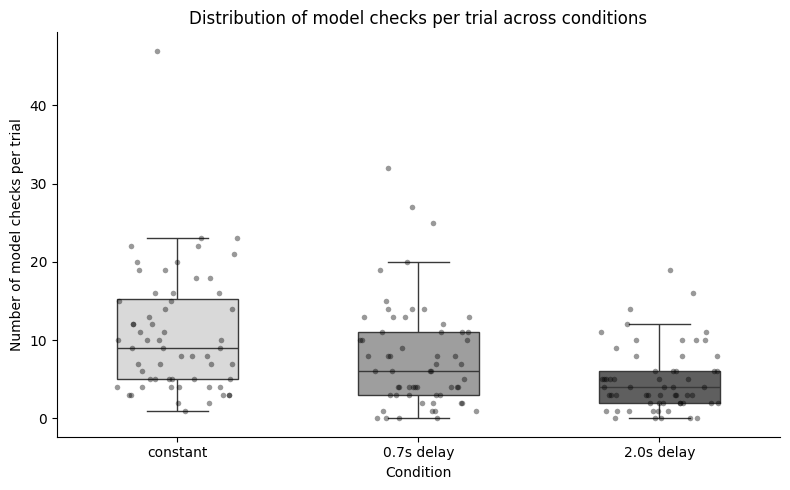

In [84]:
# =======================================================
# BOXPLOT: MODEL CHECKS PER TRIAL ACROSS CONDITIONS
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=checks_per_trial,
    x="condition",
    y="n_model_checks",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=checks_per_trial,
    x="condition",
    y="n_model_checks",
    order=COND_ORDER,
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition")
plt.ylabel("Number of model checks per trial")
plt.title("Distribution of model checks per trial across conditions")

sns.despine()
plt.tight_layout()
plt.show()

## Winzorize skewed distirbution

#### Check values

In [290]:
zero_check_trials = checks_per_trial[
    checks_per_trial["n_model_checks"] == 0
].copy()

print("Number of trials with 0 model checks:", len(zero_check_trials))

display(
    zero_check_trials[
        ["participant_id", "model_name", "condition", "n_model_checks"]
    ]
)

Number of trials with 0 model checks: 9


,participant_id,model_name,condition,n_model_checks
22,10,C1M5F,0.7s delay,0
108,6,C1M1F,2.0s delay,0
127,7,C1M2A,2.0s delay,0
130,7,C1M5F,0.7s delay,0
144,8,C1M1F,2.0s delay,0
162,9,C1M1F,0.7s delay,0
163,9,C1M2A,2.0s delay,0
164,9,C1M3F,2.0s delay,0
167,9,C1M6A,0.7s delay,0


In [297]:
model_presence = (
    gaze_sequence
    .groupby(
        ["participant_id", "model_name", "condition"],
        observed=True,
        as_index=False
    )
    .agg(
        saw_model=(
            "AOI_CLEAN",
            lambda x: (x == "MODEL").any()
        )
    )
)

print(
    "Trials without any MODEL event:",
    (~model_presence["saw_model"]).sum()
)

Trials without any MODEL event: 0


## Real Winzorization:

In [303]:
# =======================================================
# 4) WINSORIZE MODEL CHECKS (upper tail only, per condition)
# =======================================================

from scipy.stats.mstats import winsorize
import numpy as np

UPPER_LIMIT = 0.05  # 95. Perzentil als obere Grenze

def winsorize_upper(series, limit):
    arr = series.to_numpy(dtype=float)
    winsorized = winsorize(arr, limits=(0, limit))
    return np.asarray(winsorized)

checks_per_trial["n_model_checks_wz"] = (
    checks_per_trial
    .groupby("condition", observed=True)["n_model_checks"]
    .transform(lambda s: winsorize_upper(s, UPPER_LIMIT))
)

print("Vergleich Original vs. winsorisiert:")
display(
    checks_per_trial[["participant_id", "model_name", "condition",
                       "n_model_checks", "n_model_checks_wz"]]
    .sort_values("n_model_checks", ascending=False)
    .head(15)
)

Vergleich Original vs. winsorisiert:


,participant_id,model_name,condition,n_model_checks,n_model_checks_wz
67,3,C3M2A,constant,47,22.0
49,2,C3M2A,0.7s delay,32,20.0
31,10,C3M2A,0.7s delay,27,20.0
61,3,C2M2A,0.7s delay,25,20.0
13,1,C3M2A,constant,23,22.0
103,5,C3M2A,constant,23,22.0
85,4,C3M2A,constant,22,22.0
70,3,C3M5F,constant,22,22.0
175,9,C3M2A,constant,21,21.0
106,5,C3M5F,constant,20,20.0


/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/286508457.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


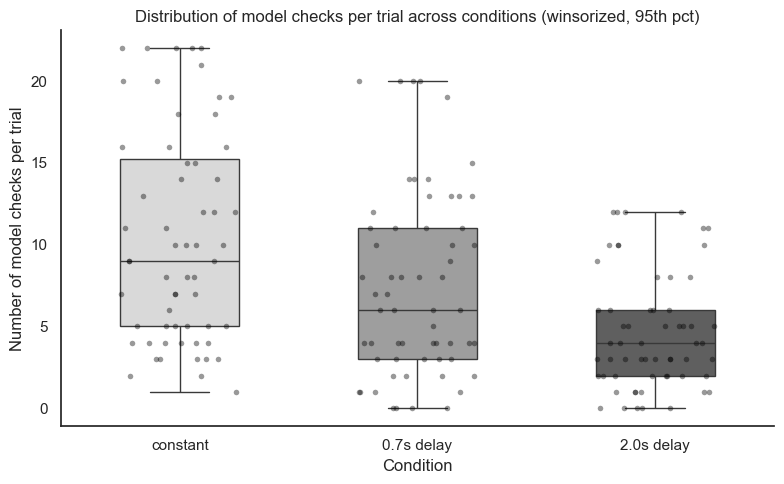

In [304]:
# =======================================================
# BOXPLOT: MODEL CHECKS PER TRIAL ACROSS CONDITIONS (WINSORIZED)
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=checks_per_trial,
    x="condition",
    y="n_model_checks_wz",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=checks_per_trial,
    x="condition",
    y="n_model_checks_wz",
    order=COND_ORDER,
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition")
plt.ylabel("Number of model checks per trial")
plt.title("Distribution of model checks per trial across conditions (winsorized, 95th pct)")

sns.despine()
plt.tight_layout()
plt.show()

## Values from winzorized data

In [315]:
constant_stats = (
    checks_per_trial
    .loc[checks_per_trial["condition"] == "constant", "n_model_checks_wz"]
    .agg(["mean", "std"])
)
print(constant_stats)

mean    10.350000
std      6.409276
Name: n_model_checks_wz, dtype: float64


Some gazes dont get detected due to our fix rule considereng only WM,RM tranisitons

- ### Participant average bauen

In [85]:
# =======================================================
# 4) BUILD PARTICIPANT-LEVEL AVERAGES
# =======================================================

avg_checks = (
    checks_per_trial
    .groupby(["participant_id", "condition"], as_index=False, observed=False)
    .agg(
        avg_model_checks=("n_model_checks", "mean")
    )
)

avg_checks["condition"] = pd.Categorical(
    avg_checks["condition"],
    categories=COND_ORDER,
    ordered=True
)

avg_checks = avg_checks.sort_values(["participant_id", "condition"])

print("avg_checks shape:", avg_checks.shape)
display(avg_checks.head(30))

print("Participants per condition:")
display(avg_checks.groupby("condition", observed=False)["participant_id"].nunique())

avg_checks shape: (30, 3)


,participant_id,condition,avg_model_checks
0,1,constant,10.000000
1,1,0.7s delay,8.333333
2,1,2.0s delay,5.333333
3,10,constant,9.666667
4,10,0.7s delay,9.166667
5,10,2.0s delay,4.666667
6,2,constant,9.833333
7,2,0.7s delay,11.000000
8,2,2.0s delay,4.166667
9,3,constant,20.666667


Participants per condition:


condition
constant      10
0.7s delay    10
2.0s delay    10
Name: participant_id, dtype: int64

- ## Group mean over participants

In [86]:
# =======================================================
# 5) BUILD GROUP SUMMARY
# =======================================================

group_summary = (
    avg_checks
    .groupby("condition", observed=False, as_index=False)
    .agg(
        mean_avg_model_checks=("avg_model_checks", "mean"),
        sd_avg_model_checks=("avg_model_checks", "std"),
        n_participants=("participant_id", "nunique")
    )
)

group_summary["se_avg_model_checks"] = (
    group_summary["sd_avg_model_checks"] / np.sqrt(group_summary["n_participants"])
)

group_summary = group_summary.sort_values("condition")

display(group_summary)

,condition,mean_avg_model_checks,sd_avg_model_checks,n_participants,se_avg_model_checks
0,constant,10.800000,3.805292,10,1.203339
1,0.7s delay,7.883333,2.784492,10,0.880534
2,2.0s delay,4.883333,1.763922,10,0.557801


#### Plot: - Participant trajectories and group mean

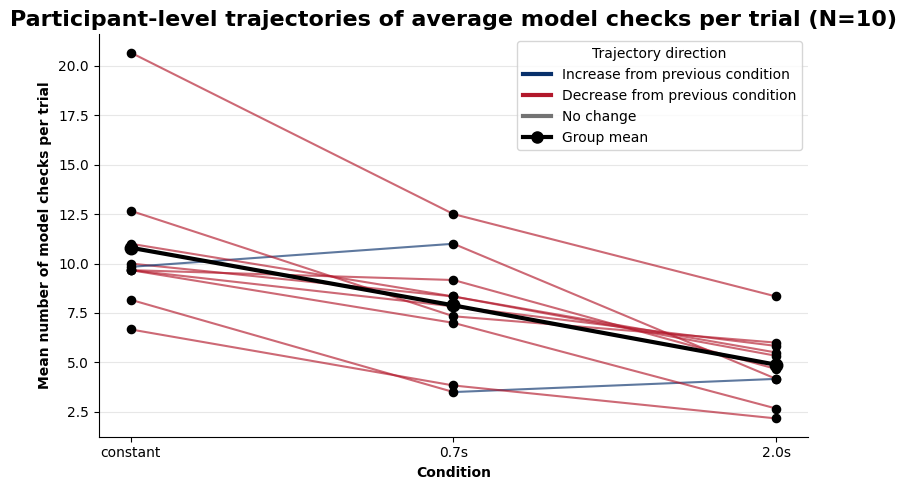

In [87]:
# =======================================================
# PARTICIPANT-LEVEL TRAJECTORIES:
# AVERAGE MODEL CHECKS PER TRIAL
# =======================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"   # dark blue
COL_DECREASE = "#b2182b"   # dark red
COL_EQUAL = "#737373"      # gray for no change
COL_MEAN = "black"

# =====================
# Prepare data
# =====================

plot_data = avg_checks.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

# Number of participants included
n_participants = plot_data["participant_id"].nunique()

x = np.arange(len(COND_ORDER))

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    # Only plot participants who have all three conditions
    if len(sub) != 3:
        continue

    y = sub["avg_model_checks"].values

    # Points
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # Segment 1: constant -> 0.7s delay
    diff1 = y[1] - y[0]

    if diff1 > 0:
        color1 = COL_INCREASE
    elif diff1 < 0:
        color1 = COL_DECREASE
    else:
        color1 = COL_EQUAL

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # Segment 2: 0.7s delay -> 2.0s delay
    diff2 = y[2] - y[1]

    if diff2 > 0:
        color2 = COL_INCREASE
    elif diff2 < 0:
        color2 = COL_DECREASE
    else:
        color2 = COL_EQUAL

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# =====================
# Group mean
# =====================

group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_model_checks"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color=COL_MEAN,
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

# =====================
# Legend
# =====================

legend_elements = [
    Line2D(
        [0], [0],
        color=COL_INCREASE,
        lw=3,
        label="Increase from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_EQUAL,
        lw=3,
        label="No change"
    ),
    Line2D(
        [0], [0],
        color=COL_MEAN,
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper right"
)

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel(
    "Mean number of model checks per trial",
    fontweight="bold"
)

ax.set_title(
    f"Participant-level trajectories of average model checks per trial (N={n_participants})",
    fontweight="bold",
    fontsize=16
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

#### Checks
### Which participants increase?


In [88]:
# =======================================================
# FIND PARTICIPANTS WITH INCREASES BETWEEN CONDITIONS
# =======================================================

COND_ORDER = ["constant","0.7s delay","2.0s delay"]

# Wide table: one row per participant, one column per condition
participant_changes = (
    avg_checks
    .pivot(
        index="participant_id",
        columns="condition",
        values="avg_model_checks"
    )
    .reset_index()
)

# Make sure columns are in correct order
participant_changes = participant_changes[
    ["participant_id"] + COND_ORDER
]

# Differences between neighboring conditions
participant_changes["diff_constant_to_0.7s"] = (
    participant_changes["0.7s delay"] - participant_changes["constant"]
)

participant_changes["diff_0.7s_to_2.0s"] = (
    participant_changes["2.0s delay"] - participant_changes["0.7s delay"]
)

# Mark increase/decrease/no change
participant_changes["change_constant_to_0.7s"] = np.where(
    participant_changes["diff_constant_to_0.7s"] > 0,
    "increase",
    np.where(
        participant_changes["diff_constant_to_0.7s"] < 0,
        "decrease",
        "no change"
    )
)

participant_changes["change_0.7s_to_2.0s"] = np.where(
    participant_changes["diff_0.7s_to_2.0s"] > 0,
    "increase",
    np.where(
        participant_changes["diff_0.7s_to_2.0s"] < 0,
        "decrease",
        "no change"
    )
)

display(participant_changes)

condition,participant_id,constant,0.7s delay,2.0s delay,diff_constant_to_0.7s,diff_0.7s_to_2.0s,change_constant_to_0.7s,change_0.7s_to_2.0s
0,1,10.000000,8.333333,5.333333,-1.666667,-3.000000,decrease,decrease
1,10,9.666667,9.166667,4.666667,-0.500000,-4.500000,decrease,decrease
2,2,9.833333,11.000000,4.166667,1.166667,-6.833333,increase,decrease
3,3,20.666667,12.500000,8.333333,-8.166667,-4.166667,decrease,decrease
4,4,9.666667,7.833333,5.833333,-1.833333,-2.000000,decrease,decrease
5,5,12.666667,7.333333,6.000000,-5.333333,-1.333333,decrease,decrease
6,6,11.000000,8.333333,5.500000,-2.666667,-2.833333,decrease,decrease
7,7,8.166667,3.500000,4.166667,-4.666667,0.666667,decrease,increase
8,8,9.666667,7.000000,2.666667,-2.666667,-4.333333,decrease,decrease
9,9,6.666667,3.833333,2.166667,-2.833333,-1.666667,decrease,decrease


### Which participant has these higher numbers??

In [89]:
# =======================================================
# HIGHEST PARTICIPANT AVERAGES PER CONDITION
# =======================================================

highest_avg_by_condition = (
    avg_checks
    .sort_values(["condition", "avg_model_checks"], ascending=[True, False])
    .groupby("condition", observed=False)
    .head(3)
    .reset_index(drop=True)
)

display(highest_avg_by_condition)

,participant_id,condition,avg_model_checks
0,3,constant,20.666667
1,5,constant,12.666667
2,6,constant,11.000000
3,3,0.7s delay,12.500000
4,2,0.7s delay,11.000000
5,10,0.7s delay,9.166667
6,3,2.0s delay,8.333333
7,5,2.0s delay,6.000000
8,4,2.0s delay,5.833333


- Particiapnt 3 apparently has the high numbers

In [90]:
# =======================================================
# COMPARE MODEL CHECKS: AOI vs AOI_CLEAN
# =======================================================

compare_df = object_gazes_final.copy()

compare_df["participant_id"] = compare_df["participant_id"].astype(str).str.strip()
compare_df["model_name"] = compare_df["model_name"].astype(str).str.strip()
compare_df["condition"] = compare_df["condition"].astype(str).str.strip()
compare_df["AOI"] = compare_df["AOI"].astype(str).str.strip().str.upper()
compare_df["AOI_CLEAN"] = compare_df["AOI_CLEAN"].astype(str).str.strip().str.upper()

compare_df = compare_df.sort_values(
    ["participant_id", "model_name", "start_ms"]
).reset_index(drop=True)

# Old version: based on AOI
compare_df["prev_AOI"] = (
    compare_df
    .groupby(["participant_id", "model_name"])["AOI"]
    .shift(1)
)

compare_df["is_model_check_AOI"] = (
    (compare_df["AOI"] == "MODEL") &
    (compare_df["prev_AOI"].notna()) &
    (compare_df["prev_AOI"] != "MODEL")
)

# New version: based on AOI_CLEAN
clean_seq = compare_df[
    compare_df["AOI_CLEAN"].isin(["MODEL", "WORK", "RESOURCE"])
].copy()

clean_seq["prev_AOI_CLEAN"] = (
    clean_seq
    .groupby(["participant_id", "model_name"])["AOI_CLEAN"]
    .shift(1)
)

clean_seq["is_model_check_AOI_CLEAN"] = (
    (clean_seq["AOI_CLEAN"] == "MODEL") &
    (clean_seq["prev_AOI_CLEAN"].isin(["WORK", "RESOURCE"]))
)

print("Old AOI model checks:", compare_df["is_model_check_AOI"].sum())
print("New AOI_CLEAN model checks:", clean_seq["is_model_check_AOI_CLEAN"].sum())

Old AOI model checks: 2086
New AOI_CLEAN model checks: 1414


#### Most important numbers

In [91]:
# =======================================================
# MODEL CHECKS: RELEVANT NUMBERS FOR REPORTING
# =======================================================

import numpy as np
import pandas as pd

# =====================
# 1) Basic totals
# =====================

total_model_checks = gaze_sequence["is_model_check"].sum()

n_participants = avg_checks["participant_id"].nunique()
n_trials = checks_per_trial.shape[0]

print("===== BASIC NUMBERS =====")
print("Total model checks:", total_model_checks)
print("Number of participants:", n_participants)
print("Number of trials/models:", n_trials)

# =====================
# 2) Model checks per condition, trial-level
# =====================

checks_by_condition_trial = (
    checks_per_trial
    .groupby("condition", observed=False, as_index=False)
    .agg(
        n_trials=("n_model_checks", "count"),
        total_model_checks=("n_model_checks", "sum"),
        mean_checks_per_trial=("n_model_checks", "mean"),
        sd_checks_per_trial=("n_model_checks", "std"),
        median_checks_per_trial=("n_model_checks", "median"),
        min_checks_per_trial=("n_model_checks", "min"),
        max_checks_per_trial=("n_model_checks", "max")
    )
)

checks_by_condition_trial["se_checks_per_trial"] = (
    checks_by_condition_trial["sd_checks_per_trial"] /
    np.sqrt(checks_by_condition_trial["n_trials"])
)

print("\n===== TRIAL-LEVEL SUMMARY BY CONDITION =====")
display(checks_by_condition_trial)

# =====================
# 3) Participant-level averages per condition
# =====================

checks_by_condition_participant = (
    avg_checks
    .groupby("condition", observed=False, as_index=False)
    .agg(
        n_participants=("participant_id", "nunique"),
        mean_avg_checks=("avg_model_checks", "mean"),
        sd_avg_checks=("avg_model_checks", "std"),
        median_avg_checks=("avg_model_checks", "median"),
        min_avg_checks=("avg_model_checks", "min"),
        max_avg_checks=("avg_model_checks", "max")
    )
)

checks_by_condition_participant["se_avg_checks"] = (
    checks_by_condition_participant["sd_avg_checks"] /
    np.sqrt(checks_by_condition_participant["n_participants"])
)

print("\n===== PARTICIPANT-LEVEL SUMMARY BY CONDITION =====")
display(checks_by_condition_participant)

# =====================
# 4) Participant-level table
# =====================

participant_table = (
    avg_checks
    .pivot(
        index="participant_id",
        columns="condition",
        values="avg_model_checks"
    )
    .reset_index()
)

print("\n===== PARTICIPANT AVERAGES TABLE =====")
display(participant_table)

# =====================
# 5) Checks: totals should match
# =====================

print("\n===== SANITY CHECKS =====")
print("Total from gaze_sequence:", total_model_checks)
print("Total from checks_per_trial:", checks_per_trial["n_model_checks"].sum())

if total_model_checks == checks_per_trial["n_model_checks"].sum():
    print("OK: totals match.")
else:
    print("Warning: totals do not match.")

# =====================
# 6) Thesis-ready sentence helper
# =====================

print("\n===== SENTENCE HELPER =====")

for _, row in checks_by_condition_participant.iterrows():
    print(
        f"{row['condition']}: "
        f"M = {row['mean_avg_checks']:.2f}, "
        f"SD = {row['sd_avg_checks']:.2f}, "
        f"SE = {row['se_avg_checks']:.2f}, "
        f"n = {int(row['n_participants'])}"
    )

print(
    f"\nAcross all valid trials, {int(total_model_checks)} model checks were identified. "
    f"Model checks were defined as transitions from WORK or RESOURCE into the MODEL AOI."
)

===== BASIC NUMBERS =====
Total model checks: 1414
Number of participants: 10
Number of trials/models: 180

===== TRIAL-LEVEL SUMMARY BY CONDITION =====


,condition,n_trials,total_model_checks,mean_checks_per_trial,sd_checks_per_trial,median_checks_per_trial,min_checks_per_trial,max_checks_per_trial,se_checks_per_trial
0,constant,60,648,10.800000,7.884333,9.0,1,47,1.017863
1,0.7s delay,60,473,7.883333,6.770053,6.0,0,32,0.874010
2,2.0s delay,60,293,4.883333,4.125537,4.0,0,19,0.532605



===== PARTICIPANT-LEVEL SUMMARY BY CONDITION =====


,condition,n_participants,mean_avg_checks,sd_avg_checks,median_avg_checks,min_avg_checks,max_avg_checks,se_avg_checks
0,constant,10,10.800000,3.805292,9.750000,6.666667,20.666667,1.203339
1,0.7s delay,10,7.883333,2.784492,8.083333,3.500000,12.500000,0.880534
2,2.0s delay,10,4.883333,1.763922,5.000000,2.166667,8.333333,0.557801



===== PARTICIPANT AVERAGES TABLE =====


condition,participant_id,constant,0.7s delay,2.0s delay
0,1,10.000000,8.333333,5.333333
1,10,9.666667,9.166667,4.666667
2,2,9.833333,11.000000,4.166667
3,3,20.666667,12.500000,8.333333
4,4,9.666667,7.833333,5.833333
5,5,12.666667,7.333333,6.000000
6,6,11.000000,8.333333,5.500000
7,7,8.166667,3.500000,4.166667
8,8,9.666667,7.000000,2.666667
9,9,6.666667,3.833333,2.166667



===== SANITY CHECKS =====
Total from gaze_sequence: 1414
Total from checks_per_trial: 1414
OK: totals match.

===== SENTENCE HELPER =====
constant: M = 10.80, SD = 3.81, SE = 1.20, n = 10
0.7s delay: M = 7.88, SD = 2.78, SE = 0.88, n = 10
2.0s delay: M = 4.88, SD = 1.76, SE = 0.56, n = 10

Across all valid trials, 1414 model checks were identified. Model checks were defined as transitions from WORK or RESOURCE into the MODEL AOI.


In [93]:
# =======================================================
# SHOW GROUP MEANS FOR MODEL CHECKS
# =======================================================

display(group_summary)

print("Group means:")
for _, row in group_summary.iterrows():
    print(
        f"{row['condition']}: "
        f"M = {row['mean_avg_model_checks']:.2f}, "
        f"SD = {row['sd_avg_model_checks']:.2f}, "
        f"SE = {row['se_avg_model_checks']:.2f}, "
        f"N = {int(row['n_participants'])}"
    )

,condition,mean_avg_model_checks,sd_avg_model_checks,n_participants,se_avg_model_checks
0,constant,10.800000,3.805292,10,1.203339
1,0.7s delay,7.883333,2.784492,10,0.880534
2,2.0s delay,4.883333,1.763922,10,0.557801


Group means:
constant: M = 10.80, SD = 3.81, SE = 1.20, N = 10
0.7s delay: M = 7.88, SD = 2.78, SE = 0.88, N = 10
2.0s delay: M = 4.88, SD = 1.76, SE = 0.56, N = 10


##### Percent drecrease

In [94]:
# =======================================================
# PERCENT DECREASE IN GROUP MEANS
# =======================================================

# Get group means from group_summary
means = group_summary.set_index("condition")["mean_avg_model_checks"]

constant = means["constant"]
delay_07 = means["0.7s delay"]
delay_20 = means["2.0s delay"]

# Percent decreases
decrease_constant_to_07 = (constant - delay_07) / constant * 100
decrease_07_to_20 = (delay_07 - delay_20) / delay_07 * 100
decrease_constant_to_20 = (constant - delay_20) / constant * 100

print("Percent decrease in group mean model checks:")
print(f"constant → 0.7s delay: {decrease_constant_to_07:.2f}%")
print(f"0.7s delay → 2.0s delay: {decrease_07_to_20:.2f}%")
print(f"constant → 2.0s delay: {decrease_constant_to_20:.2f}%")

Percent decrease in group mean model checks:
constant → 0.7s delay: 27.01%
0.7s delay → 2.0s delay: 38.05%
constant → 2.0s delay: 54.78%


## Test for significance with winzorized data:

### Check Sharpiro Wilk test/ QQ plots

,condition,W,p_value,normal_verteilt (p>.05)
0,constant,0.918,0.0007,False
1,0.7s delay,0.922,0.0009,False
2,2.0s delay,0.904,0.0002,False


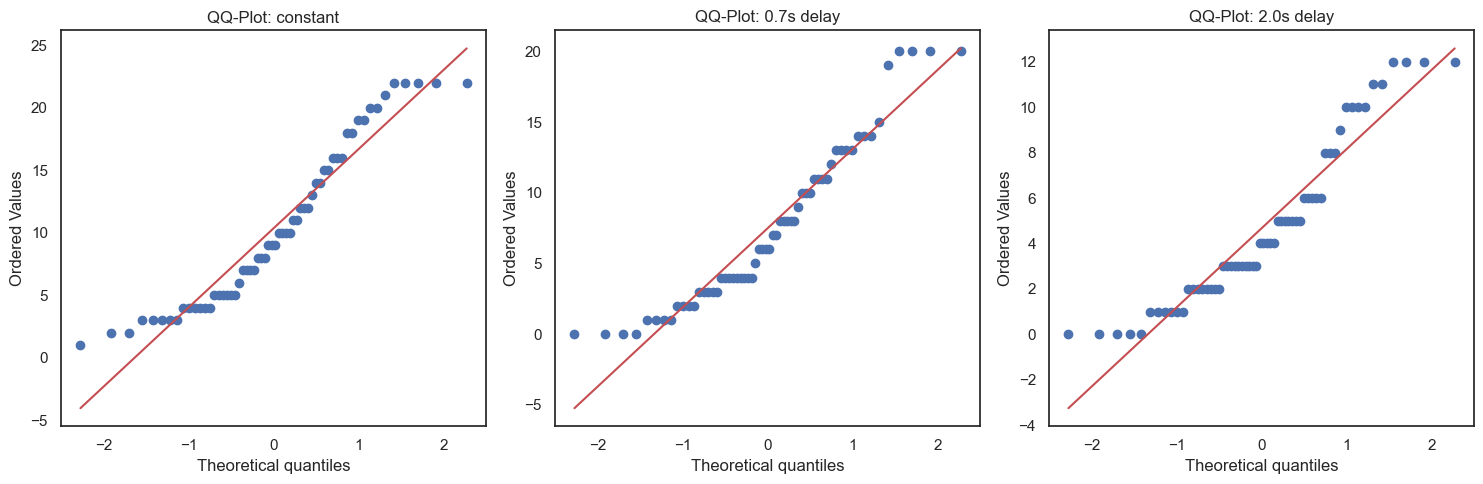

In [306]:
# =======================================================
# NORMALITY CHECK: SHAPIRO-WILK + QQ-PLOTS PER CONDITION
# =======================================================

import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

# --- Shapiro-Wilk Test pro Condition ---
shapiro_results = []

for cond in COND_ORDER:
    vals = checks_per_trial.loc[
        checks_per_trial["condition"] == cond,
        "n_model_checks_wz"
    ]
    stat, p = stats.shapiro(vals)
    shapiro_results.append({
        "condition": cond,
        "W": round(stat, 3),
        "p_value": round(p, 4),
        "normal_verteilt (p>.05)": p > 0.05
    })

shapiro_results = pd.DataFrame(shapiro_results)
display(shapiro_results)

# --- QQ-Plots pro Condition ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cond in zip(axes, COND_ORDER):
    vals = checks_per_trial.loc[
        checks_per_trial["condition"] == cond,
        "n_model_checks_wz"
    ]
    stats.probplot(vals, dist="norm", plot=ax)
    ax.set_title(f"QQ-Plot: {cond}")

plt.tight_layout()
plt.savefig("qq_plots_normality.png", dpi=300, bbox_inches="tight")
plt.show()

## Try normal LMM and look at residues

              Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  n_model_checks_wz
No. Observations:  180      Method:              REML             
No. Groups:        10       Scale:               26.1989          
Min. group size:   18       Log-Likelihood:      -550.9723        
Max. group size:   18       Converged:           Yes              
Mean group size:   18.0                                           
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               10.350    0.837 12.359 0.000  8.709 11.991
condition[T.0.7s delay] -2.867    0.935 -3.068 0.002 -4.698 -1.035
condition[T.2.0s delay] -5.683    0.935 -6.082 0.000 -7.515 -3.852
Group Var                2.647    0.388                           



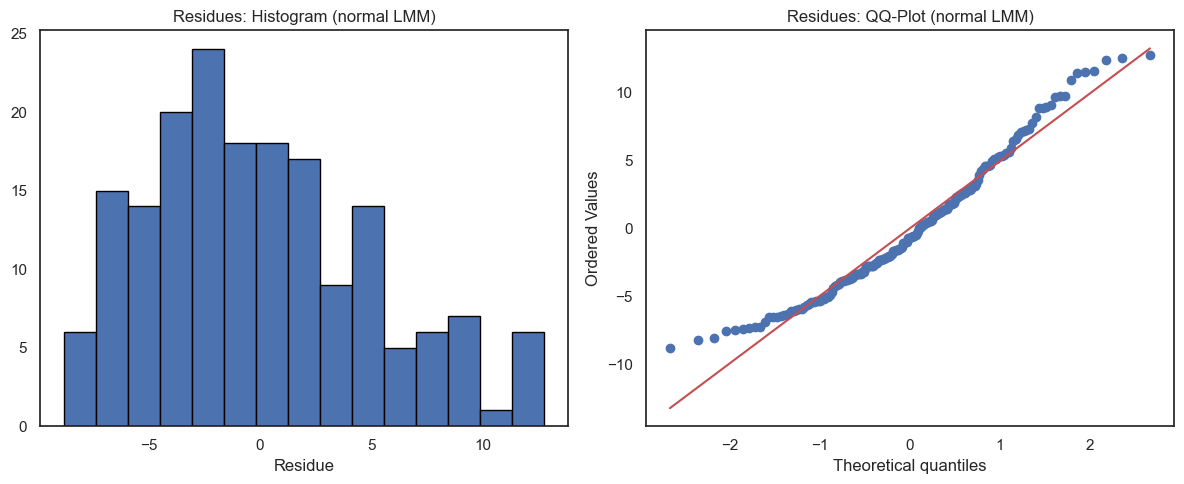

Shapiro-Wilk on Residues: W=0.964, p=0.0001


In [314]:
# =======================================================
# LMM (GAUSSIAN) + RESIDUEN-DIAGNOSTIK
# =======================================================

import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import scipy.stats as stats

# --- Normales LMM ---
lmm_normal = smf.mixedlm(
    "n_model_checks_wz ~ condition",
    data=checks_per_trial,
    groups=checks_per_trial["participant_id"]
)
lmm_normal_fit = lmm_normal.fit()
print(lmm_normal_fit.summary())

# --- Residuen extrahieren ---
residuals_normal = lmm_normal_fit.resid

# --- Diagnostik: Histogramm + QQ-Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals_normal, bins=15, edgecolor="black")
axes[0].set_title("Residues: Histogram (normal LMM)")
axes[0].set_xlabel("Residue")

stats.probplot(residuals_normal, dist="norm", plot=axes[1])
axes[1].set_title("Residues: QQ-Plot (normal LMM)")

plt.tight_layout()
plt.show()

# --- Shapiro-Wilk auf Residuen ---
stat, p = stats.shapiro(residuals_normal)
print(f"Shapiro-Wilk on Residues: W={stat:.3f}, p={p:.4f}")

## Residues still seem skewed, as comparison we try a logx+ 1 LMM

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_n_model_checks_wz
No. Observations: 180     Method:             REML                 
No. Groups:       10      Scale:              0.4743               
Min. group size:  18      Log-Likelihood:     -196.3269            
Max. group size:  18      Converged:          Yes                  
Mean group size:  18.0                                             
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 2.251    0.116 19.471 0.000  2.025  2.478
condition[T.0.7s delay]  -0.386    0.126 -3.069 0.002 -0.632 -0.139
condition[T.2.0s delay]  -0.737    0.126 -5.864 0.000 -0.984 -0.491
Group Var                 0.055    0.057                           



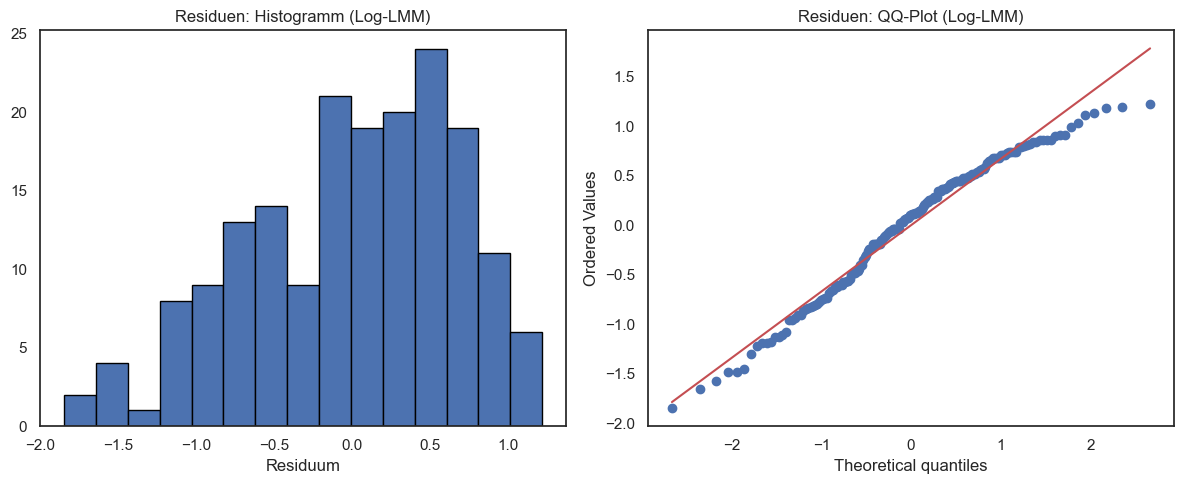

Shapiro-Wilk auf Residuen (Log-LMM): W=0.970, p=0.0007


In [308]:
# =======================================================
# LMM (LOG-TRANSFORMIERT) + RESIDUEN-DIAGNOSTIK
# =======================================================

checks_per_trial["log_n_model_checks_wz"] = np.log(
    checks_per_trial["n_model_checks_wz"] + 1  # +1 wegen möglicher 0-Werte
)

lmm_log = smf.mixedlm(
    "log_n_model_checks_wz ~ condition",
    data=checks_per_trial,
    groups=checks_per_trial["participant_id"]
)
lmm_log_fit = lmm_log.fit()
print(lmm_log_fit.summary())

residuals_log = lmm_log_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals_log, bins=15, edgecolor="black")
axes[0].set_title("Residuen: Histogramm (Log-LMM)")
axes[0].set_xlabel("Residuum")

stats.probplot(residuals_log, dist="norm", plot=axes[1])
axes[1].set_title("Residuen: QQ-Plot (Log-LMM)")

plt.tight_layout()
plt.show()

stat, p = stats.shapiro(residuals_log)
print(f"Shapiro-Wilk auf Residuen (Log-LMM): W={stat:.3f}, p={p:.4f}")

Prozentualer decrease können wir mit: (exp(-0.351)-1)*100 berechnen!

## Tukey correction

In [313]:
# =======================================================
# TUKEY-KORRIGIERTE POST-HOC-VERGLEICHE (Log-LMM-Contrasts)
# =======================================================

import numpy as np
import pandas as pd
from scipy.stats import studentized_range

# Fixed-Effects-Koeffizienten und ihre Kovarianzmatrix aus dem Log-LMM
params = lmm_log_fit.fe_params
cov_full = lmm_log_fit.cov_params()
cov = cov_full.loc[params.index, params.index]  # nur Fixed-Effects-Block

k = 3   # Anzahl Conditions
n = 10  # Anzahl Probanden
df_approx = (n - 1) * (k - 1)  # ≈ 18, Näherung für Fehler-Freiheitsgrade

# Contrasts: alle 3 Paarvergleiche
contrasts = {
    "0.7s delay vs constant":   pd.Series([0,  1, 0], index=params.index),
    "2.0s delay vs constant":   pd.Series([0,  0, 1], index=params.index),
    "2.0s delay vs 0.7s delay": pd.Series([0, -1, 1], index=params.index),
}

rows = []
for name, c in contrasts.items():
    est = float(c @ params)
    se = float(np.sqrt(c.values @ cov.values @ c.values))
    q = np.sqrt(2) * abs(est) / se
    p_tukey = 1 - studentized_range.cdf(q, k, df_approx)
    rows.append({
        "comparison": name,
        "estimate (log)": round(est, 3),
        "SE": round(se, 3),
        "q": round(q, 3),
        "p_tukey": round(p_tukey, 5)
    })

tukey_results = pd.DataFrame(rows)
display(tukey_results)

,comparison,estimate (log),SE,q,p_tukey
0,0.7s delay vs constant,-0.386,0.126,4.341,0.01728
1,2.0s delay vs constant,-0.737,0.126,8.294,0.00004
2,2.0s delay vs 0.7s delay,-0.351,0.126,3.953,0.03061


## Do a sensitivity check with friedmann- does the effect persits regardless of the model?

### aggregate date for friedman

In [310]:
# =======================================================
# AGGREGATION: MITTELWERT PRO PERSON × CONDITION
# =======================================================

checks_per_participant = (
    checks_per_trial
    .groupby(["participant_id", "condition"], as_index=False, observed=True)
    .agg(mean_n_model_checks_wz=("n_model_checks_wz", "mean"))
)

print("Anzahl Zeilen:", checks_per_participant.shape[0])  # sollte 30 sein
display(checks_per_participant)

Anzahl Zeilen: 30


,participant_id,condition,mean_n_model_checks_wz
0,1,constant,9.833333
1,1,0.7s delay,8.333333
2,1,2.0s delay,5.333333
3,10,constant,9.666667
4,10,0.7s delay,8.000000
5,10,2.0s delay,4.666667
6,2,constant,9.833333
7,2,0.7s delay,9.000000
8,2,2.0s delay,4.166667
9,3,constant,16.500000


## Friedman

In [311]:
# =======================================================
# FRIEDMAN-TEST (auf aggregierten Pro-Person-Daten)
# =======================================================

import pingouin as pg

friedman_result = pg.friedman(
    data=checks_per_participant,
    dv="mean_n_model_checks_wz",
    within="condition",
    subject="participant_id"
)
display(friedman_result)

,Source,W,ddof1,Q,p_unc
Friedman,condition,0.91,2,18.2,0.000112


## Willcoxon test with correciton

In [312]:
# =======================================================
# POST-HOC: WILCOXON-TESTS MIT KORREKTUR
# =======================================================

posthoc_wilcoxon = pg.pairwise_tests(
    data=checks_per_participant,
    dv="mean_n_model_checks_wz",
    within="condition",
    subject="participant_id",
    parametric=False,
    padjust="holm"
)
display(posthoc_wilcoxon)

,Contrast,A,B,Paired,Parametric,W_val,alternative,p_unc,p_corr,p_adjust,hedges
0,condition,constant,0.7s delay,True,False,0.0,two-sided,0.001953,0.005859,holm,1.089932
1,condition,constant,2.0s delay,True,False,0.0,two-sided,0.001953,0.005859,holm,2.537008
2,condition,0.7s delay,2.0s delay,True,False,1.0,two-sided,0.003906,0.005859,holm,1.360182


## Statistical Inferece - Model checks: Using a NB GLMM

In [96]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Negative Binomial GLMM für wiederholte Messungen (GEE)
model = smf.gee(
    "n_model_checks ~ C(condition, Treatment(reference='constant'))",
    data=checks_per_trial,
    groups="participant_id",
    family=sm.families.NegativeBinomial()
)

results = model.fit()
print(results.summary())

                               GEE Regression Results                              
Dep. Variable:              n_model_checks   No. Observations:                  180
Model:                                 GEE   No. clusters:                       10
Method:                        Generalized   Min. cluster size:                  18
                      Estimating Equations   Max. cluster size:                  18
Family:                   NegativeBinomial   Mean cluster size:                18.0
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Fri, 24 Jul 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         01:53:35
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### NB GEE with all 3 conditions comparable

In [97]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Negative Binomial Modell (GEE) definieren & anpassen
model = smf.gee(
    "n_model_checks ~ C(condition, Treatment(reference='constant'))",
    data=checks_per_trial,
    groups="participant_id",
    family=sm.families.NegativeBinomial()
)

results = model.fit()

# 2. Die Haupt-Summary ausgeben (Constant vs. 0.7s & Constant vs. 2.0s)
print("==============================================================================")
print("1. MODEL SUMMARY (Baseline: Constant)")
print("==============================================================================")
print(results.summary())

# 3. Alle 3 Paarvergleiche auf einmal abfragen (Post-Hoc Tests)
hypotheses = [
    "C(condition, Treatment(reference='constant'))[T.0.7s delay] = 0",
    "C(condition, Treatment(reference='constant'))[T.2.0s delay] = 0",
    "C(condition, Treatment(reference='constant'))[T.2.0s delay] - C(condition, Treatment(reference='constant'))[T.0.7s delay] = 0"
]

print("\n==============================================================================")
print("2. ALLE PAARVERGLEICHE (PAIRWISE COMPARISONS)")
print("   Zeile 1: Constant vs. 0.7s delay")
print("   Zeile 2: Constant vs. 2.0s delay")
print("   Zeile 3: 0.7s delay vs. 2.0s delay")
print("==============================================================================")
pairwise_results = results.t_test(", ".join(hypotheses))
print(pairwise_results)

1. MODEL SUMMARY (Baseline: Constant)
                               GEE Regression Results                              
Dep. Variable:              n_model_checks   No. Observations:                  180
Model:                                 GEE   No. clusters:                       10
Method:                        Generalized   Min. cluster size:                  18
                      Estimating Equations   Max. cluster size:                  18
Family:                   NegativeBinomial   Mean cluster size:                18.0
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Fri, 24 Jul 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         01:53:35
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Interpretation: To evaluate the effect of visual cost on external sampling, a Generalized Estimating Equation (GEE) model with a Negative Binomial distribution was calculated on trial-level data ($N = 180$ trials across $10$ participants).Pairwise contrast comparisons confirmed a highly significant, monotonic decrease in model checks across all conditions:Model checks significantly decreased from constant to 0.7s delay ($\beta = -0.315, z = -4.01, p < .001$).Increasing the delay further to 2.0s delay led to a significant additional drop compared to 0.7s delay ($\beta = -0.479, z = -5.45, p < .001$).The overall reduction from constant to 2.0s delay was highly significant ($\beta = -0.794, z = -13.55, p < .001$).These results statistically support the hypothesis that higher visual costs continuously suppress external sampling behavior.

### Klassisches LMM

In [98]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# 1. Modell anpassen (mit lbfgs-Optimierer für bessere Konvergenz)
model = smf.mixedlm(
    "n_model_checks ~ C(condition, Treatment(reference='constant'))",
    data=checks_per_trial,
    groups=checks_per_trial["participant_id"],
)

# Verwende lbfgs, falls der Standard-Optimierer nicht konvergiert
results = model.fit(method="lbfgs")

# Prüfen, ob das Modell konvergiert ist:
print(f"Modell konvergiert: {results.converged}\n")

# 2. Namen der Fixed Effects abfragen
param_names = results.fe_params.index.tolist()

# 3. Kontrastmatrix dynamisch & exakt passend über Pandas erstellen
# Wir erstellen eine Null-Matrix mit den exakten Spaltennamen des Modells
L_df = pd.DataFrame(0, index=["Constant vs 0.7s", "Constant vs 2.0s", "0.7s vs 2.0s"], columns=param_names)

# Namen der Parameter identifizieren (oft z. B. "C(condition...)[T.0.7s delay]")
p_07 = [p for p in param_names if "0.7s" in p][0]
p_20 = [p for p in param_names if "2.0s" in p][0]

# Kontraste setzen
L_df.loc["Constant vs 0.7s", p_07] = 1
L_df.loc["Constant vs 2.0s", p_20] = 1
L_df.loc["0.7s vs 2.0s", p_20] = 1
L_df.loc["0.7s vs 2.0s", p_07] = -1

# 4. t-Test mit der benannten Matrix ausführen
pairwise = results.t_test(L_df.values)

# Ergebnisse anzeigen
df_pairwise = pd.DataFrame(pairwise.summary_frame())
df_pairwise.index = L_df.index
print(df_pairwise)

Modell konvergiert: True

                      coef   std err         z         P>|z|  Conf. Int. Low  \
Constant vs 0.7s -2.916667  1.119842 -2.604534  9.199916e-03       -5.111516   
Constant vs 2.0s -5.916667  1.119842 -5.283484  1.267498e-07       -8.111516   
0.7s vs 2.0s     -3.000000  1.119842 -2.678950  7.385347e-03       -5.194850   

                  Conf. Int. Upp.  
Constant vs 0.7s        -0.721817  
Constant vs 2.0s        -3.721817  
0.7s vs 2.0s            -0.805150  


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


## LMM Q plot

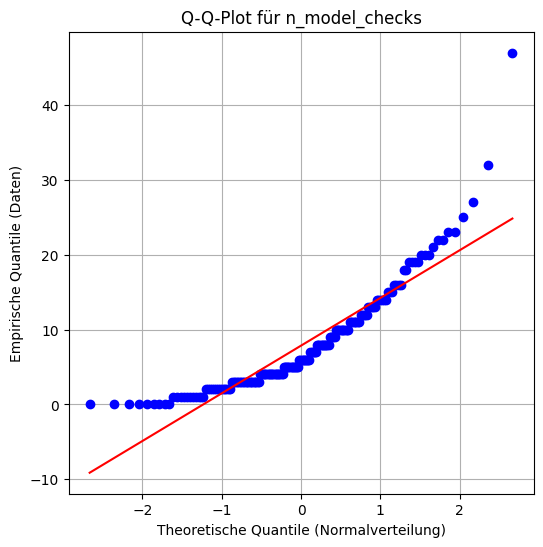

In [99]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Erstellt den Q-Q-Plot gegen die Normalverteilung ('norm')
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(checks_per_trial["n_model_checks"], dist="norm", plot=ax)

ax.set_title("Q-Q-Plot für n_model_checks")
ax.set_xlabel("Theoretische Quantile (Normalverteilung)")
ax.set_ylabel("Empirische Quantile (Daten)")
plt.grid(True)
plt.show()

## qq plot in LMM

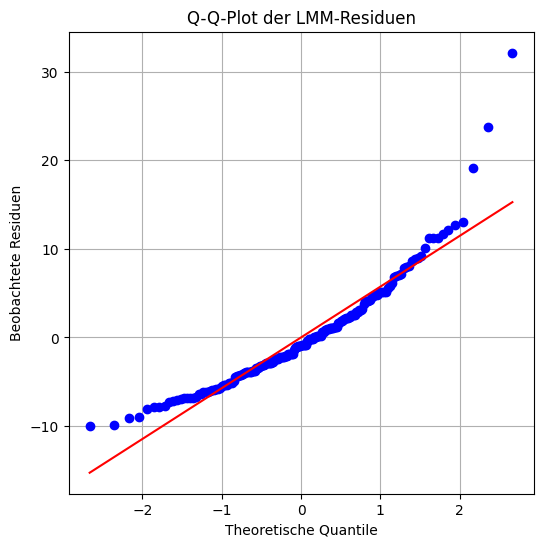

In [100]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf

# 1. LMM anpassen
lmm_model = smf.mixedlm(
    "n_model_checks ~ C(condition, Treatment(reference='constant'))",
    data=checks_per_trial,
    groups=checks_per_trial["participant_id"],
)
lmm_results = lmm_model.fit()

# 2. Residuen (Abweichungen) extrahieren
residuals = lmm_results.resid

# 3. Q-Q-Plot der Residuen zeichnen
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=ax)

ax.set_title("Q-Q-Plot der LMM-Residuen")
ax.set_xlabel("Theoretische Quantile")
ax.set_ylabel("Beobachtete Residuen")
plt.grid(True)
plt.show()

## FINAL LMM for Model Checks

## Shapiro wild test and QQ plot

--- SHAPIRO-WILK TEST ON RESIDUALS ---
W-Statistic: 0.9019
p-value: < 0.0001


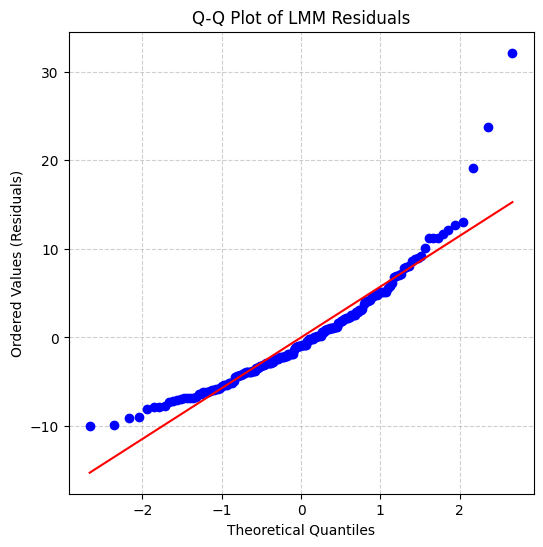

In [101]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Residuen aus dem LMM extrahieren
residuals = lmm_results.resid

# 2. Shapiro-Wilk-Test auf Normalverteilung
sw_stat, sw_pvalue = stats.shapiro(residuals)

print("--- SHAPIRO-WILK TEST ON RESIDUALS ---")
print(f"W-Statistic: {sw_stat:.4f}")
print(
    f"p-value: {sw_pvalue:.5f}" if sw_pvalue >= 0.0001 else "p-value: < 0.0001"
)

# 3. Q-Q-Plot erstellen (auf Englisch)
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of LMM Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Values (Residuals)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

--- SHAPIRO-WILK TEST ON RESIDUALS ---
W-Statistic: 0.9019
p-value: < 0.0001


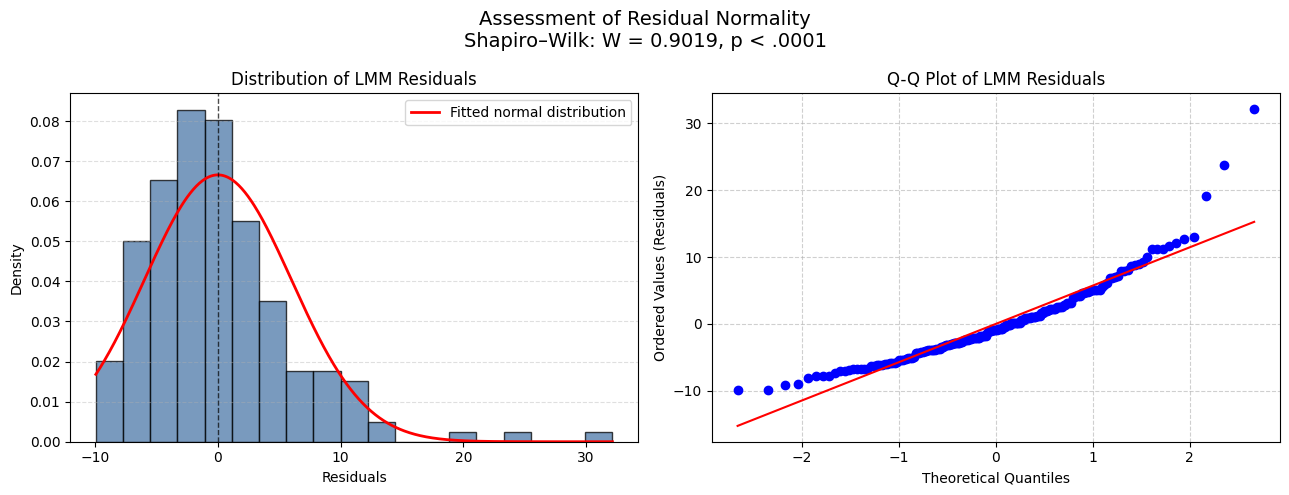

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Extract LMM residuals and remove missing values
residuals = lmm_results.resid.dropna()

# 2. Shapiro-Wilk test
sw_stat, sw_pvalue = stats.shapiro(residuals)

print("--- SHAPIRO-WILK TEST ON RESIDUALS ---")
print(f"W-Statistic: {sw_stat:.4f}")
print(
    f"p-value: {sw_pvalue:.5f}"
    if sw_pvalue >= 0.0001
    else "p-value: < 0.0001"
)

# 3. Create histogram and Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---------------------
# Histogram
# ---------------------

axes[0].hist(
    residuals,
    bins="auto",
    density=True,
    color="#4C78A8",
    edgecolor="black",
    alpha=0.75
)

# Add theoretical normal distribution
residual_mean = np.mean(residuals)
residual_sd = np.std(residuals, ddof=1)

x = np.linspace(
    residuals.min(),
    residuals.max(),
    500
)

normal_density = stats.norm.pdf(
    x,
    loc=residual_mean,
    scale=residual_sd
)

axes[0].plot(
    x,
    normal_density,
    color="red",
    linewidth=2,
    label="Fitted normal distribution"
)

axes[0].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

axes[0].set_title("Distribution of LMM Residuals")
axes[0].set_xlabel("Residuals")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# ---------------------
# Q-Q plot
# ---------------------

stats.probplot(
    residuals,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Q-Q Plot of LMM Residuals")
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Ordered Values (Residuals)")
axes[1].grid(
    True,
    linestyle="--",
    alpha=0.6
)

# Overall title containing Shapiro-Wilk result
p_text = (
    f"{sw_pvalue:.4f}"
    if sw_pvalue >= 0.0001
    else "< .0001"
)

fig.suptitle(
    f"Assessment of Residual Normality\n"
    f"Shapiro–Wilk: W = {sw_stat:.4f}, p {p_text}",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 1. Classical LMM on Model checks

In [103]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# 1. Daten säubern & Modell fit
df_clean = checks_per_trial.dropna(
    subset=["n_model_checks", "condition", "participant_id"]
).copy()

lmm_model = smf.mixedlm(
    "n_model_checks ~ C(condition, Treatment(reference='constant'))",
    data=df_clean,
    groups=df_clean["participant_id"],
)
lmm_results = lmm_model.fit()

# 2. Modell Summary
print(lmm_results.summary())

# 3. Kontraste als echte 2D-NumPy-Arrays definieren!
# Vektorlänge = 3 (Intercept, 0.7s delay, 2.0s delay)
contrasts = [
    ("Constant vs 0.7s delay", np.array([[0, 1, 0]])),
    ("Constant vs 2.0s delay", np.array([[0, 0, 1]])),
    ("0.7s delay vs 2.0s delay", np.array([[0, -1, 1]])),
]

results_list = []

for name, matrix in contrasts:
    # Hier wird jetzt ein 2D-NumPy-Array übergeben -> hat .shape (1, 3)
    test = lmm_results.t_test(matrix)

    # Extraktion der Werte (statsmodels liefert oft 1D-Arrays zurück)
    coef = float(np.squeeze(test.effect))
    stderr = float(np.squeeze(test.sd))
    z_stat = float(np.squeeze(test.tvalue))
    p_uncorr = float(np.squeeze(test.pvalue))

    # Bonferroni-Korrektur
    p_bonf = min(p_uncorr * 3, 1.0)

    results_list.append(
        {
            "Comparison": name,
            "Coef (Diff)": round(coef, 4),
            "Std.Err": round(stderr, 4),
            "z": round(z_stat, 4),
            "p (uncorrected)": (
                f"{p_uncorr:.5f}" if p_uncorr >= 0.0001 else "< 0.0001"
            ),
            "p (Bonferroni)": (
                f"{p_bonf:.5f}" if p_bonf >= 0.0001 else "< 0.0001"
            ),
            "Significant?": "Ja" if p_bonf < 0.05 else "Nein",
        }
    )

df_pairwise = pd.DataFrame(results_list)

print(
    "\n=============================================================================="
)
print("PAARVERGLEICHE (PAIRWISE COMPARISONS MIT BONFERRONI)")
print(
    "=============================================================================="
)
print(df_pairwise.to_string(index=False))





                                Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               n_model_checks
No. Observations:               180                   Method:                           REML          
No. Groups:                     10                    Scale:                            37.6214       
Min. group size:                18                    Log-Likelihood:                   -583.4505     
Max. group size:                18                    Converged:                        Yes           
Mean group size:                18.0                                                                  
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

## Residues of Classical LMM Model Checks


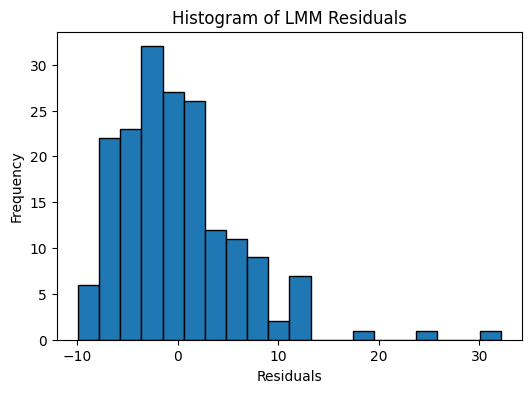

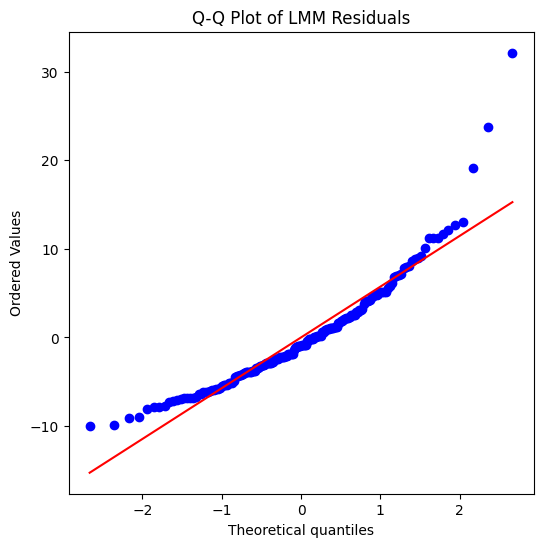

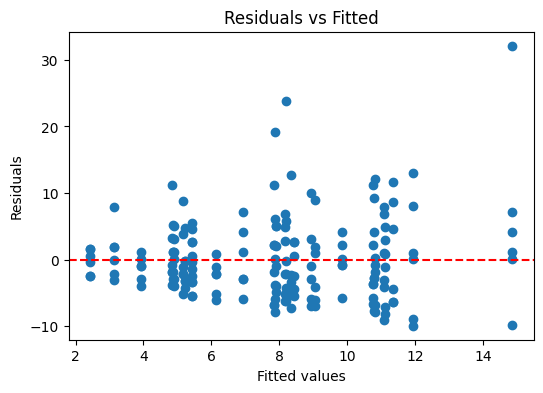

Shapiro-Wilk W = 0.9019
p = 0.000000


In [104]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Residuen und vorhergesagte Werte
residuals = lmm_results.resid
fitted = lmm_results.fittedvalues

# =========================
# Histogramm
# =========================
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20, edgecolor="black")
plt.title("Histogram of LMM Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# =========================
# Q-Q-Plot
# =========================
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of LMM Residuals")
plt.show()

# =========================
# Residuals vs Fitted
# =========================
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# =========================
# Shapiro-Wilk-Test
# =========================
shapiro = stats.shapiro(residuals)

print(f"Shapiro-Wilk W = {shapiro.statistic:.4f}")
print(f"p = {shapiro.pvalue:.6f}")

## 2. LMM with LOG Model checks

In [234]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ============================================================
# 1. Daten säubern
# ============================================================

df_clean = checks_per_trial.dropna(
    subset=["n_model_checks", "condition", "participant_id"]
).copy()

# Prüfen, ob alle Werte positiv sind
print("Minimum model checks:", df_clean["n_model_checks"].min())
print("Number of zeros:", (df_clean["n_model_checks"] == 0).sum())

if (df_clean["n_model_checks"] <= 0).any():
    raise ValueError(
        "Direct log transformation is not possible because "
        "n_model_checks contains zero or negative values."
    )

# ============================================================
# 2. Log-Transformation
# ============================================================

df_clean["log_model_checks"] = np.log(
    df_clean["n_model_checks"]
)

# ============================================================
# 3. Log-LMM fitten
# ============================================================

log_lmm_model = smf.mixedlm(
    "log_model_checks ~ C(condition, Treatment(reference='constant'))",
    data=df_clean,
    groups=df_clean["participant_id"],
)

log_lmm_results = log_lmm_model.fit()

# Modellzusammenfassung
print(log_lmm_results.summary())

# ============================================================
# 4. Paarweise Kontraste
# ============================================================

# Reihenfolge der Fixed Effects prüfen
print("\nFixed effects:")
print(log_lmm_results.fe_params.index.tolist())

contrasts = [
    ("Constant vs 0.7s delay", np.array([[0, 1, 0]])),
    ("Constant vs 2.0s delay", np.array([[0, 0, 1]])),
    ("0.7s delay vs 2.0s delay", np.array([[0, -1, 1]])),
]

results_list = []

for name, matrix in contrasts:

    test = log_lmm_results.t_test(matrix)

    coef = float(np.squeeze(test.effect))
    stderr = float(np.squeeze(test.sd))
    z_stat = float(np.squeeze(test.tvalue))
    p_uncorr = float(np.squeeze(test.pvalue))

    # Bonferroni-Korrektur
    p_bonf = min(p_uncorr * 3, 1.0)

    # Rücktransformation des Log-Koeffizienten
    ratio = np.exp(coef)
    percent_change = (ratio - 1) * 100

    results_list.append(
        {
            "Comparison": name,
            "Log Coef": round(coef, 4),
            "Std.Err": round(stderr, 4),
            "z": round(z_stat, 4),
            "Ratio exp(beta)": round(ratio, 4),
            "Percent change": round(percent_change, 2),
            "p (uncorrected)": (
                f"{p_uncorr:.5f}"
                if p_uncorr >= 0.0001
                else "< 0.0001"
            ),
            "p (Bonferroni)": (
                f"{p_bonf:.5f}"
                if p_bonf >= 0.0001
                else "< 0.0001"
            ),
            "Significant?": (
                "Ja" if p_bonf < 0.05 else "Nein"
            ),
        }
    )

df_pairwise_log = pd.DataFrame(results_list)

print(
    "\n=============================================================================="
)
print("PAARVERGLEICHE DES LOG-LMM MIT BONFERRONI")
print(
    "=============================================================================="
)
print(df_pairwise_log.to_string(index=False))

Minimum model checks: 0
Number of zeros: 9


ValueError: Direct log transformation is not possible because n_model_checks contains zero or negative values.

## Whcih trials have 0

In [235]:
df_clean.loc[
    df_clean["n_model_checks"] == 0
]

,participant_id,model_name,condition,n_model_checks
22,10,C1M5F,0.7s delay,0
108,6,C1M1F,2.0s delay,0
127,7,C1M2A,2.0s delay,0
130,7,C1M5F,0.7s delay,0
144,8,C1M1F,2.0s delay,0
162,9,C1M1F,0.7s delay,0
163,9,C1M2A,2.0s delay,0
164,9,C1M3F,2.0s delay,0
167,9,C1M6A,0.7s delay,0


Lets try LOG LMM for real

In [236]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ============================================================
# 1. Daten säubern
# ============================================================

df_clean = checks_per_trial.dropna(
    subset=["n_model_checks", "condition", "participant_id"]
).copy()

# ============================================================
# 2. LOG(x+1)-Transformation
# ============================================================

df_clean["log_model_checks"] = np.log1p(
    df_clean["n_model_checks"]
)

# ============================================================
# 3. LOG(x+1)-LMM
# ============================================================

lmm_model = smf.mixedlm(
    "log_model_checks ~ C(condition, Treatment(reference='constant'))",
    data=df_clean,
    groups=df_clean["participant_id"],
)

lmm_results = lmm_model.fit()

# ============================================================
# 4. Modell Summary
# ============================================================

print(lmm_results.summary())

# ============================================================
# 5. Paarweise Kontraste
# ============================================================

contrasts = [
    ("Constant vs 0.7s delay", np.array([[0, 1, 0]])),
    ("Constant vs 2.0s delay", np.array([[0, 0, 1]])),
    ("0.7s delay vs 2.0s delay", np.array([[0, -1, 1]])),
]

results_list = []

for name, matrix in contrasts:

    test = lmm_results.t_test(matrix)

    coef = float(np.squeeze(test.effect))
    stderr = float(np.squeeze(test.sd))
    z_stat = float(np.squeeze(test.tvalue))
    p_uncorr = float(np.squeeze(test.pvalue))

    p_bonf = min(p_uncorr * 3, 1.0)

    results_list.append(
        {
            "Comparison": name,
            "Coef (log scale)": round(coef, 4),
            "Std.Err": round(stderr, 4),
            "z": round(z_stat, 4),
            "p (uncorrected)": (
                f"{p_uncorr:.5f}" if p_uncorr >= 0.0001 else "<0.0001"
            ),
            "p (Bonferroni)": (
                f"{p_bonf:.5f}" if p_bonf >= 0.0001 else "<0.0001"
            ),
            "Significant?": "Ja" if p_bonf < 0.05 else "Nein",
        }
    )

df_pairwise = pd.DataFrame(results_list)

print(
    "\n============================================================"
)
print("PAIRWISE COMPARISONS (LOG(x+1)-LMM)")
print(
    "============================================================"
)
print(df_pairwise.to_string(index=False))

                                Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              log_model_checks
No. Observations:               180                  Method:                          REML            
No. Groups:                     10                   Scale:                           0.5046          
Min. group size:                18                   Log-Likelihood:                  -202.0148       
Max. group size:                18                   Converged:                       Yes             
Mean group size:                18.0                                                                  
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

Shapiro-Wilk W = 0.9838
p = 0.035374


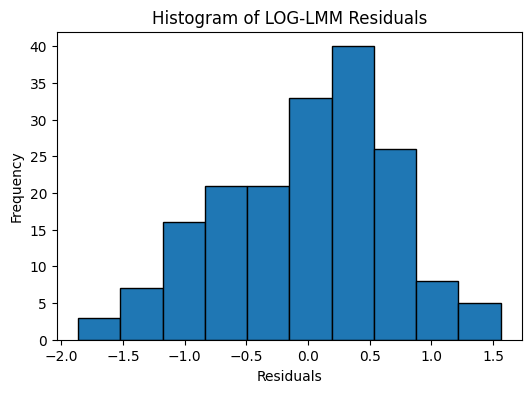

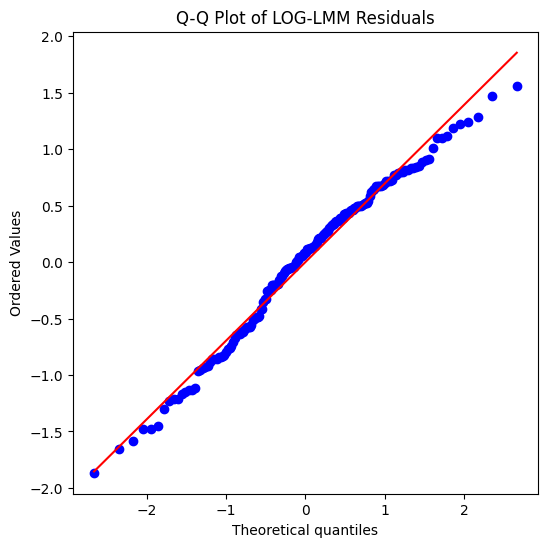

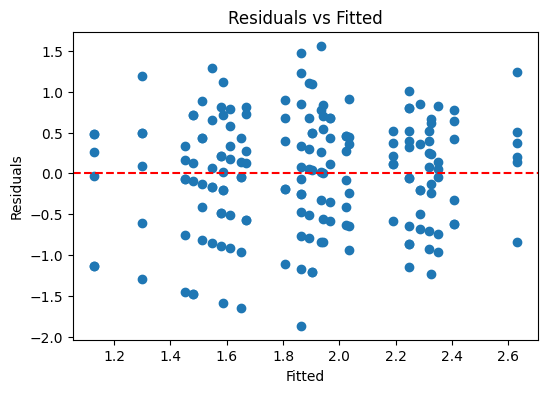

In [237]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Residuen des LOG-LMM
residuals = lmm_results.resid.dropna()
fitted = lmm_results.fittedvalues

# -----------------------------
# Shapiro-Wilk
# -----------------------------
sw_stat, sw_pvalue = stats.shapiro(residuals)

print(f"Shapiro-Wilk W = {sw_stat:.4f}")
print(f"p = {sw_pvalue:.6f}")

# -----------------------------
# Histogramm
# -----------------------------
plt.figure(figsize=(6,4))
plt.hist(residuals, bins="auto", edgecolor="black")
plt.title("Histogram of LOG-LMM Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# QQ Plot
# -----------------------------
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of LOG-LMM Residuals")
plt.show()

# -----------------------------
# Residuals vs Fitted
# -----------------------------
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(0,color="red",linestyle="--")
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

## FINAL LMM MIT LOG WEGEN NORMALVERTEILUNG

Minimum number of model checks: 0
Maximum number of model checks: 47
Number of zero values: 9
                                Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              log_model_checks
No. Observations:               180                  Method:                          REML            
No. Groups:                     10                   Scale:                           0.5046          
Min. group size:                18                   Log-Likelihood:                  -202.0148       
Max. group size:                18                   Converged:                       Yes             
Mean group size:                18.0                                                                  
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------

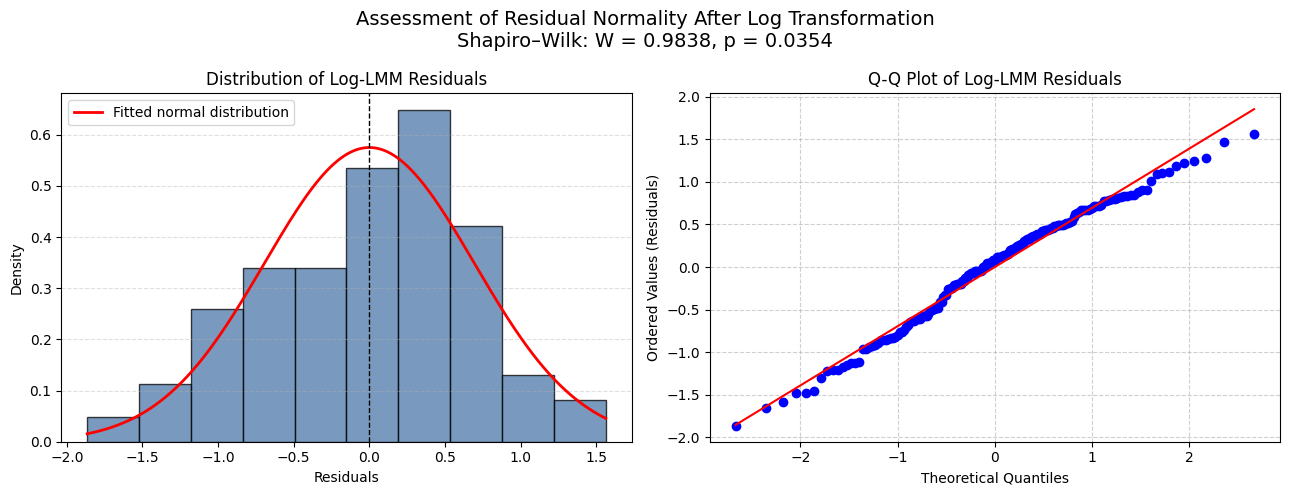

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf

# ======================================================
# 1. Prepare data
# ======================================================

df_clean = checks_per_trial.dropna(
    subset=["n_model_checks", "condition", "participant_id"]
).copy()

# Check count range
print("Minimum number of model checks:",
      df_clean["n_model_checks"].min())

print("Maximum number of model checks:",
      df_clean["n_model_checks"].max())

print("Number of zero values:",
      (df_clean["n_model_checks"] == 0).sum())

# log(x + 1), because log(0) is undefined
df_clean["log_model_checks"] = np.log1p(
    df_clean["n_model_checks"]
)

# ======================================================
# 2. Fit LMM using log-transformed model checks
# ======================================================

log_lmm_model = smf.mixedlm(
    """
    log_model_checks
    ~ C(condition, Treatment(reference='constant'))
    """,
    data=df_clean,
    groups=df_clean["participant_id"]
)

log_lmm_results = log_lmm_model.fit()

print(log_lmm_results.summary())

# ======================================================
# 3. Pairwise contrasts
# ======================================================

# Coefficient order:
# 1. Intercept
# 2. 0.7s delay relative to constant
# 3. 2.0s delay relative to constant

contrasts = [
    (
        "0.7s delay minus constant",
        np.array([[0, 1, 0]])
    ),
    (
        "2.0s delay minus constant",
        np.array([[0, 0, 1]])
    ),
    (
        "2.0s delay minus 0.7s delay",
        np.array([[0, -1, 1]])
    ),
]

results_list = []

for name, matrix in contrasts:

    test = log_lmm_results.t_test(matrix)

    coef = float(np.squeeze(test.effect))
    stderr = float(np.squeeze(test.sd))
    z_stat = float(np.squeeze(test.tvalue))
    p_uncorr = float(np.squeeze(test.pvalue))

    # Bonferroni correction for three comparisons
    p_bonf = min(p_uncorr * 3, 1.0)

    # Back-transformation
    ratio_plus_one = np.exp(coef)

    results_list.append(
        {
            "Comparison": name,
            "Coef (log scale)": round(coef, 4),
            "exp(Coef)": round(ratio_plus_one, 4),
            "Std.Err": round(stderr, 4),
            "z": round(z_stat, 4),
            "p (uncorrected)": (
                f"{p_uncorr:.5f}"
                if p_uncorr >= 0.0001
                else "< 0.0001"
            ),
            "p (Bonferroni)": (
                f"{p_bonf:.5f}"
                if p_bonf >= 0.0001
                else "< 0.0001"
            ),
            "Significant?": (
                "Yes" if p_bonf < 0.05 else "No"
            ),
        }
    )

df_pairwise_log = pd.DataFrame(results_list)

print(
    "\n=================================================="
)
print("PAIRWISE COMPARISONS: LOG-TRANSFORMED LMM")
print(
    "=================================================="
)
print(df_pairwise_log.to_string(index=False))

# ======================================================
# 4. Check residual normality again
# ======================================================

log_residuals = log_lmm_results.resid.dropna()

sw_stat, sw_pvalue = stats.shapiro(log_residuals)

print(
    "\n--- SHAPIRO-WILK TEST ON LOG-LMM RESIDUALS ---"
)
print(f"W-Statistic: {sw_stat:.4f}")

print(
    f"p-value: {sw_pvalue:.5f}"
    if sw_pvalue >= 0.0001
    else "p-value: < 0.0001"
)

# ======================================================
# 5. Histogram and Q-Q plot
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(
    log_residuals,
    bins="auto",
    density=True,
    color="#4C78A8",
    edgecolor="black",
    alpha=0.75
)

residual_mean = np.mean(log_residuals)
residual_sd = np.std(log_residuals, ddof=1)

x = np.linspace(
    log_residuals.min(),
    log_residuals.max(),
    500
)

normal_density = stats.norm.pdf(
    x,
    loc=residual_mean,
    scale=residual_sd
)

axes[0].plot(
    x,
    normal_density,
    color="red",
    linewidth=2,
    label="Fitted normal distribution"
)

axes[0].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

axes[0].set_title(
    "Distribution of Log-LMM Residuals"
)
axes[0].set_xlabel("Residuals")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Q-Q plot
stats.probplot(
    log_residuals,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of Log-LMM Residuals"
)
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Ordered Values (Residuals)")
axes[1].grid(
    True,
    linestyle="--",
    alpha=0.6
)

p_text = (
    f"= {sw_pvalue:.4f}"
    if sw_pvalue >= 0.0001
    else "< .0001"
)

fig.suptitle(
    "Assessment of Residual Normality After Log Transformation\n"
    f"Shapiro–Wilk: W = {sw_stat:.4f}, p {p_text}",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [106]:
# Berechnet M (Mean) und SD (Std) pro Bedingung
checks_per_trial.groupby("condition")["n_model_checks"].agg(
    ["mean", "std"]
).round(2)

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/3485867516.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  checks_per_trial.groupby("condition")["n_model_checks"].agg(


,mean,std
condition,,
constant,10.80,7.88
0.7s delay,7.88,6.77
2.0s delay,4.88,4.13


## Sampling Time - MODEL DWELL TIME

### Prepare clean data + and calculate the data

In [107]:
# =======================================================
# 1) PREPARE CLEAN MODEL DWELL DATA
# =======================================================

import numpy as np
import pandas as pd

# Condition order
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

# Create working copy
model_dwell_data = object_gazes_final.copy()

# Standardize relevant columns
model_dwell_data["participant_id"] = model_dwell_data["participant_id"].astype(str).str.strip()
model_dwell_data["model_name"] = model_dwell_data["model_name"].astype(str).str.strip()
model_dwell_data["condition"] = model_dwell_data["condition"].astype(str).str.strip()
model_dwell_data["AOI_CLEAN"] = model_dwell_data["AOI_CLEAN"].astype(str).str.strip().str.upper()

# Keep only expected conditions
model_dwell_data = model_dwell_data[
    model_dwell_data["condition"].isin(COND_ORDER)
].copy()

# Keep only clean MODEL gazes
model_dwell_model_only = model_dwell_data[
    model_dwell_data["AOI_CLEAN"] == "MODEL"
].copy()

print("All clean dwell data shape:", model_dwell_data.shape)
print("MODEL-only dwell data shape:", model_dwell_model_only.shape)

display(
    model_dwell_model_only[
        ["participant_id", "model_name", "condition", "AOI_CLEAN", "object_gaze_duration_ms"]
    ].head()
)

All clean dwell data shape: (22841, 43)
MODEL-only dwell data shape: (1732, 43)


,participant_id,model_name,condition,AOI_CLEAN,object_gaze_duration_ms
401,1,C3M2A,constant,MODEL,10288.0
414,1,C3M2A,constant,MODEL,3590.0
420,1,C3M2A,constant,MODEL,122.0
421,1,C3M2A,constant,MODEL,1568.0
439,1,C3M2A,constant,MODEL,1599.0


### Compute raw model dwell per trial ( hätte man mit is valid model auch machen können)

In [108]:
# =======================================================
# 2) COMPUTE RAW MODEL DWELL TIME PER TRIAL
# =======================================================

raw_model_dwell_per_trial = (
    model_dwell_model_only
    .groupby(["participant_id", "model_name", "condition"], as_index=False)
    .agg(
        raw_model_dwell_ms=("object_gaze_duration_ms", "sum"),
        n_model_gazes=("object_gaze_duration_ms", "count"),
        mean_model_gaze_duration_ms=("object_gaze_duration_ms", "mean"),
        median_model_gaze_duration_ms=("object_gaze_duration_ms", "median")
    )
)

# Convert milliseconds to seconds
raw_model_dwell_per_trial["raw_model_dwell_s"] = (
    raw_model_dwell_per_trial["raw_model_dwell_ms"] / 1000
)

# Set condition order
raw_model_dwell_per_trial["condition"] = pd.Categorical(
    raw_model_dwell_per_trial["condition"],
    categories=COND_ORDER,
    ordered=True
)

print("Raw MODEL dwell time per trial:")
display(raw_model_dwell_per_trial.head(20))

print("Trials per condition:")
display(raw_model_dwell_per_trial["condition"].value_counts())

Raw MODEL dwell time per trial:


,participant_id,model_name,condition,raw_model_dwell_ms,n_model_gazes,mean_model_gaze_duration_ms,median_model_gaze_duration_ms,raw_model_dwell_s
0,1,C1M1F,0.7s delay,3891.0,3,1297.000000,1556.0,3.891
1,1,C1M2A,constant,6700.0,4,1675.000000,783.0,6.700
2,1,C1M3F,constant,2721.0,4,680.250000,650.0,2.721
3,1,C1M4A,0.7s delay,10268.0,5,2053.600000,1279.0,10.268
4,1,C1M5F,2.0s delay,5538.0,2,2769.000000,2769.0,5.538
5,1,C1M6A,2.0s delay,13866.0,6,2311.000000,2555.0,13.866
6,1,C2M1F,2.0s delay,19911.0,6,3318.500000,3049.5,19.911
7,1,C2M2A,2.0s delay,32247.0,8,4030.875000,4284.5,32.247
8,1,C2M3F,0.7s delay,21356.0,7,3050.857143,2777.0,21.356
9,1,C2M4A,0.7s delay,19543.0,10,1954.300000,1499.5,19.543


Trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64

## Plot raw dwell time per trial

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/2126329428.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


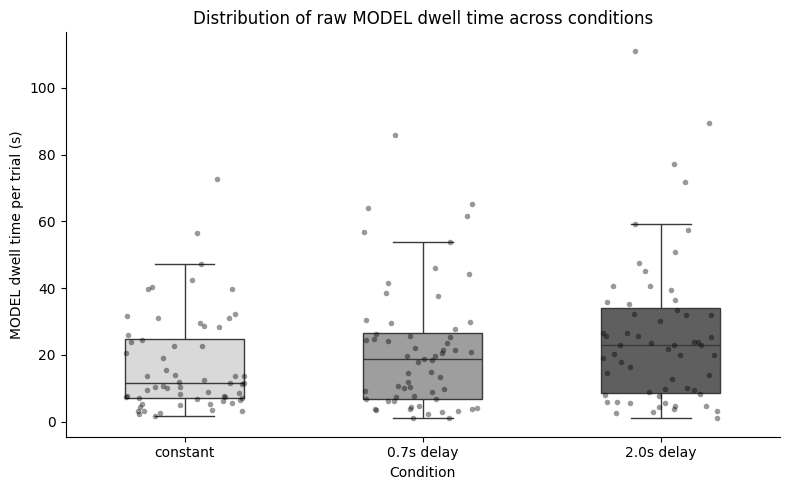

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=raw_model_dwell_per_trial,
    x="condition",
    y="raw_model_dwell_s",
    order=["constant", "0.7s delay", "2.0s delay"],
    palette=palette,
    showfliers=False,
    width=0.5
)

sns.stripplot(
    data=raw_model_dwell_per_trial,
    x="condition",
    y="raw_model_dwell_s",
    order=["constant", "0.7s delay", "2.0s delay"],
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25
)

plt.xlabel("Condition")
plt.ylabel("MODEL dwell time per trial (s)")
plt.title("Distribution of raw MODEL dwell time across conditions")

sns.despine()
plt.tight_layout()
plt.show()

## DELAY CORRECTION FOR MODEL DWELL TIME
###  Compute number of MODEL_PLATE episodes per trial for delay correction

In [110]:
# =======================================================
# 3) IDENTIFY MODEL_PLATE EPISODES FOR DELAY CORRECTION
# =======================================================

model_plate_episodes = object_gazes_final.copy()

# Clean relevant columns
model_plate_episodes["participant_id"] = (
    model_plate_episodes["participant_id"]
    .astype(str)
    .str.strip()
)

model_plate_episodes["model_name"] = (
    model_plate_episodes["model_name"]
    .astype(str)
    .str.strip()
)

model_plate_episodes["condition"] = (
    model_plate_episodes["condition"]
    .astype(str)
    .str.strip()
)

model_plate_episodes["AOI_CLEAN"] = (
    model_plate_episodes["AOI_CLEAN"]
    .astype(str)
    .str.strip()
    .str.upper()
)

model_plate_episodes["object_name_corr"] = (
    model_plate_episodes["object_name_corr"]
    .astype(str)
    .str.strip()
)

# Keep only Model_plate episodes inside MODEL AOI
model_plate_episodes = model_plate_episodes[
    (model_plate_episodes["AOI_CLEAN"] == "MODEL") &
    (model_plate_episodes["object_name_corr"] == "Model_plate") &
    (model_plate_episodes["condition"].isin(COND_ORDER))
].copy()

print("Number of Model_plate episodes used for delay correction:")
print(len(model_plate_episodes))

display(
    model_plate_episodes[
        [
            "participant_id",
            "model_name",
            "condition",
            "object_gaze_duration_s"
        ]
    ].head(20)
)

Number of Model_plate episodes used for delay correction:
1687


,participant_id,model_name,condition,object_gaze_duration_s
401,1,C3M2A,constant,10.288
414,1,C3M2A,constant,3.590
420,1,C3M2A,constant,0.122
421,1,C3M2A,constant,1.568
439,1,C3M2A,constant,1.599
453,1,C3M2A,constant,7.555
467,1,C3M2A,constant,0.634
475,1,C3M2A,constant,0.678
482,1,C3M2A,constant,6.589
487,1,C3M2A,constant,3.388


### Combine raw dwell time with delay correction information

In [111]:
# =======================================================
# 4) ASSIGN CONDITION-SPECIFIC DELAY
# =======================================================

DELAY_S = {
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0
}

model_plate_episodes["delay_s"] = (
    model_plate_episodes["condition"]
    .map(DELAY_S)
)

### Compute delay time per model_plate episode

In [112]:
import numpy as np

# =======================================================
# 5) COMPUTE ACTUAL DELAY TIME PER MODEL_PLATE EPISODE
# =======================================================

model_plate_episodes["actual_delay_time_s"] = np.minimum(
    model_plate_episodes["object_gaze_duration_s"],
    model_plate_episodes["delay_s"]
)

### sum delay time per trial

In [113]:
# =======================================================
# 6) SUM DELAY TIME PER TRIAL
# =======================================================

delay_correction_per_trial = (
    model_plate_episodes
    .groupby(
        ["participant_id", "model_name", "condition"],
        as_index=False
    )
    .agg(
        n_model_plate_episodes=(
            "object_gaze_duration_s",
            "size"
        ),
        delay_correction_s=(
            "actual_delay_time_s",
            "sum"
        )
    )
)

display(delay_correction_per_trial.head(20))

,participant_id,model_name,condition,n_model_plate_episodes,delay_correction_s
0,1,C1M1F,0.7s delay,3,1.679
1,1,C1M2A,constant,4,0.000
2,1,C1M3F,constant,4,0.000
3,1,C1M4A,0.7s delay,5,3.500
4,1,C1M5F,2.0s delay,2,4.000
5,1,C1M6A,2.0s delay,5,8.355
6,1,C2M1F,2.0s delay,6,10.342
7,1,C2M2A,2.0s delay,8,14.555
8,1,C2M3F,0.7s delay,7,4.900
9,1,C2M4A,0.7s delay,10,6.755


### Merge with raw model dwell time

In [114]:
# =======================================================
# 7) MERGE RAW MODEL DWELL WITH DELAY CORRECTION
# =======================================================

model_dwell_per_trial = raw_model_dwell_per_trial.merge(
    delay_correction_per_trial,
    on=[
        "participant_id",
        "model_name",
        "condition"
    ],
    how="left"
)

# Trials without Model_plate episodes:
# no delay time to subtract
model_dwell_per_trial["n_model_plate_episodes"] = (
    model_dwell_per_trial["n_model_plate_episodes"]
    .fillna(0)
    .astype(int)
)

model_dwell_per_trial["delay_correction_s"] = (
    model_dwell_per_trial["delay_correction_s"]
    .fillna(0.0)
)

## compute delay corrected dwell time

In [115]:
# =======================================================
# 8) COMPUTE DELAY-CORRECTED MODEL DWELL TIME
# =======================================================

model_dwell_per_trial["corrected_model_dwell_s"] = (
    model_dwell_per_trial["raw_model_dwell_s"]
    -
    model_dwell_per_trial["delay_correction_s"]
)

## safety check

In [116]:
model_dwell_per_trial["corrected_model_dwell_s"] = (
    model_dwell_per_trial["corrected_model_dwell_s"]
    .clip(lower=0)
)

In [117]:
negative_cases = model_dwell_per_trial[
    model_dwell_per_trial["corrected_model_dwell_s"] < 0
]

print("Negative corrected dwell-time cases:")
print(len(negative_cases))

display(negative_cases)

Negative corrected dwell-time cases:
0


,participant_id,model_name,condition,raw_model_dwell_ms,n_model_gazes,mean_model_gaze_duration_ms,median_model_gaze_duration_ms,raw_model_dwell_s,n_model_plate_episodes,delay_correction_s,corrected_model_dwell_s


# Show raw model dwell vs delay corrected model dwell

In [118]:
plot_dwell = model_dwell_per_trial.copy()

plot_dwell_long = plot_dwell.melt(
    id_vars=["participant_id", "model_name", "condition"],
    value_vars=["raw_model_dwell_s", "corrected_model_dwell_s"],
    var_name="dwell_type",
    value_name="dwell_time_s"
)

plot_dwell_long["dwell_type"] = plot_dwell_long["dwell_type"].replace({
    "raw_model_dwell_s": "Raw",
    "corrected_model_dwell_s": "Delay-corrected"
})

display(plot_dwell_long.head())

,participant_id,model_name,condition,dwell_type,dwell_time_s
0,1,C1M1F,0.7s delay,Raw,3.891
1,1,C1M2A,constant,Raw,6.700
2,1,C1M3F,constant,Raw,2.721
3,1,C1M4A,0.7s delay,Raw,10.268
4,1,C1M5F,2.0s delay,Raw,5.538


In [119]:
display(
    model_dwell_per_trial[
        [
            "participant_id",
            "model_name",
            "condition",
            "raw_model_dwell_s",
            "n_model_plate_episodes",
            "delay_correction_s",
            "corrected_model_dwell_s"
        ]
    ].head(20)
)

,participant_id,model_name,condition,raw_model_dwell_s,n_model_plate_episodes,delay_correction_s,corrected_model_dwell_s
0,1,C1M1F,0.7s delay,3.891,3,1.679,2.212
1,1,C1M2A,constant,6.700,4,0.000,6.700
2,1,C1M3F,constant,2.721,4,0.000,2.721
3,1,C1M4A,0.7s delay,10.268,5,3.500,6.768
4,1,C1M5F,2.0s delay,5.538,2,4.000,1.538
5,1,C1M6A,2.0s delay,13.866,5,8.355,5.511
6,1,C2M1F,2.0s delay,19.911,6,10.342,9.569
7,1,C2M2A,2.0s delay,32.247,8,14.555,17.692
8,1,C2M3F,0.7s delay,21.356,7,4.900,16.456
9,1,C2M4A,0.7s delay,19.543,10,6.755,12.788


## check whether it worked

In [120]:
print(
    model_dwell_per_trial[
        [
            "raw_model_dwell_s",
            "delay_correction_s",
            "corrected_model_dwell_s"
        ]
    ].head()
)

   raw_model_dwell_s  delay_correction_s  corrected_model_dwell_s
0              3.891               1.679                    2.212
1              6.700               0.000                    6.700
2              2.721               0.000                    2.721
3             10.268               3.500                    6.768
4              5.538               4.000                    1.538


## Comparison plot per trial data raw vs corrected

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/1750577290.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/1750577290.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


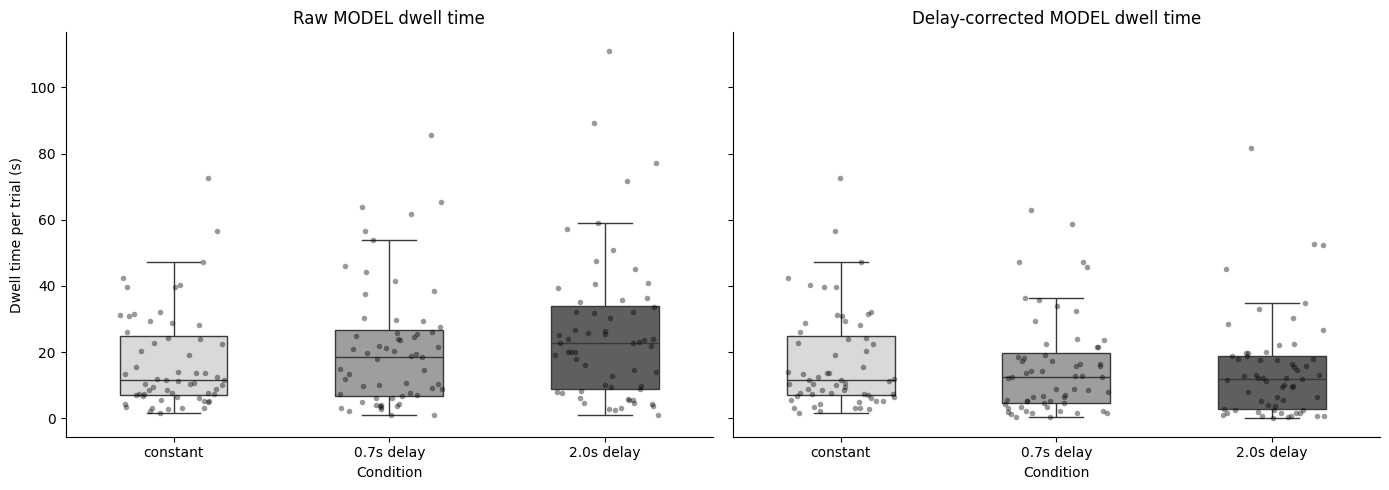

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

palette = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

# -----------------------
# Left: Raw dwell time
# -----------------------
sns.boxplot(
    data=plot_dwell_long[plot_dwell_long["dwell_type"] == "Raw"],
    x="condition",
    y="dwell_time_s",
    order=["constant", "0.7s delay", "2.0s delay"],
    palette=palette,
    showfliers=False,
    width=0.5,
    ax=axes[0]
)

sns.stripplot(
    data=plot_dwell_long[plot_dwell_long["dwell_type"] == "Raw"],
    x="condition",
    y="dwell_time_s",
    order=["constant", "0.7s delay", "2.0s delay"],
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25,
    ax=axes[0]
)

axes[0].set_title("Raw MODEL dwell time")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Dwell time per trial (s)")

# -----------------------
# Right: Corrected dwell time
# -----------------------
sns.boxplot(
    data=plot_dwell_long[plot_dwell_long["dwell_type"] == "Delay-corrected"],
    x="condition",
    y="dwell_time_s",
    order=["constant", "0.7s delay", "2.0s delay"],
    palette=palette,
    showfliers=False,
    width=0.5,
    ax=axes[1]
)

sns.stripplot(
    data=plot_dwell_long[plot_dwell_long["dwell_type"] == "Delay-corrected"],
    x="condition",
    y="dwell_time_s",
    order=["constant", "0.7s delay", "2.0s delay"],
    color="black",
    alpha=0.4,
    size=4,
    jitter=0.25,
    ax=axes[1]
)

axes[1].set_title("Delay-corrected MODEL dwell time")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

### Build participant-level averages for corrected MODEL dwell time

In [122]:
# =======================================================
# 7) BUILD PARTICIPANT-LEVEL AVERAGES FOR MODEL DWELL TIME
# =======================================================

model_dwell_avg = (
    model_dwell_per_trial
    .groupby(["participant_id", "condition"], as_index=False, observed=False)
    .agg(
        avg_raw_model_dwell_s=("raw_model_dwell_s", "mean"),
        avg_corrected_model_dwell_s=("corrected_model_dwell_s", "mean"),
        avg_delay_correction_s=("delay_correction_s", "mean"),
        n_trials=("model_name", "nunique")
    )
)

model_dwell_avg["condition"] = pd.Categorical(
    model_dwell_avg["condition"],
    categories=COND_ORDER,
    ordered=True
)

model_dwell_avg = model_dwell_avg.sort_values(
    ["participant_id", "condition"]
)

print("Participant-level MODEL dwell averages:")
display(model_dwell_avg.head(30))

Participant-level MODEL dwell averages:


,participant_id,condition,avg_raw_model_dwell_s,avg_corrected_model_dwell_s,avg_delay_correction_s,n_trials
2,1,constant,18.861500,18.861500,0.000000,6
0,1,0.7s delay,21.031333,14.987000,6.044333,6
1,1,2.0s delay,24.654000,12.113833,12.540167,6
5,10,constant,10.574833,10.574833,0.000000,6
3,10,0.7s delay,18.231167,11.901500,6.329667,6
4,10,2.0s delay,19.108333,9.276167,9.832167,6
8,2,constant,18.927667,18.927667,0.000000,6
6,2,0.7s delay,27.149667,18.864667,8.285000,6
7,2,2.0s delay,28.618833,18.552000,10.066833,6
11,3,constant,24.942667,24.942667,0.000000,6


### Build group summary for MODEL dwell time

In [123]:
# =======================================================
# 8) BUILD GROUP SUMMARY FOR MODEL DWELL TIME
# =======================================================

model_dwell_group_summary = (
    model_dwell_avg
    .groupby("condition", as_index=False, observed=False)
    .agg(
        mean_raw_model_dwell_s=("avg_raw_model_dwell_s", "mean"),
        sd_raw_model_dwell_s=("avg_raw_model_dwell_s", "std"),
        mean_corrected_model_dwell_s=("avg_corrected_model_dwell_s", "mean"),
        sd_corrected_model_dwell_s=("avg_corrected_model_dwell_s", "std"),
        mean_delay_correction_s=("avg_delay_correction_s", "mean"),
        n_participants=("participant_id", "nunique")
    )
)

model_dwell_group_summary["se_raw_model_dwell_s"] = (
    model_dwell_group_summary["sd_raw_model_dwell_s"] /
    np.sqrt(model_dwell_group_summary["n_participants"])
)

model_dwell_group_summary["se_corrected_model_dwell_s"] = (
    model_dwell_group_summary["sd_corrected_model_dwell_s"] /
    np.sqrt(model_dwell_group_summary["n_participants"])
)

model_dwell_group_summary = model_dwell_group_summary.sort_values("condition")

print("Group summary for MODEL dwell time:")
display(model_dwell_group_summary)

Group summary for MODEL dwell time:


,condition,mean_raw_model_dwell_s,sd_raw_model_dwell_s,mean_corrected_model_dwell_s,sd_corrected_model_dwell_s,mean_delay_correction_s,n_participants,se_raw_model_dwell_s,se_corrected_model_dwell_s
0,constant,17.096183,4.846941,17.096183,4.846941,0.00000,10,1.532737,1.532737
1,0.7s delay,21.343117,6.364842,15.391167,5.262668,5.95195,10,2.012740,1.664202
2,2.0s delay,25.931250,6.367832,14.563300,4.575916,11.36795,10,2.013685,1.447032


# Show participants trajectories across conditions

Group mean data used for black line:


,condition,group_mean_corrected_model_dwell_s,condition_label
0,constant,17.096183,constant
1,0.7s delay,15.391167,0.7s
2,2.0s delay,14.563300,2.0s


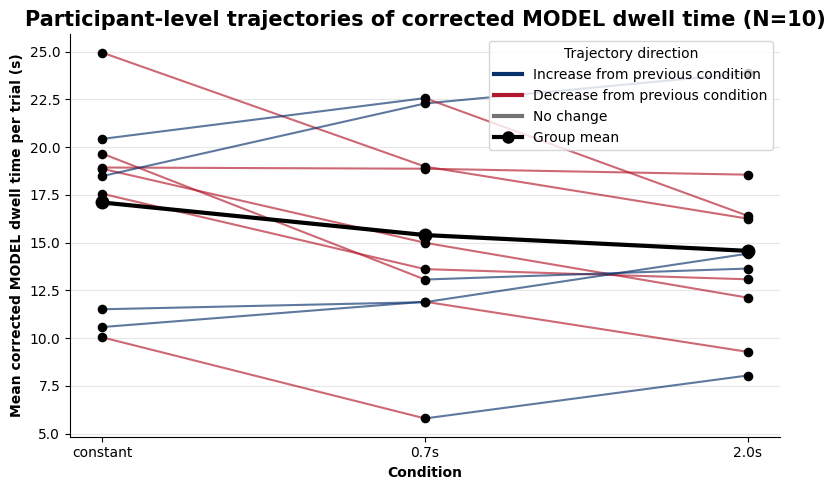

In [124]:
# =======================================================
# PARTICIPANT-LEVEL TRAJECTORIES:
# DELAY-CORRECTED MODEL DWELL TIME
# =======================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"   # dark blue
COL_DECREASE = "#b2182b"   # dark red
COL_EQUAL = "#737373"      # gray for no change
COL_MEAN = "black"

# =====================
# Prepare data
# =====================

plot_data = model_dwell_avg.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

# Number of participants included
n_participants = plot_data["participant_id"].nunique()

x = np.arange(len(COND_ORDER))

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    # Only plot participants who have all three conditions
    if len(sub) != 3:
        continue

    y = sub["avg_corrected_model_dwell_s"].values

    # Points
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # Segment 1: constant -> 0.7s delay
    diff1 = y[1] - y[0]

    if diff1 > 0:
        color1 = COL_INCREASE
    elif diff1 < 0:
        color1 = COL_DECREASE
    else:
        color1 = COL_EQUAL

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # Segment 2: 0.7s delay -> 2.0s delay
    diff2 = y[2] - y[1]

    if diff2 > 0:
        color2 = COL_INCREASE
    elif diff2 < 0:
        color2 = COL_DECREASE
    else:
        color2 = COL_EQUAL

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# =====================
# Group mean
# =====================

group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_corrected_model_dwell_s"]
    .mean()
    .reindex(COND_ORDER)
)

# =====================
# Group mean data
# =====================

group_mean_data = (
    group_means
    .reset_index()
    .rename(columns={
        "condition": "condition",
        "avg_corrected_model_dwell_s": "group_mean_corrected_model_dwell_s"
    })
)

group_mean_data["condition_label"] = COND_LABELS

print("Group mean data used for black line:")
display(group_mean_data)

ax.plot(
    x,
    group_means.values,
    color=COL_MEAN,
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

# =====================
# Legend
# =====================

legend_elements = [
    Line2D(
        [0], [0],
        color=COL_INCREASE,
        lw=3,
        label="Increase from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_EQUAL,
        lw=3,
        label="No change"
    ),
    Line2D(
        [0], [0],
        color=COL_MEAN,
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper right"
)

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel(
    "Mean corrected MODEL dwell time per trial (s)",
    fontweight="bold"
)

ax.set_title(
    f"Participant-level trajectories of corrected MODEL dwell time (N={n_participants})",
    fontweight="bold",
    fontsize=15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

#### Participant model dwell time trajectories nicer plot

In [125]:
# =====================
# Legend
# =====================

legend_elements = [
    Line2D([0], [0], color=COL_INCREASE, lw=3, label="Increase"),
    Line2D([0], [0], color=COL_DECREASE, lw=3, label="Decrease"),
    Line2D([0], [0], color=COL_EQUAL, lw=3, label="No change"),
    Line2D(
        [0], [0],
        color=COL_MEAN,
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

# Figure-level legend: horizontal and outside the axes
fig.legend(
    handles=legend_elements,
    title="Change from previous condition",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.89),
    ncol=4,
    frameon=False,
    handlelength=2.2,
    columnspacing=1.8
)

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel(
    "Mean corrected MODEL dwell time per trial (s)",
    fontweight="bold"
)

# Figure-level title above the legend
fig.suptitle(
    f"Participant-level trajectories of corrected MODEL dwell time "
    f"(N={n_participants})",
    fontweight="bold",
    fontsize=15,
    y=0.98
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    color="#d9d9d9",
    linewidth=0.8,
    alpha=0.7
)

# Reserve space above the axes for title and legend
plt.tight_layout(rect=[0, 0, 1, 0.76])

plt.show()
plt.close(fig)

<Figure size 640x480 with 0 Axes>

## schönerer Plot

Group mean data used for black line:


,condition,group_mean_corrected_model_dwell_s,condition_label
0,constant,17.096183,constant
1,0.7s delay,15.391167,0.7s
2,2.0s delay,14.563300,2.0s


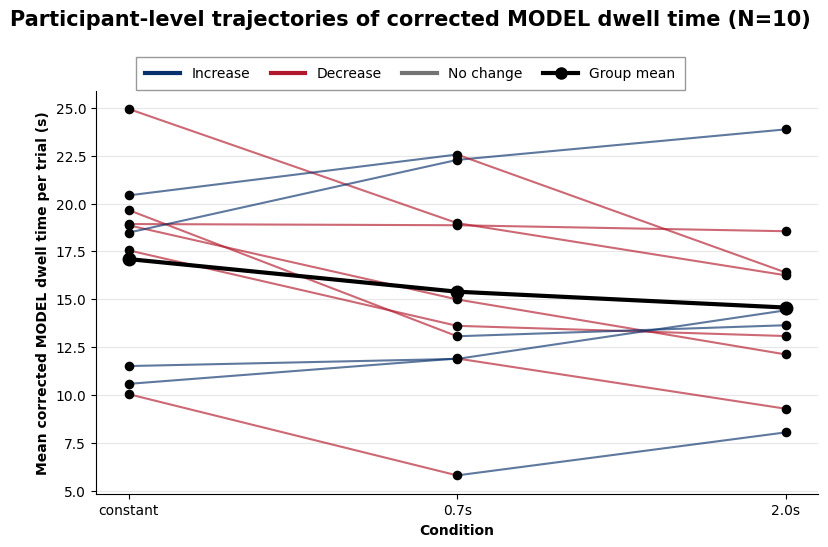

In [126]:
# =======================================================
# PARTICIPANT-LEVEL TRAJECTORIES:
# DELAY-CORRECTED MODEL DWELL TIME
# =======================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"
COL_DECREASE = "#b2182b"
COL_EQUAL = "#737373"
COL_MEAN = "black"


# =====================
# Prepare data
# =====================

plot_data = model_dwell_avg.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)


# Keep only participants with all three conditions
complete_participants = (
    plot_data
    .groupby("participant_id", observed=False)["condition"]
    .nunique()
)

complete_participants = complete_participants[
    complete_participants == len(COND_ORDER)
].index

plot_data = plot_data[
    plot_data["participant_id"].isin(complete_participants)
].copy()


# Number of participants actually shown
n_participants = plot_data["participant_id"].nunique()

x = np.arange(len(COND_ORDER))


# =====================
# Create figure
# =====================

fig, ax = plt.subplots(
    figsize=(8.5, 5.8)
)


# =====================
# Participant trajectories
# =====================

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    y = sub["avg_corrected_model_dwell_s"].values


    # Participant points
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )


    # ---------------------
    # Segment 1:
    # constant -> 0.7s
    # ---------------------

    diff1 = y[1] - y[0]

    if diff1 > 0:
        color1 = COL_INCREASE
    elif diff1 < 0:
        color1 = COL_DECREASE
    else:
        color1 = COL_EQUAL

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65,
        zorder=2
    )


    # ---------------------
    # Segment 2:
    # 0.7s -> 2.0s
    # ---------------------

    diff2 = y[2] - y[1]

    if diff2 > 0:
        color2 = COL_INCREASE
    elif diff2 < 0:
        color2 = COL_DECREASE
    else:
        color2 = COL_EQUAL

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65,
        zorder=2
    )


# =====================
# Group mean
# =====================

group_means = (
    plot_data
    .groupby(
        "condition",
        observed=False
    )["avg_corrected_model_dwell_s"]
    .mean()
    .reindex(COND_ORDER)
)


# =====================
# Group mean data
# =====================

group_mean_data = (
    group_means
    .reset_index()
    .rename(
        columns={
            "avg_corrected_model_dwell_s":
            "group_mean_corrected_model_dwell_s"
        }
    )
)

group_mean_data["condition_label"] = COND_LABELS

print("Group mean data used for black line:")
display(group_mean_data)


# Plot group mean
ax.plot(
    x,
    group_means.values,
    color=COL_MEAN,
    linewidth=3,
    marker="o",
    markersize=9,
    zorder=4
)


# =====================
# Legend
# =====================

legend_elements = [

    Line2D(
        [0], [0],
        color=COL_INCREASE,
        lw=3,
        label="Increase"
    ),

    Line2D(
        [0], [0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease"
    ),

    Line2D(
        [0], [0],
        color=COL_EQUAL,
        lw=3,
        label="No change"
    ),

    Line2D(
        [0], [0],
        color=COL_MEAN,
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]


fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.885),
    ncol=4,
    frameon=True,
    fancybox=False,
    edgecolor="0.6",
    facecolor="white",
    framealpha=1.0,
    fontsize=10,
    handlelength=2.5,
    columnspacing=1.5,
    borderpad=0.7
)


# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel(
    "Condition",
    fontweight="bold"
)

ax.set_ylabel(
    "Mean corrected MODEL dwell time per trial (s)",
    fontweight="bold"
)


fig.suptitle(
    f"Participant-level trajectories of corrected MODEL dwell time "
    f"(N={n_participants})",
    fontweight="bold",
    fontsize=15,
    y=0.955
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.set_axisbelow(True)


# Compact spacing between title, legend, and plot
fig.subplots_adjust(
    top=0.815,
    bottom=0.12,
    left=0.13,
    right=0.98
)


plt.show()
plt.close(fig)

## Statistical Inference - Model Dwell time using: Lineares Gauß-GEE
- Beeinflusst die Höhe des visuellen Delays die korrigierte Verweildauer (Model Dwell Time) pro Trial signifikant?

In [127]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Lineares GEE Modell (Gauß) für die korrigierte Model Dwell Time
model_dt = smf.gee(
    "corrected_model_dwell_s ~ C(condition, Treatment(reference='constant'))",
    data=model_dwell_per_trial,
    groups="participant_id",
    family=sm.families.Gaussian()
)

results_dt = model_dt.fit()

# 2. Modell-Zusammenfassung ausgeben
print("==============================================================================")
print("GEE MODEL SUMMARY: DELAY-CORRECTED DWELL TIME")
print("==============================================================================")
print(results_dt.summary())

# 3. Paarvergleiche (Post-Hoc Tests)
hypotheses = [
    "C(condition, Treatment(reference='constant'))[T.0.7s delay] = 0",
    "C(condition, Treatment(reference='constant'))[T.2.0s delay] = 0",
    "C(condition, Treatment(reference='constant'))[T.2.0s delay] - C(condition, Treatment(reference='constant'))[T.0.7s delay] = 0"
]

print("\n==============================================================================")
print("PAIRWISE COMPARISONS (DWELL TIME)")
print("==============================================================================")
print(results_dt.t_test(", ".join(hypotheses)))

GEE MODEL SUMMARY: DELAY-CORRECTED DWELL TIME
                                GEE Regression Results                                
Dep. Variable:        corrected_model_dwell_s   No. Observations:                  180
Model:                                    GEE   No. clusters:                       10
Method:                           Generalized   Min. cluster size:                  18
                         Estimating Equations   Max. cluster size:                  18
Family:                              Gaussian   Mean cluster size:                18.0
Dependence structure:            Independence   Num. iterations:                     2
Date:                        Fri, 24 Jul 2026   Scale:                         221.330
Covariance type:                       robust   Time:                         01:53:37
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------

## Overall AOI tranistioning frequency
### - Prepare clean AOI sequence from object gazes final

In [128]:
# =======================================================
# 1) PREPARE CLEAN AOI SEQUENCE
# =======================================================

import numpy as np
import pandas as pd

# Condition order
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

# Valid task AOIs
TASK_AOIS = ["MODEL", "WORK", "RESOURCE"]

# Create working copy
aoi_step_sequence = object_gazes_final.copy()

# Standardize relevant columns
aoi_step_sequence["participant_id"] = (
    aoi_step_sequence["participant_id"]
    .astype(str)
    .str.strip()
)

aoi_step_sequence["model_name"] = (
    aoi_step_sequence["model_name"]
    .astype(str)
    .str.strip()
)

aoi_step_sequence["condition"] = (
    aoi_step_sequence["condition"]
    .astype(str)
    .str.strip()
)

aoi_step_sequence["AOI_CLEAN"] = (
    aoi_step_sequence["AOI_CLEAN"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Keep only valid task AOIs
aoi_step_sequence = aoi_step_sequence[
    aoi_step_sequence["AOI_CLEAN"].isin(TASK_AOIS)
].copy()

# Keep only expected experimental conditions
aoi_step_sequence = aoi_step_sequence[
    aoi_step_sequence["condition"].isin(COND_ORDER)
].copy()

# Sort gazes chronologically within each participant × trial/model
aoi_step_sequence = aoi_step_sequence.sort_values(
    ["participant_id", "model_name", "start_ms"]
).reset_index(drop=True)

print("AOI step sequence shape:", aoi_step_sequence.shape)

display(
    aoi_step_sequence[
        ["participant_id", "model_name", "condition", "start_ms", "AOI_CLEAN"]
    ].head(20)
)

AOI step sequence shape: (20635, 43)


,participant_id,model_name,condition,start_ms,AOI_CLEAN
0,1,C1M1F,0.7s delay,1.754660e+12,WORK
1,1,C1M1F,0.7s delay,1.754660e+12,MODEL
2,1,C1M1F,0.7s delay,1.754660e+12,WORK
3,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
4,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
5,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
6,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
7,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
8,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE
9,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE


### Step 2: Add previous AOI within each trial

In [129]:
# =======================================================
# 2) ADD PREVIOUS AOI WITHIN EACH TRIAL
# =======================================================

aoi_step_sequence["prev_AOI_CLEAN"] = (
    aoi_step_sequence
    .groupby(["participant_id", "model_name"])["AOI_CLEAN"]
    .shift(1)
)

display(
    aoi_step_sequence[
        [
            "participant_id",
            "model_name",
            "condition",
            "start_ms",
            "prev_AOI_CLEAN",
            "AOI_CLEAN"
        ]
    ].head(30)
)

,participant_id,model_name,condition,start_ms,prev_AOI_CLEAN,AOI_CLEAN
0,1,C1M1F,0.7s delay,1.754660e+12,NaN,WORK
1,1,C1M1F,0.7s delay,1.754660e+12,WORK,MODEL
2,1,C1M1F,0.7s delay,1.754660e+12,MODEL,WORK
3,1,C1M1F,0.7s delay,1.754660e+12,WORK,RESOURCE
4,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE
5,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE
6,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE
7,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE
8,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE
9,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE


### Step 3: Create AOI step labels

In [130]:
# =======================================================
# 3) CREATE AOI STEP LABELS
# =======================================================

# Valid AOI step only if there is a valid previous AOI
aoi_step_sequence["has_valid_previous_AOI"] = (
    aoi_step_sequence["prev_AOI_CLEAN"].isin(TASK_AOIS)
)

# Create AOI step label, e.g. WORK→MODEL or WORK→WORK
aoi_step_sequence["AOI_step"] = np.where(
    aoi_step_sequence["has_valid_previous_AOI"],
    aoi_step_sequence["prev_AOI_CLEAN"] + "→" + aoi_step_sequence["AOI_CLEAN"],
    np.nan
)

# Every valid previous-current AOI pair counts as one AOI step
aoi_step_sequence["is_AOI_step"] = (
    aoi_step_sequence["has_valid_previous_AOI"]
)

print("Total AOI steps:", aoi_step_sequence["is_AOI_step"].sum())

display(
    aoi_step_sequence[
        [
            "participant_id",
            "model_name",
            "condition",
            "prev_AOI_CLEAN",
            "AOI_CLEAN",
            "AOI_step",
            "is_AOI_step"
        ]
    ].head(30)
)

Total AOI steps: 20455


,participant_id,model_name,condition,prev_AOI_CLEAN,AOI_CLEAN,AOI_step,is_AOI_step
0,1,C1M1F,0.7s delay,NaN,WORK,NaN,False
1,1,C1M1F,0.7s delay,WORK,MODEL,WORK→MODEL,True
2,1,C1M1F,0.7s delay,MODEL,WORK,MODEL→WORK,True
3,1,C1M1F,0.7s delay,WORK,RESOURCE,WORK→RESOURCE,True
4,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,RESOURCE→RESOURCE,True
5,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,RESOURCE→RESOURCE,True
6,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,RESOURCE→RESOURCE,True
7,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,RESOURCE→RESOURCE,True
8,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,RESOURCE→RESOURCE,True
9,1,C1M1F,0.7s delay,RESOURCE,RESOURCE,RESOURCE→RESOURCE,True


### Step 4: Count AOI steps per trial

In [131]:
# =======================================================
# 4) COUNT AOI STEPS PER TRIAL
# =======================================================

aoi_steps_per_trial = (
    aoi_step_sequence
    .groupby(["participant_id", "model_name", "condition"], as_index=False)
    .agg(
        n_AOI_steps=("is_AOI_step", "sum")
    )
)

aoi_steps_per_trial["condition"] = pd.Categorical(
    aoi_steps_per_trial["condition"],
    categories=COND_ORDER,
    ordered=True
)

aoi_steps_per_trial = aoi_steps_per_trial.sort_values(
    ["participant_id", "model_name", "condition"]
).reset_index(drop=True)

print("AOI steps per trial shape:", aoi_steps_per_trial.shape)

display(aoi_steps_per_trial.head(20))

print("Trials per condition:")
display(aoi_steps_per_trial["condition"].value_counts())

AOI steps per trial shape: (180, 4)


,participant_id,model_name,condition,n_AOI_steps
0,1,C1M1F,0.7s delay,135
1,1,C1M2A,constant,84
2,1,C1M3F,constant,81
3,1,C1M4A,0.7s delay,62
4,1,C1M5F,2.0s delay,42
5,1,C1M6A,2.0s delay,45
6,1,C2M1F,2.0s delay,87
7,1,C2M2A,2.0s delay,85
8,1,C2M3F,0.7s delay,81
9,1,C2M4A,0.7s delay,85


Trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64

### Step 5: Check AOI step types

In [132]:
# =======================================================
# 5) CHECK AOI STEP TYPES
# =======================================================

aoi_step_type_counts = (
    aoi_step_sequence
    .loc[aoi_step_sequence["is_AOI_step"]]
    .groupby("AOI_step", as_index=False)
    .agg(
        n_steps=("AOI_step", "count")
    )
    .sort_values("n_steps", ascending=False)
)

display(aoi_step_type_counts)

,AOI_step,n_steps
8,WORK→WORK,10583
4,RESOURCE→RESOURCE,5752
6,WORK→MODEL,1260
2,MODEL→WORK,1042
5,RESOURCE→WORK,662
1,MODEL→RESOURCE,503
7,WORK→RESOURCE,313
0,MODEL→MODEL,186
3,RESOURCE→MODEL,154


### Step 6: Sanity check final trial-level AOI step data

In [133]:
# =======================================================
# 6) SANITY CHECK FINAL TRIAL-LEVEL AOI STEP DATA
# =======================================================

print("Final trial-level AOI step data:")
display(aoi_steps_per_trial.head(20))

print("Summary of AOI steps per trial:")
display(aoi_steps_per_trial["n_AOI_steps"].describe())

print("Number of trials:")
print(len(aoi_steps_per_trial))

print("Trials per condition:")
display(aoi_steps_per_trial["condition"].value_counts())

print("Missing values:")
display(aoi_steps_per_trial.isna().sum())

Final trial-level AOI step data:


,participant_id,model_name,condition,n_AOI_steps
0,1,C1M1F,0.7s delay,135
1,1,C1M2A,constant,84
2,1,C1M3F,constant,81
3,1,C1M4A,0.7s delay,62
4,1,C1M5F,2.0s delay,42
5,1,C1M6A,2.0s delay,45
6,1,C2M1F,2.0s delay,87
7,1,C2M2A,2.0s delay,85
8,1,C2M3F,0.7s delay,81
9,1,C2M4A,0.7s delay,85


Summary of AOI steps per trial:


count    180.000000
mean     113.638889
std       81.739384
min       19.000000
25%       54.000000
50%       89.500000
75%      138.500000
max      516.000000
Name: n_AOI_steps, dtype: float64

Number of trials:
180
Trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64

Missing values:


participant_id    0
model_name        0
condition         0
n_AOI_steps       0
dtype: int64

## Raw date per trial plot

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/3712801272.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


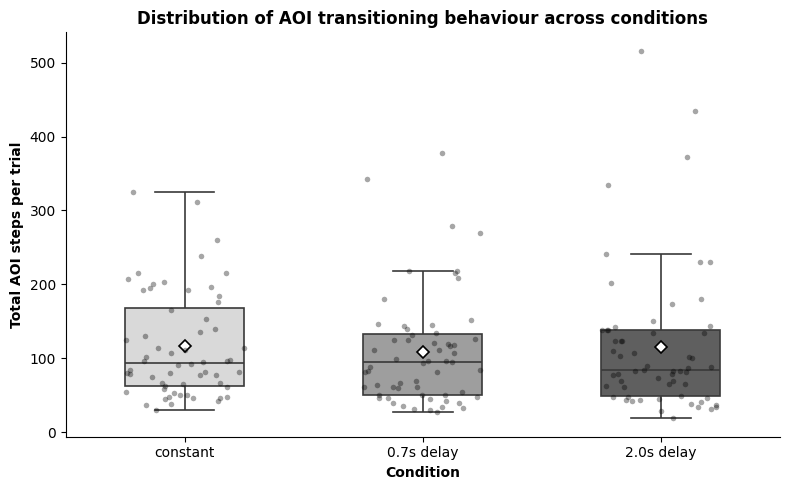

In [134]:
# =======================================================
# PLOT DISTRIBUTION OF AOI TRANSITIONING BEHAVIOUR PER TRIAL
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

# =====================
# Plot
# =====================

plt.figure(figsize=(8, 5))

# Boxplot
sns.boxplot(
    data=aoi_steps_per_trial,
    x="condition",
    y="n_AOI_steps",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5,
    linewidth=1.2
)

# Raw trial-level points
sns.stripplot(
    data=aoi_steps_per_trial,
    x="condition",
    y="n_AOI_steps",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

# Mean marker
sns.pointplot(
    data=aoi_steps_per_trial,
    x="condition",
    y="n_AOI_steps",
    order=COND_ORDER,
    estimator="mean",
    errorbar=None,
    color="white",
    markers="D",
    markersize=6,
    linestyles="none",
    markeredgecolor="black",
    markeredgewidth=1.2
)

# =====================
# Formatting
# =====================

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Total AOI steps per trial", fontweight="bold")

plt.title(
    "Distribution of AOI transitioning behaviour across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

## ohne mean marker

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/2712625401.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


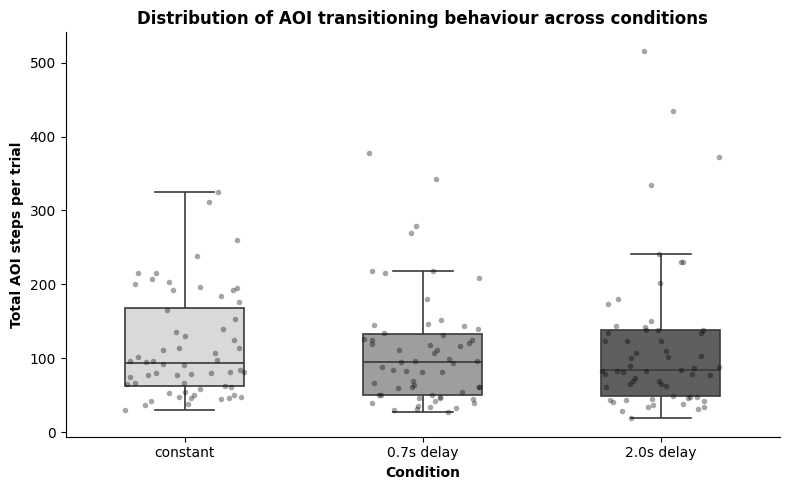

In [135]:
# =======================================================
# PLOT DISTRIBUTION OF AOI TRANSITIONING BEHAVIOUR PER TRIAL
# WITHOUT MEAN MARKER
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

palette = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

# =====================
# Plot
# =====================

plt.figure(figsize=(8, 5))

# Boxplot
sns.boxplot(
    data=aoi_steps_per_trial,
    x="condition",
    y="n_AOI_steps",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5,
    linewidth=1.2
)

# Raw trial-level points
sns.stripplot(
    data=aoi_steps_per_trial,
    x="condition",
    y="n_AOI_steps",
    order=COND_ORDER,
    color="black",
    alpha=0.35,
    size=4,
    jitter=0.25
)

# =====================
# Formatting
# =====================

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Total AOI steps per trial", fontweight="bold")

plt.title(
    "Distribution of AOI transitioning behaviour across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

### check : identify high trials

In [136]:
# =======================================================
# IDENTIFY HIGHEST AOI-STEP TRIALS
# =======================================================

highest_aoi_step_trials = (
    aoi_steps_per_trial
    .sort_values("n_AOI_steps", ascending=False)
    .reset_index(drop=True)
)

display(highest_aoi_step_trials.head(20))

,participant_id,model_name,condition,n_AOI_steps
0,6,C3M2A,2.0s delay,516
1,6,C3M5F,2.0s delay,435
2,2,C3M2A,0.7s delay,378
3,4,C3M4A,2.0s delay,372
4,6,C3M6A,0.7s delay,342
5,7,C3M3F,2.0s delay,334
6,6,C3M4A,constant,325
7,1,C3M2A,constant,311
8,6,C3M3F,0.7s delay,279
9,1,C3M1F,0.7s delay,269


### Step 7: Build participant-level averages for AOI transitioning behaviour

In [137]:
# =======================================================
# 7) BUILD PARTICIPANT-LEVEL AVERAGES FOR AOI TRANSITIONING BEHAVIOUR
# =======================================================

avg_aoi_steps = (
    aoi_steps_per_trial
    .groupby(["participant_id", "condition"], as_index=False, observed=False)
    .agg(
        avg_AOI_steps=("n_AOI_steps", "mean"),
        n_trials=("model_name", "nunique")
    )
)

avg_aoi_steps["condition"] = pd.Categorical(
    avg_aoi_steps["condition"],
    categories=COND_ORDER,
    ordered=True
)

avg_aoi_steps = avg_aoi_steps.sort_values(
    ["participant_id", "condition"]
)

print("Participant-level AOI step averages:")
display(avg_aoi_steps.head(30))

print("Participants per condition:")
display(
    avg_aoi_steps
    .groupby("condition", observed=False)["participant_id"]
    .nunique()
)

Participant-level AOI step averages:


,participant_id,condition,avg_AOI_steps,n_trials
0,1,constant,138.333333,6
1,1,0.7s delay,126.166667,6
2,1,2.0s delay,89.333333,6
3,10,constant,103.833333,6
4,10,0.7s delay,101.500000,6
5,10,2.0s delay,94.166667,6
6,2,constant,127.500000,6
7,2,0.7s delay,137.500000,6
8,2,2.0s delay,142.000000,6
9,3,constant,137.666667,6


Participants per condition:


condition
constant      10
0.7s delay    10
2.0s delay    10
Name: participant_id, dtype: int64

### Plot participant-level trajectories of AOI transitioning behaviour

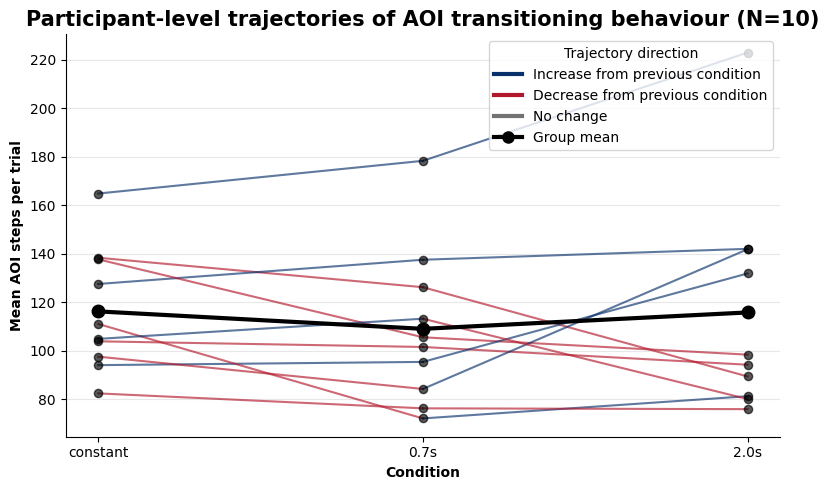

In [138]:
# =======================================================
# PARTICIPANT-LEVEL TRAJECTORIES:
# AOI TRANSITIONING BEHAVIOUR
# =======================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"   # dark blue
COL_DECREASE = "#b2182b"   # dark red
COL_EQUAL = "#737373"      # gray for no change
COL_MEAN = "black"

# =====================
# Prepare data
# =====================

plot_data = avg_aoi_steps.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

n_participants = plot_data["participant_id"].nunique()

x = np.arange(len(COND_ORDER))

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    # Only plot participants with all three conditions
    if len(sub) != 3:
        continue

    y = sub["avg_AOI_steps"].values

    # Participant points
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3,
        alpha=0.65
    )

    # Segment 1: constant -> 0.7s delay
    diff1 = y[1] - y[0]

    if diff1 > 0:
        color1 = COL_INCREASE
    elif diff1 < 0:
        color1 = COL_DECREASE
    else:
        color1 = COL_EQUAL

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # Segment 2: 0.7s delay -> 2.0s delay
    diff2 = y[2] - y[1]

    if diff2 > 0:
        color2 = COL_INCREASE
    elif diff2 < 0:
        color2 = COL_DECREASE
    else:
        color2 = COL_EQUAL

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# =====================
# Group mean
# =====================

group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_AOI_steps"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color=COL_MEAN,
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

# =====================
# Legend
# =====================

legend_elements = [
    Line2D(
        [0], [0],
        color=COL_INCREASE,
        lw=3,
        label="Increase from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_EQUAL,
        lw=3,
        label="No change"
    ),
    Line2D(
        [0], [0],
        color=COL_MEAN,
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper right"
)

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel(
    "Mean AOI steps per trial",
    fontweight="bold"
)

ax.set_title(
    f"Participant-level trajectories of AOI transitioning behaviour (N={n_participants})",
    fontweight="bold",
    fontsize=15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

#### Transitioning behaviour participant trajectories nicer plot:

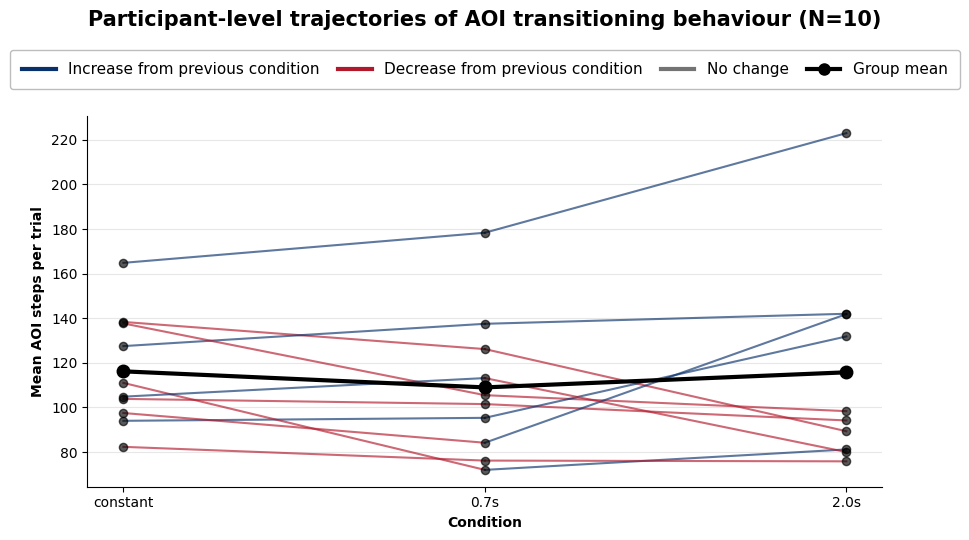

In [139]:
# =======================================================
# PARTICIPANT-LEVEL TRAJECTORIES:
# AOI TRANSITIONING BEHAVIOUR
# =======================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COL_INCREASE = "#08306b"   # dark blue
COL_DECREASE = "#b2182b"   # dark red
COL_EQUAL = "#737373"      # gray for no change
COL_MEAN = "black"

# =====================
# Prepare data
# =====================

plot_data = avg_aoi_steps.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)

n_participants = plot_data["participant_id"].nunique()

x = np.arange(len(COND_ORDER))

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(10, 5.5))

for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    # Only plot participants with all three conditions
    if len(sub) != 3:
        continue

    y = sub["avg_AOI_steps"].values

    # Participant points
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3,
        alpha=0.65
    )

    # Segment 1: constant -> 0.7s delay
    diff1 = y[1] - y[0]

    if diff1 > 0:
        color1 = COL_INCREASE
    elif diff1 < 0:
        color1 = COL_DECREASE
    else:
        color1 = COL_EQUAL

    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65
    )

    # Segment 2: 0.7s delay -> 2.0s delay
    diff2 = y[2] - y[1]

    if diff2 > 0:
        color2 = COL_INCREASE
    elif diff2 < 0:
        color2 = COL_DECREASE
    else:
        color2 = COL_EQUAL

    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65
    )

# =====================
# Group mean
# =====================

group_means = (
    plot_data
    .groupby("condition", observed=False)["avg_AOI_steps"]
    .mean()
    .reindex(COND_ORDER)
)

ax.plot(
    x,
    group_means.values,
    color=COL_MEAN,
    linewidth=3,
    marker="o",
    markersize=9,
    label="Group mean",
    zorder=4
)

# =====================
# Legend
# =====================

legend_elements = [
    Line2D(
        [0], [0],
        color=COL_INCREASE,
        lw=3,
        label="Increase from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_EQUAL,
        lw=3,
        label="No change"
    ),
    Line2D(
        [0], [0],
        color=COL_MEAN,
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel(
    "Mean AOI steps per trial",
    fontweight="bold"
)

ax.set_title(
    f"Participant-level trajectories of AOI transitioning behaviour (N={n_participants})",
    fontweight="bold",
    fontsize=15,
    pad=65
)

# Horizontal legend centered below the title
ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.20),
    ncol=4,
    frameon=True,
    fontsize=11,
    handlelength=2.2,
    columnspacing=1.2,
    fancybox=True,
    framealpha=1,
    edgecolor="#bdbdbd",
    facecolor="white",
    borderpad=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

### Participant mean line plot

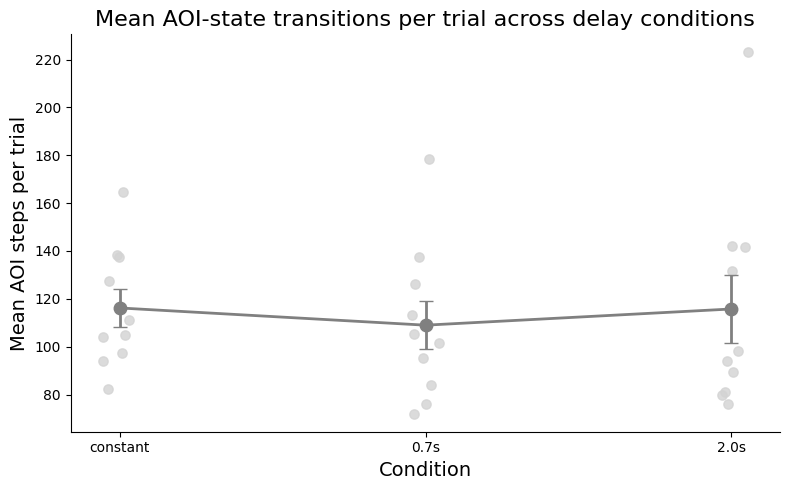

In [140]:
# =======================================================
# PLOT MEAN AOI TRANSITIONS PER TRIAL ACROSS CONDITIONS
# =======================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

plot_data = avg_aoi_steps.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(["participant_id", "condition"])

x = np.arange(len(COND_ORDER))

# =====================
# Group summary
# =====================

summary = (
    plot_data
    .groupby("condition", observed=False)
    .agg(
        mean_AOI_steps=("avg_AOI_steps", "mean"),
        se_AOI_steps=("avg_AOI_steps", lambda x: x.std() / np.sqrt(x.count()))
    )
    .reindex(COND_ORDER)
)

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

# Participant points with jitter
for i, cond in enumerate(COND_ORDER):
    sub = plot_data[plot_data["condition"] == cond]

    jitter = np.random.uniform(-0.06, 0.06, size=len(sub))

    ax.scatter(
        np.full(len(sub), i) + jitter,
        sub["avg_AOI_steps"],
        color="lightgray",
        edgecolor="lightgray",
        alpha=0.8,
        s=45,
        zorder=2
    )

# Group mean line with SE error bars
ax.errorbar(
    x,
    summary["mean_AOI_steps"],
    yerr=summary["se_AOI_steps"],
    color="gray",
    marker="o",
    markersize=9,
    linewidth=2,
    capsize=5,
    zorder=3
)

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontsize=14)
ax.set_ylabel("Mean AOI steps per trial", fontsize=14)

ax.set_title(
    "Mean AOI-state transitions per trial across delay conditions",
    fontsize=16
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

plt.tight_layout()
plt.show()
plt.close(fig)

### mit richtigen grautönen

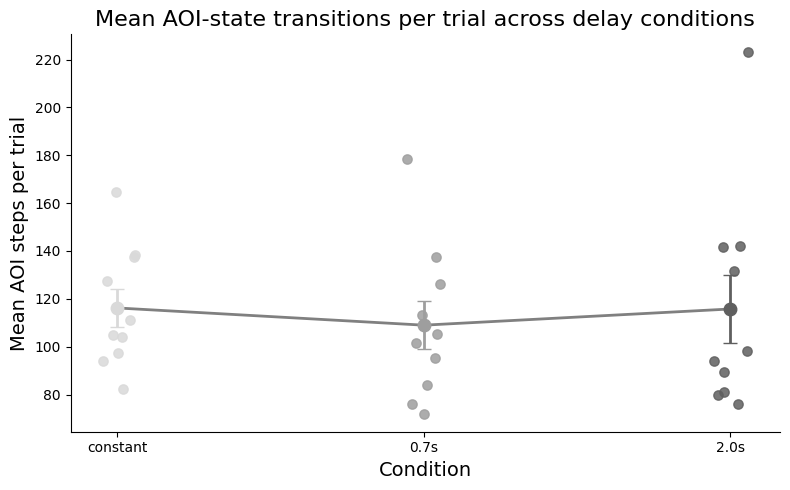

In [141]:
# =======================================================
# PLOT MEAN AOI TRANSITIONS PER TRIAL ACROSS CONDITIONS
# WITH DIFFERENT GREY TONES PER CONDITION
# =======================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
COND_LABELS = ["constant", "0.7s", "2.0s"]

COND_COLORS = {
    "constant": "#d9d9d9",    # light grey
    "0.7s delay": "#9e9e9e",  # medium grey
    "2.0s delay": "#5f5f5f"   # dark grey
}

plot_data = avg_aoi_steps.copy()

plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)

plot_data = plot_data.sort_values(["participant_id", "condition"])

x = np.arange(len(COND_ORDER))

# =====================
# Group summary
# =====================

summary = (
    plot_data
    .groupby("condition", observed=False)
    .agg(
        mean_AOI_steps=("avg_AOI_steps", "mean"),
        se_AOI_steps=("avg_AOI_steps", lambda x: x.std() / np.sqrt(x.count()))
    )
    .reindex(COND_ORDER)
    .reset_index()
)

# =====================
# Plot
# =====================

fig, ax = plt.subplots(figsize=(8, 5))

# Participant points
for i, cond in enumerate(COND_ORDER):
    sub = plot_data[plot_data["condition"] == cond]
    jitter = np.random.uniform(-0.06, 0.06, size=len(sub))

    ax.scatter(
        np.full(len(sub), i) + jitter,
        sub["avg_AOI_steps"],
        color=COND_COLORS[cond],
        edgecolor=COND_COLORS[cond],
        alpha=0.85,
        s=45,
        zorder=2
    )

# Mean connecting line
ax.plot(
    x,
    summary["mean_AOI_steps"],
    color="gray",
    linewidth=2,
    zorder=3
)

# Mean points + error bars in condition-specific grey
for i, row in summary.iterrows():
    cond = row["condition"]

    ax.errorbar(
        x[i],
        row["mean_AOI_steps"],
        yerr=row["se_AOI_steps"],
        fmt="o",
        color=COND_COLORS[cond],
        markerfacecolor=COND_COLORS[cond],
        markeredgecolor=COND_COLORS[cond],
        markersize=9,
        capsize=5,
        linewidth=2,
        zorder=4
    )

# =====================
# Formatting
# =====================

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontsize=14)
ax.set_ylabel("Mean AOI steps per trial", fontsize=14)

ax.set_title(
    "Mean AOI-state transitions per trial across delay conditions",
    fontsize=16
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()
plt.close(fig)

### IDENTIFY PARTICIPANT WITH HIGHEST AOI TRANSITIONING BEHAVIOUR

In [142]:
# =======================================================
# IDENTIFY PARTICIPANT WITH HIGHEST AOI TRANSITIONING BEHAVIOUR
# =======================================================

# Highest participant-condition values
highest_aoi_steps = (
    avg_aoi_steps
    .sort_values("avg_AOI_steps", ascending=False)
    .reset_index(drop=True)
)

display(highest_aoi_steps.head(10))

,participant_id,condition,avg_AOI_steps,n_trials
0,6,2.0s delay,223.000000,6
1,6,0.7s delay,178.333333,6
2,6,constant,164.833333,6
3,2,2.0s delay,142.000000,6
4,7,2.0s delay,141.833333,6
5,1,constant,138.333333,6
6,3,constant,137.666667,6
7,2,0.7s delay,137.500000,6
8,4,2.0s delay,131.833333,6
9,2,constant,127.500000,6


In [143]:
# =======================================================
# CHECK TRIAL-LEVEL AOI STEPS FOR PARTICIPANT 6
# =======================================================

participant_6_trials = (
    aoi_steps_per_trial
    .loc[aoi_steps_per_trial["participant_id"] == "6"]
    .sort_values(["condition", "n_AOI_steps"], ascending=[True, False])
)

display(participant_6_trials)

,participant_id,model_name,condition,n_AOI_steps
123,6,C3M4A,constant,325
120,6,C3M1F,constant,216
116,6,C2M3F,constant,203
111,6,C1M4A,constant,96
119,6,C2M6A,constant,95
112,6,C1M5F,constant,54
125,6,C3M6A,0.7s delay,342
122,6,C3M3F,0.7s delay,279
115,6,C2M2A,0.7s delay,216
114,6,C2M1F,0.7s delay,120


## Values Group mean

In [144]:
# =======================================================
# GROUP MEANS FOR AOI TRANSITIONING BEHAVIOUR
# =======================================================

aoi_step_group_means = (
    avg_aoi_steps
    .groupby("condition", as_index=False, observed=False)
    .agg(
        mean_AOI_steps=("avg_AOI_steps", "mean"),
        sd_AOI_steps=("avg_AOI_steps", "std"),
        n_participants=("participant_id", "nunique")
    )
)

aoi_step_group_means["se_AOI_steps"] = (
    aoi_step_group_means["sd_AOI_steps"] /
    np.sqrt(aoi_step_group_means["n_participants"])
)

aoi_step_group_means = aoi_step_group_means.sort_values("condition")

display(aoi_step_group_means)

,condition,mean_AOI_steps,sd_AOI_steps,n_participants,se_AOI_steps
0,constant,116.183333,25.259206,10,7.987662
1,0.7s delay,108.983333,32.059691,10,10.138164
2,2.0s delay,115.750000,45.540055,10,14.401030


## Statistical inference . OVerall transitioning frequency

## Check Normal distirbution

RAW OVERALL AOI TRANSITIONS PER TRIAL
Total number of trials: 180

Trials per condition:
condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64

Missing values: 0
Negative counts: 0

OVERALL DISTRIBUTION
Mean:                 113.639
Median:               89.500
Standard deviation:   81.739
Variance:             6681.327
Minimum:              19.000
Maximum:              516.000
Skewness:             1.913
Variance / mean:      58.794
Shapiro-Wilk W:       0.8230
Shapiro-Wilk p:       < 0.0001

DISTRIBUTION BY CONDITION


,Condition,N,Mean,Median,SD,Variance,Minimum,Maximum,Skewness,Variance/Mean,Shapiro W,Shapiro p
0,constant,60,116.1833,93.5,70.7520,5005.8472,30,325,1.0816,43.0858,0.8851,0.0
1,0.7s delay,60,108.9833,94.5,75.6543,5723.5760,28,378,1.6372,52.5179,0.8413,0.0
2,2.0s delay,60,115.7500,84.0,97.5084,9507.8856,19,516,2.2982,82.1416,0.7500,0.0


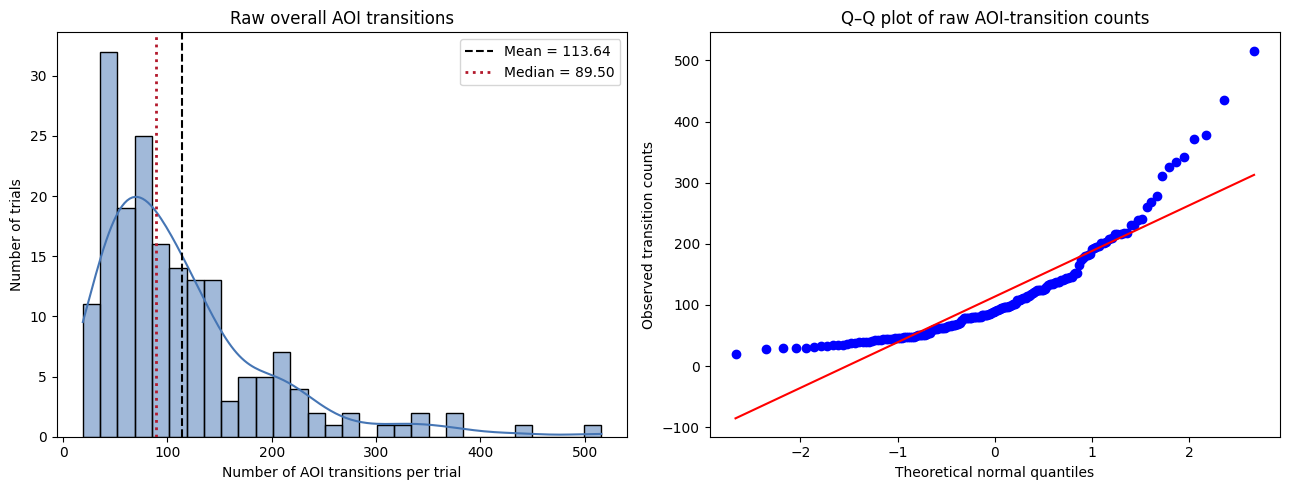

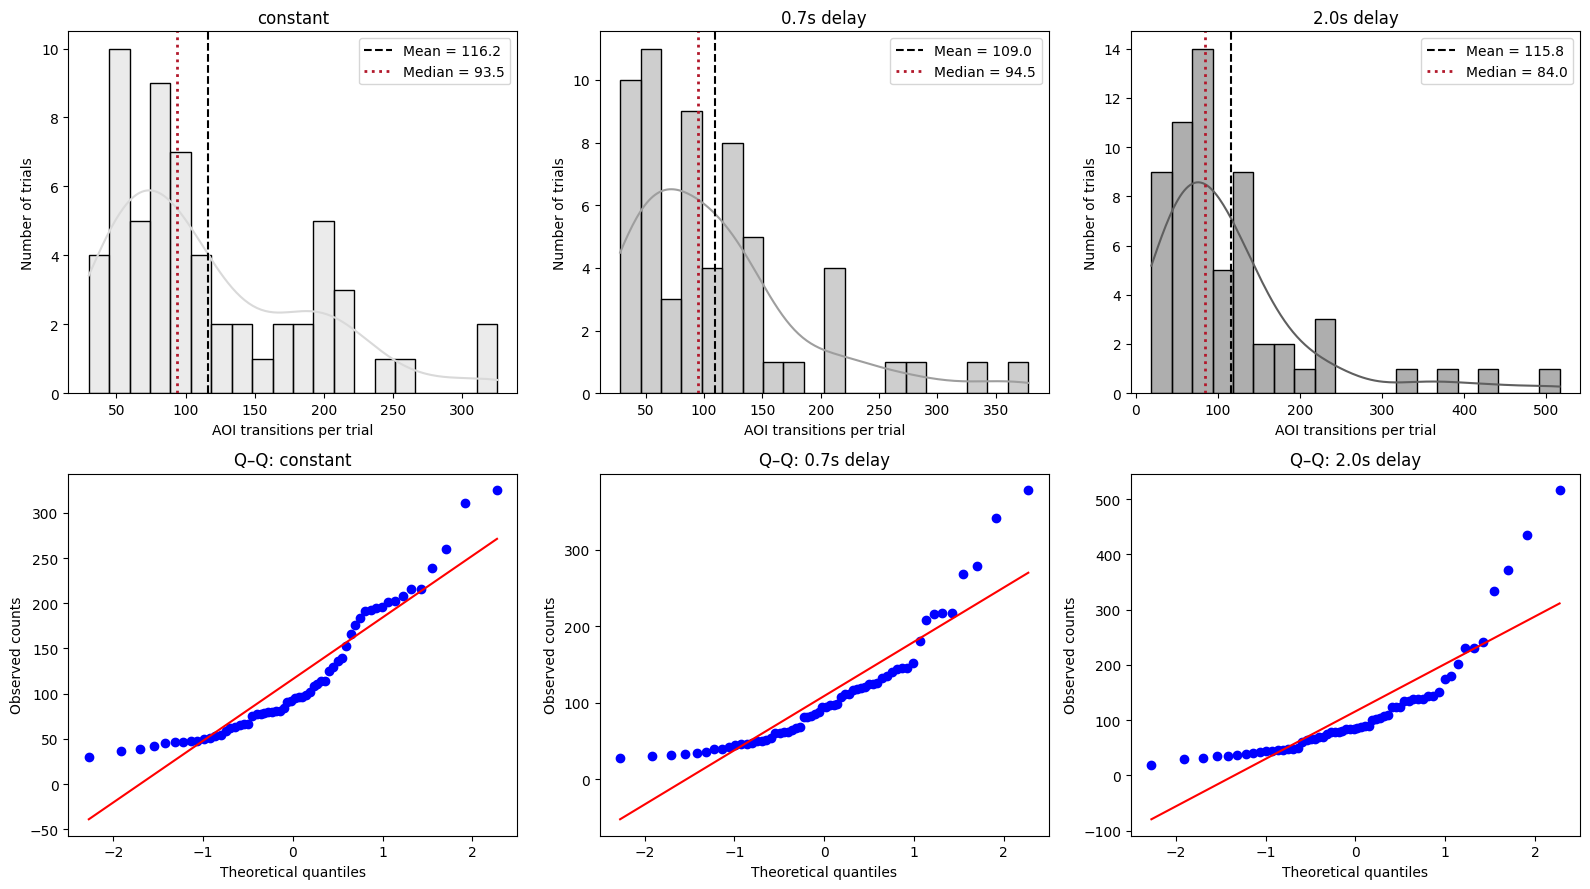

In [287]:
# =======================================================
# RAW DISTRIBUTION OF OVERALL AOI TRANSITIONS PER TRIAL
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skew, shapiro

COND_ORDER = [
    "constant",
    "0.7s delay",
    "2.0s delay"
]

palette = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

# =======================================================
# 1. PREPARE DATA
# =======================================================

raw_aoi_counts = (
    aoi_steps_per_trial[
        ["condition", "n_AOI_steps"]
    ]
    .dropna()
    .copy()
)

raw_aoi_counts["condition"] = pd.Categorical(
    raw_aoi_counts["condition"].astype(str),
    categories=COND_ORDER,
    ordered=True
)

raw_aoi_counts = raw_aoi_counts.dropna(
    subset=["condition"]
)

print("=" * 65)
print("RAW OVERALL AOI TRANSITIONS PER TRIAL")
print("=" * 65)

print(f"Total number of trials: {len(raw_aoi_counts)}")

print("\nTrials per condition:")
print(
    raw_aoi_counts["condition"]
    .value_counts(sort=False)
)

print(
    "\nMissing values:",
    aoi_steps_per_trial["n_AOI_steps"].isna().sum()
)

print(
    "Negative counts:",
    (raw_aoi_counts["n_AOI_steps"] < 0).sum()
)

# =======================================================
# 2. OVERALL DISTRIBUTION
# =======================================================

overall_counts = raw_aoi_counts["n_AOI_steps"]

W_overall, p_overall = shapiro(overall_counts)

print("\n" + "=" * 65)
print("OVERALL DISTRIBUTION")
print("=" * 65)

print(f"Mean:                 {overall_counts.mean():.3f}")
print(f"Median:               {overall_counts.median():.3f}")
print(f"Standard deviation:   {overall_counts.std():.3f}")
print(f"Variance:             {overall_counts.var():.3f}")
print(f"Minimum:              {overall_counts.min():.3f}")
print(f"Maximum:              {overall_counts.max():.3f}")
print(f"Skewness:             {skew(overall_counts, bias=False):.3f}")

print(
    "Variance / mean:      "
    f"{overall_counts.var() / overall_counts.mean():.3f}"
)

print(f"Shapiro-Wilk W:       {W_overall:.4f}")

if p_overall < 0.0001:
    print("Shapiro-Wilk p:       < 0.0001")
else:
    print(f"Shapiro-Wilk p:       {p_overall:.4f}")

# =======================================================
# 3. SUMMARY AND SHAPIRO TEST BY CONDITION
# =======================================================

summary_rows = []

for condition in COND_ORDER:

    values = raw_aoi_counts.loc[
        raw_aoi_counts["condition"] == condition,
        "n_AOI_steps"
    ]

    W, p = shapiro(values)

    summary_rows.append(
        {
            "Condition": condition,
            "N": len(values),
            "Mean": values.mean(),
            "Median": values.median(),
            "SD": values.std(),
            "Variance": values.var(),
            "Minimum": values.min(),
            "Maximum": values.max(),
            "Skewness": skew(values, bias=False),
            "Variance/Mean": (
                values.var() / values.mean()
                if values.mean() > 0
                else np.nan
            ),
            "Shapiro W": W,
            "Shapiro p": p
        }
    )

condition_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 65)
print("DISTRIBUTION BY CONDITION")
print("=" * 65)

display(condition_summary.round(4))

# =======================================================
# 4. OVERALL HISTOGRAM AND Q-Q PLOT
# =======================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    overall_counts,
    bins=30,
    kde=True,
    color="#4575b4",
    ax=axes[0]
)

axes[0].axvline(
    overall_counts.mean(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {overall_counts.mean():.2f}"
)

axes[0].axvline(
    overall_counts.median(),
    color="#b2182b",
    linestyle=":",
    linewidth=2,
    label=f"Median = {overall_counts.median():.2f}"
)

axes[0].set_title("Raw overall AOI transitions")
axes[0].set_xlabel("Number of AOI transitions per trial")
axes[0].set_ylabel("Number of trials")
axes[0].legend()

stats.probplot(
    overall_counts,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Q–Q plot of raw AOI-transition counts")
axes[1].set_xlabel("Theoretical normal quantiles")
axes[1].set_ylabel("Observed transition counts")

plt.tight_layout()
plt.show()

# =======================================================
# 5. HISTOGRAMS AND Q-Q PLOTS BY CONDITION
# =======================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9)
)

for index, condition in enumerate(COND_ORDER):

    values = raw_aoi_counts.loc[
        raw_aoi_counts["condition"] == condition,
        "n_AOI_steps"
    ]

    # Histogram
    sns.histplot(
        values,
        bins=20,
        kde=True,
        color=palette[condition],
        edgecolor="black",
        ax=axes[0, index]
    )

    axes[0, index].axvline(
        values.mean(),
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {values.mean():.1f}"
    )

    axes[0, index].axvline(
        values.median(),
        color="#b2182b",
        linestyle=":",
        linewidth=2,
        label=f"Median = {values.median():.1f}"
    )

    axes[0, index].set_title(condition)
    axes[0, index].set_xlabel("AOI transitions per trial")
    axes[0, index].set_ylabel("Number of trials")
    axes[0, index].legend()

    # Q-Q plot
    stats.probplot(
        values,
        dist="norm",
        plot=axes[1, index]
    )

    axes[1, index].set_title(f"Q–Q: {condition}")
    axes[1, index].set_xlabel("Theoretical quantiles")
    axes[1, index].set_ylabel("Observed counts")

plt.tight_layout()
plt.show()

In [345]:
# Statt display(condition_summary.round(4)):
print(condition_summary.round(4).to_string())

# oder dauerhaft für den ganzen Notebook-Run:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

    Condition   N      Mean  Median       SD   Variance  Minimum  Maximum  Skewness  Variance/Mean  Shapiro W  Shapiro p
0    constant  60  116.1833    93.5  70.7520  5005.8472       30      325    1.0816        43.0858     0.8851        0.0
1  0.7s delay  60  108.9833    94.5  75.6543  5723.5760       28      378    1.6372        52.5179     0.8413        0.0
2  2.0s delay  60  115.7500    84.0  97.5084  9507.8856       19      516    2.2982        82.1416     0.7500        0.0


In [288]:
# =======================================================
# SHAPIRO-WILK TEST:
# RAW OVERALL AOI TRANSITIONS PER TRIAL
# =======================================================

from scipy.stats import shapiro

COND_ORDER = [
    "constant",
    "0.7s delay",
    "2.0s delay"
]

# Overall test
overall_values = (
    aoi_steps_per_trial["n_AOI_steps"]
    .dropna()
)

W, p = shapiro(overall_values)

print("=" * 60)
print("SHAPIRO-WILK: ALL CONDITIONS TOGETHER")
print("=" * 60)
print(f"N = {len(overall_values)}")
print(f"W = {W:.4f}")

if p < 0.0001:
    print("p < 0.0001")
else:
    print(f"p = {p:.4f}")

# Tests separately by condition
print("\n" + "=" * 60)
print("SHAPIRO-WILK BY CONDITION")
print("=" * 60)

for condition in COND_ORDER:

    condition_values = (
        aoi_steps_per_trial.loc[
            aoi_steps_per_trial["condition"] == condition,
            "n_AOI_steps"
        ]
        .dropna()
    )

    W_condition, p_condition = shapiro(
        condition_values
    )

    print(f"\n{condition}")
    print(f"N = {len(condition_values)}")
    print(f"W = {W_condition:.4f}")

    if p_condition < 0.0001:
        print("p < 0.0001")
    else:
        print(f"p = {p_condition:.4f}")

SHAPIRO-WILK: ALL CONDITIONS TOGETHER
N = 180
W = 0.8230
p < 0.0001

SHAPIRO-WILK BY CONDITION

constant
N = 60
W = 0.8851
p < 0.0001

0.7s delay
N = 60
W = 0.8413
p < 0.0001

2.0s delay
N = 60
W = 0.7500
p < 0.0001


## Add LOG due to skewness

In [348]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.libqsturng import psturng

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

df = aoi_steps_per_trial.copy()
df["condition"] = pd.Categorical(df["condition"], categories=COND_ORDER, ordered=True)

df["log_n_AOI_steps"] = np.log(df["n_AOI_steps"])

In [349]:
model = smf.mixedlm(
    "log_n_AOI_steps ~ C(condition, Treatment(reference='constant'))",
    data=df,
    groups=df["participant_id"],
    re_formula="1",
)
result = model.fit(reml=True)
print(result.summary())

                                Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              log_n_AOI_steps
No. Observations:                180                  Method:                          REML           
No. Groups:                      10                   Scale:                           0.3959         
Min. group size:                 18                   Log-Likelihood:                  -178.5148      
Max. group size:                 18                   Converged:                       Yes            
Mean group size:                 18.0                                                                 
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

In [350]:
print("Ratio of geometric means vs. 'constant' condition:")
for term, coef in result.fe_params.items():
    if "condition" in term:
        print(f"  {term}: exp(coef) = {np.exp(coef):.3f}")

Ratio of geometric means vs. 'constant' condition:
  C(condition, Treatment(reference='constant'))[T.0.7s delay]: exp(coef) = 0.908
  C(condition, Treatment(reference='constant'))[T.2.0s delay]: exp(coef) = 0.917


In [351]:
residuals = result.resid
fitted = result.fittedvalues

### Residual diagnostics

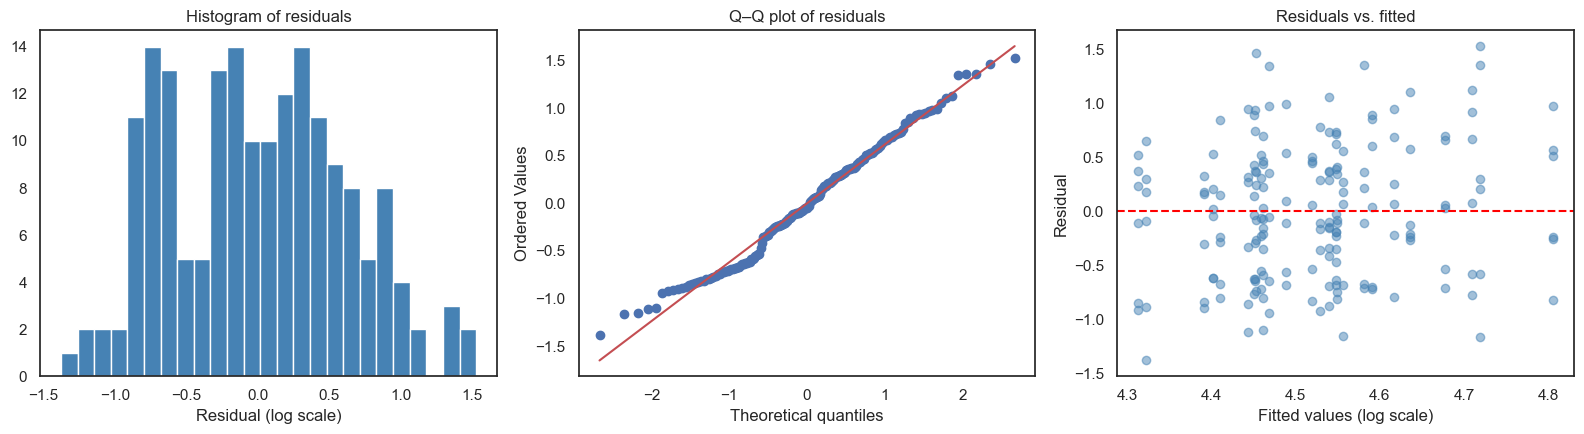

Shapiro-Wilk on residuals: W = 0.9836, p = 0.03343
  -> residuals deviate from normality


In [353]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(residuals, bins=25, color="steelblue", edgecolor="white")
axes[0].set_title("Histogram of residuals")
axes[0].set_xlabel("Residual (log scale)")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q–Q plot of residuals")

axes[2].scatter(fitted, residuals, alpha=0.5, color="steelblue")
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_title("Residuals vs. fitted")
axes[2].set_xlabel("Fitted values (log scale)")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.savefig("log_lmm_residual_diagnostics.png", dpi=150)
plt.show()

## Sharpiro Wilk test

W, p = stats.shapiro(residuals)
print(f"Shapiro-Wilk on residuals: W = {W:.4f}, p = {p:.4g}")
print("  -> " + ("residuals deviate from normality" if p < .05
                  else "no evidence against normality of residuals"))

### Tukey correction

In [355]:
fe_names = result.fe_params.index.tolist()
print(fe_names)  # zur Kontrolle: Reihenfolge der Koeffizienten prüfen

# Kontrastmatrix in derselben Spaltenreihenfolge wie fe_names:
# [Intercept, condition[0.7s delay], condition[2.0s delay]]
contrast_matrix = np.array([
    [0,  1,  0],   # constant vs 0.7s delay
    [0,  0,  1],   # constant vs 2.0s delay
    [0, -1,  1],   # 0.7s delay vs 2.0s delay
])

t_test = result.t_test(contrast_matrix)
print(t_test.summary())

t_values = np.asarray(t_test.tvalue).flatten()
df_resid = result.df_resid
k = 3  # Anzahl der verglichenen Bedingungen

q_stats = np.abs(t_values) * np.sqrt(2)
p_tukey = psturng(q_stats, k, df_resid)

labels = ["constant vs 0.7s delay", "constant vs 2.0s delay", "0.7s delay vs 2.0s delay"]
for label, t_val, p_t in zip(labels, t_values, p_tukey):
    print(f"{label}: t = {t_val:.3f}, p_tukey = {p_t:.4f}")

['Intercept', "C(condition, Treatment(reference='constant'))[T.0.7s delay]", "C(condition, Treatment(reference='constant'))[T.2.0s delay]"]
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0969      0.115     -0.844      0.399      -0.322       0.128
c1            -0.0870      0.115     -0.757      0.449      -0.312       0.138
c2             0.0099      0.115      0.086      0.931      -0.215       0.235
constant vs 0.7s delay: t = -0.844, p_tukey = 0.6620
constant vs 2.0s delay: t = -0.757, p_tukey = 0.7113
0.7s delay vs 2.0s delay: t = 0.086, p_tukey = 0.9000


### Friedman - sanity check

In [357]:
## Aggregate data

person_means = (
    df.groupby(["participant_id", "condition"], observed=True)["n_AOI_steps"]
    .mean()
    .unstack("condition")
)

print(person_means)

condition         constant  0.7s delay  2.0s delay
participant_id                                    
1               138.333333  126.166667   89.333333
10              103.833333  101.500000   94.166667
2               127.500000  137.500000  142.000000
3               137.666667  105.500000   98.333333
4                94.000000   95.333333  131.833333
5               111.000000   72.000000   81.166667
6               164.833333  178.333333  223.000000
7                97.500000   84.166667  141.833333
8               104.833333  113.166667   80.000000
9                82.333333   76.166667   75.833333


In [359]:
from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(
    person_means["constant"],
    person_means["0.7s delay"],
    person_means["2.0s delay"],
)
print(f"Friedman-Test: chi2 = {stat:.3f}, p = {p:.4f}")

Friedman-Test: chi2 = 0.600, p = 0.7408


## Statistical Inference: Overall transitioning behaviour: Using a GEE poisson with log link

In [145]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Sicherstellen, dass die Daten nach participant_id sortiert sind (wichtig für GEE)
aoi_steps_per_trial = aoi_steps_per_trial.sort_values(
    "participant_id"
).reset_index(drop=True)

# 2. Categorical mit 'constant' als Baseline anlegen
aoi_steps_per_trial["condition_cat"] = pd.Categorical(
    aoi_steps_per_trial["condition"], categories=COND_ORDER, ordered=False
)

# 3. GEE-Modell definieren (groups statt group!)
gee_model_overall = smf.gee(
    formula="n_AOI_steps ~ C(condition_cat, Treatment(reference='constant'))",
    groups="participant_id",  # <-- Hier lag der Fehler (Plural)
    data=aoi_steps_per_trial,
    family=sm.families.Poisson(),
    cov_struct=sm.cov_struct.Exchangeable(),
)

gee_results_overall = gee_model_overall.fit()

# 4. Zusammenfassung ausgeben
print(
    "=============================================================================="
)
print(
    "               GEE MODEL: OVERALL TRANSITIONS (AOI STEPS) PER TRIAL          "
)
print(
    "=============================================================================="
)
print(gee_results_overall.summary())

# 5. Incidence Rate Ratios (IRR) berechnen
params = gee_results_overall.params
conf = gee_results_overall.conf_int()
pvalues = gee_results_overall.pvalues

irr_table = pd.DataFrame(
    {
        "Beta (Log-Odds)": params,
        "IRR (Exp(Beta))": np.exp(params),
        "2.5% CI": np.exp(conf[0]),
        "97.5% CI": np.exp(conf[1]),
        "p-value": pvalues,
    }
)

print("\n--- Incidence Rate Ratios (IRR) ---")
display(irr_table)

               GEE MODEL: OVERALL TRANSITIONS (AOI STEPS) PER TRIAL          
                               GEE Regression Results                              
Dep. Variable:                 n_AOI_steps   No. Observations:                  180
Model:                                 GEE   No. clusters:                       10
Method:                        Generalized   Min. cluster size:                  18
                      Estimating Equations   Max. cluster size:                  18
Family:                            Poisson   Mean cluster size:                18.0
Dependence structure:         Exchangeable   Num. iterations:                     2
Date:                     Fri, 24 Jul 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         01:53:38
                                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

,Beta (Log-Odds),IRR (Exp(Beta)),2.5% CI,97.5% CI,p-value
Intercept,4.755169,116.183333,102.241304,132.026552,0.000000
"C(condition_cat, Treatment(reference='constant'))[T.0.7s delay]",-0.063974,0.938029,0.852468,1.032178,0.189869
"C(condition_cat, Treatment(reference='constant'))[T.2.0s delay]",-0.003737,0.996270,0.823939,1.204645,0.969239


## Werden individuelle MODEL gazes über die Delay Conditions länger, nachdem der künstliche Delay herausgerechnet wurde?
### Object gazes in Model AOI duration raw

In [146]:
# =======================================================
# 1) BUILD RAW MODEL GAZE DURATION DATA
# =======================================================

import numpy as np
import pandas as pd

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

model_gaze_durations = object_gazes_final.copy()

# Standardize relevant columns
model_gaze_durations["participant_id"] = (
    model_gaze_durations["participant_id"]
    .astype(str)
    .str.strip()
)

model_gaze_durations["condition"] = (
    model_gaze_durations["condition"]
    .astype(str)
    .str.strip()
)

model_gaze_durations["AOI_CLEAN"] = (
    model_gaze_durations["AOI_CLEAN"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Make duration numeric
model_gaze_durations["object_gaze_duration_ms"] = pd.to_numeric(
    model_gaze_durations["object_gaze_duration_ms"],
    errors="coerce"
)

# Keep only valid conditions
model_gaze_durations = model_gaze_durations[
    model_gaze_durations["condition"].isin(COND_ORDER)
].copy()

# Keep only MODEL gazes
model_gaze_durations = model_gaze_durations[
    model_gaze_durations["AOI_CLEAN"] == "MODEL"
].copy()

# Rename raw duration
model_gaze_durations = model_gaze_durations.rename(
    columns={
        "object_gaze_duration_ms": "raw_model_gaze_duration_ms"
    }
)

# Convert to seconds
model_gaze_durations["raw_model_gaze_duration_s"] = (
    model_gaze_durations["raw_model_gaze_duration_ms"] / 1000
)

# Set condition order
model_gaze_durations["condition"] = pd.Categorical(
    model_gaze_durations["condition"],
    categories=COND_ORDER,
    ordered=True
)

print("MODEL gaze duration data shape:", model_gaze_durations.shape)

display(
    model_gaze_durations[
        [
            "participant_id",
            "condition",
            "AOI_CLEAN",
            "raw_model_gaze_duration_ms",
            "raw_model_gaze_duration_s"
        ]
    ].head(20)
)

print("Number of MODEL gazes per condition:")
display(model_gaze_durations["condition"].value_counts())

MODEL gaze duration data shape: (1732, 44)


,participant_id,condition,AOI_CLEAN,raw_model_gaze_duration_ms,raw_model_gaze_duration_s
401,1,constant,MODEL,10288.0,10.288
414,1,constant,MODEL,3590.0,3.590
420,1,constant,MODEL,122.0,0.122
421,1,constant,MODEL,1568.0,1.568
439,1,constant,MODEL,1599.0,1.599
453,1,constant,MODEL,7555.0,7.555
467,1,constant,MODEL,634.0,0.634
475,1,constant,MODEL,678.0,0.678
482,1,constant,MODEL,6589.0,6.589
487,1,constant,MODEL,3388.0,3.388


Number of MODEL gazes per condition:


condition
constant      724
0.7s delay    566
2.0s delay    442
Name: count, dtype: int64

### Plot raw object gaze duration in model AOI

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/2746619081.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


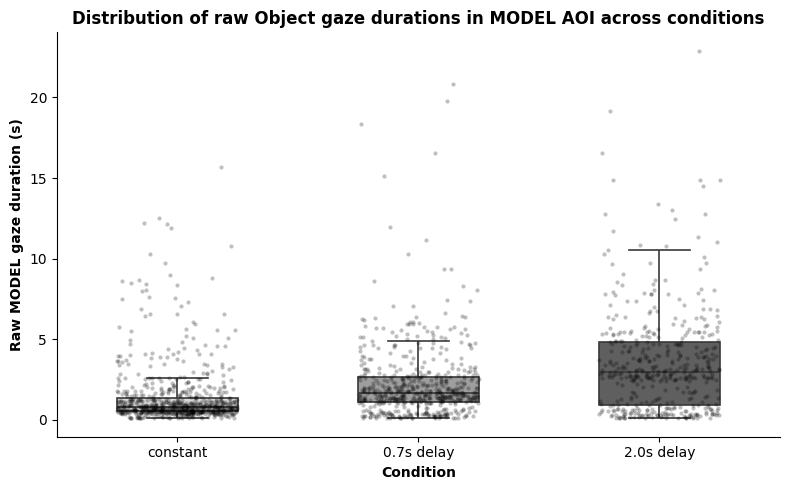

In [147]:
# =======================================================
# 2) PLOT RAW MODEL GAZE DURATION DISTRIBUTION
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_gaze_durations,
    x="condition",
    y="raw_model_gaze_duration_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5,
    linewidth=1.2
)

sns.stripplot(
    data=model_gaze_durations,
    x="condition",
    y="raw_model_gaze_duration_s",
    order=COND_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Raw MODEL gaze duration (s)", fontweight="bold")

plt.title(
    "Distribution of raw Object gaze durations in MODEL AOI across conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

## Data for Model AOI gaze duration - raw

In [148]:
# =======================================================
# 1) BUILD CONSECUTIVE MODEL AOI GAZE EVENTS
# =======================================================

import numpy as np
import pandas as pd


# =====================
# Settings
# =====================

COND_ORDER = [
    "constant",
    "0.7s delay",
    "2.0s delay"
]


# =====================
# Copy source data
# =====================

aoi_gaze_sequence = object_gazes_final.copy()


# =====================
# Clean relevant columns
# =====================

aoi_gaze_sequence["participant_id"] = (
    aoi_gaze_sequence["participant_id"]
    .astype(str)
    .str.strip()
)

aoi_gaze_sequence["model_name"] = (
    aoi_gaze_sequence["model_name"]
    .astype(str)
    .str.strip()
)

aoi_gaze_sequence["condition"] = (
    aoi_gaze_sequence["condition"]
    .astype(str)
    .str.strip()
)

aoi_gaze_sequence["AOI_CLEAN"] = (
    aoi_gaze_sequence["AOI_CLEAN"]
    .astype(str)
    .str.strip()
    .str.upper()
)

aoi_gaze_sequence["object_name_corr"] = (
    aoi_gaze_sequence["object_name_corr"]
    .astype(str)
    .str.strip()
)


# Make duration numeric
aoi_gaze_sequence["object_gaze_duration_s"] = pd.to_numeric(
    aoi_gaze_sequence["object_gaze_duration_s"],
    errors="coerce"
)


# Keep expected conditions
aoi_gaze_sequence = aoi_gaze_sequence[
    aoi_gaze_sequence["condition"].isin(COND_ORDER)
].copy()


# =====================
# Sort chronologically
# =====================

aoi_gaze_sequence = (
    aoi_gaze_sequence
    .sort_values(
        [
            "participant_id",
            "model_name",
            "start_ms"
        ]
    )
    .reset_index(drop=True)
)


# =====================
# Identify consecutive AOI events
# =====================

aoi_gaze_sequence["previous_AOI"] = (
    aoi_gaze_sequence
    .groupby(
        [
            "participant_id",
            "model_name"
        ]
    )["AOI_CLEAN"]
    .shift(1)
)


# New event whenever AOI changes
aoi_gaze_sequence["new_aoi_event"] = (
    aoi_gaze_sequence["AOI_CLEAN"]
    !=
    aoi_gaze_sequence["previous_AOI"]
)


# Assign event IDs within each trial
aoi_gaze_sequence["aoi_event_id"] = (
    aoi_gaze_sequence
    .groupby(
        [
            "participant_id",
            "model_name"
        ]
    )["new_aoi_event"]
    .cumsum()
)


# =====================
# Keep MODEL rows
# =====================

model_aoi_rows = aoi_gaze_sequence[
    aoi_gaze_sequence["AOI_CLEAN"] == "MODEL"
].copy()


# =====================
# Aggregate to one row per MODEL gaze event
# =====================

model_gaze_events_raw = (
    model_aoi_rows
    .groupby(
        [
            "participant_id",
            "model_name",
            "condition",
            "aoi_event_id"
        ],
        as_index=False
    )
    .agg(
        raw_model_gaze_duration_s=(
            "object_gaze_duration_s",
            "sum"
        ),

        event_start_ms=(
            "start_ms",
            "min"
        ),

        event_end_ms=(
            "end_ms",
            "max"
        ),

        n_object_gaze_episodes=(
            "object_name_corr",
            "size"
        )
    )
)


# Set condition order
model_gaze_events_raw["condition"] = pd.Categorical(
    model_gaze_events_raw["condition"],
    categories=COND_ORDER,
    ordered=True
)


# =====================
# Inspect result
# =====================

print("Number of MODEL AOI gaze events:")
print(len(model_gaze_events_raw))

print("\nMODEL gaze events per condition:")
display(
    model_gaze_events_raw["condition"]
    .value_counts()
    .sort_index()
)

print("\nFirst MODEL gaze events:")
display(
    model_gaze_events_raw.head(20)
)

Number of MODEL AOI gaze events:
1608

MODEL gaze events per condition:


condition
constant      684
0.7s delay    531
2.0s delay    393
Name: count, dtype: int64


First MODEL gaze events:


,participant_id,model_name,condition,aoi_event_id,raw_model_gaze_duration_s,event_start_ms,event_end_ms,n_object_gaze_episodes
0,1,C1M1F,0.7s delay,3,2.056,1.754660e+12,1.754660e+12,1
1,1,C1M1F,0.7s delay,8,1.556,1.754660e+12,1.754660e+12,1
2,1,C1M1F,0.7s delay,10,0.279,1.754660e+12,1.754660e+12,1
3,1,C1M2A,constant,2,4.645,1.754660e+12,1.754660e+12,1
4,1,C1M2A,constant,7,0.866,1.754660e+12,1.754660e+12,1
5,1,C1M2A,constant,11,0.700,1.754660e+12,1.754660e+12,1
6,1,C1M2A,constant,13,0.489,1.754660e+12,1.754660e+12,1
7,1,C1M3F,constant,3,1.021,1.754660e+12,1.754660e+12,1
8,1,C1M3F,constant,10,0.632,1.754660e+12,1.754660e+12,1
9,1,C1M3F,constant,12,0.668,1.754660e+12,1.754660e+12,1


###### model_gaze_events_raw

## Plot raw model gaze events

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/2463510682.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


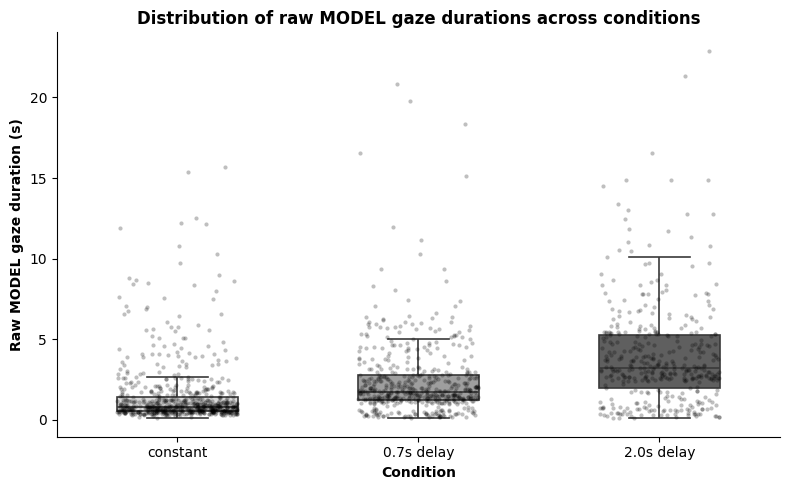

In [149]:
# =======================================================
# 2) PLOT RAW MODEL GAZE EVENT DURATION DISTRIBUTION
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt


palette = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}


plt.figure(figsize=(8, 5))


sns.boxplot(
    data=model_gaze_events_raw,
    x="condition",
    y="raw_model_gaze_duration_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5,
    linewidth=1.2
)


sns.stripplot(
    data=model_gaze_events_raw,
    x="condition",
    y="raw_model_gaze_duration_s",
    order=COND_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25
)


plt.xlabel(
    "Condition",
    fontweight="bold"
)

plt.ylabel(
    "Raw MODEL gaze duration (s)",
    fontweight="bold"
)

plt.title(
    "Distribution of raw MODEL gaze durations across conditions",
    fontweight="bold"
)


sns.despine()
plt.tight_layout()
plt.show()

### Find model plate gaze events

In [150]:
# =======================================================
# 3) IDENTIFY CONSECUTIVE MODEL_PLATE BLOCKS
#    WITHIN EACH MODEL GAZE EVENT
# =======================================================

model_aoi_rows = (
    model_aoi_rows
    .sort_values(
        [
            "participant_id",
            "model_name",
            "aoi_event_id",
            "start_ms"
        ]
    )
    .copy()
)


# Is the current object Model_plate?
model_aoi_rows["is_model_plate"] = (
    model_aoi_rows["object_name_corr"] == "Model_plate"
)


# Previous Model_plate status within the same MODEL gaze event
model_aoi_rows["previous_is_model_plate"] = (
    model_aoi_rows
    .groupby(
        [
            "participant_id",
            "model_name",
            "aoi_event_id"
        ]
    )["is_model_plate"]
    .shift(1)
    .fillna(False)
    .astype(bool)
)


# New Model_plate block:
# current row is Model_plate
# previous row was not Model_plate
model_aoi_rows["new_model_plate_block"] = (
    model_aoi_rows["is_model_plate"]
    &
    ~model_aoi_rows["previous_is_model_plate"]
)


# Assign block IDs within each MODEL gaze event
model_aoi_rows["model_plate_block_id"] = (
    model_aoi_rows
    .groupby(
        [
            "participant_id",
            "model_name",
            "aoi_event_id"
        ]
    )["new_model_plate_block"]
    .cumsum()
)


# Inspect
display(
    model_aoi_rows[
        [
            "participant_id",
            "model_name",
            "condition",
            "aoi_event_id",
            "object_name_corr",
            "object_gaze_duration_s",
            "is_model_plate",
            "model_plate_block_id"
        ]
    ].head(30)
)

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/3633703379.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,participant_id,model_name,condition,aoi_event_id,object_name_corr,object_gaze_duration_s,is_model_plate,model_plate_block_id
2,1,C1M1F,0.7s delay,3,Model_plate,2.056,True,1
132,1,C1M1F,0.7s delay,8,Model_plate,1.556,True,1
135,1,C1M1F,0.7s delay,10,Model_plate,0.279,True,1
143,1,C1M2A,constant,2,Model_plate,4.645,True,1
169,1,C1M2A,constant,7,Model_plate,0.866,True,1
208,1,C1M2A,constant,11,Model_plate,0.700,True,1
224,1,C1M2A,constant,13,Model_plate,0.489,True,1
232,1,C1M3F,constant,3,Model_plate,1.021,True,1
293,1,C1M3F,constant,10,Model_plate,0.632,True,1
311,1,C1M3F,constant,12,Model_plate,0.668,True,1


#### Duration of model_plate episodes

In [151]:
# =======================================================
# 4) BUILD MODEL_PLATE BLOCK DURATIONS
# =======================================================

model_plate_rows = model_aoi_rows[
    model_aoi_rows["is_model_plate"]
].copy()


model_plate_blocks = (
    model_plate_rows
    .groupby(
        [
            "participant_id",
            "model_name",
            "condition",
            "aoi_event_id",
            "model_plate_block_id"
        ],
        as_index=False
    )
    .agg(
        model_plate_block_duration_s=(
            "object_gaze_duration_s",
            "sum"
        )
    )
)


print("Model_plate blocks:")
display(model_plate_blocks.head(20))

Model_plate blocks:


,participant_id,model_name,condition,aoi_event_id,model_plate_block_id,model_plate_block_duration_s
0,1,C1M1F,0.7s delay,3,1,2.056
1,1,C1M1F,0.7s delay,8,1,1.556
2,1,C1M1F,0.7s delay,10,1,0.279
3,1,C1M2A,constant,2,1,4.645
4,1,C1M2A,constant,7,1,0.866
5,1,C1M2A,constant,11,1,0.700
6,1,C1M2A,constant,13,1,0.489
7,1,C1M3F,constant,3,1,1.021
8,1,C1M3F,constant,10,1,0.632
9,1,C1M3F,constant,12,1,0.668


### Correct delay per model_plate object gaze

In [152]:
# =======================================================
# 5) COMPUTE DELAY CORRECTION PER MODEL_PLATE BLOCK
# =======================================================

DELAY_S = {
    "constant": 0.0,
    "0.7s delay": 0.7,
    "2.0s delay": 2.0
}


# Assign delay
model_plate_blocks["delay_s"] = (
    model_plate_blocks["condition"]
    .astype(str)
    .map(DELAY_S)
)


# Actual removable delay per block
model_plate_blocks["delay_correction_s"] = np.minimum(
    model_plate_blocks["model_plate_block_duration_s"],
    model_plate_blocks["delay_s"]
)


# Corrected Model_plate block duration
model_plate_blocks["corrected_model_plate_block_s"] = np.maximum(
    0,
    model_plate_blocks["model_plate_block_duration_s"]
    -
    model_plate_blocks["delay_s"]
)


display(
    model_plate_blocks[
        [
            "participant_id",
            "model_name",
            "condition",
            "aoi_event_id",
            "model_plate_block_id",
            "model_plate_block_duration_s",
            "delay_s",
            "delay_correction_s",
            "corrected_model_plate_block_s"
        ]
    ].head(20)
)

,participant_id,model_name,condition,aoi_event_id,model_plate_block_id,model_plate_block_duration_s,delay_s,delay_correction_s,corrected_model_plate_block_s
0,1,C1M1F,0.7s delay,3,1,2.056,0.7,0.700,1.356
1,1,C1M1F,0.7s delay,8,1,1.556,0.7,0.700,0.856
2,1,C1M1F,0.7s delay,10,1,0.279,0.7,0.279,0.000
3,1,C1M2A,constant,2,1,4.645,0.0,0.000,4.645
4,1,C1M2A,constant,7,1,0.866,0.0,0.000,0.866
5,1,C1M2A,constant,11,1,0.700,0.0,0.000,0.700
6,1,C1M2A,constant,13,1,0.489,0.0,0.000,0.489
7,1,C1M3F,constant,3,1,1.021,0.0,0.000,1.021
8,1,C1M3F,constant,10,1,0.632,0.0,0.000,0.632
9,1,C1M3F,constant,12,1,0.668,0.0,0.000,0.668


#### Correct full Model AOI gaze vent

In [153]:
# =======================================================
# 6) SUM DELAY CORRECTION PER MODEL GAZE EVENT
# =======================================================

delay_per_model_gaze_event = (
    model_plate_blocks
    .groupby(
        [
            "participant_id",
            "model_name",
            "condition",
            "aoi_event_id"
        ],
        as_index=False
    )
    .agg(
        n_model_plate_blocks=(
            "model_plate_block_id",
            "nunique"
        ),

        delay_correction_s=(
            "delay_correction_s",
            "sum"
        )
    )
)


display(
    delay_per_model_gaze_event.head(20)
)

,participant_id,model_name,condition,aoi_event_id,n_model_plate_blocks,delay_correction_s
0,1,C1M1F,0.7s delay,3,1,0.700
1,1,C1M1F,0.7s delay,8,1,0.700
2,1,C1M1F,0.7s delay,10,1,0.279
3,1,C1M2A,constant,2,1,0.000
4,1,C1M2A,constant,7,1,0.000
5,1,C1M2A,constant,11,1,0.000
6,1,C1M2A,constant,13,1,0.000
7,1,C1M3F,constant,3,1,0.000
8,1,C1M3F,constant,10,1,0.000
9,1,C1M3F,constant,12,1,0.000


In [331]:
model_gaze_events.to_csv("model_gaze_events.csv", index=False)

## raw model gaze events with correction

In [154]:
# =======================================================
# 7) BUILD FINAL DELAY-CORRECTED MODEL GAZE EVENT DATA
# =======================================================

model_gaze_events = model_gaze_events_raw.merge(
    delay_per_model_gaze_event,
    on=[
        "participant_id",
        "model_name",
        "condition",
        "aoi_event_id"
    ],
    how="left"
)


# MODEL gaze events without Model_plate:
# no delay correction
model_gaze_events["n_model_plate_blocks"] = (
    model_gaze_events["n_model_plate_blocks"]
    .fillna(0)
    .astype(int)
)

model_gaze_events["delay_correction_s"] = (
    model_gaze_events["delay_correction_s"]
    .fillna(0.0)
)


# Raw corrected value
model_gaze_events["corrected_model_gaze_duration_s_raw"] = (
    model_gaze_events["raw_model_gaze_duration_s"]
    -
    model_gaze_events["delay_correction_s"]
)


# Check negative values before clipping
n_negative = (
    model_gaze_events[
        "corrected_model_gaze_duration_s_raw"
    ] < 0
).sum()

print(
    "Negative corrected MODEL gaze durations before clipping:",
    n_negative
)


# Clip at zero
model_gaze_events["corrected_model_gaze_duration_s"] = (
    model_gaze_events[
        "corrected_model_gaze_duration_s_raw"
    ]
    .clip(lower=0)
)


# Inspect final data
display(
    model_gaze_events[
        [
            "participant_id",
            "model_name",
            "condition",
            "aoi_event_id",
            "raw_model_gaze_duration_s",
            "n_model_plate_blocks",
            "delay_correction_s",
            "corrected_model_gaze_duration_s"
        ]
    ].head(20)
)

Negative corrected MODEL gaze durations before clipping: 0


,participant_id,model_name,condition,aoi_event_id,raw_model_gaze_duration_s,n_model_plate_blocks,delay_correction_s,corrected_model_gaze_duration_s
0,1,C1M1F,0.7s delay,3,2.056,1,0.700,1.356
1,1,C1M1F,0.7s delay,8,1.556,1,0.700,0.856
2,1,C1M1F,0.7s delay,10,0.279,1,0.279,0.000
3,1,C1M2A,constant,2,4.645,1,0.000,4.645
4,1,C1M2A,constant,7,0.866,1,0.000,0.866
5,1,C1M2A,constant,11,0.700,1,0.000,0.700
6,1,C1M2A,constant,13,0.489,1,0.000,0.489
7,1,C1M3F,constant,3,1.021,1,0.000,1.021
8,1,C1M3F,constant,10,0.632,1,0.000,0.632
9,1,C1M3F,constant,12,0.668,1,0.000,0.668


##  Plot both next to each other

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/752426355.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/752426355.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


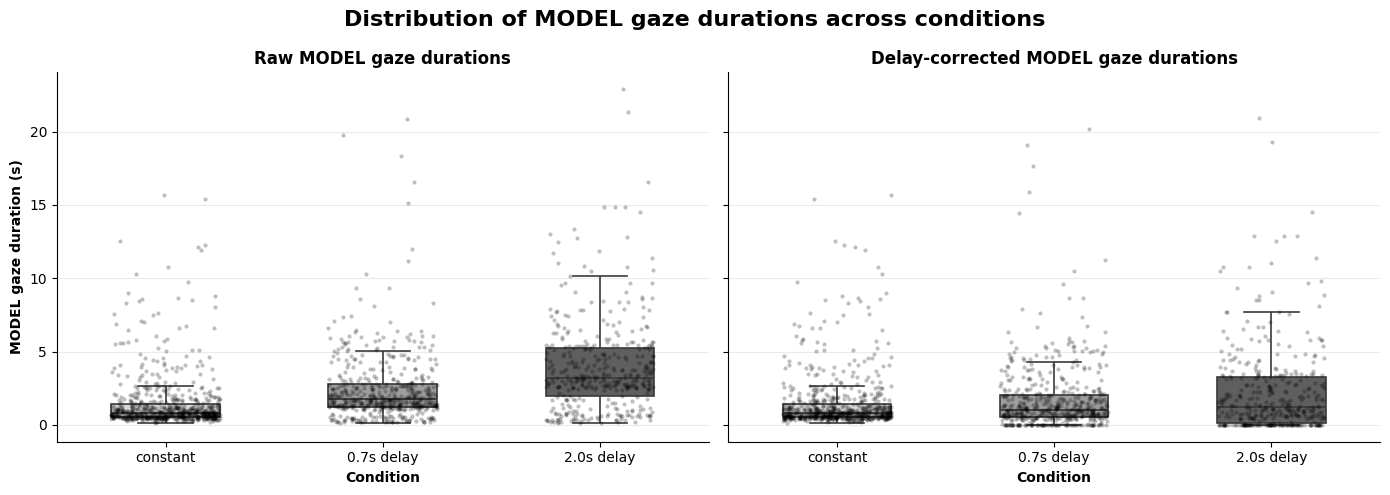

In [155]:
# =======================================================
# 8) PLOT RAW AND DELAY-CORRECTED MODEL GAZE
#    DURATION DISTRIBUTIONS SIDE BY SIDE
# =======================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharey=True
)


# =====================
# Left: Raw
# =====================

sns.boxplot(
    data=model_gaze_events,
    x="condition",
    y="raw_model_gaze_duration_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5,
    linewidth=1.2,
    ax=axes[0]
)

sns.stripplot(
    data=model_gaze_events,
    x="condition",
    y="raw_model_gaze_duration_s",
    order=COND_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25,
    ax=axes[0]
)

axes[0].set_title(
    "Raw MODEL gaze durations",
    fontweight="bold"
)

axes[0].set_xlabel(
    "Condition",
    fontweight="bold"
)

axes[0].set_ylabel(
    "MODEL gaze duration (s)",
    fontweight="bold"
)


# =====================
# Right: Corrected
# =====================

sns.boxplot(
    data=model_gaze_events,
    x="condition",
    y="corrected_model_gaze_duration_s",
    order=COND_ORDER,
    palette=palette,
    showfliers=False,
    width=0.5,
    linewidth=1.2,
    ax=axes[1]
)

sns.stripplot(
    data=model_gaze_events,
    x="condition",
    y="corrected_model_gaze_duration_s",
    order=COND_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25,
    ax=axes[1]
)

axes[1].set_title(
    "Delay-corrected MODEL gaze durations",
    fontweight="bold"
)

axes[1].set_xlabel(
    "Condition",
    fontweight="bold"
)

axes[1].set_ylabel("")


# =====================
# Formatting
# =====================

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)


fig.suptitle(
    "Distribution of MODEL gaze durations across conditions",
    fontweight="bold",
    fontsize=16
)


plt.tight_layout()
plt.show()
plt.close(fig)

In [334]:
# =======================================================
# PLAUSIBILITY CHECK: LONGEST MODEL GAZE EVENTS
# =======================================================

top_n = 20

longest_events = (
    model_gaze_events
    .sort_values("corrected_model_gaze_duration_s", ascending=False)
    .head(top_n)
    [[
        "participant_id",
        "model_name",
        "condition",
        "aoi_event_id",
        "raw_model_gaze_duration_s",
        "delay_correction_s",
        "corrected_model_gaze_duration_s",
        "n_object_gaze_episodes",
        "n_model_plate_blocks",
        "event_start_ms",
        "event_end_ms"
    ]]
)

display(longest_events)


# -------------------------------------------------------
# Optional: quick summary stats on these top events
# -------------------------------------------------------

print("\nCondition breakdown of top", top_n, "longest events:")
print(longest_events["condition"].value_counts())

print("\nParticipant breakdown of top", top_n, "longest events:")
print(longest_events["participant_id"].value_counts())

print("\nn_object_gaze_episodes stats for these events:")
print(longest_events["n_object_gaze_episodes"].describe())

print("\nn_model_plate_blocks stats for these events:")
print(longest_events["n_model_plate_blocks"].describe())

,participant_id,model_name,condition,aoi_event_id,raw_model_gaze_duration_s,delay_correction_s,corrected_model_gaze_duration_s,n_object_gaze_episodes,n_model_plate_blocks,event_start_ms,event_end_ms
1223,6,C3M5F,2.0s delay,11,22.901,2.0,20.901,1,1,1.755702e+12,1.755702e+12
1447,8,C3M2A,0.7s delay,10,20.856,0.7,20.156,1,1,1.756395e+12,1.756395e+12
1474,8,C3M4A,2.0s delay,20,21.322,2.0,19.322,2,1,1.756396e+12,1.756396e+12
1445,8,C3M2A,0.7s delay,2,19.801,0.7,19.101,1,1,1.756395e+12,1.756395e+12
1426,8,C2M6A,0.7s delay,2,18.367,0.7,17.667,1,1,1.756395e+12,1.756395e+12
117,1,C3M4A,0.7s delay,3,16.572,0.7,15.872,1,1,1.754660e+12,1.754660e+12
631,3,C3M2A,constant,19,15.688,0.0,15.688,1,1,1.755159e+12,1.755159e+12
1156,6,C3M1F,constant,9,15.378,0.0,15.378,2,1,1.755699e+12,1.755699e+12
1383,8,C2M1F,2.0s delay,4,16.545,2.0,14.545,1,1,1.756396e+12,1.756396e+12
1451,8,C3M2A,0.7s delay,28,15.156,0.7,14.456,1,1,1.756395e+12,1.756395e+12



Condition breakdown of top 20 longest events:
condition
2.0s delay    8
constant      6
0.7s delay    6
Name: count, dtype: int64

Participant breakdown of top 20 longest events:
participant_id
8    10
2     4
6     3
1     2
3     1
Name: count, dtype: int64

n_object_gaze_episodes stats for these events:
count    20.000000
mean      1.100000
std       0.307794
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
Name: n_object_gaze_episodes, dtype: float64

n_model_plate_blocks stats for these events:
count    20.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: n_model_plate_blocks, dtype: float64


# START SIGNIFICANCE TEST FOR MODEL GAZE EVENTS!!

## Check normality of raw model gazes

=== SHAPIRO-WILK TEST: RAW DURATIONS ===
constant: N=684, W=0.5591, p=3.10e-38
0.7s delay: N=531, W=0.6403, p=7.14e-32
2.0s delay: N=393, W=0.7352, p=1.51e-24


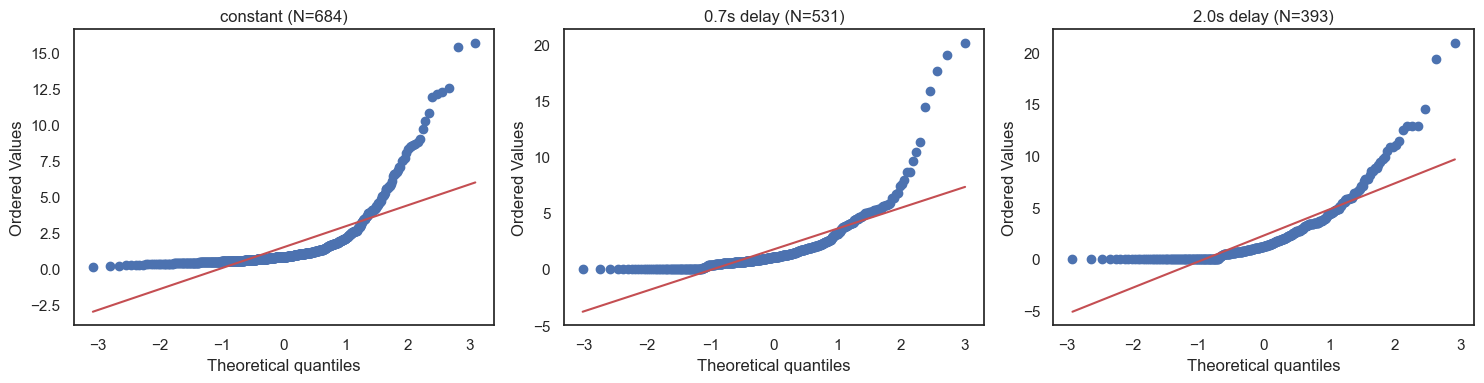

In [333]:
# =======================================================
# NORMALITY CHECK: RAW MODEL GAZE EVENT DURATIONS
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


condition_order = ["constant", "0.7s delay", "2.0s delay"]

model_gaze_events["condition"] = pd.Categorical(
    model_gaze_events["condition"],
    categories=condition_order,
    ordered=True
)

y_col = "corrected_model_gaze_duration_s"


# -------------------------------------------------------
# Shapiro-Wilk test per condition
# -------------------------------------------------------

print("=== SHAPIRO-WILK TEST: RAW DURATIONS ===")
for cond in condition_order:
    vals = model_gaze_events.loc[model_gaze_events["condition"] == cond, y_col]
    stat, p = stats.shapiro(vals)
    print(f"{cond}: N={len(vals)}, W={stat:.4f}, p={p:.2e}")


# -------------------------------------------------------
# Q-Q plots per condition
# -------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, cond in enumerate(condition_order):
    vals = model_gaze_events.loc[model_gaze_events["condition"] == cond, y_col]
    stats.probplot(vals, dist="norm", plot=axes[i])
    axes[i].set_title(f"{cond} (N={len(vals)})")

plt.tight_layout()
plt.savefig("qq_plots_raw_model_gaze.png", dpi=150)
plt.show()

## Clip the gazes that got set to zero as they didnt pass the delay

In [335]:
# =======================================================
# EXCLUDE ZERO-DURATION MODEL GAZE EVENTS
# =======================================================

y_col = "corrected_model_gaze_duration_s"

n_total = len(model_gaze_events)
n_zero = (model_gaze_events[y_col] == 0).sum()

print(f"Ausgeschlossen: {n_zero} von {n_total} Events")
print(model_gaze_events.loc[model_gaze_events[y_col] == 0, "condition"].value_counts())

# Datensatz ohne Null-Events
df_analysis = model_gaze_events[model_gaze_events[y_col] > 0].copy()

print(f"\nVerbleibende Events: {len(df_analysis)}")
print(df_analysis["condition"].value_counts())

Ausgeschlossen: 164 von 1608 Events
condition
2.0s delay    96
0.7s delay    68
constant       0
Name: count, dtype: int64

Verbleibende Events: 1444
condition
constant      684
0.7s delay    463
2.0s delay    297
Name: count, dtype: int64


## Log transformation

=== SHAPIRO-WILK TEST: LOG-TRANSFORMED DURATIONS ===
constant: N=684, W=0.9252, p=6.10e-18, skew=1.04, kurtosis=0.86
0.7s delay: N=463, W=0.9849, p=9.80e-05, skew=0.04, kurtosis=0.64
2.0s delay: N=297, W=0.9899, p=3.73e-02, skew=-0.17, kurtosis=0.06


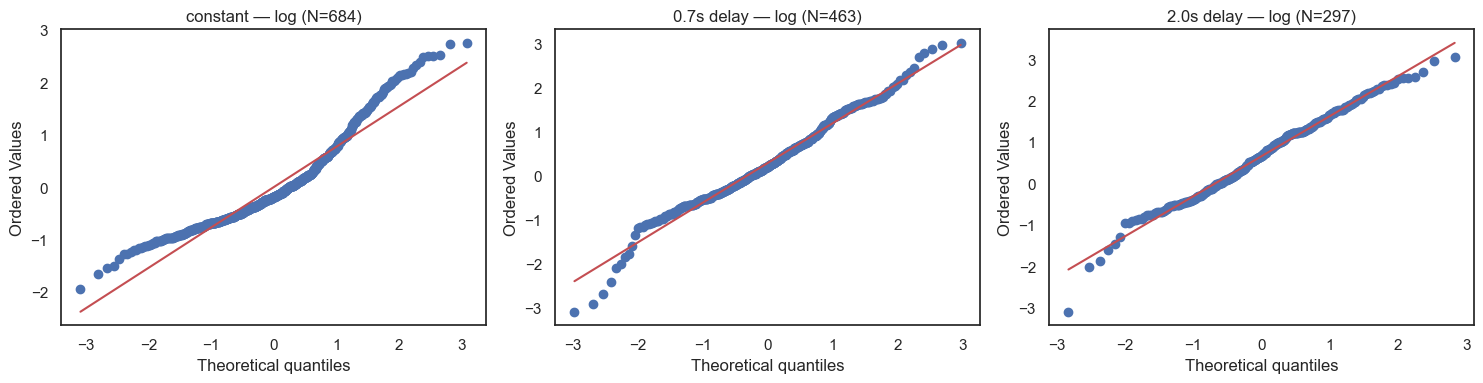

In [336]:
# =======================================================
# LOG-TRANSFORM + NORMALITY CHECK (ZEROS EXCLUDED)
# =======================================================

df_analysis["log_duration"] = np.log(df_analysis[y_col])

print("=== SHAPIRO-WILK TEST: LOG-TRANSFORMED DURATIONS ===")
for cond in condition_order:
    vals = df_analysis.loc[df_analysis["condition"] == cond, "log_duration"]
    stat, p = stats.shapiro(vals)
    print(
        f"{cond}: N={len(vals)}, W={stat:.4f}, p={p:.2e}, "
        f"skew={stats.skew(vals):.2f}, kurtosis={stats.kurtosis(vals):.2f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cond in enumerate(condition_order):
    vals = df_analysis.loc[df_analysis["condition"] == cond, "log_duration"]
    stats.probplot(vals, dist="norm", plot=axes[i])
    axes[i].set_title(f"{cond} — log (N={len(vals)})")
plt.tight_layout()
plt.savefig("qq_plots_log_model_gaze.png", dpi=150)
plt.show()

## Trial ID

## LMM on log data

                                Mixed Linear Model Regression Results
Model:                            MixedLM               Dependent Variable:               log_duration
No. Observations:                 1444                  Method:                           REML        
No. Groups:                       10                    Scale:                            0.6953      
Min. group size:                  90                    Log-Likelihood:                   -1826.4634  
Max. group size:                  260                   Converged:                        Yes         
Mean group size:                  144.4                                                               
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------------
Int

## Tukey correction

In [387]:
# =======================================================
# TUKEY-KORRIGIERTE POST-HOC-VERGLEICHE
# Log-LMM contrasts, asymptotic Tukey adjustment
# =======================================================

import numpy as np
import pandas as pd
from scipy.stats import studentized_range


# -------------------------------------------------------
# Fixed Effects und Kovarianzmatrix aus dem Log-LMM
# -------------------------------------------------------

params = result.fe_params

cov_full = result.cov_params()
cov = cov_full.loc[params.index, params.index]

print("Fixed-effect parameters:")
print(params.index.tolist())


# -------------------------------------------------------
# Namen der Condition-Koeffizienten automatisch finden
# -------------------------------------------------------

coef_07 = next(
    name for name in params.index
    if "[T.0.7s delay]" in name
)

coef_20 = next(
    name for name in params.index
    if "[T.2.0s delay]" in name
)


# -------------------------------------------------------
# Kontraste definieren
# -------------------------------------------------------

c_07_vs_constant = pd.Series(
    0.0,
    index=params.index
)
c_07_vs_constant[coef_07] = 1.0


c_20_vs_constant = pd.Series(
    0.0,
    index=params.index
)
c_20_vs_constant[coef_20] = 1.0


c_20_vs_07 = pd.Series(
    0.0,
    index=params.index
)
c_20_vs_07[coef_20] = 1.0
c_20_vs_07[coef_07] = -1.0


contrasts = {
    "0.7s delay vs constant": c_07_vs_constant,
    "2.0s delay vs constant": c_20_vs_constant,
    "2.0s delay vs 0.7s delay": c_20_vs_07
}


# -------------------------------------------------------
# Tukey-korrigierte Vergleiche berechnen
# -------------------------------------------------------

k = 3  # Anzahl der Conditions
rows = []

for comparison, c in contrasts.items():

    # Unterschied auf der Log-Skala
    estimate = float(c @ params)

    # Standardfehler des Unterschieds
    se = float(
        np.sqrt(
            c.to_numpy()
            @ cov.to_numpy()
            @ c.to_numpy()
        )
    )

    # Wald-z-Wert
    z_value = estimate / se

    # Umrechnung in Studentized-Range-Statistik
    q_value = np.sqrt(2) * abs(z_value)

    # Asymptotische Tukey-Korrektur:
    # df = unendlich, passend zur z-Inferenz von statsmodels MixedLM
    p_tukey = studentized_range.sf(
        q_value,
        k,
        np.inf
    )

    # Rücktransformation der Log-Differenz
    duration_ratio = np.exp(estimate)
    percent_change = (duration_ratio - 1) * 100

    rows.append({
        "comparison": comparison,
        "estimate_log": estimate,
        "SE": se,
        "z": z_value,
        "q": q_value,
        "p_tukey": p_tukey,
        "duration_ratio": duration_ratio,
        "percent_change": percent_change
    })


# -------------------------------------------------------
# Ergebnistabelle
# -------------------------------------------------------

tukey_results = pd.DataFrame(rows)

display(
    tukey_results.round({
        "estimate_log": 3,
        "SE": 3,
        "z": 3,
        "q": 3,
        "p_tukey": 5,
        "duration_ratio": 3,
        "percent_change": 1
    })
)

Fixed-effect parameters:
['Intercept', 'condition[T.0.7s delay]', 'condition[T.2.0s delay]']


,comparison,estimate_log,SE,z,q,p_tukey,duration_ratio,percent_change
0,0.7s delay vs constant,0.285,0.073,3.889,5.499,0.00030,1.330,33.0
1,2.0s delay vs constant,0.652,0.079,8.240,11.653,0.00000,1.920,92.0
2,2.0s delay vs 0.7s delay,0.367,0.083,4.410,6.237,0.00003,1.444,44.4


### back translation from log

In [388]:
import numpy as np
pct_07 = (np.exp(0.284) - 1) * 100
pct_20 = (np.exp(0.674) - 1) * 100
print(f"0.7s delay: {pct_07:.1f}% länger als constant")
print(f"2.0s delay: {pct_20:.1f}% länger als constant")

0.7s delay: 32.8% länger als constant
2.0s delay: 96.2% länger als constant


## Residues of LMM

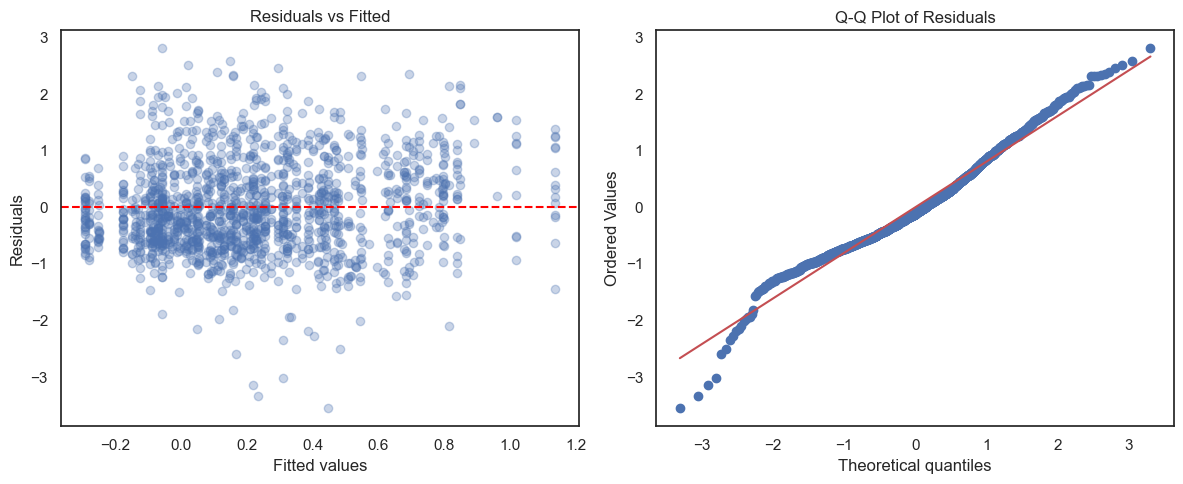

Shapiro-Wilk on residuals: W=0.9777, p=3.61e-14
Skewness: 0.307, Kurtosis: 0.739


In [389]:
# =======================================================
# RESIDUAL CHECK: LMM MODEL ASSUMPTIONS
# =======================================================

import matplotlib.pyplot as plt
from scipy import stats

residuals = result.resid
fitted = result.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuen vs Fitted (Homoskedastizität check)
axes[0].scatter(fitted, residuals, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Q-Q Plot der Residuen (Normalität check)
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.savefig("model_residual_check.png", dpi=150)
plt.show()

# Shapiro-Wilk auf Residuen
stat, p = stats.shapiro(residuals)
print(f"Shapiro-Wilk on residuals: W={stat:.4f}, p={p:.2e}")
print(f"Skewness: {stats.skew(residuals):.3f}, Kurtosis: {stats.kurtosis(residuals):.3f}")

## Friedman test as sensitivity check

In [390]:
# =======================================================
# FRIEDMAN TEST: ROBUSTNESS CHECK (PARTICIPANT-LEVEL MEANS)
# =======================================================

from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

# Proband-Mittelwerte pro Condition (auf Basis der bereits ge-zero-excludeten Daten)
participant_means = (
    df_analysis
    .groupby(["participant_id", "condition"], observed=True)[y_col]
    .mean()
    .unstack()
)

print(participant_means)

# Friedman-Test braucht 3 gleich lange Arrays (ein Wert pro Proband pro Condition)
stat, p = friedmanchisquare(
    participant_means["constant"],
    participant_means["0.7s delay"],
    participant_means["2.0s delay"]
)
print(f"\nFriedman test: chi2={stat:.3f}, p={p:.5f}")


# -------------------------------------------------------
# Post-hoc: Wilcoxon signed-rank, Holm-korrigiert
# -------------------------------------------------------

pairs = [
    ("constant", "0.7s delay"),
    ("constant", "2.0s delay"),
    ("0.7s delay", "2.0s delay"),
]

rows = []
pvals = []
for a, b in pairs:
    stat_w, p_w = wilcoxon(participant_means[a], participant_means[b])
    rows.append({"comparison": f"{a} vs {b}", "W": stat_w, "p_raw": p_w})
    pvals.append(p_w)

reject, pvals_corrected, _, _ = multipletests(pvals, method="holm")

for row, p_corr, rej in zip(rows, pvals_corrected, reject):
    row["p_holm"] = p_corr
    row["significant"] = rej

friedman_posthoc = pd.DataFrame(rows)
display(friedman_posthoc)

condition       constant  0.7s delay  2.0s delay
participant_id                                  
1               1.825306    1.838061    2.121057
10              1.057483    1.637841    2.782850
2               1.861738    1.793250    3.983000
3               1.169188    1.441342    1.843679
4               1.645563    1.648740    2.609645
5               1.512038    1.684957    2.045750
6               1.679955    2.638431    4.845233
7               1.255109    2.741269    2.834323
8               1.885431    5.698167    7.765538
9               1.338111    1.222138    3.014250

Friedman test: chi2=16.800, p=0.00022


,comparison,W,p_raw,p_holm,significant
0,constant vs 0.7s delay,7.0,0.037109,0.037109,True
1,constant vs 2.0s delay,0.0,0.001953,0.005859,True
2,0.7s delay vs 2.0s delay,0.0,0.001953,0.005859,True


### Participant 8 has higher values than the rest lets check a friedman test without P08

In [391]:
# =======================================================
# FRIEDMAN TEST: SENSITIVITY CHECK WITHOUT PARTICIPANT 8
# =======================================================

participant_means_no8 = participant_means.drop(index="08", errors="ignore")
# Falls participant_id als int gespeichert ist, stattdessen:
# participant_means_no8 = participant_means.drop(index=8, errors="ignore")

print(participant_means_no8)

stat_no8, p_no8 = friedmanchisquare(
    participant_means_no8["constant"],
    participant_means_no8["0.7s delay"],
    participant_means_no8["2.0s delay"]
)
print(f"\nFriedman test (ohne P8): chi2={stat_no8:.3f}, p={p_no8:.5f}")


# -------------------------------------------------------
# Post-hoc: Wilcoxon signed-rank, Holm-korrigiert (ohne P8)
# -------------------------------------------------------

rows_no8 = []
pvals_no8 = []
for a, b in pairs:
    stat_w, p_w = wilcoxon(participant_means_no8[a], participant_means_no8[b])
    rows_no8.append({"comparison": f"{a} vs {b}", "W": stat_w, "p_raw": p_w})
    pvals_no8.append(p_w)

reject_no8, pvals_corrected_no8, _, _ = multipletests(pvals_no8, method="holm")

for row, p_corr, rej in zip(rows_no8, pvals_corrected_no8, reject_no8):
    row["p_holm"] = p_corr
    row["significant"] = rej

friedman_posthoc_no8 = pd.DataFrame(rows_no8)
display(friedman_posthoc_no8)

condition       constant  0.7s delay  2.0s delay
participant_id                                  
1               1.825306    1.838061    2.121057
10              1.057483    1.637841    2.782850
2               1.861738    1.793250    3.983000
3               1.169188    1.441342    1.843679
4               1.645563    1.648740    2.609645
5               1.512038    1.684957    2.045750
6               1.679955    2.638431    4.845233
7               1.255109    2.741269    2.834323
8               1.885431    5.698167    7.765538
9               1.338111    1.222138    3.014250

Friedman test (ohne P8): chi2=16.800, p=0.00022


,comparison,W,p_raw,p_holm,significant
0,constant vs 0.7s delay,7.0,0.037109,0.037109,True
1,constant vs 2.0s delay,0.0,0.001953,0.005859,True
2,0.7s delay vs 2.0s delay,0.0,0.001953,0.005859,True


# Understanding data change of 80ms and 100ms

## EXTRA: wie viele gazes sind denn seit 80ms denn dazugekommen?

In [270]:
# Gazes zwischen 80 und 100 ms

between_80_100 = object_gazes_final[
    (object_gazes_final["object_gaze_duration_ms"] >= 80) &
    (object_gazes_final["object_gaze_duration_ms"] < 100)
]

print("Total gazes:", len(object_gazes_final))
print("Gazes between 80 and 100 ms:", len(between_80_100))

print(
    "Percentage:",
    round(
        len(between_80_100) / len(object_gazes_final) * 100,
        2
    ),
    "%"
)

display(
    between_80_100["object_gaze_duration_ms"].describe()
)

Total gazes: 38406
Gazes between 80 and 100 ms: 0
Percentage: 0.0 %


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: object_gaze_duration_ms, dtype: float64

## wie viele der Extra Gazes sind tatsächlich Model gazes:

## Wie viel zusätzliche Zeit geben unsere extra 22 gazes zu der model dwell time überhautp?

In [271]:
model_added = between_80_100[
    between_80_100["AOI_CLEAN"] == "MODEL"
].copy()

print("Additional MODEL gazes:", len(model_added))

print(
    "Additional MODEL dwell time:",
    model_added["object_gaze_duration_ms"].sum() / 1000,
    "seconds"
)

print(
    "Mean duration of added MODEL gazes:",
    model_added["object_gaze_duration_ms"].mean(),
    "ms"
)

Additional MODEL gazes: 0
Additional MODEL dwell time: 0.0 seconds
Mean duration of added MODEL gazes: nan ms


## INformationen über den 100ms cutoff

In [272]:
print("Total gazes:", len(object_gazes_final))
print(
    "Minimum duration:",
    object_gazes_final["object_gaze_duration_ms"].min()
)

print(
    "MODEL gazes:",
    (object_gazes_final["AOI_CLEAN"] == "MODEL").sum()
)

print(
    object_gazes_final["AOI_CLEAN"]
    .value_counts(dropna=False)
)

Total gazes: 38406
Minimum duration: 100.0
MODEL gazes: 1732
AOI_CLEAN
NaN         17771
WORK        12335
RESOURCE     6568
MODEL        1732
Name: count, dtype: int64


In [273]:
print("Expected total difference:", 40936 - len(object_gazes_final))

print(
    "Expected MODEL difference:",
    1754 - (object_gazes_final["AOI_CLEAN"] == "MODEL").sum()
)

Expected total difference: 2530
Expected MODEL difference: 22


In [316]:
# =======================================================
# DATENSTRUKTUR CHECK: MODEL GAZE EVENTS
# =======================================================

print("Shape:", model_gaze_events.shape)

print("\nAnzahl Gaze-Events pro participant_id × condition:")
display(
    model_gaze_events
    .groupby(["participant_id", "condition"], observed=True)
    .size()
    .reset_index(name="n_gaze_events")
    .head(20)
)

Shape: (1608, 12)

Anzahl Gaze-Events pro participant_id × condition:


,participant_id,condition,n_gaze_events
0,1,0.7s delay,52
1,1,2.0s delay,39
2,1,constant,62
3,10,0.7s delay,61
4,10,2.0s delay,40
5,10,constant,60
6,2,0.7s delay,72
7,2,2.0s delay,32
8,2,constant,61
9,3,0.7s delay,84


### Winzorizing model gazes

### check for normality

,condition,W,p_value,normal_verteilt (p>.05)
0,constant,0.950,0.0160,False
1,0.7s delay,0.902,0.0002,False
2,2.0s delay,0.956,0.0316,False


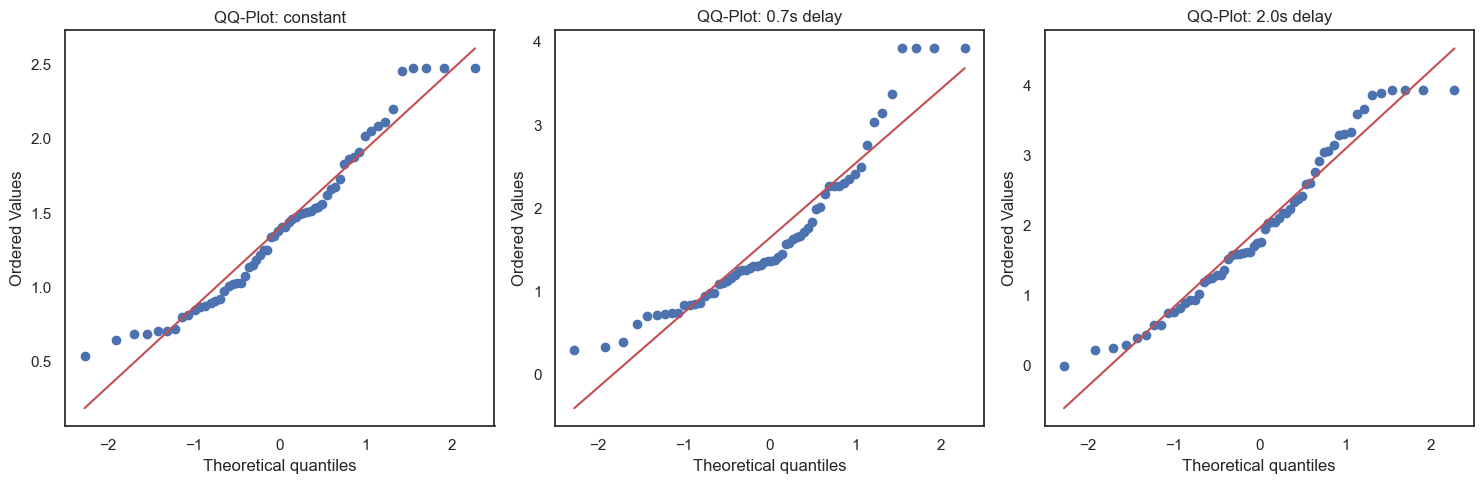

In [319]:
# =======================================================
# NORMALITY CHECK: SHAPIRO-WILK + QQ-PLOTS PER CONDITION
# =======================================================

import scipy.stats as stats
import matplotlib.pyplot as plt

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

# --- Shapiro-Wilk Test pro Condition ---
shapiro_results = []

for cond in COND_ORDER:
    vals = gaze_duration_per_trial.loc[
        gaze_duration_per_trial["condition"] == cond,
        "mean_gaze_duration_wz"
    ]
    stat, p = stats.shapiro(vals)
    shapiro_results.append({
        "condition": cond,
        "W": round(stat, 3),
        "p_value": round(p, 4),
        "normal_verteilt (p>.05)": p > 0.05
    })

shapiro_results = pd.DataFrame(shapiro_results)
display(shapiro_results)

# --- QQ-Plots pro Condition ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cond in zip(axes, COND_ORDER):
    vals = gaze_duration_per_trial.loc[
        gaze_duration_per_trial["condition"] == cond,
        "mean_gaze_duration_wz"
    ]
    stats.probplot(vals, dist="norm", plot=ax)
    ax.set_title(f"QQ-Plot: {cond}")

plt.tight_layout()
plt.savefig("qq_plots_gaze_duration.png", dpi=300, bbox_inches="tight")
plt.show()

## Set reference category

In [321]:
# 1) Referenzkategorie festlegen
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

gaze_duration_per_trial["condition"] = pd.Categorical(
    gaze_duration_per_trial["condition"],
    categories=COND_ORDER,
    ordered=False
)

# 2) LMM neu fitten
lmm_gaze_normal = smf.mixedlm(
    "mean_gaze_duration_wz ~ condition",
    data=gaze_duration_per_trial,
    groups=gaze_duration_per_trial["participant_id"]
)
lmm_gaze_normal_fit = lmm_gaze_normal.fit()
print(lmm_gaze_normal_fit.summary())

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_gaze_duration_wz
No. Observations: 180     Method:             REML                 
No. Groups:       10      Scale:              0.7076               
Min. group size:  18      Log-Likelihood:     -232.3544            
Max. group size:  18      Converged:          Yes                  
Mean group size:  18.0                                             
-------------------------------------------------------------------
                           Coef. Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                  1.397    0.147 9.474 0.000  1.108  1.686
condition[T.0.7s delay]    0.245    0.154 1.598 0.110 -0.056  0.546
condition[T.2.0s delay]    0.568    0.154 3.697 0.000  0.267  0.869
Group Var                  0.099    0.080                          



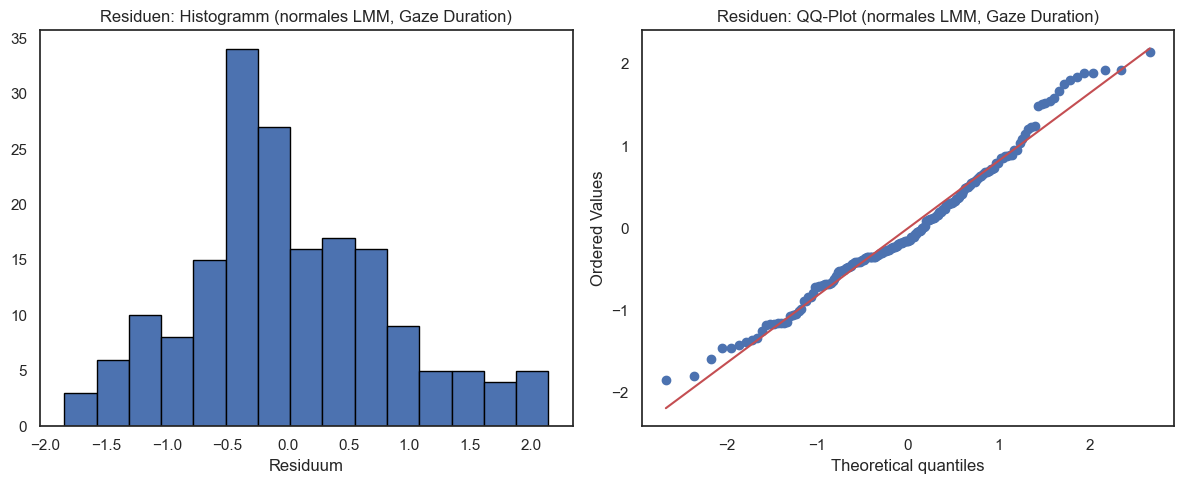

Shapiro-Wilk auf Residuen: W=0.979, p=0.0092


In [322]:
residuals_gaze_normal = lmm_gaze_normal_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals_gaze_normal, bins=15, edgecolor="black")
axes[0].set_title("Residuen: Histogramm (normales LMM, Gaze Duration)")
axes[0].set_xlabel("Residuum")

stats.probplot(residuals_gaze_normal, dist="norm", plot=axes[1])
axes[1].set_title("Residuen: QQ-Plot (normales LMM, Gaze Duration)")

plt.tight_layout()
plt.show()

stat, p = stats.shapiro(residuals_gaze_normal)
print(f"Shapiro-Wilk auf Residuen: W={stat:.3f}, p={p:.4f}")

### Tukey korrektur for model gazes

In [324]:
# =======================================================
# TUKEY-KORRIGIERTE POST-HOC-VERGLEICHE (Gaze Duration LMM)
# =======================================================

import numpy as np
import pandas as pd
from scipy.stats import studentized_range

# Fixed-Effects-Koeffizienten und Kovarianzmatrix
params = lmm_gaze_normal_fit.fe_params
cov_full = lmm_gaze_normal_fit.cov_params()
cov = cov_full.loc[params.index, params.index]

k = 3   # Anzahl Conditions
n = 10  # Anzahl Probanden
df_approx = (n - 1) * (k - 1)  # ≈ 18

# Contrasts: alle 3 Paarvergleiche
contrasts = {
    "0.7s delay vs constant":   pd.Series([0,  1, 0], index=params.index),
    "2.0s delay vs constant":   pd.Series([0,  0, 1], index=params.index),
    "2.0s delay vs 0.7s delay": pd.Series([0, -1, 1], index=params.index),
}

rows = []
for name, c in contrasts.items():
    est = float(c @ params)
    se = float(np.sqrt(c.values @ cov.values @ c.values))
    q = np.sqrt(2) * abs(est) / se
    p_tukey = 1 - studentized_range.cdf(q, k, df_approx)
    rows.append({
        "comparison": name,
        "estimate (s)": round(est, 3),
        "SE": round(se, 3),
        "q": round(q, 3),
        "p_tukey": round(p_tukey, 5)
    })

tukey_results_gaze = pd.DataFrame(rows)
display(tukey_results_gaze)

,comparison,estimate (s),SE,q,p_tukey
0,0.7s delay vs constant,0.245,0.154,2.260,0.27193
1,2.0s delay vs constant,0.568,0.154,5.229,0.00447
2,2.0s delay vs 0.7s delay,0.322,0.154,2.968,0.11818


### Log LMM

                 Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_gaze_duration_wz
No. Observations: 180     Method:             REML                     
No. Groups:       10      Scale:              0.0966                   
Min. group size:  18      Log-Likelihood:     -55.8633                 
Max. group size:  18      Converged:          Yes                      
Mean group size:  18.0                                                 
------------------------------------------------------------------------
                          Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------------------
Intercept                 0.850     0.053  15.922  0.000   0.746   0.955
condition[T.0.7s delay]   0.067     0.057   1.178  0.239  -0.044   0.178
condition[T.2.0s delay]   0.159     0.057   2.804  0.005   0.048   0.270
Group Var                 0.012     0.028                               



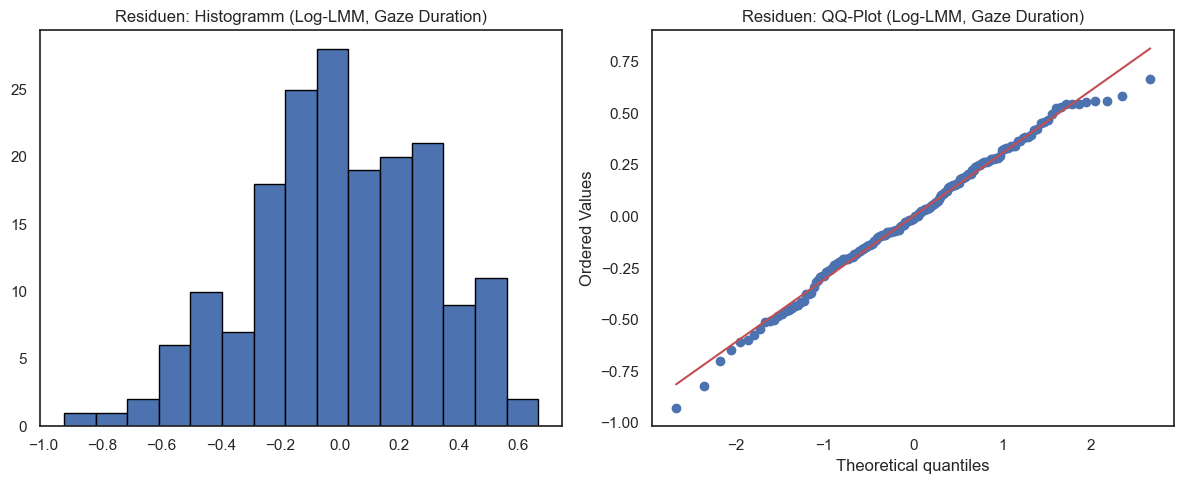

Shapiro-Wilk auf Residuen (Log-LMM): W=0.991, p=0.3391


In [325]:
# =======================================================
# LOG-LMM AUF GAZE DURATIONS
# =======================================================

gaze_duration_per_trial["log_mean_gaze_duration_wz"] = np.log(
    gaze_duration_per_trial["mean_gaze_duration_wz"] + 1
)

lmm_gaze_log = smf.mixedlm(
    "log_mean_gaze_duration_wz ~ condition",
    data=gaze_duration_per_trial,
    groups=gaze_duration_per_trial["participant_id"]
)
lmm_gaze_log_fit = lmm_gaze_log.fit()
print(lmm_gaze_log_fit.summary())

residuals_gaze_log = lmm_gaze_log_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(residuals_gaze_log, bins=15, edgecolor="black")
axes[0].set_title("Residuen: Histogramm (Log-LMM, Gaze Duration)")
stats.probplot(residuals_gaze_log, dist="norm", plot=axes[1])
axes[1].set_title("Residuen: QQ-Plot (Log-LMM, Gaze Duration)")
plt.tight_layout()
plt.show()

stat, p = stats.shapiro(residuals_gaze_log)
print(f"Shapiro-Wilk auf Residuen (Log-LMM): W={stat:.3f}, p={p:.4f}")

### Tukey korrekturen

In [326]:
# =======================================================
# TUKEY-KORRIGIERTE POST-HOC-VERGLEICHE (Log-LMM, Gaze Duration)
# =======================================================

import numpy as np
import pandas as pd
from scipy.stats import studentized_range

# Fixed-Effects-Koeffizienten und Kovarianzmatrix
params = lmm_gaze_log_fit.fe_params
cov_full = lmm_gaze_log_fit.cov_params()
cov = cov_full.loc[params.index, params.index]

k = 3   # Anzahl Conditions
n = 10  # Anzahl Probanden
df_approx = (n - 1) * (k - 1)  # ≈ 18

# Contrasts: alle 3 Paarvergleiche
contrasts = {
    "0.7s delay vs constant":   pd.Series([0,  1, 0], index=params.index),
    "2.0s delay vs constant":   pd.Series([0,  0, 1], index=params.index),
    "2.0s delay vs 0.7s delay": pd.Series([0, -1, 1], index=params.index),
}

rows = []
for name, c in contrasts.items():
    est = float(c @ params)
    se = float(np.sqrt(c.values @ cov.values @ c.values))
    q = np.sqrt(2) * abs(est) / se
    p_tukey = 1 - studentized_range.cdf(q, k, df_approx)
    rows.append({
        "comparison": name,
        "estimate (log)": round(est, 3),
        "SE": round(se, 3),
        "q": round(q, 3),
        "p_tukey": round(p_tukey, 5)
    })

tukey_results_gaze_log = pd.DataFrame(rows)
display(tukey_results_gaze_log)

,comparison,estimate (log),SE,q,p_tukey
0,0.7s delay vs constant,0.067,0.057,1.666,0.48087
1,2.0s delay vs constant,0.159,0.057,3.966,0.03004
2,2.0s delay vs 0.7s delay,0.092,0.057,2.300,0.26057


## Friedman test

In [327]:
# =======================================================
# AGGREGATION AUF PROBANDEN-EBENE + FRIEDMAN-TEST
# =======================================================

gaze_duration_per_participant = (
    gaze_duration_per_trial
    .groupby(["participant_id", "condition"], as_index=False, observed=True)
    .agg(mean_gaze_duration_wz=("mean_gaze_duration_wz", "mean"))
)

import pingouin as pg

friedman_gaze = pg.friedman(
    data=gaze_duration_per_participant,
    dv="mean_gaze_duration_wz",
    within="condition",
    subject="participant_id"
)
display(friedman_gaze)

posthoc_wilcoxon_gaze = pg.pairwise_tests(
    data=gaze_duration_per_participant,
    dv="mean_gaze_duration_wz",
    within="condition",
    subject="participant_id",
    parametric=False,
    padjust="holm"
)
display(posthoc_wilcoxon_gaze)

,Source,W,ddof1,Q,p_unc
Friedman,condition,0.43,2,8.6,0.013569


,Contrast,A,B,Paired,Parametric,W_val,alternative,p_unc,p_corr,p_adjust,hedges
0,condition,constant,0.7s delay,True,False,15.0,two-sided,0.232422,0.320312,holm,-0.543764
1,condition,constant,2.0s delay,True,False,0.0,two-sided,0.001953,0.005859,holm,-1.246621
2,condition,0.7s delay,2.0s delay,True,False,13.0,two-sided,0.160156,0.320312,holm,-0.551184


## ohne winzorisen wäre da mehr effekt da?

In [328]:
# =======================================================
# SENSITIVITÄTS-CHECK: FRIEDMAN AUF ROHDATEN (ohne Winsorizing)
# =======================================================

gaze_duration_per_participant_raw = (
    gaze_duration_per_trial
    .groupby(["participant_id", "condition"], as_index=False, observed=True)
    .agg(mean_gaze_duration_raw=("mean_gaze_duration_s", "mean"))
)

friedman_gaze_raw = pg.friedman(
    data=gaze_duration_per_participant_raw,
    dv="mean_gaze_duration_raw",
    within="condition",
    subject="participant_id"
)
display(friedman_gaze_raw)

posthoc_wilcoxon_gaze_raw = pg.pairwise_tests(
    data=gaze_duration_per_participant_raw,
    dv="mean_gaze_duration_raw",
    within="condition",
    subject="participant_id",
    parametric=False,
    padjust="holm"
)
display(posthoc_wilcoxon_gaze_raw)

,Source,W,ddof1,Q,p_unc
Friedman,condition,0.36,2,7.2,0.027324


,Contrast,A,B,Paired,Parametric,W_val,alternative,p_unc,p_corr,p_adjust,hedges
0,condition,constant,0.7s delay,True,False,16.0,two-sided,0.275391,0.550781,holm,-0.564123
1,condition,constant,2.0s delay,True,False,0.0,two-sided,0.001953,0.005859,holm,-1.236151
2,condition,0.7s delay,2.0s delay,True,False,16.0,two-sided,0.275391,0.550781,holm,-0.449824


In [329]:
# =======================================================
# DIREKTER VERGLEICH: Sind die aggregierten Werte wirklich identisch?
# =======================================================

comparison_check = gaze_duration_per_participant.merge(
    gaze_duration_per_participant_raw,
    on=["participant_id", "condition"]
)

comparison_check["difference"] = (
    comparison_check["mean_gaze_duration_wz"]
    - comparison_check["mean_gaze_duration_raw"]
)

print("Anzahl Zeilen mit Unterschied > 0.001:")
print((comparison_check["difference"].abs() > 0.001).sum())

print("\nGrößte Unterschiede:")
display(
    comparison_check
    .sort_values("difference", key=abs, ascending=False)
    .head(10)
)

print("\nMax absoluter Unterschied:", comparison_check["difference"].abs().max())

Anzahl Zeilen mit Unterschied > 0.001:
7

Größte Unterschiede:


,participant_id,condition,mean_gaze_duration_wz,mean_gaze_duration_raw,difference
25,8,0.7s delay,2.548804,3.075300,-0.526496
26,8,2.0s delay,2.302134,2.611501,-0.309367
20,6,2.0s delay,2.522424,2.775046,-0.252622
22,7,0.7s delay,2.572000,2.816333,-0.244333
8,2,2.0s delay,2.610153,2.754047,-0.143894
6,2,constant,1.578640,1.647686,-0.069046
24,8,constant,1.794768,1.816533,-0.021765
0,1,constant,1.551853,1.551853,0.000000
16,5,0.7s delay,1.548891,1.548891,0.000000
28,9,0.7s delay,0.901977,0.901977,0.000000



Max absoluter Unterschied: 0.5264962962962962


In [330]:
print("Max absoluter Unterschied:", comparison_check["difference"].abs().max())

Max absoluter Unterschied: 0.5264962962962962


 ## Build participant-level averages for delay-corrected MODEL gaze duration

In [274]:
# =======================================================
# 9) BUILD PARTICIPANT-LEVEL SUMMARIES FOR
#    CORRECTED MODEL GAZE EVENT DURATION
# =======================================================

avg_corrected_model_gaze_duration = (
    model_gaze_events
    .groupby(
        ["participant_id", "condition"],
        as_index=False,
        observed=False
    )
    .agg(
        avg_corrected_model_gaze_duration_s=(
            "corrected_model_gaze_duration_s",
            "mean"
        ),

        median_corrected_model_gaze_duration_s=(
            "corrected_model_gaze_duration_s",
            "median"
        ),

        n_model_gaze_events=(
            "corrected_model_gaze_duration_s",
            "count"
        )
    )
)


# Set condition order
avg_corrected_model_gaze_duration["condition"] = pd.Categorical(
    avg_corrected_model_gaze_duration["condition"],
    categories=COND_ORDER,
    ordered=True
)


# Sort
avg_corrected_model_gaze_duration = (
    avg_corrected_model_gaze_duration
    .sort_values(
        ["participant_id", "condition"]
    )
)


print(
    "Participant-level corrected MODEL gaze event duration summaries:"
)

display(
    avg_corrected_model_gaze_duration.head(30)
)


print("Participants per condition:")

display(
    avg_corrected_model_gaze_duration
    .groupby(
        "condition",
        observed=False
    )["participant_id"]
    .nunique()
)

Participant-level corrected MODEL gaze event duration summaries:


,participant_id,condition,avg_corrected_model_gaze_duration_s,median_corrected_model_gaze_duration_s,n_model_gaze_events
2,1,constant,1.825306,0.9725,62
0,1,0.7s delay,1.732019,0.9000,52
1,1,2.0s delay,1.903513,1.0000,39
5,10,constant,1.057483,0.6325,60
3,10,0.7s delay,1.181393,0.8880,61
4,10,2.0s delay,1.391425,0.1165,40
8,2,constant,1.861738,1.0000,61
6,2,0.7s delay,1.594000,0.9550,72
7,2,2.0s delay,3.485125,1.8385,32
11,3,constant,1.169188,0.7435,128


Participants per condition:


condition
constant      10
0.7s delay    10
2.0s delay    10
Name: participant_id, dtype: int64

## Build group summary for corrected MODEL gaze duration only

In [275]:
# =======================================================
# 10) BUILD GROUP SUMMARY FOR
#     CORRECTED MODEL GAZE EVENT DURATION
# =======================================================

corrected_model_gaze_duration_group_summary = (
    avg_corrected_model_gaze_duration
    .groupby(
        "condition",
        as_index=False,
        observed=False
    )
    .agg(
        mean_corrected_model_gaze_duration_s=(
            "avg_corrected_model_gaze_duration_s",
            "mean"
        ),

        sd_corrected_model_gaze_duration_s=(
            "avg_corrected_model_gaze_duration_s",
            "std"
        ),

        median_corrected_model_gaze_duration_s=(
            "avg_corrected_model_gaze_duration_s",
            "median"
        ),

        n_participants=(
            "participant_id",
            "nunique"
        )
    )
)


corrected_model_gaze_duration_group_summary[
    "se_corrected_model_gaze_duration_s"
] = (
    corrected_model_gaze_duration_group_summary[
        "sd_corrected_model_gaze_duration_s"
    ]
    /
    np.sqrt(
        corrected_model_gaze_duration_group_summary[
            "n_participants"
        ]
    )
)


corrected_model_gaze_duration_group_summary = (
    corrected_model_gaze_duration_group_summary
    .sort_values("condition")
)


print(
    "Group summary for corrected MODEL gaze event duration:"
)

display(
    corrected_model_gaze_duration_group_summary
)

Group summary for corrected MODEL gaze event duration:


,condition,mean_corrected_model_gaze_duration_s,sd_corrected_model_gaze_duration_s,median_corrected_model_gaze_duration_s,n_participants,se_corrected_model_gaze_duration_s
0,constant,1.522992,0.302784,1.578800,10,0.095749
1,0.7s delay,1.821407,0.634720,1.588930,10,0.200716
2,2.0s delay,2.360921,0.837644,2.098938,10,0.264886


## Participant trajectories

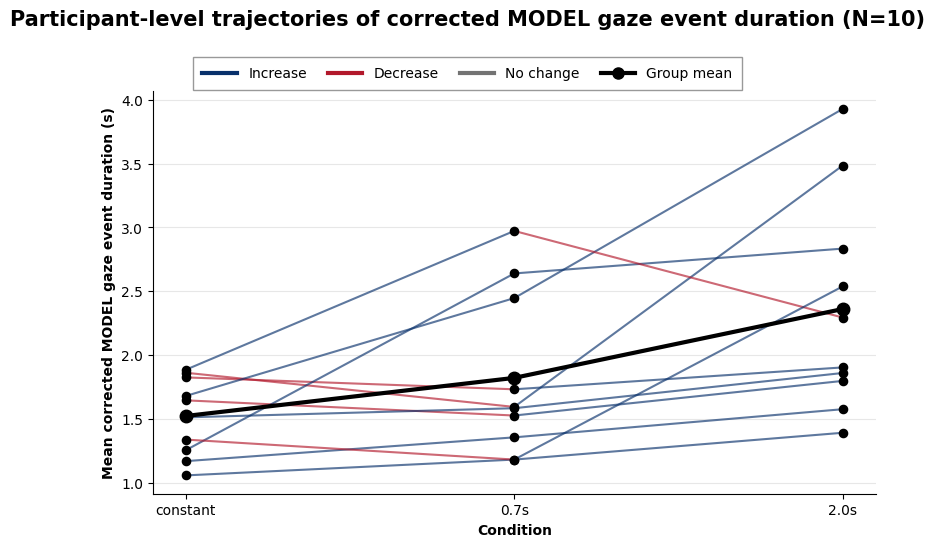

In [276]:
# =======================================================
# PARTICIPANT-LEVEL TRAJECTORIES:
# CORRECTED MODEL GAZE EVENT DURATION
# =======================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


# =====================
# Settings
# =====================

COND_ORDER = [
    "constant",
    "0.7s delay",
    "2.0s delay"
]

COND_LABELS = [
    "constant",
    "0.7s",
    "2.0s"
]

COL_INCREASE = "#08306b"
COL_DECREASE = "#b2182b"
COL_EQUAL = "#737373"
COL_MEAN = "black"


# =====================
# Prepare data
# =====================

plot_data = avg_corrected_model_gaze_duration.copy()


plot_data["condition"] = pd.Categorical(
    plot_data["condition"],
    categories=COND_ORDER,
    ordered=True
)


plot_data = plot_data.sort_values(
    ["participant_id", "condition"]
)


# =====================
# Keep only participants
# with all three conditions
# =====================

complete_participants = (
    plot_data
    .groupby(
        "participant_id",
        observed=False
    )["condition"]
    .nunique()
)

complete_participants = complete_participants[
    complete_participants == len(COND_ORDER)
].index


plot_data = plot_data[
    plot_data["participant_id"]
    .isin(complete_participants)
].copy()


# Number of participants actually shown
n_participants = (
    plot_data["participant_id"]
    .nunique()
)


x = np.arange(
    len(COND_ORDER)
)


# =====================
# Plot
# =====================

fig, ax = plt.subplots(
    figsize=(8.5, 5.8)
)


for pid, sub in plot_data.groupby("participant_id"):

    sub = sub.sort_values("condition")

    y = sub[
        "avg_corrected_model_gaze_duration_s"
    ].values


    # Participant points
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )


    # ---------------------
    # Segment 1:
    # constant -> 0.7s
    # ---------------------

    diff1 = y[1] - y[0]

    if diff1 > 0:
        color1 = COL_INCREASE

    elif diff1 < 0:
        color1 = COL_DECREASE

    else:
        color1 = COL_EQUAL


    ax.plot(
        x[:2],
        y[:2],
        color=color1,
        linewidth=1.5,
        alpha=0.65,
        zorder=2
    )


    # ---------------------
    # Segment 2:
    # 0.7s -> 2.0s
    # ---------------------

    diff2 = y[2] - y[1]

    if diff2 > 0:
        color2 = COL_INCREASE

    elif diff2 < 0:
        color2 = COL_DECREASE

    else:
        color2 = COL_EQUAL


    ax.plot(
        x[1:],
        y[1:],
        color=color2,
        linewidth=1.5,
        alpha=0.65,
        zorder=2
    )


# =====================
# Group mean
# =====================

group_means = (
    plot_data
    .groupby(
        "condition",
        observed=False
    )[
        "avg_corrected_model_gaze_duration_s"
    ]
    .mean()
    .reindex(COND_ORDER)
)


ax.plot(
    x,
    group_means.values,
    color=COL_MEAN,
    linewidth=3,
    marker="o",
    markersize=9,
    zorder=4
)


# =====================
# Legend
# =====================

legend_elements = [

    Line2D(
        [0], [0],
        color=COL_INCREASE,
        lw=3,
        label="Increase"
    ),

    Line2D(
        [0], [0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease"
    ),

    Line2D(
        [0], [0],
        color=COL_EQUAL,
        lw=3,
        label="No change"
    ),

    Line2D(
        [0], [0],
        color=COL_MEAN,
        lw=3,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]


fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.885),
    ncol=4,
    frameon=True,
    fancybox=False,
    edgecolor="0.6",
    facecolor="white",
    framealpha=1.0,
    fontsize=10,
    handlelength=2.5,
    columnspacing=1.5,
    borderpad=0.7
)


# =====================
# Formatting
# =====================

ax.set_xticks(x)

ax.set_xticklabels(
    COND_LABELS
)


ax.set_xlabel(
    "Condition",
    fontweight="bold"
)


ax.set_ylabel(
    "Mean corrected MODEL gaze event duration (s)",
    fontweight="bold"
)


fig.suptitle(
    f"Participant-level trajectories of corrected MODEL gaze event duration "
    f"(N={n_participants})",
    fontweight="bold",
    fontsize=15,
    y=0.955
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.grid(
    axis="y",
    alpha=0.3
)

ax.set_axisbelow(True)


fig.subplots_adjust(
    top=0.815,
    bottom=0.12,
    left=0.13,
    right=0.98
)


plt.show()
plt.close(fig)

## group mean number MODEL AOI GAZE EVENT

In [277]:
# =======================================================
# CHECK NUMBER OF MODEL GAZE EVENTS PER CONDITION
# =======================================================

print("Number of MODEL gaze events per condition:")

display(
    model_gaze_events
    .groupby("condition", observed=False)
    .size()
    .reset_index(name="n_model_gaze_events")
)

Number of MODEL gaze events per condition:


,condition,n_model_gaze_events
0,0.7s delay,531
1,2.0s delay,393
2,constant,684


In [278]:
# =======================================================
# PARTICIPANT-LEVEL SUMMARY:
# CORRECTED MODEL GAZE EVENT DURATION
# =======================================================

avg_corrected_model_gaze_duration = (
    model_gaze_events
    .groupby(
        ["participant_id", "condition"],
        as_index=False,
        observed=False
    )
    .agg(
        avg_corrected_model_gaze_duration_s=(
            "corrected_model_gaze_duration_s",
            "mean"
        ),
        median_corrected_model_gaze_duration_s=(
            "corrected_model_gaze_duration_s",
            "median"
        ),
        n_model_gaze_events=(
            "corrected_model_gaze_duration_s",
            "count"
        )
    )
)

avg_corrected_model_gaze_duration["condition"] = pd.Categorical(
    avg_corrected_model_gaze_duration["condition"],
    categories=COND_ORDER,
    ordered=True
)

avg_corrected_model_gaze_duration = (
    avg_corrected_model_gaze_duration
    .sort_values(
        ["participant_id", "condition"]
    )
)

print("Participant-level corrected MODEL gaze event duration summary:")

display(
    avg_corrected_model_gaze_duration
)

Participant-level corrected MODEL gaze event duration summary:


,participant_id,condition,avg_corrected_model_gaze_duration_s,median_corrected_model_gaze_duration_s,n_model_gaze_events
2,1,constant,1.825306,0.9725,62
0,1,0.7s delay,1.732019,0.9000,52
1,1,2.0s delay,1.903513,1.0000,39
5,10,constant,1.057483,0.6325,60
3,10,0.7s delay,1.181393,0.8880,61
4,10,2.0s delay,1.391425,0.1165,40
8,2,constant,1.861738,1.0000,61
6,2,0.7s delay,1.594000,0.9550,72
7,2,2.0s delay,3.485125,1.8385,32
11,3,constant,1.169188,0.7435,128


In [279]:
# =======================================================
# GROUP SUMMARY:
# CORRECTED MODEL GAZE EVENT DURATION
# =======================================================

corrected_model_gaze_duration_group_summary = (
    avg_corrected_model_gaze_duration
    .groupby(
        "condition",
        as_index=False,
        observed=False
    )
    .agg(
        mean_corrected_model_gaze_duration_s=(
            "avg_corrected_model_gaze_duration_s",
            "mean"
        ),
        sd_corrected_model_gaze_duration_s=(
            "avg_corrected_model_gaze_duration_s",
            "std"
        ),
        median_corrected_model_gaze_duration_s=(
            "avg_corrected_model_gaze_duration_s",
            "median"
        ),
        n_participants=(
            "participant_id",
            "nunique"
        )
    )
)

corrected_model_gaze_duration_group_summary[
    "se_corrected_model_gaze_duration_s"
] = (
    corrected_model_gaze_duration_group_summary[
        "sd_corrected_model_gaze_duration_s"
    ]
    /
    np.sqrt(
        corrected_model_gaze_duration_group_summary[
            "n_participants"
        ]
    )
)

corrected_model_gaze_duration_group_summary = (
    corrected_model_gaze_duration_group_summary
    .sort_values("condition")
)

print("Group summary for corrected MODEL gaze event duration:")

display(
    corrected_model_gaze_duration_group_summary
)

Group summary for corrected MODEL gaze event duration:


,condition,mean_corrected_model_gaze_duration_s,sd_corrected_model_gaze_duration_s,median_corrected_model_gaze_duration_s,n_participants,se_corrected_model_gaze_duration_s
0,constant,1.522992,0.302784,1.578800,10,0.095749
1,0.7s delay,1.821407,0.634720,1.588930,10,0.200716
2,2.0s delay,2.360921,0.837644,2.098938,10,0.264886


In [280]:
# =======================================================
# RAW VS CORRECTED MODEL GAZE EVENT SUMMARY
# =======================================================

raw_vs_corrected_summary = (
    model_gaze_events
    .groupby("condition", observed=False)
    .agg(
        n_events=(
            "corrected_model_gaze_duration_s",
            "size"
        ),
        mean_raw_s=(
            "raw_model_gaze_duration_s",
            "mean"
        ),
        median_raw_s=(
            "raw_model_gaze_duration_s",
            "median"
        ),
        mean_corrected_s=(
            "corrected_model_gaze_duration_s",
            "mean"
        ),
        median_corrected_s=(
            "corrected_model_gaze_duration_s",
            "median"
        ),
        mean_delay_correction_s=(
            "delay_correction_s",
            "mean"
        )
    )
    .reset_index()
)

display(raw_vs_corrected_summary)

,condition,n_events,mean_raw_s,median_raw_s,mean_corrected_s,median_corrected_s,mean_delay_correction_s
0,0.7s delay,531,2.411652,1.735,1.752213,1.035,0.659439
1,2.0s delay,393,3.958969,3.200,2.250033,1.200,1.708936
2,constant,684,1.499665,0.822,1.499665,0.822,0.000000


#### Wer waren die 2 hohen punkte bei 2,0s delay?

In [281]:
# =======================================================
# IDENTIFY THE 2 PARTICIPANTS WITH THE HIGHEST
# CORRECTED MODEL GAZE DURATION IN THE 2.0S CONDITION
# =======================================================

top2_participants_2s = (
    avg_corrected_model_gaze_duration[
        avg_corrected_model_gaze_duration["condition"] == "2.0s delay"
    ]
    .sort_values(
        "avg_corrected_model_gaze_duration_s",
        ascending=False
    )
    .head(2)
)

display(top2_participants_2s)

,participant_id,condition,avg_corrected_model_gaze_duration_s,median_corrected_model_gaze_duration_s,n_model_gaze_events
19,6,2.0s delay,3.928568,2.4670,37
7,2,2.0s delay,3.485125,1.8385,32


## Inferential statistic - Modle gaze duration with: LMM

In [282]:
import numpy as np
import statsmodels.formula.api as smf

# 1. Nur echte Blicke (>0 Sek) für die Log-Transformation filtern
df_lmm = model_gaze_events[model_gaze_events["corrected_model_gaze_duration_s"] > 0].copy()

# 2. Log-Transformation der Blickdauer (Standard bei LMMs für Eye-Tracking Daten)
df_lmm["log_gaze_duration"] = np.log(df_lmm["corrected_model_gaze_duration_s"])

# 3. Linear Mixed Model (LMM) anpassen
model_lmm = smf.mixedlm(
    "log_gaze_duration ~ C(condition, Treatment(reference='constant'))",
    data=df_lmm,
    groups=df_lmm["participant_id"]
)

results_lmm = model_lmm.fit()

# 4. Output anzeigen
print("==============================================================================")
print("LMM SUMMARY: MODEL GAZE EVENT DURATION (log-transformed)")
print("==============================================================================")
print(results_lmm.summary())

LMM SUMMARY: MODEL GAZE EVENT DURATION (log-transformed)
                                Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             log_gaze_duration
No. Observations:               1444                Method:                         REML             
No. Groups:                     10                  Scale:                          0.7243           
Min. group size:                90                  Log-Likelihood:                 -1830.8157       
Max. group size:                260                 Converged:                      Yes              
Mean group size:                144.4                                                                
-----------------------------------------------------------------------------------------------------
                                                            Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------


SHAPIRO-WILK TEST OF LOG-LMM RESIDUALS
W = 0.9818
p < 0.0001


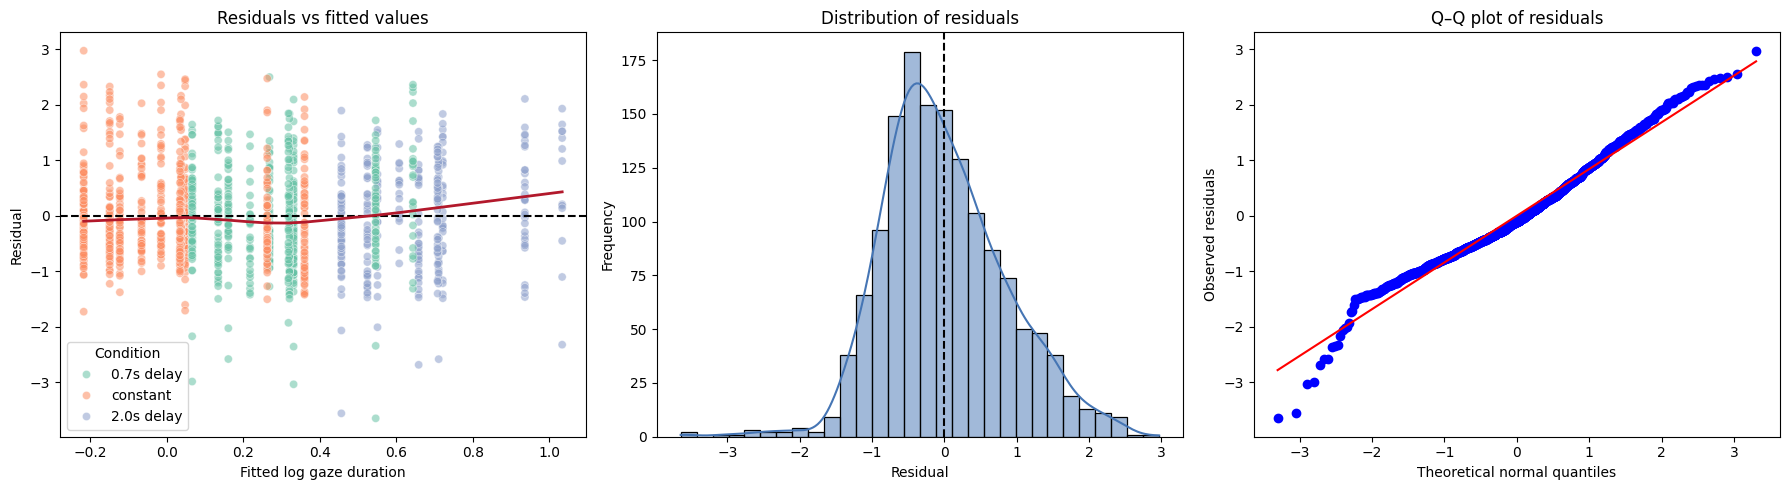

In [285]:
# =======================================================
# DIAGNOSTICS: LOG-LMM OF MODEL GAZE EVENT DURATION
# =======================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro

# Fitted values and residuals
df_lmm["fitted_log_gaze"] = results_lmm.fittedvalues
df_lmm["residual_log_gaze"] = results_lmm.resid

fitted = df_lmm["fitted_log_gaze"]
residuals = df_lmm["residual_log_gaze"]

# =======================================================
# 1. SHAPIRO-WILK TEST OF RESIDUALS
# =======================================================

# For more than 5000 residuals, use a reproducible sample
if len(residuals) > 5000:
    residuals_shapiro = residuals.sample(
        n=5000,
        random_state=42
    )
    print("Shapiro-Wilk calculated on 5000 sampled residuals.")
else:
    residuals_shapiro = residuals

W, p = shapiro(residuals_shapiro)

print("\n" + "=" * 55)
print("SHAPIRO-WILK TEST OF LOG-LMM RESIDUALS")
print("=" * 55)
print(f"W = {W:.4f}")

if p < 0.0001:
    print("p < 0.0001")
else:
    print(f"p = {p:.4f}")

# =======================================================
# 2. DIAGNOSTIC PLOTS
# =======================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Residuals vs fitted
sns.scatterplot(
    data=df_lmm,
    x="fitted_log_gaze",
    y="residual_log_gaze",
    hue="condition",
    palette="Set2",
    alpha=0.55,
    s=35,
    ax=axes[0]
)

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

sns.regplot(
    data=df_lmm,
    x="fitted_log_gaze",
    y="residual_log_gaze",
    scatter=False,
    lowess=True,
    color="#b2182b",
    line_kws={"linewidth": 2},
    ax=axes[0]
)

axes[0].set_title("Residuals vs fitted values")
axes[0].set_xlabel("Fitted log gaze duration")
axes[0].set_ylabel("Residual")
axes[0].legend(title="Condition")

# B. Histogram
sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="#4575b4",
    ax=axes[1]
)

axes[1].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

axes[1].set_title("Distribution of residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

# C. Q-Q plot
stats.probplot(
    residuals,
    dist="norm",
    plot=axes[2]
)

axes[2].set_title("Q–Q plot of residuals")
axes[2].set_xlabel("Theoretical normal quantiles")
axes[2].set_ylabel("Observed residuals")

plt.tight_layout()
plt.show()

In [283]:
import numpy as np
import statsmodels.formula.api as smf

# 1. Daten filtern & Log-Transformation
df_lmm = model_gaze_events[model_gaze_events["corrected_model_gaze_duration_s"] > 0].copy()
df_lmm["log_gaze_duration"] = np.log(df_lmm["corrected_model_gaze_duration_s"])

# 2. Linear Mixed Model (LMM) anpassen
model_lmm = smf.mixedlm(
    "log_gaze_duration ~ C(condition, Treatment(reference='constant'))",
    data=df_lmm,
    groups=df_lmm["participant_id"]
)
results_lmm = model_lmm.fit()

# 3. Model Summary ausgeben
print("==============================================================================")
print("LMM SUMMARY: MODEL GAZE EVENT DURATION (log-transformed)")
print("==============================================================================")
print(results_lmm.summary())

# 4. Paarvergleiche via exakter Kontrastmatrix
# Spalten-Reihenfolge der Regressoren: [Intercept, 0.7s delay, 2.0s delay]
matrix = np.array([
    [0, 1, 0],   # c0: 0.7s delay vs. constant
    [0, 0, 1],   # c1: 2.0s delay vs. constant
    [0, -1, 1]   # c2: 2.0s delay vs. 0.7s delay
])

print("\n==============================================================================")
print("ALL 3 PAIRWISE COMPARISONS (GAZE DURATION)")
print("c0 = 0.7s vs. constant | c1 = 2.0s vs. constant | c2 = 2.0s vs. 0.7s")
print("==============================================================================")
print(results_lmm.t_test(matrix))

LMM SUMMARY: MODEL GAZE EVENT DURATION (log-transformed)
                                Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             log_gaze_duration
No. Observations:               1444                Method:                         REML             
No. Groups:                     10                  Scale:                          0.7243           
Min. group size:                90                  Log-Likelihood:                 -1830.8157       
Max. group size:                260                 Converged:                      Yes              
Mean group size:                144.4                                                                
-----------------------------------------------------------------------------------------------------
                                                            Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------

## who decreased from 0.7 to 2.0 delay?

In [284]:
# =======================================================
# IDENTIFY PARTICIPANT WITH DECREASE FROM
# 0.7S TO 2.0S DELAY
# =======================================================

participant_decrease = (
    avg_corrected_model_gaze_duration
    .pivot(
        index="participant_id",
        columns="condition",
        values="avg_corrected_model_gaze_duration_s"
    )
    .reset_index()
)

participant_decrease["diff_0.7s_to_2.0s"] = (
    participant_decrease["2.0s delay"]
    -
    participant_decrease["0.7s delay"]
)

participant_decrease = (
    participant_decrease[
        participant_decrease["diff_0.7s_to_2.0s"] < 0
    ]
    .sort_values(
        "diff_0.7s_to_2.0s",
        ascending=True
    )
)

display(participant_decrease)

condition,participant_id,constant,0.7s delay,2.0s delay,diff_0.7s_to_2.0s
8,8,1.885431,2.972957,2.294364,-0.678593


# 2. Behavioural indicators of increased memory reliance
## Relative dwell time
### Build clean data base

In [171]:
# =======================================================
# 1) BUILD AOI DWELL BASE
# =======================================================

import numpy as np
import pandas as pd

# =====================
# Settings
# =====================

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
TASK_AOIS = ["MODEL", "WORK", "RESOURCE"]

# =====================
# Prepare data
# =====================

aoi_dwell_base = object_gazes_final.copy()

# Standardize relevant columns
aoi_dwell_base["participant_id"] = (
    aoi_dwell_base["participant_id"]
    .astype(str)
    .str.strip()
)

aoi_dwell_base["model_name"] = (
    aoi_dwell_base["model_name"]
    .astype(str)
    .str.strip()
)

aoi_dwell_base["condition"] = (
    aoi_dwell_base["condition"]
    .astype(str)
    .str.strip()
)

aoi_dwell_base["AOI_CLEAN"] = (
    aoi_dwell_base["AOI_CLEAN"]
    .astype(str)
    .str.strip()
    .str.upper()
)

aoi_dwell_base["object_gaze_duration_ms"] = pd.to_numeric(
    aoi_dwell_base["object_gaze_duration_ms"],
    errors="coerce"
)

# Keep only expected conditions
aoi_dwell_base = aoi_dwell_base[
    aoi_dwell_base["condition"].isin(COND_ORDER)
].copy()

# Keep only clean task AOIs
aoi_dwell_base = aoi_dwell_base[
    aoi_dwell_base["AOI_CLEAN"].isin(TASK_AOIS)
].copy()

# Remove rows with missing gaze duration
aoi_dwell_base = aoi_dwell_base[
    aoi_dwell_base["object_gaze_duration_ms"].notna()
].copy()

# Optional but useful: remove impossible negative durations
aoi_dwell_base = aoi_dwell_base[
    aoi_dwell_base["object_gaze_duration_ms"] >= 0
].copy()

# Restore clean categorical order for display and plotting
aoi_dwell_base["condition"] = pd.Categorical(
    aoi_dwell_base["condition"],
    categories=COND_ORDER,
    ordered=True
)

aoi_dwell_base["AOI_CLEAN"] = pd.Categorical(
    aoi_dwell_base["AOI_CLEAN"],
    categories=TASK_AOIS,
    ordered=True
)

# Sort for readability
aoi_dwell_base = aoi_dwell_base.sort_values(
    ["participant_id", "model_name", "condition", "AOI_CLEAN"]
).reset_index(drop=True)

# =====================
# Checks
# =====================

print("aoi_dwell_base shape:", aoi_dwell_base.shape)

display(
    aoi_dwell_base[
        [
            "participant_id",
            "model_name",
            "condition",
            "AOI_CLEAN",
            "object_gaze_duration_ms"
        ]
    ].head(20)
)

print("AOI_CLEAN counts:")
display(aoi_dwell_base["AOI_CLEAN"].value_counts())

print("Conditions:")
display(aoi_dwell_base["condition"].value_counts())

print("Missing values in relevant columns:")
display(
    aoi_dwell_base[
        [
            "participant_id",
            "model_name",
            "condition",
            "AOI_CLEAN",
            "object_gaze_duration_ms"
        ]
    ].isna().sum()
)

aoi_dwell_base shape: (20635, 43)


,participant_id,model_name,condition,AOI_CLEAN,object_gaze_duration_ms
0,1,C1M1F,0.7s delay,MODEL,2056.0
1,1,C1M1F,0.7s delay,MODEL,1556.0
2,1,C1M1F,0.7s delay,MODEL,279.0
3,1,C1M1F,0.7s delay,WORK,190.0
4,1,C1M1F,0.7s delay,WORK,134.0
5,1,C1M1F,0.7s delay,WORK,401.0
6,1,C1M1F,0.7s delay,WORK,790.0
7,1,C1M1F,0.7s delay,WORK,110.0
8,1,C1M1F,0.7s delay,WORK,134.0
9,1,C1M1F,0.7s delay,WORK,355.0


AOI_CLEAN counts:


AOI_CLEAN
WORK        12335
RESOURCE     6568
MODEL        1732
Name: count, dtype: int64

Conditions:


condition
constant      7031
2.0s delay    7005
0.7s delay    6599
Name: count, dtype: int64

Missing values in relevant columns:


participant_id             0
model_name                 0
condition                  0
AOI_CLEAN                  0
object_gaze_duration_ms    0
dtype: int64

## Compute AOI dwell time per trial

In [172]:
# =======================================================
# 2) COMPUTE AOI DWELL TIME PER TRIAL
# =======================================================

# Make a safe copy for grouping
aoi_dwell_group_data = aoi_dwell_base.copy()

# Convert categorical columns to strings before groupby
# This avoids pandas categorical groupby issues
aoi_dwell_group_data["condition"] = (
    aoi_dwell_group_data["condition"]
    .astype(str)
)

aoi_dwell_group_data["AOI_CLEAN"] = (
    aoi_dwell_group_data["AOI_CLEAN"]
    .astype(str)
)

aoi_dwell_per_trial_long = (
    aoi_dwell_group_data
    .groupby(
        ["participant_id", "model_name", "condition", "AOI_CLEAN"],
        as_index=False
    )
    .agg(
        aoi_dwell_ms=("object_gaze_duration_ms", "sum"),
        n_gazes=("object_gaze_duration_ms", "count")
    )
)

aoi_dwell_per_trial_long["aoi_dwell_s"] = (
    aoi_dwell_per_trial_long["aoi_dwell_ms"] / 1000
)

# Restore categorical order
aoi_dwell_per_trial_long["condition"] = pd.Categorical(
    aoi_dwell_per_trial_long["condition"],
    categories=COND_ORDER,
    ordered=True
)

aoi_dwell_per_trial_long["AOI_CLEAN"] = pd.Categorical(
    aoi_dwell_per_trial_long["AOI_CLEAN"],
    categories=TASK_AOIS,
    ordered=True
)

aoi_dwell_per_trial_long = aoi_dwell_per_trial_long.sort_values(
    ["participant_id", "model_name", "condition", "AOI_CLEAN"]
).reset_index(drop=True)

print("AOI dwell per trial long shape:", aoi_dwell_per_trial_long.shape)

display(aoi_dwell_per_trial_long.head(20))

print("AOI rows per condition:")
display(aoi_dwell_per_trial_long["condition"].value_counts())

print("AOI rows per AOI:")
display(aoi_dwell_per_trial_long["AOI_CLEAN"].value_counts())

AOI dwell per trial long shape: (540, 7)


,participant_id,model_name,condition,AOI_CLEAN,aoi_dwell_ms,n_gazes,aoi_dwell_s
0,1,C1M1F,0.7s delay,MODEL,3891.0,3,3.891
1,1,C1M1F,0.7s delay,WORK,48525.0,106,48.525
2,1,C1M1F,0.7s delay,RESOURCE,10713.0,27,10.713
3,1,C1M2A,constant,MODEL,6700.0,4,6.700
4,1,C1M2A,constant,WORK,25231.0,60,25.231
5,1,C1M2A,constant,RESOURCE,11621.0,21,11.621
6,1,C1M3F,constant,MODEL,2721.0,4,2.721
7,1,C1M3F,constant,WORK,31848.0,63,31.848
8,1,C1M3F,constant,RESOURCE,9549.0,15,9.549
9,1,C1M4A,0.7s delay,MODEL,10268.0,5,10.268


AOI rows per condition:


condition
constant      180
0.7s delay    180
2.0s delay    180
Name: count, dtype: int64

AOI rows per AOI:


AOI_CLEAN
MODEL       180
WORK        180
RESOURCE    180
Name: count, dtype: int64

## Complete AOI rows for every trial

In [173]:
# =======================================================
# 3) COMPLETE AOI ROWS FOR EVERY TRIAL
# =======================================================

# Make safe copies for merging
trial_source = aoi_dwell_base.copy()
aoi_dwell_complete = aoi_dwell_per_trial_long.copy()

# Convert merge keys to strings
trial_source["condition"] = trial_source["condition"].astype(str)
trial_source["AOI_CLEAN"] = trial_source["AOI_CLEAN"].astype(str)

aoi_dwell_complete["condition"] = aoi_dwell_complete["condition"].astype(str)
aoi_dwell_complete["AOI_CLEAN"] = aoi_dwell_complete["AOI_CLEAN"].astype(str)

# Trial index
trial_index = (
    trial_source[
        ["participant_id", "model_name", "condition"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# AOI index
aoi_index = pd.DataFrame({"AOI_CLEAN": TASK_AOIS})

# Cross join: every trial × every AOI
trial_aoi_index = trial_index.merge(
    aoi_index,
    how="cross"
)

# Merge actual dwell values onto complete index
aoi_dwell_per_trial_long = trial_aoi_index.merge(
    aoi_dwell_complete,
    on=["participant_id", "model_name", "condition", "AOI_CLEAN"],
    how="left"
)

# Fill missing AOI dwell values with 0
aoi_dwell_per_trial_long["aoi_dwell_ms"] = (
    aoi_dwell_per_trial_long["aoi_dwell_ms"].fillna(0)
)

aoi_dwell_per_trial_long["aoi_dwell_s"] = (
    aoi_dwell_per_trial_long["aoi_dwell_s"].fillna(0)
)

aoi_dwell_per_trial_long["n_gazes"] = (
    aoi_dwell_per_trial_long["n_gazes"].fillna(0)
)

# Restore categorical order
aoi_dwell_per_trial_long["condition"] = pd.Categorical(
    aoi_dwell_per_trial_long["condition"],
    categories=COND_ORDER,
    ordered=True
)

aoi_dwell_per_trial_long["AOI_CLEAN"] = pd.Categorical(
    aoi_dwell_per_trial_long["AOI_CLEAN"],
    categories=TASK_AOIS,
    ordered=True
)

# Sort for readability
aoi_dwell_per_trial_long = aoi_dwell_per_trial_long.sort_values(
    ["participant_id", "model_name", "condition", "AOI_CLEAN"]
).reset_index(drop=True)

print("Completed AOI dwell per trial long shape:", aoi_dwell_per_trial_long.shape)

display(aoi_dwell_per_trial_long.head(20))

print("AOI rows per trial check:")
rows_per_trial_check = (
    aoi_dwell_per_trial_long
    .assign(condition=lambda df: df["condition"].astype(str))
    .groupby(
        ["participant_id", "model_name", "condition"],
        as_index=False
    )
    .agg(
        n_AOI_rows=("AOI_CLEAN", "count")
    )
)

display(rows_per_trial_check["n_AOI_rows"].value_counts())

Completed AOI dwell per trial long shape: (540, 7)


,participant_id,model_name,condition,AOI_CLEAN,aoi_dwell_ms,n_gazes,aoi_dwell_s
0,1,C1M1F,0.7s delay,MODEL,3891.0,3,3.891
1,1,C1M1F,0.7s delay,WORK,48525.0,106,48.525
2,1,C1M1F,0.7s delay,RESOURCE,10713.0,27,10.713
3,1,C1M2A,constant,MODEL,6700.0,4,6.700
4,1,C1M2A,constant,WORK,25231.0,60,25.231
5,1,C1M2A,constant,RESOURCE,11621.0,21,11.621
6,1,C1M3F,constant,MODEL,2721.0,4,2.721
7,1,C1M3F,constant,WORK,31848.0,63,31.848
8,1,C1M3F,constant,RESOURCE,9549.0,15,9.549
9,1,C1M4A,0.7s delay,MODEL,10268.0,5,10.268


AOI rows per trial check:


n_AOI_rows
3    180
Name: count, dtype: int64

## Compute total task dwell time per trial

In [174]:
# =======================================================
# 4) COMPUTE TOTAL TASK DWELL TIME PER TRIAL
# =======================================================

# Make a safe copy for grouping
aoi_dwell_for_total = aoi_dwell_per_trial_long.copy()

# Convert categorical columns to strings before groupby
# This avoids pandas categorical groupby issues
aoi_dwell_for_total["condition"] = (
    aoi_dwell_for_total["condition"]
    .astype(str)
)

aoi_dwell_for_total["AOI_CLEAN"] = (
    aoi_dwell_for_total["AOI_CLEAN"]
    .astype(str)
)

# Compute total task dwell time per trial
# Total task dwell = MODEL + WORK + RESOURCE dwell time
total_dwell_per_trial = (
    aoi_dwell_for_total
    .groupby(
        ["participant_id", "model_name", "condition"],
        as_index=False
    )
    .agg(
        total_task_dwell_s=("aoi_dwell_s", "sum"),
        total_task_gazes=("n_gazes", "sum")
    )
)

# Restore condition order
total_dwell_per_trial["condition"] = pd.Categorical(
    total_dwell_per_trial["condition"],
    categories=COND_ORDER,
    ordered=True
)

# Sort for readability
total_dwell_per_trial = total_dwell_per_trial.sort_values(
    ["participant_id", "model_name", "condition"]
).reset_index(drop=True)

# =====================
# Checks
# =====================

print("total_dwell_per_trial shape:", total_dwell_per_trial.shape)

display(total_dwell_per_trial.head(20))

print("Total task dwell time summary:")
display(total_dwell_per_trial["total_task_dwell_s"].describe())

print("Trials per condition:")
display(total_dwell_per_trial["condition"].value_counts())

print("Missing values:")
display(total_dwell_per_trial.isna().sum())

total_dwell_per_trial shape: (180, 5)


,participant_id,model_name,condition,total_task_dwell_s,total_task_gazes
0,1,C1M1F,0.7s delay,63.129,136
1,1,C1M2A,constant,43.552,85
2,1,C1M3F,constant,44.118,82
3,1,C1M4A,0.7s delay,37.133,63
4,1,C1M5F,2.0s delay,28.171,43
5,1,C1M6A,2.0s delay,31.193,46
6,1,C2M1F,2.0s delay,55.882,88
7,1,C2M2A,2.0s delay,69.247,86
8,1,C2M3F,0.7s delay,55.236,82
9,1,C2M4A,0.7s delay,54.221,86


Total task dwell time summary:


count    180.000000
mean      62.089717
std       45.048088
min        9.406000
25%       28.923250
50%       51.088500
75%       78.046250
max      290.316000
Name: total_task_dwell_s, dtype: float64

Trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64

Missing values:


participant_id        0
model_name            0
condition             0
total_task_dwell_s    0
total_task_gazes      0
dtype: int64

## Plot absolute dwell time on AOIs
### Plot raw data per trial 

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/1507715552.py:37: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


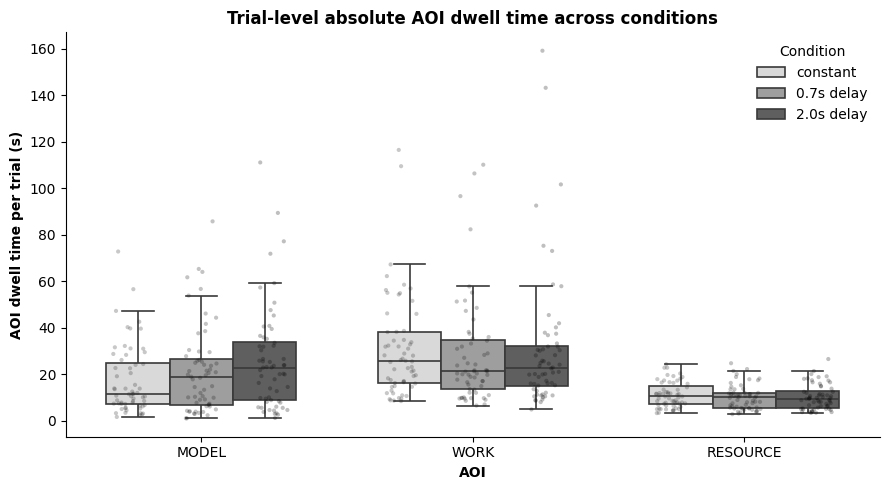

In [175]:
# =======================================================
# PLOT 1: RAW TRIAL-LEVEL ABSOLUTE AOI DWELL TIME
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_raw_absolute = aoi_dwell_per_trial_long.copy()

plot_raw_absolute["condition"] = plot_raw_absolute["condition"].astype(str)
plot_raw_absolute["AOI_CLEAN"] = plot_raw_absolute["AOI_CLEAN"].astype(str)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=plot_raw_absolute,
    x="AOI_CLEAN",
    y="aoi_dwell_s",
    hue="condition",
    order=AOI_ORDER,
    hue_order=COND_ORDER,
    palette=COND_COLORS,
    showfliers=False,
    width=0.7,
    linewidth=1.2
)

sns.stripplot(
    data=plot_raw_absolute,
    x="AOI_CLEAN",
    y="aoi_dwell_s",
    hue="condition",
    order=AOI_ORDER,
    hue_order=COND_ORDER,
    dodge=True,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.18
)

plt.xlabel("AOI", fontweight="bold")
plt.ylabel("AOI dwell time per trial (s)", fontweight="bold")

plt.title(
    "Trial-level absolute AOI dwell time across conditions",
    fontweight="bold"
)

# Remove duplicated legend entries from boxplot + stripplot
handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles[:len(COND_ORDER)],
    labels[:len(COND_ORDER)],
    title="Condition",
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

In [176]:
# =======================================================
# BUILD PARTICIPANT-LEVEL AVERAGES FOR RAW ABSOLUTE AOI DWELL TIME
# =======================================================

import pandas as pd
import numpy as np

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

raw_absolute_dwell_participant_avg = (
    aoi_dwell_per_trial_long.copy()
)

raw_absolute_dwell_participant_avg["condition"] = (
    raw_absolute_dwell_participant_avg["condition"]
    .astype(str)
)

raw_absolute_dwell_participant_avg["AOI_CLEAN"] = (
    raw_absolute_dwell_participant_avg["AOI_CLEAN"]
    .astype(str)
)

# Mean raw dwell time per participant across trials
raw_absolute_dwell_participant_avg = (
    raw_absolute_dwell_participant_avg
    .groupby(
        ["participant_id", "condition", "AOI_CLEAN"],
        as_index=False
    )
    .agg(
        avg_raw_aoi_dwell_s=("aoi_dwell_s", "mean"),
        n_trials=("model_name", "nunique")
    )
)

raw_absolute_dwell_participant_avg["condition"] = pd.Categorical(
    raw_absolute_dwell_participant_avg["condition"],
    categories=COND_ORDER,
    ordered=True
)

raw_absolute_dwell_participant_avg["AOI_CLEAN"] = pd.Categorical(
    raw_absolute_dwell_participant_avg["AOI_CLEAN"],
    categories=AOI_ORDER,
    ordered=True
)

raw_absolute_dwell_participant_avg = (
    raw_absolute_dwell_participant_avg
    .sort_values(["AOI_CLEAN", "condition", "participant_id"])
    .reset_index(drop=True)
)

display(raw_absolute_dwell_participant_avg.head(30))

print("Participants per AOI and condition:")
display(
    raw_absolute_dwell_participant_avg
    .groupby(["AOI_CLEAN", "condition"], observed=False)["participant_id"]
    .nunique()
)

,participant_id,condition,AOI_CLEAN,avg_raw_aoi_dwell_s,n_trials
0,1,constant,MODEL,18.861500,6
1,10,constant,MODEL,10.574833,6
2,2,constant,MODEL,18.927667,6
3,3,constant,MODEL,24.942667,6
4,4,constant,MODEL,17.552667,6
5,5,constant,MODEL,19.656500,6
6,6,constant,MODEL,18.479500,6
7,7,constant,MODEL,11.505167,6
8,8,constant,MODEL,20.425500,6
9,9,constant,MODEL,10.035833,6


Participants per AOI and condition:


AOI_CLEAN  condition 
MODEL      constant      10
           0.7s delay    10
           2.0s delay    10
WORK       constant      10
           0.7s delay    10
           2.0s delay    10
RESOURCE   constant      10
           0.7s delay    10
           2.0s delay    10
Name: participant_id, dtype: int64


### build group summary SE

In [177]:
# =======================================================
# BUILD GROUP SUMMARY FOR RAW ABSOLUTE AOI DWELL TIME
# =======================================================

raw_absolute_dwell_summary = (
    raw_absolute_dwell_participant_avg
    .groupby(
        ["AOI_CLEAN", "condition"],
        as_index=False,
        observed=False
    )
    .agg(
        mean_raw_aoi_dwell_s=("avg_raw_aoi_dwell_s", "mean"),
        sd_raw_aoi_dwell_s=("avg_raw_aoi_dwell_s", "std"),
        n_participants=("participant_id", "nunique")
    )
)

raw_absolute_dwell_summary["se_raw_aoi_dwell_s"] = (
    raw_absolute_dwell_summary["sd_raw_aoi_dwell_s"] /
    np.sqrt(raw_absolute_dwell_summary["n_participants"])
)

raw_absolute_dwell_summary["condition"] = pd.Categorical(
    raw_absolute_dwell_summary["condition"],
    categories=COND_ORDER,
    ordered=True
)

raw_absolute_dwell_summary["AOI_CLEAN"] = pd.Categorical(
    raw_absolute_dwell_summary["AOI_CLEAN"],
    categories=AOI_ORDER,
    ordered=True
)

raw_absolute_dwell_summary = (
    raw_absolute_dwell_summary
    .sort_values(["AOI_CLEAN", "condition"])
    .reset_index(drop=True)
)

display(raw_absolute_dwell_summary)

,AOI_CLEAN,condition,mean_raw_aoi_dwell_s,sd_raw_aoi_dwell_s,n_participants,se_raw_aoi_dwell_s
0,MODEL,constant,17.096183,4.846941,10,1.532737
1,MODEL,0.7s delay,21.343117,6.364842,10,2.012740
2,MODEL,2.0s delay,25.931250,6.367832,10,2.013685
3,WORK,constant,30.844950,9.563819,10,3.024345
4,WORK,0.7s delay,28.509883,11.690600,10,3.696892
5,WORK,2.0s delay,31.234950,15.719462,10,4.970930
6,RESOURCE,constant,11.076050,2.566243,10,0.811517
7,RESOURCE,0.7s delay,10.089317,2.444081,10,0.772886
8,RESOURCE,2.0s delay,10.143450,2.340967,10,0.740279


## Plot

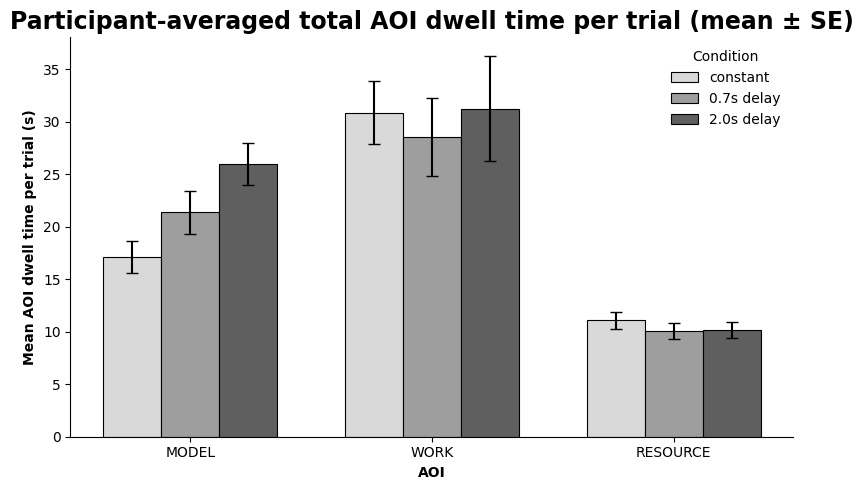

In [178]:
# =======================================================
# PLOT RAW ABSOLUTE AOI DWELL TIME (MEAN ± SE)
# =======================================================

import matplotlib.pyplot as plt
import numpy as np

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_df = raw_absolute_dwell_summary.copy()

x = np.arange(len(AOI_ORDER))
width = 0.24

fig, ax = plt.subplots(figsize=(8, 5))

for i, cond in enumerate(COND_ORDER):
    sub = (
        plot_df[plot_df["condition"].astype(str) == cond]
        .set_index("AOI_CLEAN")
        .reindex(AOI_ORDER)
        .reset_index()
    )

    ax.bar(
        x + (i - 1) * width,
        sub["mean_raw_aoi_dwell_s"],
        width=width,
        yerr=sub["se_raw_aoi_dwell_s"],
        capsize=4,
        color=COND_COLORS[cond],
        edgecolor="black",
        linewidth=0.8,
        label=cond
    )

ax.set_xticks(x)
ax.set_xticklabels(AOI_ORDER)

ax.set_xlabel("AOI", fontweight="bold")
ax.set_ylabel("Mean AOI dwell time per trial (s)", fontweight="bold")

ax.set_title(
    "Participant-averaged total AOI dwell time per trial (mean ± SE)",
    fontweight="bold",
    fontsize=17
)

ax.legend(title="Condition", frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

##  corrected MODEL dwell time per trial
= raw MODEL dwell time − condition-specific delay × number of MODEL checks per trial

### count model checks again

In [179]:
# =======================================================
# 5) COUNT MODEL CHECKS PER TRIAL FOR DELAY CORRECTION
# =======================================================

# Build clean AOI sequence
model_check_sequence = aoi_dwell_base.copy()

model_check_sequence["condition"] = model_check_sequence["condition"].astype(str)
model_check_sequence["AOI_CLEAN"] = model_check_sequence["AOI_CLEAN"].astype(str)

model_check_sequence = model_check_sequence.sort_values(
    ["participant_id", "model_name", "start_ms"]
).reset_index(drop=True)

# Previous AOI within each trial
model_check_sequence["prev_AOI_CLEAN"] = (
    model_check_sequence
    .groupby(["participant_id", "model_name"])["AOI_CLEAN"]
    .shift(1)
)

# MODEL check = transition from WORK or RESOURCE to MODEL
model_check_sequence["is_model_check_for_delay_correction"] = (
    (model_check_sequence["AOI_CLEAN"] == "MODEL") &
    (model_check_sequence["prev_AOI_CLEAN"].isin(["WORK", "RESOURCE"]))
)

model_checks_per_trial = (
    model_check_sequence
    .groupby(
        ["participant_id", "model_name", "condition"],
        as_index=False
    )
    .agg(
        n_model_checks_for_delay_correction=("is_model_check_for_delay_correction", "sum")
    )
)

model_checks_per_trial["condition"] = pd.Categorical(
    model_checks_per_trial["condition"],
    categories=COND_ORDER,
    ordered=True
)

print("MODEL checks per trial:")
display(model_checks_per_trial.head(20))

print("Summary of MODEL checks per trial:")
display(model_checks_per_trial["n_model_checks_for_delay_correction"].describe())

MODEL checks per trial:


,participant_id,model_name,condition,n_model_checks_for_delay_correction
0,1,C1M1F,0.7s delay,3
1,1,C1M2A,constant,3
2,1,C1M3F,constant,4
3,1,C1M4A,0.7s delay,4
4,1,C1M5F,2.0s delay,1
5,1,C1M6A,2.0s delay,2
6,1,C2M1F,2.0s delay,5
7,1,C2M2A,2.0s delay,6
8,1,C2M3F,0.7s delay,7
9,1,C2M4A,0.7s delay,10


Summary of MODEL checks per trial:


count    180.000000
mean       7.855556
std        6.861049
min        0.000000
25%        3.000000
50%        6.000000
75%       11.000000
max       47.000000
Name: n_model_checks_for_delay_correction, dtype: float64

#### Apply delay correction

In [180]:
# =======================================================
# 6) APPLY DELAY CORRECTION TO MODEL DWELL TIME
# =======================================================

DELAY_MS = {
    "constant": 0,
    "0.7s delay": 700,
    "2.0s delay": 2000
}

# Work on completed trial-level AOI dwell data
aoi_dwell_corrected_per_trial_long = aoi_dwell_per_trial_long.copy()

aoi_dwell_corrected_per_trial_long["condition"] = (
    aoi_dwell_corrected_per_trial_long["condition"].astype(str)
)

aoi_dwell_corrected_per_trial_long["AOI_CLEAN"] = (
    aoi_dwell_corrected_per_trial_long["AOI_CLEAN"].astype(str)
)

# Prepare model check data for merge
model_checks_for_merge = model_checks_per_trial.copy()
model_checks_for_merge["condition"] = model_checks_for_merge["condition"].astype(str)

# Merge model check counts onto AOI dwell data
aoi_dwell_corrected_per_trial_long = aoi_dwell_corrected_per_trial_long.merge(
    model_checks_for_merge,
    on=["participant_id", "model_name", "condition"],
    how="left"
)

aoi_dwell_corrected_per_trial_long["n_model_checks_for_delay_correction"] = (
    aoi_dwell_corrected_per_trial_long["n_model_checks_for_delay_correction"]
    .fillna(0)
)

# Add condition-specific delay
aoi_dwell_corrected_per_trial_long["delay_ms"] = (
    aoi_dwell_corrected_per_trial_long["condition"]
    .map(DELAY_MS)
)

# Delay correction applies only to MODEL dwell time
aoi_dwell_corrected_per_trial_long["delay_correction_ms"] = np.where(
    aoi_dwell_corrected_per_trial_long["AOI_CLEAN"] == "MODEL",
    (
        aoi_dwell_corrected_per_trial_long["delay_ms"] *
        aoi_dwell_corrected_per_trial_long["n_model_checks_for_delay_correction"]
    ),
    0
)

# Corrected dwell time
aoi_dwell_corrected_per_trial_long["corrected_aoi_dwell_ms_raw"] = (
    aoi_dwell_corrected_per_trial_long["aoi_dwell_ms"] -
    aoi_dwell_corrected_per_trial_long["delay_correction_ms"]
)

# Clip negative values to zero
# This prevents impossible negative dwell times
aoi_dwell_corrected_per_trial_long["corrected_aoi_dwell_ms"] = (
    aoi_dwell_corrected_per_trial_long["corrected_aoi_dwell_ms_raw"]
    .clip(lower=0)
)

aoi_dwell_corrected_per_trial_long["corrected_aoi_dwell_s"] = (
    aoi_dwell_corrected_per_trial_long["corrected_aoi_dwell_ms"] / 1000
)

# Restore categorical order
aoi_dwell_corrected_per_trial_long["condition"] = pd.Categorical(
    aoi_dwell_corrected_per_trial_long["condition"],
    categories=COND_ORDER,
    ordered=True
)

aoi_dwell_corrected_per_trial_long["AOI_CLEAN"] = pd.Categorical(
    aoi_dwell_corrected_per_trial_long["AOI_CLEAN"],
    categories=TASK_AOIS,
    ordered=True
)

display(
    aoi_dwell_corrected_per_trial_long[
        [
            "participant_id",
            "model_name",
            "condition",
            "AOI_CLEAN",
            "aoi_dwell_s",
            "n_model_checks_for_delay_correction",
            "delay_correction_ms",
            "corrected_aoi_dwell_s"
        ]
    ].head(30)
)

,participant_id,model_name,condition,AOI_CLEAN,aoi_dwell_s,n_model_checks_for_delay_correction,delay_correction_ms,corrected_aoi_dwell_s
0,1,C1M1F,0.7s delay,MODEL,3.891,3,2100,1.791
1,1,C1M1F,0.7s delay,WORK,48.525,3,0,48.525
2,1,C1M1F,0.7s delay,RESOURCE,10.713,3,0,10.713
3,1,C1M2A,constant,MODEL,6.700,3,0,6.700
4,1,C1M2A,constant,WORK,25.231,3,0,25.231
5,1,C1M2A,constant,RESOURCE,11.621,3,0,11.621
6,1,C1M3F,constant,MODEL,2.721,4,0,2.721
7,1,C1M3F,constant,WORK,31.848,4,0,31.848
8,1,C1M3F,constant,RESOURCE,9.549,4,0,9.549
9,1,C1M4A,0.7s delay,MODEL,10.268,4,2800,7.468


### Sanity checks

In [181]:
# =======================================================
# 7) SANITY CHECK DELAY-CORRECTED AOI DWELL TIME
# =======================================================

print("Raw AOI dwell time:")
display(aoi_dwell_corrected_per_trial_long["aoi_dwell_s"].describe())

print("Corrected AOI dwell time:")
display(aoi_dwell_corrected_per_trial_long["corrected_aoi_dwell_s"].describe())

print("Negative corrected values before clipping:")
print(
    (
        aoi_dwell_corrected_per_trial_long["corrected_aoi_dwell_ms_raw"] < 0
    ).sum()
)

print("Correction applied by AOI:")
display(
    aoi_dwell_corrected_per_trial_long
    .groupby("AOI_CLEAN", observed=False)["delay_correction_ms"]
    .describe()
)

print("Check: WORK and RESOURCE should have zero delay correction")
display(
    aoi_dwell_corrected_per_trial_long
    .loc[
        aoi_dwell_corrected_per_trial_long["AOI_CLEAN"].astype(str).isin(["WORK", "RESOURCE"]),
        ["AOI_CLEAN", "delay_correction_ms"]
    ]
    .groupby("AOI_CLEAN", observed=False)
    .describe()
)

Raw AOI dwell time:


count    540.000000
mean      20.696572
std       20.135102
min        1.000000
25%        8.430000
50%       14.549500
75%       25.402750
max      159.165000
Name: aoi_dwell_s, dtype: float64

Corrected AOI dwell time:


count    540.000000
mean      18.998239
std       19.007575
min        0.012000
25%        7.898000
50%       13.348000
75%       22.614000
max      159.165000
Name: corrected_aoi_dwell_s, dtype: float64

Negative corrected values before clipping:
0
Correction applied by AOI:


,count,mean,std,min,25%,50%,75%,max
AOI_CLEAN,,,,,,,,
MODEL,180.0,5095.0,6776.374296,0.0,0.0,2800.0,7775.0,38000.0
WORK,180.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
RESOURCE,180.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


Check: WORK and RESOURCE should have zero delay correction


delay_correction_ms                                   
                        count mean  std  min  25%  50%  75%  max
AOI_CLEAN                                                       
MODEL                     0.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN
WORK                    180.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
RESOURCE                180.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

#### Plot

/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/859348104.py:42: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


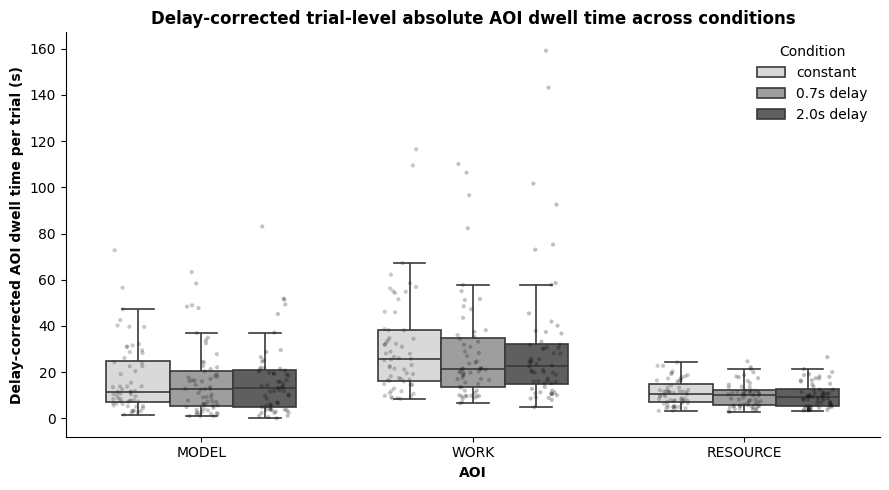

In [182]:
# =======================================================
# PLOT 1: DELAY-CORRECTED TRIAL-LEVEL ABSOLUTE AOI DWELL TIME
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_corrected_absolute = aoi_dwell_corrected_per_trial_long.copy()

plot_corrected_absolute["condition"] = (
    plot_corrected_absolute["condition"].astype(str)
)

plot_corrected_absolute["AOI_CLEAN"] = (
    plot_corrected_absolute["AOI_CLEAN"].astype(str)
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=plot_corrected_absolute,
    x="AOI_CLEAN",
    y="corrected_aoi_dwell_s",
    hue="condition",
    order=AOI_ORDER,
    hue_order=COND_ORDER,
    palette=COND_COLORS,
    showfliers=False,
    width=0.7,
    linewidth=1.2
)

sns.stripplot(
    data=plot_corrected_absolute,
    x="AOI_CLEAN",
    y="corrected_aoi_dwell_s",
    hue="condition",
    order=AOI_ORDER,
    hue_order=COND_ORDER,
    dodge=True,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.18
)

plt.xlabel("AOI", fontweight="bold")
plt.ylabel("Delay-corrected AOI dwell time per trial (s)", fontweight="bold")

plt.title(
    "Delay-corrected trial-level absolute AOI dwell time across conditions",
    fontweight="bold"
)

# Remove duplicated legend entries from boxplot + stripplot
handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles[:len(COND_ORDER)],
    labels[:len(COND_ORDER)],
    title="Condition",
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

#### Plot barplot absolute delay corrected dwell time

#### participant level averages

In [183]:
# =======================================================
# BUILD PARTICIPANT-LEVEL AVERAGES FOR DELAY-CORRECTED ABSOLUTE AOI DWELL TIME
# =======================================================

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

corrected_absolute_dwell_participant_avg = (
    aoi_dwell_corrected_per_trial_long.copy()
)

corrected_absolute_dwell_participant_avg["condition"] = (
    corrected_absolute_dwell_participant_avg["condition"]
    .astype(str)
)

corrected_absolute_dwell_participant_avg["AOI_CLEAN"] = (
    corrected_absolute_dwell_participant_avg["AOI_CLEAN"]
    .astype(str)
)

corrected_absolute_dwell_participant_avg = (
    corrected_absolute_dwell_participant_avg
    .groupby(
        ["participant_id", "condition", "AOI_CLEAN"],
        as_index=False
    )
    .agg(
        avg_corrected_aoi_dwell_s=("corrected_aoi_dwell_s", "mean"),
        n_trials=("model_name", "nunique")
    )
)

corrected_absolute_dwell_participant_avg["condition"] = pd.Categorical(
    corrected_absolute_dwell_participant_avg["condition"],
    categories=COND_ORDER,
    ordered=True
)

corrected_absolute_dwell_participant_avg["AOI_CLEAN"] = pd.Categorical(
    corrected_absolute_dwell_participant_avg["AOI_CLEAN"],
    categories=AOI_ORDER,
    ordered=True
)

corrected_absolute_dwell_participant_avg = (
    corrected_absolute_dwell_participant_avg
    .sort_values(["AOI_CLEAN", "condition", "participant_id"])
    .reset_index(drop=True)
)

display(corrected_absolute_dwell_participant_avg.head(30))

print("Participants per AOI and condition:")
display(
    corrected_absolute_dwell_participant_avg
    .groupby(["AOI_CLEAN", "condition"], observed=False)["participant_id"]
    .nunique()
)

,participant_id,condition,AOI_CLEAN,avg_corrected_aoi_dwell_s,n_trials
0,1,constant,MODEL,18.861500,6
1,10,constant,MODEL,10.574833,6
2,2,constant,MODEL,18.927667,6
3,3,constant,MODEL,24.942667,6
4,4,constant,MODEL,17.552667,6
5,5,constant,MODEL,19.656500,6
6,6,constant,MODEL,18.479500,6
7,7,constant,MODEL,11.505167,6
8,8,constant,MODEL,20.425500,6
9,9,constant,MODEL,10.035833,6


Participants per AOI and condition:


AOI_CLEAN  condition 
MODEL      constant      10
           0.7s delay    10
           2.0s delay    10
WORK       constant      10
           0.7s delay    10
           2.0s delay    10
RESOURCE   constant      10
           0.7s delay    10
           2.0s delay    10
Name: participant_id, dtype: int64

#### Group summary bauen

In [184]:
# =======================================================
# BUILD GROUP SUMMARY FOR DELAY-CORRECTED ABSOLUTE AOI DWELL TIME
# =======================================================

corrected_absolute_dwell_summary = corrected_absolute_dwell_participant_avg.copy()

# Convert categoricals to strings before groupby
corrected_absolute_dwell_summary["condition"] = (
    corrected_absolute_dwell_summary["condition"]
    .astype(str)
)

corrected_absolute_dwell_summary["AOI_CLEAN"] = (
    corrected_absolute_dwell_summary["AOI_CLEAN"]
    .astype(str)
)

corrected_absolute_dwell_summary = (
    corrected_absolute_dwell_summary
    .groupby(
        ["AOI_CLEAN", "condition"],
        as_index=False
    )
    .agg(
        mean_corrected_aoi_dwell_s=("avg_corrected_aoi_dwell_s", "mean"),
        sd_corrected_aoi_dwell_s=("avg_corrected_aoi_dwell_s", "std"),
        n_participants=("participant_id", "nunique")
    )
)

corrected_absolute_dwell_summary["se_corrected_aoi_dwell_s"] = (
    corrected_absolute_dwell_summary["sd_corrected_aoi_dwell_s"] /
    np.sqrt(corrected_absolute_dwell_summary["n_participants"])
)

corrected_absolute_dwell_summary["condition"] = pd.Categorical(
    corrected_absolute_dwell_summary["condition"],
    categories=COND_ORDER,
    ordered=True
)

corrected_absolute_dwell_summary["AOI_CLEAN"] = pd.Categorical(
    corrected_absolute_dwell_summary["AOI_CLEAN"],
    categories=AOI_ORDER,
    ordered=True
)

corrected_absolute_dwell_summary = (
    corrected_absolute_dwell_summary
    .sort_values(["AOI_CLEAN", "condition"])
    .reset_index(drop=True)
)

display(corrected_absolute_dwell_summary)

,AOI_CLEAN,condition,mean_corrected_aoi_dwell_s,sd_corrected_aoi_dwell_s,n_participants,se_corrected_aoi_dwell_s
0,MODEL,constant,17.096183,4.846941,10,1.532737
1,MODEL,0.7s delay,15.824783,5.030391,10,1.590749
2,MODEL,2.0s delay,16.164583,4.670539,10,1.476954
3,WORK,constant,30.844950,9.563819,10,3.024345
4,WORK,0.7s delay,28.509883,11.690600,10,3.696892
5,WORK,2.0s delay,31.234950,15.719462,10,4.970930
6,RESOURCE,constant,11.076050,2.566243,10,0.811517
7,RESOURCE,0.7s delay,10.089317,2.444081,10,0.772886
8,RESOURCE,2.0s delay,10.143450,2.340967,10,0.740279


In [185]:
# =======================================================
# CHECK TRIAL-LEVEL VS PARTICIPANT-LEVEL MEANS
# =======================================================

trial_level_means = (
    aoi_dwell_corrected_per_trial_long
    .assign(
        condition=lambda df: df["condition"].astype(str),
        AOI_CLEAN=lambda df: df["AOI_CLEAN"].astype(str)
    )
    .groupby(["AOI_CLEAN", "condition"], as_index=False)
    .agg(
        trial_level_mean=("corrected_aoi_dwell_s", "mean")
    )
)

participant_level_means = (
    corrected_absolute_dwell_participant_avg
    .assign(
        condition=lambda df: df["condition"].astype(str),
        AOI_CLEAN=lambda df: df["AOI_CLEAN"].astype(str)
    )
    .groupby(["AOI_CLEAN", "condition"], as_index=False)
    .agg(
        participant_level_mean=("avg_corrected_aoi_dwell_s", "mean")
    )
)

mean_comparison = trial_level_means.merge(
    participant_level_means,
    on=["AOI_CLEAN", "condition"],
    how="inner"
)

mean_comparison["difference"] = (
    mean_comparison["trial_level_mean"] -
    mean_comparison["participant_level_mean"]
)

display(mean_comparison)

,AOI_CLEAN,condition,trial_level_mean,participant_level_mean,difference
0,MODEL,0.7s delay,15.824783,15.824783,-1.776357e-15
1,MODEL,2.0s delay,16.164583,16.164583,0.000000e+00
2,MODEL,constant,17.096183,17.096183,-3.552714e-15
3,RESOURCE,0.7s delay,10.089317,10.089317,0.000000e+00
4,RESOURCE,2.0s delay,10.143450,10.143450,0.000000e+00
5,RESOURCE,constant,11.076050,11.076050,0.000000e+00
6,WORK,0.7s delay,28.509883,28.509883,0.000000e+00
7,WORK,2.0s delay,31.234950,31.234950,-3.552714e-15
8,WORK,constant,30.844950,30.844950,0.000000e+00


#### Plot: Absolute AOI dwell time with MODEL delay correction

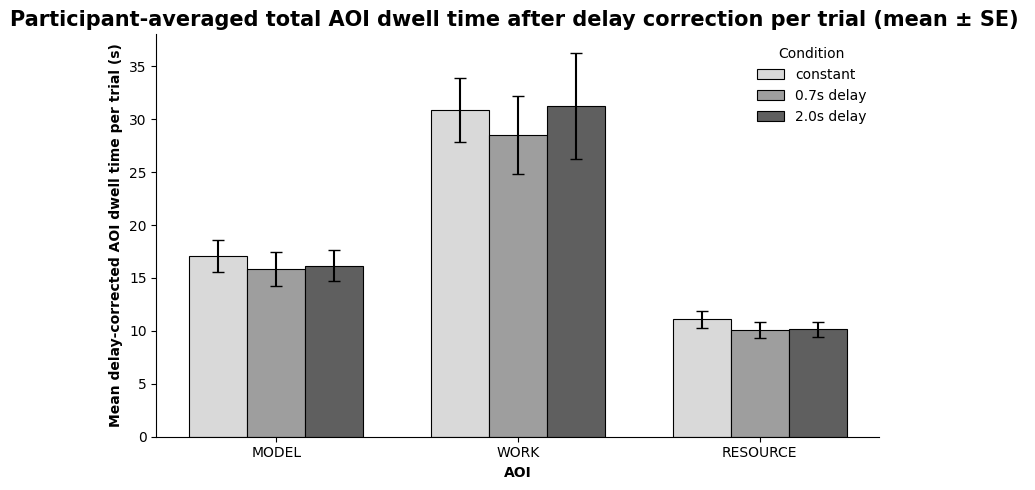

In [186]:
# =======================================================
# BARPLOT: DELAY-CORRECTED ABSOLUTE AOI DWELL TIME
# Participant-averaged means with SE error bars
# =======================================================

import matplotlib.pyplot as plt
import numpy as np

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_summary = corrected_absolute_dwell_summary.copy()

plot_summary["condition"] = plot_summary["condition"].astype(str)
plot_summary["AOI_CLEAN"] = plot_summary["AOI_CLEAN"].astype(str)

x = np.arange(len(AOI_ORDER))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(8, 5))

for i, cond in enumerate(COND_ORDER):
    sub = (
        plot_summary
        .loc[plot_summary["condition"] == cond]
        .set_index("AOI_CLEAN")
        .reindex(AOI_ORDER)
    )

    ax.bar(
        x + (i - 1) * bar_width,
        sub["mean_corrected_aoi_dwell_s"],
        width=bar_width,
        yerr=sub["se_corrected_aoi_dwell_s"],
        capsize=4,
        color=COND_COLORS[cond],
        edgecolor="black",
        linewidth=0.8,
        label=cond
    )

ax.set_xticks(x)
ax.set_xticklabels(AOI_ORDER)

ax.set_xlabel("AOI", fontweight="bold")
ax.set_ylabel(
    "Mean delay-corrected AOI dwell time per trial (s)",
    fontweight="bold"
)

ax.set_title(
    "Participant-averaged total AOI dwell time after delay correction per trial (mean ± SE) ",
    fontweight="bold",
    fontsize=15
)

ax.legend(title="Condition", frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

In [187]:
keys = ["participant_id", "condition", "model_name", "AOI_CLEAN"]

print("Duplicated trial–AOI rows:")
print(aoi_dwell_per_trial_long.duplicated(keys).sum())

print("Number of AOIs per trial:")
display(
    aoi_dwell_per_trial_long
    .groupby(["participant_id", "condition", "model_name"])["AOI_CLEAN"]
    .nunique()
    .value_counts()
)

print("Number of models per participant and condition:")
display(
    aoi_dwell_per_trial_long
    .groupby(["participant_id", "condition"])["model_name"]
    .nunique()
    .value_counts()
)

Duplicated trial–AOI rows:
0
Number of AOIs per trial:


/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/709149400.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["participant_id", "condition", "model_name"])["AOI_CLEAN"]


AOI_CLEAN
0    360
3    180
Name: count, dtype: int64

Number of models per participant and condition:


/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/709149400.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["participant_id", "condition"])["model_name"]


model_name
6    30
Name: count, dtype: int64

#### Participant level plot

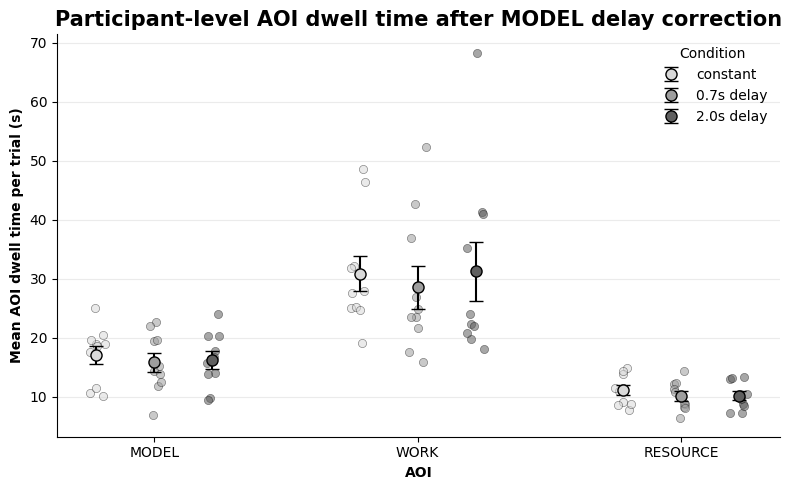

In [188]:
# =======================================================
# PARTICIPANT-LEVEL PLOT:
# AOI DWELL TIME AFTER MODEL DELAY CORRECTION
# Mean ± SE across participants, with individual participant points
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_data = corrected_absolute_dwell_participant_avg.copy()

plot_data["condition"] = plot_data["condition"].astype(str)
plot_data["AOI_CLEAN"] = plot_data["AOI_CLEAN"].astype(str)

# =======================================================
# Build group summary
# =======================================================

plot_summary = (
    plot_data
    .groupby(["AOI_CLEAN", "condition"], as_index=False)
    .agg(
        mean_aoi_dwell_s=("avg_corrected_aoi_dwell_s", "mean"),
        sd_aoi_dwell_s=("avg_corrected_aoi_dwell_s", "std"),
        n_participants=("participant_id", "nunique")
    )
)

plot_summary["se_aoi_dwell_s"] = (
    plot_summary["sd_aoi_dwell_s"] /
    np.sqrt(plot_summary["n_participants"])
)

# =======================================================
# Plot
# =======================================================

x = np.arange(len(AOI_ORDER))
condition_offsets = {
    "constant": -0.22,
    "0.7s delay": 0.00,
    "2.0s delay": 0.22
}

fig, ax = plt.subplots(figsize=(8, 5))

# Individual participant points
for cond in COND_ORDER:
    for i, aoi in enumerate(AOI_ORDER):
        sub = plot_data[
            (plot_data["condition"] == cond) &
            (plot_data["AOI_CLEAN"] == aoi)
        ]

        jitter = np.random.uniform(-0.035, 0.035, size=len(sub))

        ax.scatter(
            np.full(len(sub), i + condition_offsets[cond]) + jitter,
            sub["avg_corrected_aoi_dwell_s"],
            color=COND_COLORS[cond],
            edgecolor="black",
            linewidth=0.4,
            alpha=0.55,
            s=35,
            zorder=2
        )

# Group means with SE
for cond in COND_ORDER:
    sub = (
        plot_summary
        .loc[plot_summary["condition"] == cond]
        .set_index("AOI_CLEAN")
        .reindex(AOI_ORDER)
    )

    y = sub["mean_aoi_dwell_s"].values
    yerr = sub["se_aoi_dwell_s"].values

    ax.errorbar(
        x + condition_offsets[cond],
        y,
        yerr=yerr,
        fmt="o",
        color="black",
        markerfacecolor=COND_COLORS[cond],
        markeredgecolor="black",
        markersize=8,
        capsize=5,
        linewidth=1.5,
        label=cond,
        zorder=4
    )

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(AOI_ORDER)

ax.set_xlabel("AOI", fontweight="bold")
ax.set_ylabel("Mean AOI dwell time per trial (s)", fontweight="bold")

ax.set_title(
    "Participant-level AOI dwell time after MODEL delay correction",
    fontweight="bold",
    fontsize=15
)

ax.legend(title="Condition", frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()
plt.close(fig)

###  Compute relative AOI dwell time per trial

In [189]:
# =======================================================
# COMPUTE RELATIVE AOI DWELL TIME AFTER MODEL DELAY CORRECTION
# =======================================================

import numpy as np
import pandas as pd

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

# Make a safe copy
relative_aoi_dwell_per_trial = aoi_dwell_corrected_per_trial_long.copy()

# Convert categoricals to strings before groupby
relative_aoi_dwell_per_trial["condition"] = (
    relative_aoi_dwell_per_trial["condition"].astype(str)
)

relative_aoi_dwell_per_trial["AOI_CLEAN"] = (
    relative_aoi_dwell_per_trial["AOI_CLEAN"].astype(str)
)

# Compute total corrected task dwell time per trial
# Total = corrected MODEL + unchanged WORK + unchanged RESOURCE
total_corrected_dwell_per_trial = (
    relative_aoi_dwell_per_trial
    .groupby(
        ["participant_id", "model_name", "condition"],
        as_index=False
    )
    .agg(
        total_corrected_task_dwell_s=("corrected_aoi_dwell_s", "sum")
    )
)

# Merge total dwell time back onto AOI-level data
relative_aoi_dwell_per_trial = relative_aoi_dwell_per_trial.merge(
    total_corrected_dwell_per_trial,
    on=["participant_id", "model_name", "condition"],
    how="left"
)

# Compute relative dwell time
relative_aoi_dwell_per_trial["relative_aoi_dwell"] = (
    relative_aoi_dwell_per_trial["corrected_aoi_dwell_s"] /
    relative_aoi_dwell_per_trial["total_corrected_task_dwell_s"]
)

# Avoid invalid division if total dwell is 0
relative_aoi_dwell_per_trial.loc[
    relative_aoi_dwell_per_trial["total_corrected_task_dwell_s"] == 0,
    "relative_aoi_dwell"
] = np.nan

# Restore categorical order
relative_aoi_dwell_per_trial["condition"] = pd.Categorical(
    relative_aoi_dwell_per_trial["condition"],
    categories=COND_ORDER,
    ordered=True
)

relative_aoi_dwell_per_trial["AOI_CLEAN"] = pd.Categorical(
    relative_aoi_dwell_per_trial["AOI_CLEAN"],
    categories=AOI_ORDER,
    ordered=True
)

relative_aoi_dwell_per_trial = relative_aoi_dwell_per_trial.sort_values(
    ["participant_id", "model_name", "condition", "AOI_CLEAN"]
).reset_index(drop=True)

display(
    relative_aoi_dwell_per_trial[
        [
            "participant_id",
            "model_name",
            "condition",
            "AOI_CLEAN",
            "corrected_aoi_dwell_s",
            "total_corrected_task_dwell_s",
            "relative_aoi_dwell"
        ]
    ].head(30)
)

,participant_id,model_name,condition,AOI_CLEAN,corrected_aoi_dwell_s,total_corrected_task_dwell_s,relative_aoi_dwell
0,1,C1M1F,0.7s delay,MODEL,1.791,61.029,0.029347
1,1,C1M1F,0.7s delay,WORK,48.525,61.029,0.795114
2,1,C1M1F,0.7s delay,RESOURCE,10.713,61.029,0.175539
3,1,C1M2A,constant,MODEL,6.700,43.552,0.153839
4,1,C1M2A,constant,WORK,25.231,43.552,0.579330
5,1,C1M2A,constant,RESOURCE,11.621,43.552,0.266830
6,1,C1M3F,constant,MODEL,2.721,44.118,0.061676
7,1,C1M3F,constant,WORK,31.848,44.118,0.721882
8,1,C1M3F,constant,RESOURCE,9.549,44.118,0.216442
9,1,C1M4A,0.7s delay,MODEL,7.468,34.333,0.217517


In [190]:
# =======================================================
# SANITY CHECK: RELATIVE AOI DWELL SHOULD SUM TO 1 PER TRIAL
# =======================================================

relative_sum_check = relative_aoi_dwell_per_trial.copy()

relative_sum_check["condition"] = (
    relative_sum_check["condition"].astype(str)
)

relative_sum_check = (
    relative_sum_check
    .groupby(
        ["participant_id", "model_name", "condition"],
        as_index=False
    )
    .agg(
        sum_relative_aoi_dwell=("relative_aoi_dwell", "sum")
    )
)

print("Relative AOI dwell sum per trial:")
display(relative_sum_check["sum_relative_aoi_dwell"].describe())

print("Trials where relative AOI dwell does not sum to approximately 1:")
display(
    relative_sum_check[
        ~np.isclose(
            relative_sum_check["sum_relative_aoi_dwell"],
            1.0,
            atol=0.001
        )
    ]
)

Relative AOI dwell sum per trial:


count    1.800000e+02
mean     1.000000e+00
std      6.097904e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: sum_relative_aoi_dwell, dtype: float64

Trials where relative AOI dwell does not sum to approximately 1:


,participant_id,model_name,condition,sum_relative_aoi_dwell


In [191]:
# =======================================================
# BUILD PARTICIPANT-LEVEL AVERAGES FOR RELATIVE AOI DWELL TIME
# =======================================================

relative_aoi_dwell_participant_avg = relative_aoi_dwell_per_trial.copy()

relative_aoi_dwell_participant_avg["condition"] = (
    relative_aoi_dwell_participant_avg["condition"].astype(str)
)

relative_aoi_dwell_participant_avg["AOI_CLEAN"] = (
    relative_aoi_dwell_participant_avg["AOI_CLEAN"].astype(str)
)

relative_aoi_dwell_participant_avg = (
    relative_aoi_dwell_participant_avg
    .groupby(
        ["participant_id", "condition", "AOI_CLEAN"],
        as_index=False
    )
    .agg(
        avg_relative_aoi_dwell=("relative_aoi_dwell", "mean"),
        n_trials=("model_name", "nunique")
    )
)

relative_aoi_dwell_participant_avg["condition"] = pd.Categorical(
    relative_aoi_dwell_participant_avg["condition"],
    categories=COND_ORDER,
    ordered=True
)

relative_aoi_dwell_participant_avg["AOI_CLEAN"] = pd.Categorical(
    relative_aoi_dwell_participant_avg["AOI_CLEAN"],
    categories=AOI_ORDER,
    ordered=True
)

relative_aoi_dwell_participant_avg = relative_aoi_dwell_participant_avg.sort_values(
    ["AOI_CLEAN", "condition", "participant_id"]
).reset_index(drop=True)

display(relative_aoi_dwell_participant_avg.head(30))

print("Participants per AOI and condition:")
display(
    relative_aoi_dwell_participant_avg
    .groupby(["AOI_CLEAN", "condition"], observed=False)["participant_id"]
    .nunique()
)

,participant_id,condition,AOI_CLEAN,avg_relative_aoi_dwell,n_trials
0,1,constant,MODEL,0.203385,6
1,10,constant,MODEL,0.228763,6
2,2,constant,MODEL,0.254318,6
3,3,constant,MODEL,0.323921,6
4,4,constant,MODEL,0.310135,6
5,5,constant,MODEL,0.364582,6
6,6,constant,MODEL,0.192267,6
7,7,constant,MODEL,0.258032,6
8,8,constant,MODEL,0.354128,6
9,9,constant,MODEL,0.208213,6


Participants per AOI and condition:


AOI_CLEAN  condition 
MODEL      constant      10
           0.7s delay    10
           2.0s delay    10
WORK       constant      10
           0.7s delay    10
           2.0s delay    10
RESOURCE   constant      10
           0.7s delay    10
           2.0s delay    10
Name: participant_id, dtype: int64

,AOI_CLEAN,condition,mean_relative_aoi_dwell,sd_relative_aoi_dwell,n_participants,se_relative_aoi_dwell
0,MODEL,constant,0.269774,0.064056,10,0.020256
1,MODEL,0.7s delay,0.261056,0.065339,10,0.020662
2,MODEL,2.0s delay,0.258046,0.058559,10,0.018518
3,WORK,constant,0.520898,0.046621,10,0.014743
4,WORK,0.7s delay,0.524303,0.050427,10,0.015946
5,WORK,2.0s delay,0.533557,0.056392,10,0.017833
6,RESOURCE,constant,0.209327,0.039074,10,0.012356
7,RESOURCE,0.7s delay,0.214641,0.045314,10,0.014330
8,RESOURCE,2.0s delay,0.208397,0.041679,10,0.013180


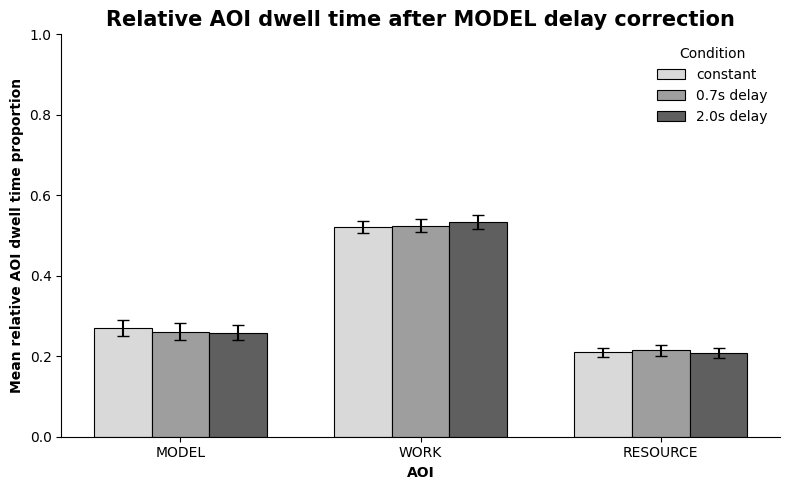

In [192]:
# =======================================================
# BARPLOT: RELATIVE AOI DWELL TIME AFTER MODEL DELAY CORRECTION
# Participant-averaged means with SE error bars
# =======================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

# =======================================================
# Build group summary
# =======================================================

plot_data = relative_aoi_dwell_participant_avg.copy()

plot_data["condition"] = plot_data["condition"].astype(str)
plot_data["AOI_CLEAN"] = plot_data["AOI_CLEAN"].astype(str)

relative_aoi_dwell_summary = (
    plot_data
    .groupby(
        ["AOI_CLEAN", "condition"],
        as_index=False
    )
    .agg(
        mean_relative_aoi_dwell=("avg_relative_aoi_dwell", "mean"),
        sd_relative_aoi_dwell=("avg_relative_aoi_dwell", "std"),
        n_participants=("participant_id", "nunique")
    )
)

relative_aoi_dwell_summary["se_relative_aoi_dwell"] = (
    relative_aoi_dwell_summary["sd_relative_aoi_dwell"] /
    np.sqrt(relative_aoi_dwell_summary["n_participants"])
)

relative_aoi_dwell_summary["condition"] = pd.Categorical(
    relative_aoi_dwell_summary["condition"],
    categories=COND_ORDER,
    ordered=True
)

relative_aoi_dwell_summary["AOI_CLEAN"] = pd.Categorical(
    relative_aoi_dwell_summary["AOI_CLEAN"],
    categories=AOI_ORDER,
    ordered=True
)

relative_aoi_dwell_summary = (
    relative_aoi_dwell_summary
    .sort_values(["AOI_CLEAN", "condition"])
    .reset_index(drop=True)
)

display(relative_aoi_dwell_summary)

# =======================================================
# Plot
# =======================================================

plot_summary = relative_aoi_dwell_summary.copy()

plot_summary["condition"] = plot_summary["condition"].astype(str)
plot_summary["AOI_CLEAN"] = plot_summary["AOI_CLEAN"].astype(str)

x = np.arange(len(AOI_ORDER))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(8, 5))

for i, cond in enumerate(COND_ORDER):
    sub = (
        plot_summary
        .loc[plot_summary["condition"] == cond]
        .set_index("AOI_CLEAN")
        .reindex(AOI_ORDER)
    )

    ax.bar(
        x + (i - 1) * bar_width,
        sub["mean_relative_aoi_dwell"],
        width=bar_width,
        yerr=sub["se_relative_aoi_dwell"],
        capsize=4,
        color=COND_COLORS[cond],
        edgecolor="black",
        linewidth=0.8,
        label=cond
    )

ax.set_xticks(x)
ax.set_xticklabels(AOI_ORDER)

ax.set_xlabel("AOI", fontweight="bold")
ax.set_ylabel(
    "Mean relative AOI dwell time proportion",
    fontweight="bold"
)

ax.set_title(
    "Relative AOI dwell time after MODEL delay correction",
    fontweight="bold",
    fontsize=15
)

ax.set_ylim(0, 1)

ax.legend(title="Condition", frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

In [193]:
# =======================================================
# CHECK WHETHER ABSOLUTE AND RELATIVE DWELL SUMMARIES MATCH PLAUSIBLY
# =======================================================

absolute_check = corrected_absolute_dwell_participant_avg.copy()
relative_check = relative_aoi_dwell_participant_avg.copy()

absolute_check["condition"] = absolute_check["condition"].astype(str)
absolute_check["AOI_CLEAN"] = absolute_check["AOI_CLEAN"].astype(str)

relative_check["condition"] = relative_check["condition"].astype(str)
relative_check["AOI_CLEAN"] = relative_check["AOI_CLEAN"].astype(str)

# Group means of absolute dwell times
absolute_summary_check = (
    absolute_check
    .groupby(["condition", "AOI_CLEAN"], as_index=False)
    .agg(
        mean_absolute_dwell_s=("avg_corrected_aoi_dwell_s", "mean")
    )
)

# Group means of relative dwell times
relative_summary_check = (
    relative_check
    .groupby(["condition", "AOI_CLEAN"], as_index=False)
    .agg(
        mean_relative_dwell=("avg_relative_aoi_dwell", "mean")
    )
)

# Merge summaries
summary_check = absolute_summary_check.merge(
    relative_summary_check,
    on=["condition", "AOI_CLEAN"],
    how="inner"
)

display(summary_check)

,condition,AOI_CLEAN,mean_absolute_dwell_s,mean_relative_dwell
0,0.7s delay,MODEL,15.824783,0.261056
1,0.7s delay,RESOURCE,10.089317,0.214641
2,0.7s delay,WORK,28.509883,0.524303
3,2.0s delay,MODEL,16.164583,0.258046
4,2.0s delay,RESOURCE,10.143450,0.208397
5,2.0s delay,WORK,31.234950,0.533557
6,constant,MODEL,17.096183,0.269774
7,constant,RESOURCE,11.076050,0.209327
8,constant,WORK,30.844950,0.520898


## Intervisit Intervals: How lonng were the times in between each model checks
### Prepare gaze event sequence

In [194]:
# =======================================================
# CELL 1: PREPARE EVENT SEQUENCE FOR ALL AOIs
# =======================================================

import pandas as pd
import numpy as np

TRIAL_KEYS = [
    "participant_id",
    "condition",
    "model_order",
    "model_name"
]

gaze_sequence = object_gazes_final.copy()

# Clean identifiers
for col in ["participant_id", "condition", "model_name"]:
    gaze_sequence[col] = (
        gaze_sequence[col]
        .astype(str)
        .str.strip()
    )

# Standardize AOI labels
gaze_sequence["AOI_CLEAN"] = (
    gaze_sequence["AOI_CLEAN"]
    .fillna("OTHER")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Convert timestamps and model order to numeric values
for col in ["start_ms", "end_ms", "model_order"]:
    gaze_sequence[col] = pd.to_numeric(
        gaze_sequence[col],
        errors="coerce"
    )

# Remove rows without usable trial information or timestamps
gaze_sequence = gaze_sequence.dropna(
    subset=TRIAL_KEYS + ["AOI_CLEAN", "start_ms", "end_ms"]
).copy()

# Remove impossible events
gaze_sequence = gaze_sequence[
    gaze_sequence["end_ms"] >= gaze_sequence["start_ms"]
].copy()

# Sort chronologically within each trial
gaze_sequence = (
    gaze_sequence
    .sort_values(TRIAL_KEYS + ["start_ms", "end_ms"])
    .reset_index(drop=True)
)

print("Prepared object-gaze events:", len(gaze_sequence))
print("Number of trials:", gaze_sequence[TRIAL_KEYS].drop_duplicates().shape[0])

display(
    gaze_sequence[
        TRIAL_KEYS + [
            "object_name",
            "AOI_CLEAN",
            "start_ms",
            "end_ms"
        ]
    ].head(20)
)

Prepared object-gaze events: 22841
Number of trials: 180


,participant_id,condition,model_order,model_name,object_name,AOI_CLEAN,start_ms,end_ms
0,1,0.7s delay,7.0,C2M3F,Wall_Front,OTHER,1.754660e+12,1.754660e+12
1,1,0.7s delay,7.0,C2M3F,Lego_Board_10x10,WORK,1.754660e+12,1.754660e+12
2,1,0.7s delay,7.0,C2M3F,Model_plate,MODEL,1.754660e+12,1.754660e+12
3,1,0.7s delay,7.0,C2M3F,Lego_2x2_Orange,RESOURCE,1.754660e+12,1.754660e+12
4,1,0.7s delay,7.0,C2M3F,work_desk_base.001,RESOURCE,1.754660e+12,1.754660e+12
5,1,0.7s delay,7.0,C2M3F,work_desk_base.001,RESOURCE,1.754660e+12,1.754660e+12
6,1,0.7s delay,7.0,C2M3F,Lego_2x2_Pink,RESOURCE,1.754660e+12,1.754660e+12
7,1,0.7s delay,7.0,C2M3F,work_desk_base.001,RESOURCE,1.754660e+12,1.754660e+12
8,1,0.7s delay,7.0,C2M3F,work_desk_base.001,RESOURCE,1.754660e+12,1.754660e+12
9,1,0.7s delay,7.0,C2M3F,Lego_2x2_Pink,RESOURCE,1.754660e+12,1.754660e+12


## Build AOI Gaze events/ visits

In [195]:
# =======================================================
# CELL 2: BUILD VISITS FOR ALL AOIs
# =======================================================

# Previous AOI within each trial
gaze_sequence["previous_AOI"] = (
    gaze_sequence
    .groupby(TRIAL_KEYS)["AOI_CLEAN"]
    .shift(1)
)

# A new visit begins when the AOI changes
gaze_sequence["starts_new_AOI_visit"] = (
    gaze_sequence["previous_AOI"].isna()
    | (gaze_sequence["AOI_CLEAN"] != gaze_sequence["previous_AOI"])
)

# Assign a visit number within each trial
gaze_sequence["AOI_visit_id"] = (
    gaze_sequence
    .groupby(TRIAL_KEYS)["starts_new_AOI_visit"]
    .cumsum()
    .astype(int)
)

# Combine consecutive events belonging to the same AOI visit
AOI_visits = (
    gaze_sequence
    .groupby(
        TRIAL_KEYS + ["AOI_visit_id"],
        as_index=False,
        sort=False
    )
    .agg(
        AOI_CLEAN=("AOI_CLEAN", "first"),
        visit_start_ms=("start_ms", "min"),
        visit_end_ms=("end_ms", "max"),
        n_object_gazes=("object_name", "size")
    )
)

# Calculate visit duration
AOI_visits["visit_duration_ms"] = (
    AOI_visits["visit_end_ms"] -
    AOI_visits["visit_start_ms"]
)

AOI_visits["visit_duration_s"] = (
    AOI_visits["visit_duration_ms"] / 1000
)

AOI_visits = (
    AOI_visits
    .sort_values(TRIAL_KEYS + ["visit_start_ms"])
    .reset_index(drop=True)
)

print("Number of reconstructed AOI visits:", len(AOI_visits))

print("\nVisits by AOI:")
display(AOI_visits["AOI_CLEAN"].value_counts())

display(
    AOI_visits[
        TRIAL_KEYS + [
            "AOI_visit_id",
            "AOI_CLEAN",
            "visit_start_ms",
            "visit_end_ms",
            "visit_duration_s",
            "n_object_gazes"
        ]
    ].head(30)
)

Number of reconstructed AOI visits: 6253

Visits by AOI:


AOI_CLEAN
WORK        2021
OTHER       1704
MODEL       1608
RESOURCE     920
Name: count, dtype: int64

,participant_id,condition,model_order,model_name,AOI_visit_id,AOI_CLEAN,visit_start_ms,visit_end_ms,visit_duration_s,n_object_gazes
0,1,0.7s delay,7.0,C2M3F,1,OTHER,1.754660e+12,1.754660e+12,0.432,1
1,1,0.7s delay,7.0,C2M3F,2,WORK,1.754660e+12,1.754660e+12,0.100,1
2,1,0.7s delay,7.0,C2M3F,3,MODEL,1.754660e+12,1.754660e+12,5.722,1
3,1,0.7s delay,7.0,C2M3F,4,RESOURCE,1.754660e+12,1.754660e+12,7.288,16
4,1,0.7s delay,7.0,C2M3F,5,WORK,1.754660e+12,1.754660e+12,0.233,1
5,1,0.7s delay,7.0,C2M3F,6,MODEL,1.754660e+12,1.754660e+12,2.134,1
6,1,0.7s delay,7.0,C2M3F,7,WORK,1.754660e+12,1.754660e+12,4.312,7
7,1,0.7s delay,7.0,C2M3F,8,MODEL,1.754660e+12,1.754660e+12,2.723,1
8,1,0.7s delay,7.0,C2M3F,9,WORK,1.754660e+12,1.754660e+12,0.132,1
9,1,0.7s delay,7.0,C2M3F,10,OTHER,1.754660e+12,1.754660e+12,0.200,1


### choose model visits

In [196]:
# =======================================================
# CELL 3: EXTRACT MODEL VISITS
# =======================================================

model_visits = (
    AOI_visits[
        AOI_visits["AOI_CLEAN"] == "MODEL"
    ]
    .copy()
)

model_visits = (
    model_visits
    .sort_values(TRIAL_KEYS + ["visit_start_ms"])
    .reset_index(drop=True)
)

# Number MODEL visits within each trial
model_visits["model_visit_number"] = (
    model_visits
    .groupby(TRIAL_KEYS)
    .cumcount() + 1
)

print("Number of MODEL visits:", len(model_visits))

display(
    model_visits[
        TRIAL_KEYS + [
            "model_visit_number",
            "visit_start_ms",
            "visit_end_ms",
            "visit_duration_s",
            "n_object_gazes"
        ]
    ].head(30)
)

Number of MODEL visits: 1608


,participant_id,condition,model_order,model_name,model_visit_number,visit_start_ms,visit_end_ms,visit_duration_s,n_object_gazes
0,1,0.7s delay,7.0,C2M3F,1,1.754660e+12,1.754660e+12,5.722,1
1,1,0.7s delay,7.0,C2M3F,2,1.754660e+12,1.754660e+12,2.134,1
2,1,0.7s delay,7.0,C2M3F,3,1.754660e+12,1.754660e+12,2.723,1
3,1,0.7s delay,7.0,C2M3F,4,1.754660e+12,1.754660e+12,2.777,1
4,1,0.7s delay,7.0,C2M3F,5,1.754660e+12,1.754660e+12,1.211,1
5,1,0.7s delay,7.0,C2M3F,6,1.754660e+12,1.754660e+12,3.500,1
6,1,0.7s delay,7.0,C2M3F,7,1.754660e+12,1.754660e+12,3.289,1
7,1,0.7s delay,8.0,C3M4A,1,1.754660e+12,1.754660e+12,16.572,1
8,1,0.7s delay,8.0,C3M4A,2,1.754660e+12,1.754660e+12,1.688,1
9,1,0.7s delay,8.0,C3M4A,3,1.754660e+12,1.754660e+12,3.856,1


### calculate model inter visit intervals

In [ ]:
# =======================================================
# CELL 4: CALCULATE MODEL INTERVISIT INTERVALS
# =======================================================

# End time of the previous MODEL visit within each trial
model_visits["previous_MODEL_visit_end_ms"] = (
    model_visits
    .groupby(TRIAL_KEYS)["visit_end_ms"]
    .shift(1)
)

# Current MODEL start minus previous MODEL end
model_visits["intervisit_interval_ms"] = (
    model_visits["visit_start_ms"] -
    model_visits["previous_MODEL_visit_end_ms"]
)

model_visits["intervisit_interval_s"] = (
    model_visits["intervisit_interval_ms"] / 1000
)

# The first MODEL visit in each trial has no previous visit
model_intervisit_intervals = (
    model_visits[
        model_visits["intervisit_interval_s"].notna()
    ]
    .copy()
)

print(
    "Number of calculated MODEL intervisit intervals:",
    len(model_intervisit_intervals)
)

print(
    "Negative intervals:", 
    (model_intervisit_intervals["intervisit_interval_s"] < 0).sum()
)

display(
    model_intervisit_intervals[
        TRIAL_KEYS + [
            "model_visit_number",
            "previous_MODEL_visit_end_ms",
            "visit_start_ms",
            "intervisit_interval_s"
        ]
    ].head(30)
)

Number of calculated MODEL intervisit intervals: 1428
Negative intervals: 0


,participant_id,condition,model_order,model_name,model_visit_number,previous_MODEL_visit_end_ms,visit_start_ms,intervisit_interval_s
1,1,0.7s delay,7.0,C2M3F,2,1.754660e+12,1.754660e+12,8.523
2,1,0.7s delay,7.0,C2M3F,3,1.754660e+12,1.754660e+12,4.732
3,1,0.7s delay,7.0,C2M3F,4,1.754660e+12,1.754660e+12,6.867
4,1,0.7s delay,7.0,C2M3F,5,1.754660e+12,1.754660e+12,4.044
5,1,0.7s delay,7.0,C2M3F,6,1.754660e+12,1.754660e+12,3.711
6,1,0.7s delay,7.0,C2M3F,7,1.754660e+12,1.754660e+12,11.478
8,1,0.7s delay,8.0,C3M4A,2,1.754660e+12,1.754660e+12,5.655
9,1,0.7s delay,8.0,C3M4A,3,1.754660e+12,1.754660e+12,13.596
10,1,0.7s delay,8.0,C3M4A,4,1.754660e+12,1.754660e+12,4.054
11,1,0.7s delay,8.0,C3M4A,5,1.754660e+12,1.754660e+12,2.055


### check

In [198]:
# =======================================================
# CELL 5: QUALITY CHECKS
# =======================================================

# Count MODEL visits per trial
model_visits_per_trial = (
    model_visits
    .groupby(TRIAL_KEYS, as_index=False)
    .agg(
        n_MODEL_visits=("model_visit_number", "max")
    )
)

# Count calculated intervals per trial
intervals_per_trial = (
    model_intervisit_intervals
    .groupby(TRIAL_KEYS, as_index=False)
    .agg(
        n_intervisit_intervals=("intervisit_interval_s", "size")
    )
)

trial_quality = (
    model_visits_per_trial
    .merge(
        intervals_per_trial,
        on=TRIAL_KEYS,
        how="left"
    )
)

trial_quality["n_intervisit_intervals"] = (
    trial_quality["n_intervisit_intervals"]
    .fillna(0)
    .astype(int)
)

print("MODEL visits per trial:")
display(trial_quality["n_MODEL_visits"].describe())

print("\nIntervisit intervals per trial:")
display(trial_quality["n_intervisit_intervals"].describe())

print(
    "\nTrials with fewer than two MODEL visits:",
    (trial_quality["n_MODEL_visits"] < 2).sum()
)

print(
    "Negative intervisit intervals:",
    (model_intervisit_intervals["intervisit_interval_s"] < 0).sum()
)

print("\nInterval distribution by condition:")
display(
    model_intervisit_intervals
    .groupby("condition")["intervisit_interval_s"]
    .describe()
)

MODEL visits per trial:


count    180.000000
mean       8.933333
std        6.960062
min        1.000000
25%        4.000000
50%        7.000000
75%       12.000000
max       48.000000
Name: n_MODEL_visits, dtype: float64


Intervisit intervals per trial:


count    180.000000
mean       7.933333
std        6.960062
min        0.000000
25%        3.000000
50%        6.000000
75%       11.000000
max       47.000000
Name: n_intervisit_intervals, dtype: float64


Trials with fewer than two MODEL visits: 9
Negative intervisit intervals: 0

Interval distribution by condition:


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
0.7s delay,471.0,5.727745,5.999477,0.133,1.7945,4.0440,7.52800,63.166
2.0s delay,333.0,8.315321,9.342744,0.132,1.4460,5.0560,12.22200,92.176
constant,624.0,4.881341,4.903355,0.121,1.9720,3.8215,5.98075,47.001


### plot raw intervisit interval distribution

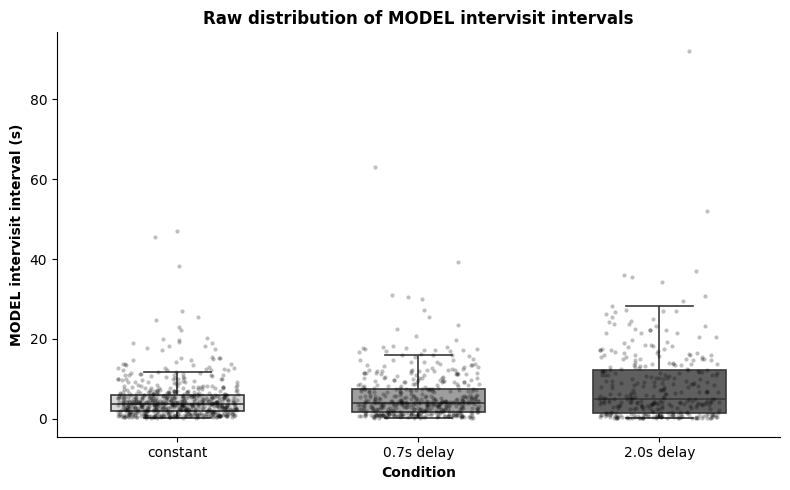

In [199]:
# =======================================================
# CELL 6: PLOT RAW INTERVISIT-INTERVAL DISTRIBUTION
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt

COND_ORDER = [
    "constant",
    "0.7s delay",
    "2.0s delay"
]

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_raw = model_intervisit_intervals.copy()

# Keep valid intervals
plot_raw = plot_raw[
    plot_raw["intervisit_interval_s"] >= 0
].copy()

plot_raw["condition"] = plot_raw["condition"].astype(str)

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=plot_raw,
    x="condition",
    y="intervisit_interval_s",
    order=COND_ORDER,
    hue="condition",
    palette=COND_COLORS,
    showfliers=False,
    width=0.55,
    linewidth=1.2,
    legend=False,
    ax=ax
)

# All observations remain visible here, including extreme values
sns.stripplot(
    data=plot_raw,
    x="condition",
    y="intervisit_interval_s",
    order=COND_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    jitter=0.25,
    ax=ax
)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel("MODEL intervisit interval (s)", fontweight="bold")

ax.set_title(
    "Raw distribution of MODEL intervisit intervals",
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [367]:
model_intervisit_intervals[[
    "participant_id",
    "condition",
    "model_name",
    "model_visit_number",
    "intervisit_interval_s"
]].to_csv("model_intervisit_intervals.csv", index=False)

### Statistical stest for intervisit intervals on event plane:

### aggragte on trial plane

In [200]:
# =======================================================
# CELL 7: TRIAL- AND PARTICIPANT-LEVEL AGGREGATION
# =======================================================

# Median within each trial: robust against long intervals
trial_interval_summary = (
    model_intervisit_intervals
    .groupby(TRIAL_KEYS, as_index=False)
    .agg(
        trial_median_intervisit_s=(
            "intervisit_interval_s", "median"
        ),
        trial_mean_intervisit_s=(
            "intervisit_interval_s", "mean"
        ),
        n_intervals=(
            "intervisit_interval_s", "size"
        )
    )
)

# Include trials without a return interval
all_trials = (
    gaze_sequence[TRIAL_KEYS]
    .drop_duplicates()
    .copy()
)

trial_interval_summary = all_trials.merge(
    trial_interval_summary,
    on=TRIAL_KEYS,
    how="left"
)

trial_interval_summary["has_intervisit_interval"] = (
    trial_interval_summary["trial_median_intervisit_s"].notna()
)

trial_interval_summary["n_intervals"] = (
    trial_interval_summary["n_intervals"]
    .fillna(0)
    .astype(int)
)

# Equal weighting of trials within each participant and condition
participant_interval_summary = (
    trial_interval_summary
    .groupby(
        ["participant_id", "condition"],
        as_index=False
    )
    .agg(
        participant_mean_trial_median_s=(
            "trial_median_intervisit_s", "mean"
        ),
        participant_median_trial_median_s=(
            "trial_median_intervisit_s", "median"
        ),
        n_total_trials=(
            "model_name", "size"
        ),
        n_usable_trials=(
            "has_intervisit_interval", "sum"
        ),
        total_intervals=(
            "n_intervals", "sum"
        )
    )
)

participant_interval_summary["proportion_usable_trials"] = (
    participant_interval_summary["n_usable_trials"] /
    participant_interval_summary["n_total_trials"]
)

participant_interval_summary["condition"] = pd.Categorical(
    participant_interval_summary["condition"],
    categories=COND_ORDER,
    ordered=True
)

participant_interval_summary = (
    participant_interval_summary
    .sort_values(["participant_id", "condition"])
    .reset_index(drop=True)
)

display(participant_interval_summary)

,participant_id,condition,participant_mean_trial_median_s,participant_median_trial_median_s,n_total_trials,n_usable_trials,total_intervals,proportion_usable_trials
0,1,constant,7.691500,5.78900,6,6,56,1.000000
1,1,0.7s delay,9.442583,5.02225,6,6,46,1.000000
2,1,2.0s delay,10.626917,8.21700,6,6,33,1.000000
3,10,constant,4.538917,4.33600,6,6,54,1.000000
4,10,0.7s delay,6.747100,5.86150,6,5,55,0.833333
5,10,2.0s delay,5.735500,3.78875,6,6,34,1.000000
6,2,constant,7.118750,6.02225,6,6,55,1.000000
7,2,0.7s delay,6.505167,6.16875,6,6,66,1.000000
8,2,2.0s delay,16.127667,15.09450,6,6,26,1.000000
9,3,constant,2.413833,2.16925,6,6,122,1.000000


### Group mean

In [201]:
# =======================================================
# CELL 8: GROUP-LEVEL SUMMARY
# =======================================================

from scipy.stats import t
import numpy as np

Y_COL = "participant_mean_trial_median_s"

group_interval_summary = (
    participant_interval_summary
    .dropna(subset=[Y_COL])
    .groupby(
        "condition",
        as_index=False,
        observed=True
    )
    .agg(
        group_mean_intervisit_s=(Y_COL, "mean"),
        group_sd_intervisit_s=(Y_COL, "std"),
        n_participants=("participant_id", "nunique")
    )
)

group_interval_summary["group_se_intervisit_s"] = (
    group_interval_summary["group_sd_intervisit_s"] /
    np.sqrt(group_interval_summary["n_participants"])
)

# 95% confidence intervals using the t-distribution
group_interval_summary["t_critical"] = (
    group_interval_summary["n_participants"]
    .apply(lambda n: t.ppf(0.975, df=n - 1))
)

group_interval_summary["ci95_lower"] = (
    group_interval_summary["group_mean_intervisit_s"] -
    group_interval_summary["t_critical"] *
    group_interval_summary["group_se_intervisit_s"]
)

group_interval_summary["ci95_upper"] = (
    group_interval_summary["group_mean_intervisit_s"] +
    group_interval_summary["t_critical"] *
    group_interval_summary["group_se_intervisit_s"]
)

group_interval_summary["condition"] = pd.Categorical(
    group_interval_summary["condition"],
    categories=COND_ORDER,
    ordered=True
)

group_interval_summary = (
    group_interval_summary
    .sort_values("condition")
    .reset_index(drop=True)
)

display(group_interval_summary)

,condition,group_mean_intervisit_s,group_sd_intervisit_s,n_participants,group_se_intervisit_s,t_critical,ci95_lower,ci95_upper
0,constant,5.327983,2.026801,10,0.640931,2.262157,3.878097,6.777869
1,0.7s delay,6.722793,1.911620,10,0.604507,2.262157,5.355303,8.090284
2,2.0s delay,10.080393,4.007100,10,1.267156,2.262157,7.213886,12.946899


### plot participant trajectories

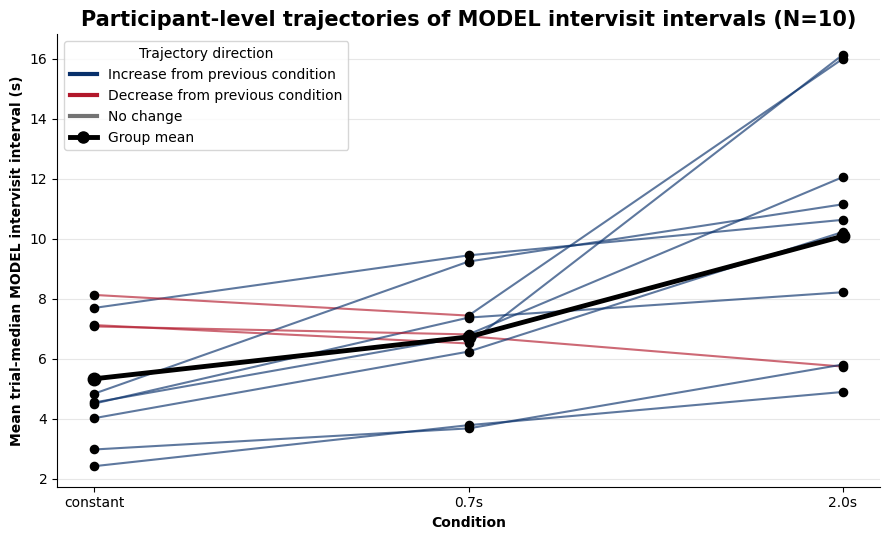

Participants shown: 10


condition
constant       5.327983
0.7s delay     6.722793
2.0s delay    10.080393
Name: Group mean, dtype: float64

In [202]:
# =======================================================
# CELL 9: PARTICIPANT-LEVEL TRAJECTORY PLOT
# =======================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

Y_COL = "participant_mean_trial_median_s"

COND_ORDER = [
    "constant",
    "0.7s delay",
    "2.0s delay"
]

COND_LABELS = [
    "constant",
    "0.7s",
    "2.0s"
]

COL_INCREASE = "#08306b"
COL_DECREASE = "#b2182b"
COL_EQUAL = "#737373"
COL_MEAN = "black"

# Create one row per participant and one column per condition
trajectory_wide = (
    participant_interval_summary
    .dropna(subset=[Y_COL])
    .pivot(
        index="participant_id",
        columns="condition",
        values=Y_COL
    )
    .reindex(columns=COND_ORDER)
)

# Trajectories require values in all three conditions
trajectory_wide = trajectory_wide.dropna()

n_participants = len(trajectory_wide)
x = np.arange(len(COND_ORDER))

fig, ax = plt.subplots(figsize=(9, 5.5))

# Individual participant trajectories
for participant_id, row in trajectory_wide.iterrows():

    y = row.to_numpy(dtype=float)

    # Participant points
    ax.scatter(
        x,
        y,
        color="black",
        s=35,
        zorder=3
    )

    # Plot each segment according to its direction
    for i in range(len(x) - 1):

        difference = y[i + 1] - y[i]

        if np.isclose(difference, 0):
            segment_color = COL_EQUAL
        elif difference > 0:
            segment_color = COL_INCREASE
        else:
            segment_color = COL_DECREASE

        ax.plot(
            x[i:i + 2],
            y[i:i + 2],
            color=segment_color,
            linewidth=1.5,
            alpha=0.65,
            zorder=2
        )

# Group mean of the participants shown in the plot
group_means_plot = trajectory_wide.mean(axis=0)

ax.plot(
    x,
    group_means_plot.to_numpy(),
    color=COL_MEAN,
    linewidth=3.5,
    marker="o",
    markersize=9,
    zorder=5
)

# Legend
legend_elements = [
    Line2D(
        [0], [0],
        color=COL_INCREASE,
        lw=3,
        label="Increase from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_DECREASE,
        lw=3,
        label="Decrease from previous condition"
    ),
    Line2D(
        [0], [0],
        color=COL_EQUAL,
        lw=3,
        label="No change"
    ),
    Line2D(
        [0], [0],
        color=COL_MEAN,
        lw=3.5,
        marker="o",
        markersize=8,
        label="Group mean"
    )
]

ax.legend(
    handles=legend_elements,
    title="Trajectory direction",
    loc="upper left",
    frameon=True
)

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS)

ax.set_xlabel("Condition", fontweight="bold")
ax.set_ylabel(
    "Mean trial-median MODEL intervisit interval (s)",
    fontweight="bold"
)

ax.set_title(
    f"Participant-level trajectories of MODEL intervisit intervals "
    f"(N={n_participants})",
    fontweight="bold",
    fontsize=15
)

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("Participants shown:", n_participants)
display(group_means_plot.rename("Group mean"))

# Statsitical test intervisit interval: EVENTS

In [393]:
# =======================================================
# CHECK: Spaltennamen und TRIAL_KEYS anschauen
# =======================================================

# Was steckt in TRIAL_KEYS?
print("TRIAL_KEYS:", TRIAL_KEYS)

# Alle Spaltennamen im DataFrame
print("\nSpalten in model_intervisit_intervals:")
print(model_intervisit_intervals.columns.tolist())

# Erste paar Zeilen zur Orientierung
display(model_intervisit_intervals.head(5))

# Datentypen (hilft zu sehen ob z.B. participant als int/string vorliegt)
print("\nDatentypen:")
print(model_intervisit_intervals.dtypes)

# Anzahl eindeutiger Werte je Spalte in TRIAL_KEYS (zeigt ob z.B. participant_id oder trial_id da drin ist)
for col in TRIAL_KEYS:
    print(f"\n{col}: {model_intervisit_intervals[col].nunique()} eindeutige Werte")
    print(model_intervisit_intervals[col].unique()[:10])

TRIAL_KEYS: ['participant_id', 'condition', 'model_order', 'model_name']

Spalten in model_intervisit_intervals:
['participant_id', 'condition', 'model_order', 'model_name', 'AOI_visit_id', 'AOI_CLEAN', 'visit_start_ms', 'visit_end_ms', 'n_object_gazes', 'visit_duration_ms', 'visit_duration_s', 'model_visit_number', 'previous_MODEL_visit_end_ms', 'intervisit_interval_ms', 'intervisit_interval_s']


,participant_id,condition,model_order,model_name,AOI_visit_id,AOI_CLEAN,visit_start_ms,visit_end_ms,n_object_gazes,visit_duration_ms,visit_duration_s,model_visit_number,previous_MODEL_visit_end_ms,intervisit_interval_ms,intervisit_interval_s
1,1,0.7s delay,7.0,C2M3F,6,MODEL,1.754660e+12,1.754660e+12,1,2134.0,2.134,2,1.754660e+12,8523.0,8.523
2,1,0.7s delay,7.0,C2M3F,8,MODEL,1.754660e+12,1.754660e+12,1,2723.0,2.723,3,1.754660e+12,4732.0,4.732
3,1,0.7s delay,7.0,C2M3F,13,MODEL,1.754660e+12,1.754660e+12,1,2777.0,2.777,4,1.754660e+12,6867.0,6.867
4,1,0.7s delay,7.0,C2M3F,16,MODEL,1.754660e+12,1.754660e+12,1,1211.0,1.211,5,1.754660e+12,4044.0,4.044
5,1,0.7s delay,7.0,C2M3F,18,MODEL,1.754660e+12,1.754660e+12,1,3500.0,3.500,6,1.754660e+12,3711.0,3.711



Datentypen:
participant_id                  object
condition                       object
model_order                    float64
model_name                      object
AOI_visit_id                     int64
AOI_CLEAN                       object
visit_start_ms                 float64
visit_end_ms                   float64
n_object_gazes                   int64
visit_duration_ms              float64
visit_duration_s               float64
model_visit_number               int64
previous_MODEL_visit_end_ms    float64
intervisit_interval_ms         float64
intervisit_interval_s          float64
dtype: object

participant_id: 10 eindeutige Werte
['1' '10' '2' '3' '4' '5' '6' '7' '8' '9']

condition: 3 eindeutige Werte
['0.7s delay' '2.0s delay' 'constant']

model_order: 18 eindeutige Werte
[ 7.  8.  9. 10. 11. 12. 13. 14. 15. 16.]

model_name: 18 eindeutige Werte
['C2M3F' 'C3M4A' 'C2M4A' 'C1M1F' 'C1M4A' 'C3M1F' 'C3M3F' 'C2M1F' 'C2M2A'
 'C1M6A']


## Check Normal distribution

MODEL INTERVISIT INTERVAL DISTRIBUTION
Number of intervals: 1428
Minimum:             0.121 s
Maximum:             92.176 s
Mean:                5.961 s
Median:              4.056 s
Standard deviation:  6.669 s
Skewness:            3.760
Zero intervals:      0
Negative intervals:  0

SHAPIRO-WILK TEST
W = 0.7040
p < 0.0001

DISTRIBUTION BY CONDITION


,N,Mean,Median,SD,Minimum,Maximum,Skewness
condition,,,,,,,
0.7s delay,471,5.728,4.044,5.999,0.133,63.166,3.315
2.0s delay,333,8.315,5.056,9.343,0.132,92.176,3.146
constant,624,4.881,3.822,4.903,0.121,47.001,3.549


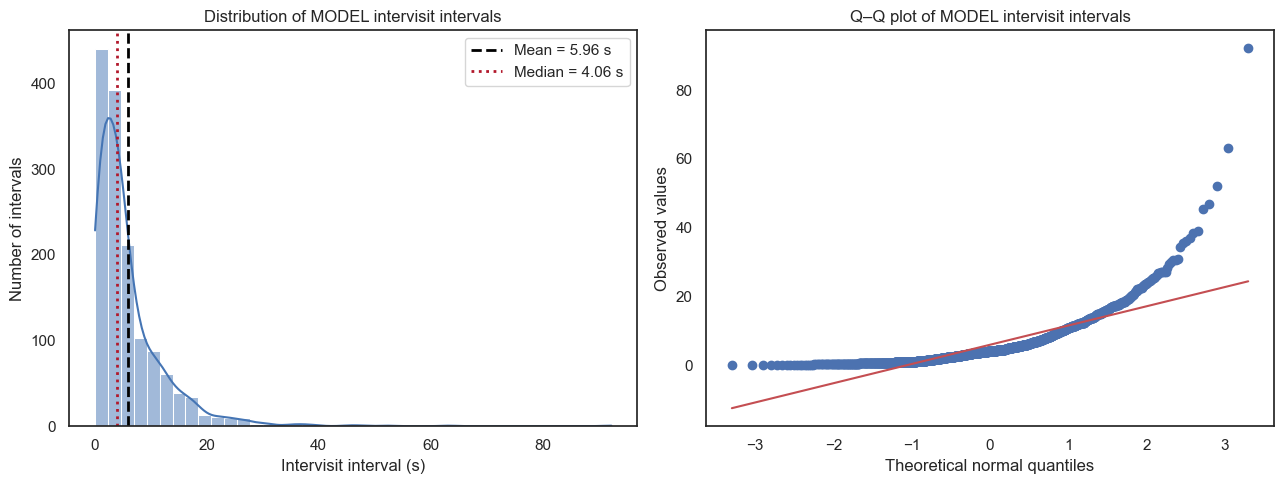

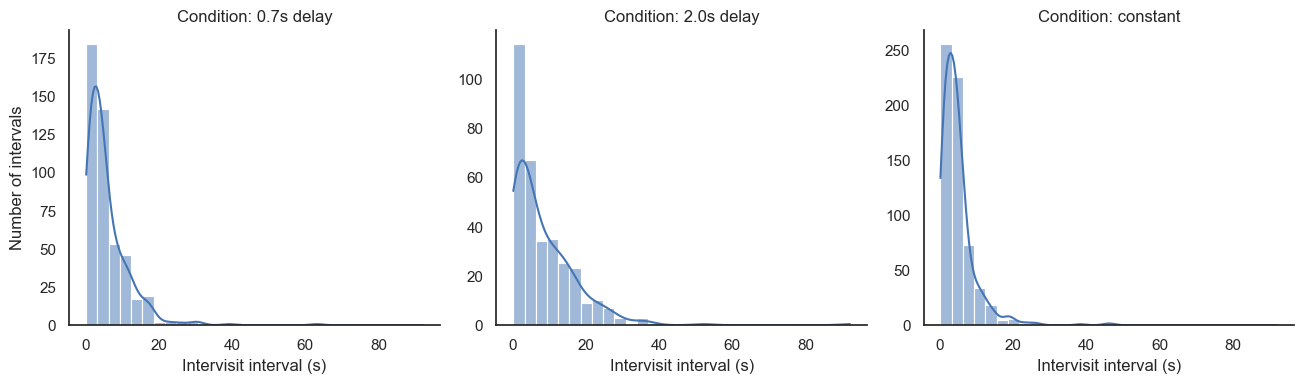

In [398]:
# =======================================================
# CELL 5: CHECK DISTRIBUTION OF MODEL INTERVISIT INTERVALS
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skew, shapiro

# Variable to examine
INTERVAL_COL = "intervisit_interval_s"
CONDITION_COL = "condition"

# Keep valid observations (keep all trial-key columns so trial_id
# can be built later, in addition to condition and the interval itself)
distribution_data = model_intervisit_intervals[
    TRIAL_KEYS + [INTERVAL_COL]
].dropna().copy()

intervals = distribution_data[INTERVAL_COL]

# =======================================================
# 1. BASIC INFORMATION
# =======================================================

print("=" * 55)
print("MODEL INTERVISIT INTERVAL DISTRIBUTION")
print("=" * 55)

print(f"Number of intervals: {len(intervals)}")
print(f"Minimum:             {intervals.min():.3f} s")
print(f"Maximum:             {intervals.max():.3f} s")
print(f"Mean:                {intervals.mean():.3f} s")
print(f"Median:              {intervals.median():.3f} s")
print(f"Standard deviation:  {intervals.std():.3f} s")
print(f"Skewness:            {skew(intervals, bias=False):.3f}")
print(f"Zero intervals:      {(intervals == 0).sum()}")
print(f"Negative intervals:  {(intervals < 0).sum()}")

# =======================================================
# 2. SHAPIRO-WILK TEST
# =======================================================

# Shapiro-Wilk is less reliable for extremely large samples.
# If N > 5000, use a reproducible sample of 5000 observations.
if len(intervals) > 5000:
    shapiro_data = intervals.sample(
        n=5000,
        random_state=42
    )
    print("\nShapiro-Wilk calculated on a sample of 5000 values.")
else:
    shapiro_data = intervals

shapiro_W, shapiro_p = shapiro(shapiro_data)

print("\n" + "=" * 55)
print("SHAPIRO-WILK TEST")
print("=" * 55)
print(f"W = {shapiro_W:.4f}")

if shapiro_p < 0.0001:
    print("p < 0.0001")
else:
    print(f"p = {shapiro_p:.4f}")

# =======================================================
# 3. DISTRIBUTION BY CONDITION
# =======================================================

condition_summary = (
    distribution_data
    .groupby(CONDITION_COL, observed=True)[INTERVAL_COL]
    .agg(
        N="count",
        Mean="mean",
        Median="median",
        SD="std",
        Minimum="min",
        Maximum="max",
        Skewness=lambda x: skew(x, bias=False)
    )
    .round(3)
)

print("\n" + "=" * 55)
print("DISTRIBUTION BY CONDITION")
print("=" * 55)

display(condition_summary)

# =======================================================
# 4. HISTOGRAM AND Q-Q PLOT
# =======================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
sns.histplot(
    data=distribution_data,
    x=INTERVAL_COL,
    bins=40,
    kde=True,
    color="#4575b4",
    ax=axes[0]
)

axes[0].axvline(
    intervals.mean(),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {intervals.mean():.2f} s"
)

axes[0].axvline(
    intervals.median(),
    color="#b2182b",
    linestyle=":",
    linewidth=2,
    label=f"Median = {intervals.median():.2f} s"
)

axes[0].set_title("Distribution of MODEL intervisit intervals")
axes[0].set_xlabel("Intervisit interval (s)")
axes[0].set_ylabel("Number of intervals")
axes[0].legend()

# Q-Q plot
stats.probplot(
    intervals,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Q–Q plot of MODEL intervisit intervals")
axes[1].set_xlabel("Theoretical normal quantiles")
axes[1].set_ylabel("Observed values")

plt.tight_layout()
plt.show()

# =======================================================
# 5. HISTOGRAMS BY CONDITION
# =======================================================

g = sns.displot(
    data=distribution_data,
    x=INTERVAL_COL,
    col=CONDITION_COL,
    col_wrap=3,
    bins=30,
    kde=True,
    color="#4575b4",
    height=4,
    aspect=1.1,
    facet_kws={"sharex": True, "sharey": False}
)

g.set_axis_labels(
    "Intervisit interval (s)",
    "Number of intervals"
)

g.set_titles("Condition: {col_name}")

plt.show()

### Sharpiro wilk for each cindition:

SHAPIRO-WILK TEST PER CONDITION (RAW DATA)
0.7s delay: N=471, W=0.7342, p=<0.0001, skew=3.315
2.0s delay: N=333, W=0.7528, p=<0.0001, skew=3.146
constant: N=624, W=0.7070, p=<0.0001, skew=3.549


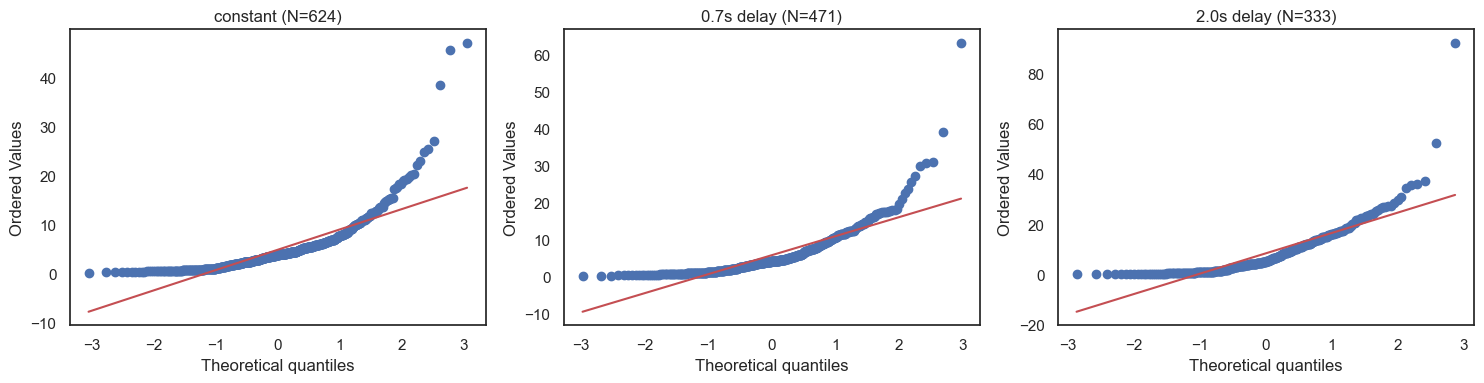

In [399]:
# =======================================================
# + additional SHAPIRO-WILK + Q-Q PLOT PER CONDITION
# =======================================================

print("=" * 55)
print("SHAPIRO-WILK TEST PER CONDITION (RAW DATA)")
print("=" * 55)

for cond in distribution_data[CONDITION_COL].unique():
    vals = distribution_data.loc[
        distribution_data[CONDITION_COL] == cond, INTERVAL_COL
    ]
    stat, p = shapiro(vals)
    print(
        f"{cond}: N={len(vals)}, W={stat:.4f}, "
        f"p={'<0.0001' if p < 0.0001 else f'{p:.4f}'}, "
        f"skew={skew(vals, bias=False):.3f}"
    )


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

condition_order = ["constant", "0.7s delay", "2.0s delay"]

for i, cond in enumerate(condition_order):
    vals = distribution_data.loc[
        distribution_data[CONDITION_COL] == cond, INTERVAL_COL
    ]
    stats.probplot(vals, dist="norm", plot=axes[i])
    axes[i].set_title(f"{cond} (N={len(vals)})")

plt.tight_layout()
plt.show()

In [400]:
# =======================================================
# CELL 6: EXCLUDE INVALID (NEGATIVE) INTERVISIT INTERVALS
# =======================================================

# Negative intervals can occur due to overlapping/nested AOI visits
# and are not physically meaningful as "time between visits".

print("=" * 55)
print("EXCLUSION OF NEGATIVE INTERVISIT INTERVALS")
print("=" * 55)

# Count negative intervals per condition BEFORE exclusion
neg_summary = (
    distribution_data[distribution_data[INTERVAL_COL] < 0]
    .groupby(CONDITION_COL, observed=True)[INTERVAL_COL]
    .agg(N_negative="count")
)

print(f"\nTotal intervals before exclusion: {len(distribution_data)}")
print(f"Total negative intervals:         {(distribution_data[INTERVAL_COL] < 0).sum()}")

print("\nNegative intervals by condition:")
display(neg_summary)

# Exclude negative intervals
model_intervisit_clean = (
    distribution_data[distribution_data[INTERVAL_COL] >= 0]
    .copy()
)

print(f"\nTotal intervals after exclusion:  {len(model_intervisit_clean)}")

# Sanity check: remaining N per condition
print("\nRemaining N per condition:")
display(
    model_intervisit_clean
    .groupby(CONDITION_COL, observed=True)[INTERVAL_COL]
    .agg(N="count")
)

EXCLUSION OF NEGATIVE INTERVISIT INTERVALS

Total intervals before exclusion: 1428
Total negative intervals:         0

Negative intervals by condition:


,N_negative
condition,



Total intervals after exclusion:  1428

Remaining N per condition:


,N
condition,
0.7s delay,471
2.0s delay,333
constant,624


LOG-TRANSFORMED MODEL INTERVISIT INTERVALS
Number of intervals: 1428
Mean (log):          1.268
Median (log):        1.400
SD (log):            1.100
Skewness (log):      -0.429
Kurtosis (log):      -0.064

SHAPIRO-WILK TEST (log-transformed)
W = 0.9830
p < 0.0001

LOG-DISTRIBUTION BY CONDITION


,N,Mean,Median,SD,Skewness,Kurtosis
condition,,,,,,
0.7s delay,471,1.275,1.397,1.039,-0.351,-0.285
2.0s delay,333,1.397,1.621,1.418,-0.634,-0.446
constant,624,1.194,1.341,0.932,-0.360,-0.000


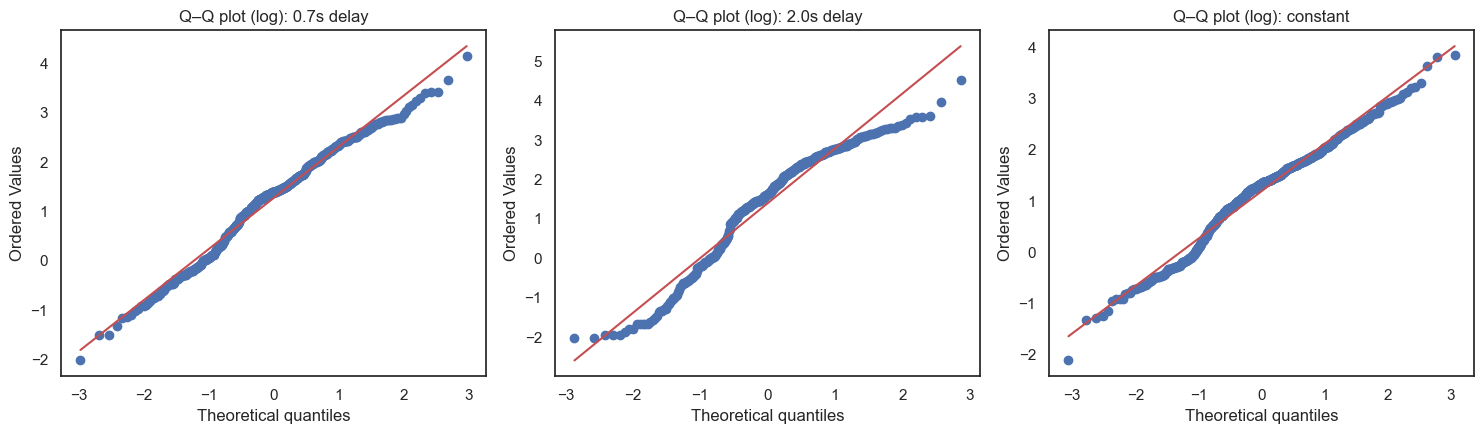

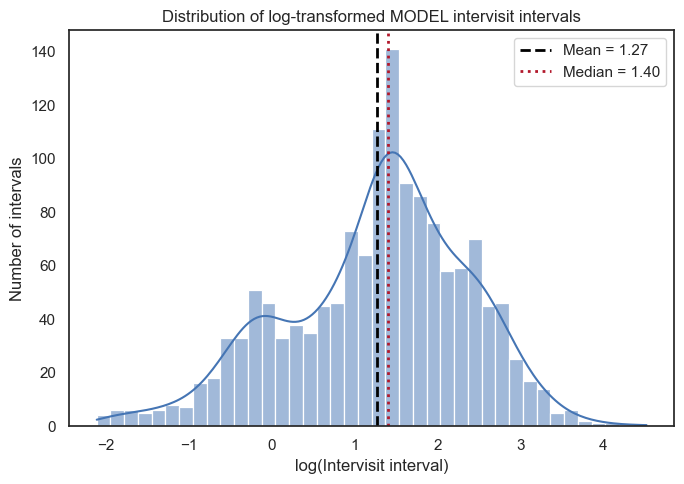

In [401]:
# =======================================================
# CELL 7: LOG-TRANSFORM INTERVISIT INTERVALS
# =======================================================

# Log-transformation to reduce the strong right-skew observed in Cell 5.

model_intervisit_clean["log_intervisit_interval"] = np.log(
    model_intervisit_clean[INTERVAL_COL]
)

print("=" * 55)
print("LOG-TRANSFORMED MODEL INTERVISIT INTERVALS")
print("=" * 55)

log_intervals = model_intervisit_clean["log_intervisit_interval"]

print(f"Number of intervals: {len(log_intervals)}")
print(f"Mean (log):          {log_intervals.mean():.3f}")
print(f"Median (log):        {log_intervals.median():.3f}")
print(f"SD (log):            {log_intervals.std():.3f}")
print(f"Skewness (log):      {skew(log_intervals, bias=False):.3f}")
print(f"Kurtosis (log):      {stats.kurtosis(log_intervals, bias=False):.3f}")

# Shapiro-Wilk on log-transformed values (with same sampling rule as Cell 5)
if len(log_intervals) > 5000:
    shapiro_log_data = log_intervals.sample(n=5000, random_state=42)
    print("\nShapiro-Wilk calculated on a sample of 5000 log-values.")
else:
    shapiro_log_data = log_intervals

shapiro_W_log, shapiro_p_log = shapiro(shapiro_log_data)

print("\nSHAPIRO-WILK TEST (log-transformed)")
print(f"W = {shapiro_W_log:.4f}")
if shapiro_p_log < 0.0001:
    print("p < 0.0001")
else:
    print(f"p = {shapiro_p_log:.4f}")

# Distribution by condition (log scale)
log_condition_summary = (
    model_intervisit_clean
    .groupby(CONDITION_COL, observed=True)["log_intervisit_interval"]
    .agg(
        N="count",
        Mean="mean",
        Median="median",
        SD="std",
        Skewness=lambda x: skew(x, bias=False),
        Kurtosis=lambda x: stats.kurtosis(x, bias=False)
    )
    .round(3)
)

print("\n" + "=" * 55)
print("LOG-DISTRIBUTION BY CONDITION")
print("=" * 55)
display(log_condition_summary)

# Q-Q plots by condition (log scale)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (cond, grp) in zip(axes, model_intervisit_clean.groupby(CONDITION_COL, observed=True)):
    stats.probplot(grp["log_intervisit_interval"], dist="norm", plot=ax)
    ax.set_title(f"Q–Q plot (log): {cond}")
plt.tight_layout()
plt.show()

# Overall histogram of log-transformed values
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(
    data=model_intervisit_clean,
    x="log_intervisit_interval",
    bins=40,
    kde=True,
    color="#4575b4",
    ax=ax
)
ax.axvline(log_intervals.mean(), color="black", linestyle="--", linewidth=2,
           label=f"Mean = {log_intervals.mean():.2f}")
ax.axvline(log_intervals.median(), color="#b2182b", linestyle=":", linewidth=2,
           label=f"Median = {log_intervals.median():.2f}")
ax.set_title("Distribution of log-transformed MODEL intervisit intervals")
ax.set_xlabel("log(Intervisit interval)")
ax.set_ylabel("Number of intervals")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =======================================================
# CELL 8: CREATE TRIAL-ID
# =======================================================

# trial_id identifies which events belong to the same trial,
# so the LMM can account for within-trial correlation.
# Events are NOT averaged - each row remains one individual event.

model_intervisit_clean["trial_id"] = (
    model_intervisit_clean["participant_id"].astype(str) + "_" +
    model_intervisit_clean["model_name"].astype(str) + "_" +
    model_intervisit_clean["model_order"].astype(str)
)

print("=" * 55)
print("TRIAL-ID CREATED")
print("=" * 55)
print(f"Number of unique trials:       {model_intervisit_clean['trial_id'].nunique()}")
print(f"Number of unique participants: {model_intervisit_clean['participant_id'].nunique()}")
print(f"Number of events (rows):       {len(model_intervisit_clean)}")

# Sanity check: how many events per trial on average
events_per_trial = model_intervisit_clean.groupby("trial_id").size()
print(f"\nEvents per trial - Mean: {events_per_trial.mean():.2f}, "
      f"Min: {events_per_trial.min()}, Max: {events_per_trial.max()}")

TRIAL-ID CREATED
Number of unique trials:       171
Number of unique participants: 10
Number of events (rows):       1428

Events per trial - Mean: 8.35, Min: 1, Max: 47


## LMM correct intervisit interval

In [405]:
# =======================================================
# CELL 9: EVENT-LEVEL LMM (mit korrekter Referenzkategorie)
# =======================================================

import statsmodels.formula.api as smf

md = smf.mixedlm(
    "log_intervisit_interval ~ C(condition, Treatment(reference='constant'))",
    data=model_intervisit_clean,
    groups=model_intervisit_clean["participant_id"],
    vc_formula={"trial": "0 + C(trial_id)"}
)

mdf = md.fit(reml=True)

print("=" * 55)
print("EVENT-LEVEL LMM: log(Intervisit Interval) ~ Condition")
print("Reference category: constant")
print("=" * 55)
print(mdf.summary())

EVENT-LEVEL LMM: log(Intervisit Interval) ~ Condition
Reference category: constant
                                Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           log_intervisit_interval
No. Observations:             1428              Method:                       REML                   
No. Groups:                   10                Scale:                        0.9844                 
Min. group size:              76                Log-Likelihood:               -2090.9637             
Max. group size:              256               Converged:                    Yes                    
Mean group size:              142.8                                                                  
-----------------------------------------------------------------------------------------------------
                                                            Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------

In [407]:
# Prüfen ob trial_id eindeutig einer Condition zugeordnet ist
check = model_intervisit_clean.groupby("trial_id")["condition"].nunique()
print("Trials mit >1 Condition:", (check > 1).sum())

Trials mit >1 Condition: 0


In [406]:
# =======================================================
# CELL 10: PAIRWISE COMPARISONS WITH TUKEY CORRECTION
# =======================================================

import numpy as np
from statsmodels.stats.libqsturng import psturng

# Extract fixed effect names, coefficients, and covariance matrix
params = mdf.fe_params
cov = mdf.cov_params().loc[params.index, params.index]

name_07 = "C(condition, Treatment(reference='constant'))[T.0.7s delay]"
name_20 = "C(condition, Treatment(reference='constant'))[T.2.0s delay]"

# --- Contrast 1: constant vs 0.7s delay ---
est_c_07 = params[name_07]
se_c_07 = np.sqrt(cov.loc[name_07, name_07])

# --- Contrast 2: constant vs 2.0s delay ---
est_c_20 = params[name_20]
se_c_20 = np.sqrt(cov.loc[name_20, name_20])

# --- Contrast 3: 0.7s delay vs 2.0s delay ---
est_07_20 = params[name_20] - params[name_07]
var_07_20 = (
    cov.loc[name_20, name_20]
    + cov.loc[name_07, name_07]
    - 2 * cov.loc[name_20, name_07]
)
se_07_20 = np.sqrt(var_07_20)

contrasts = pd.DataFrame({
    "Comparison": [
        "constant vs 0.7s delay",
        "constant vs 2.0s delay",
        "0.7s delay vs 2.0s delay"
    ],
    "Estimate (log)": [est_c_07, est_c_20, est_07_20],
    "SE": [se_c_07, se_c_20, se_07_20]
})

contrasts["z"] = contrasts["Estimate (log)"] / contrasts["SE"]

# Asymptotic Tukey-corrected p-values (studentized range, k=3 groups, df=inf)
contrasts["p_tukey"] = psturng(
    np.abs(contrasts["z"]) * np.sqrt(2),
    3,
    np.inf
)

# Back-transform to ratio scale
contrasts["Ratio (exp)"] = np.exp(contrasts["Estimate (log)"])
contrasts["CI_lower"] = np.exp(contrasts["Estimate (log)"] - 1.96 * contrasts["SE"])
contrasts["CI_upper"] = np.exp(contrasts["Estimate (log)"] + 1.96 * contrasts["SE"])

print("=" * 70)
print("PAIRWISE COMPARISONS (Tukey-corrected, asymptotic)")
print("=" * 70)
display(contrasts.round(4))

PAIRWISE COMPARISONS (Tukey-corrected, asymptotic)


,Comparison,Estimate (log),SE,z,p_tukey,Ratio (exp),CI_lower,CI_upper
0,constant vs 0.7s delay,0.0906,0.1079,0.8393,0.6634,1.0948,0.8861,1.3526
1,constant vs 2.0s delay,0.2630,0.1126,2.3350,0.0511,1.3008,1.0431,1.6221
2,0.7s delay vs 2.0s delay,0.1724,0.1171,1.4718,0.3051,1.1882,0.9444,1.4948


## START LOG/LMM old?

In [376]:
# =======================================================
# 0) SETUP
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, studentized_range
import statsmodels.formula.api as smf

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

TRIAL_KEYS = ["participant_id", "condition", "model_order", "model_name"]

In [377]:
# =======================================================
# 1) TRIAL-LEVEL AGGREGATION (log-first, then mean)
# =======================================================

df = model_intervisit_intervals[
    model_intervisit_intervals["intervisit_interval_s"] > 0
].copy()

df["log_ivi_event"] = np.log(df["intervisit_interval_s"])

group_columns = list(dict.fromkeys(TRIAL_KEYS))

ivi_per_trial = (
    df
    .groupby(group_columns, observed=True)
    .agg(
        log_mean_ivi=("log_ivi_event", "mean"),
        mean_ivi_s=("intervisit_interval_s", "mean"),
        n_intervals=("intervisit_interval_s", "size")
    )
    .reset_index()
)

ivi_per_trial["participant_id"] = ivi_per_trial["participant_id"].astype(str)
ivi_per_trial["condition"] = pd.Categorical(
    ivi_per_trial["condition"].astype(str),
    categories=COND_ORDER,
    ordered=True
)

print("Number of trials:", len(ivi_per_trial))
print(ivi_per_trial["condition"].value_counts())
print("\nIntervals per trial used for aggregation:")
print(ivi_per_trial["n_intervals"].describe())

Number of trials: 171
condition
constant      60
0.7s delay    56
2.0s delay    55
Name: count, dtype: int64

Intervals per trial used for aggregation:
count    171.000000
mean       8.350877
std        6.892002
min        1.000000
25%        3.000000
50%        6.000000
75%       12.000000
max       47.000000
Name: n_intervals, dtype: float64


=== SHAPIRO-WILK: RAW TRIAL-LEVEL MEAN IVI ===
constant: N=60, W=0.8301, p=8.25e-07, skew=1.932, kurtosis=4.754
0.7s delay: N=56, W=0.7687, p=5.29e-08, skew=2.570, kurtosis=9.540
2.0s delay: N=55, W=0.9120, p=6.71e-04, skew=0.996, kurtosis=0.397


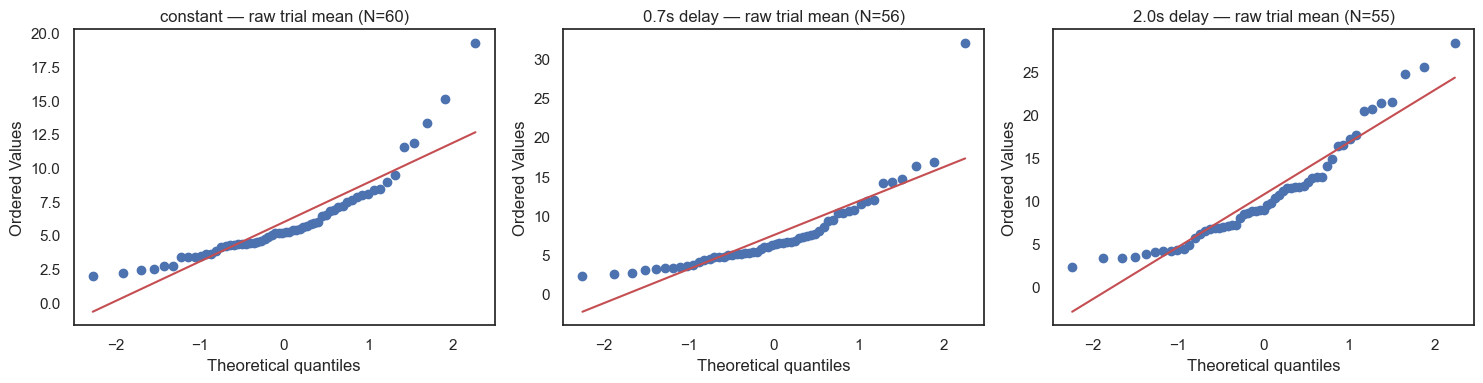

In [378]:
# =======================================================
# 2) NORMALITY CHECK: RAW TRIAL-LEVEL MEANS
# =======================================================

print("=== SHAPIRO-WILK: RAW TRIAL-LEVEL MEAN IVI ===")
for cond in COND_ORDER:
    vals = ivi_per_trial.loc[ivi_per_trial["condition"] == cond, "mean_ivi_s"]
    stat, p = shapiro(vals)
    print(f"{cond}: N={len(vals)}, W={stat:.4f}, p={p:.2e}, "
          f"skew={stats.skew(vals):.3f}, kurtosis={stats.kurtosis(vals):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cond in enumerate(COND_ORDER):
    vals = ivi_per_trial.loc[ivi_per_trial["condition"] == cond, "mean_ivi_s"]
    stats.probplot(vals, dist="norm", plot=axes[i])
    axes[i].set_title(f"{cond} — raw trial mean (N={len(vals)})")
plt.tight_layout()
plt.savefig("qq_raw_trial_ivi.png", dpi=150)
plt.show()

=== SHAPIRO-WILK: LOG TRIAL-LEVEL MEAN IVI ===
constant: N=60, W=0.9777, p=3.38e-01, skew=0.420, kurtosis=0.581
0.7s delay: N=56, W=0.9594, p=5.70e-02, skew=0.480, kurtosis=-0.028
2.0s delay: N=55, W=0.9764, p=3.50e-01, skew=-0.410, kurtosis=0.477


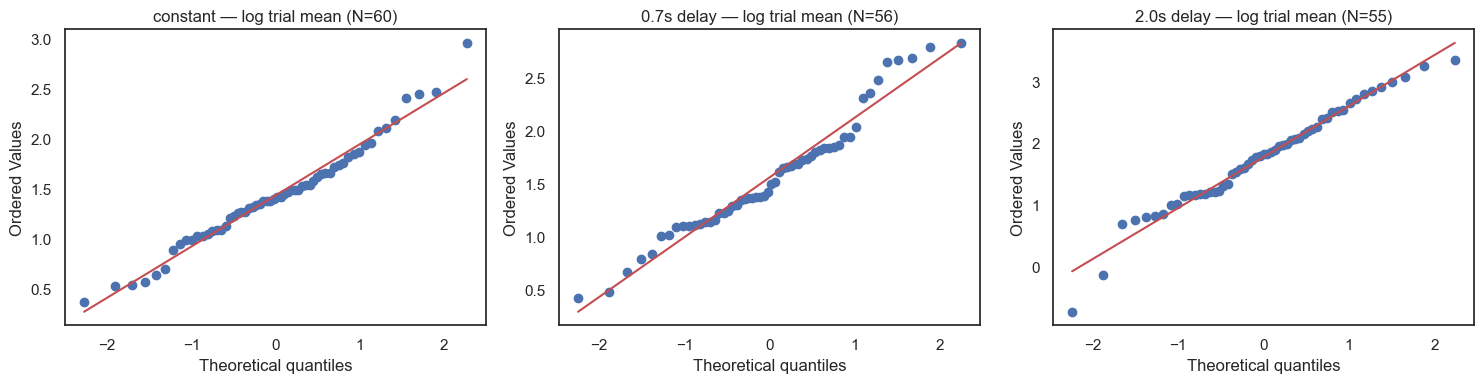

In [379]:
# =======================================================
# 3) NORMALITY CHECK: LOG-TRANSFORMED TRIAL-LEVEL MEANS
# =======================================================

print("=== SHAPIRO-WILK: LOG TRIAL-LEVEL MEAN IVI ===")
for cond in COND_ORDER:
    vals = ivi_per_trial.loc[ivi_per_trial["condition"] == cond, "log_mean_ivi"]
    stat, p = shapiro(vals)
    print(f"{cond}: N={len(vals)}, W={stat:.4f}, p={p:.2e}, "
          f"skew={stats.skew(vals):.3f}, kurtosis={stats.kurtosis(vals):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cond in enumerate(COND_ORDER):
    vals = ivi_per_trial.loc[ivi_per_trial["condition"] == cond, "log_mean_ivi"]
    stats.probplot(vals, dist="norm", plot=axes[i])
    axes[i].set_title(f"{cond} — log trial mean (N={len(vals)})")
plt.tight_layout()
plt.savefig("qq_log_trial_ivi.png", dpi=150)
plt.show()

In [381]:
# =======================================================
# 4) LMM ON LOG TRIAL-LEVEL MEANS
# =======================================================

lmm_ivi = smf.mixedlm(
    "log_mean_ivi ~ condition",
    data=ivi_per_trial,
    groups=ivi_per_trial["participant_id"]
)

lmm_results_ivi = lmm_ivi.fit(reml=True)
print(lmm_results_ivi.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   log_mean_ivi
No. Observations:    171       Method:               REML        
No. Groups:          10        Scale:                0.3109      
Min. group size:     14        Log-Likelihood:       -154.9313   
Max. group size:     18        Converged:            Yes         
Mean group size:     17.1                                        
-----------------------------------------------------------------
                        Coef. Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               1.431    0.125 11.404 0.000  1.185  1.677
condition[T.0.7s delay] 0.136    0.104  1.312 0.190 -0.067  0.339
condition[T.2.0s delay] 0.357    0.104  3.428 0.001  0.153  0.562
Group Var               0.106    0.108                           



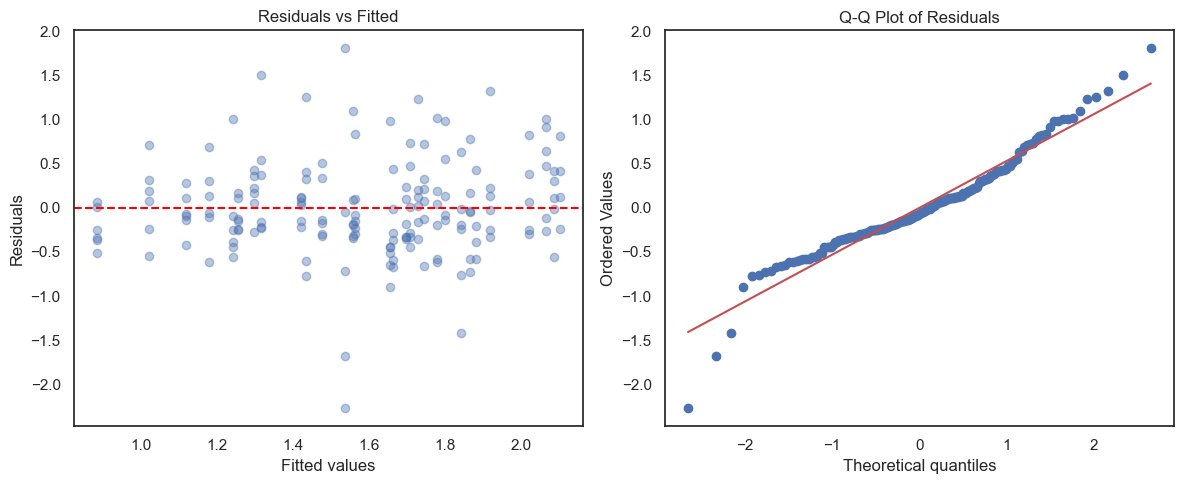

Shapiro-Wilk on residuals: W=0.9528, p=1.69e-05
Skewness: 0.078, Kurtosis: 2.342


In [382]:
# =======================================================
# 5) RESIDUAL CHECK
# =======================================================

residuals = lmm_results_ivi.resid
fitted = lmm_results_ivi.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted, residuals, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.savefig("model_residual_check_ivi.png", dpi=150)
plt.show()

stat, p = shapiro(residuals)
print(f"Shapiro-Wilk on residuals: W={stat:.4f}, p={p:.2e}")
print(f"Skewness: {stats.skew(residuals):.3f}, Kurtosis: {stats.kurtosis(residuals):.3f}")

In [383]:
# =======================================================
# 6) TUKEY-CORRECTED POST-HOC COMPARISONS (Studentized Range)
# =======================================================

params = lmm_results_ivi.fe_params
cov_full = lmm_results_ivi.cov_params()
cov = cov_full.loc[params.index, params.index]

print(params.index)  # Reihenfolge prüfen: [Intercept, condition[T.0.7s delay], condition[T.2.0s delay]]

k = 3
n = ivi_per_trial["participant_id"].nunique()
df_approx = (n - 1) * (k - 1)

contrasts = {
    "0.7s delay vs constant":   pd.Series([0,  1, 0], index=params.index),
    "2.0s delay vs constant":   pd.Series([0,  0, 1], index=params.index),
    "2.0s delay vs 0.7s delay": pd.Series([0, -1, 1], index=params.index),
}

rows = []
for name, c in contrasts.items():
    est = float(c @ params)
    se = float(np.sqrt(c.values @ cov.values @ c.values))
    q = np.sqrt(2) * abs(est) / se
    p_tukey = 1 - studentized_range.cdf(q, k, df_approx)
    rows.append({
        "comparison": name,
        "estimate (log)": round(est, 3),
        "SE": round(se, 3),
        "q": round(q, 3),
        "p_tukey": round(p_tukey, 5)
    })

tukey_results_ivi = pd.DataFrame(rows)
display(tukey_results_ivi)

Index(['Intercept', 'condition[T.0.7s delay]', 'condition[T.2.0s delay]'], dtype='object')


,comparison,estimate (log),SE,q,p_tukey
0,0.7s delay vs constant,0.136,0.104,1.855,0.40692
1,2.0s delay vs constant,0.357,0.104,4.848,0.00802
2,2.0s delay vs 0.7s delay,0.221,0.106,2.954,0.12043


## Friedman check

In [384]:
# =======================================================
# FRIEDMAN TEST + WILCOXON POST-HOC (HOLM) ON TRIAL-LEVEL DATA
# =======================================================

from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

# Proband-Mittelwert der Trial-level log-aggregierten Werte
participant_level = (
    ivi_per_trial
    .groupby(["participant_id", "condition"], observed=True)["log_mean_ivi"]
    .mean()
    .unstack()
)[["constant", "0.7s delay", "2.0s delay"]]

print(participant_level)

stat, p = friedmanchisquare(
    participant_level["constant"],
    participant_level["0.7s delay"],
    participant_level["2.0s delay"]
)
print(f"\nFriedman test: chi2={stat:.3f}, p={p:.5f}")

pairs = [
    ("constant", "0.7s delay"),
    ("constant", "2.0s delay"),
    ("0.7s delay", "2.0s delay"),
]

rows = []
pvals = []
for a, b in pairs:
    stat_w, p_w = wilcoxon(participant_level[a], participant_level[b])
    rows.append({"comparison": f"{a} vs {b}", "W": stat_w, "p_raw": p_w})
    pvals.append(p_w)

reject, pvals_corrected, _, _ = multipletests(pvals, method="holm")

for row, p_corr, rej in zip(rows, pvals_corrected, reject):
    row["p_holm"] = p_corr
    row["significant"] = rej

friedman_posthoc_ivi = pd.DataFrame(rows)
display(friedman_posthoc_ivi)

condition       constant  0.7s delay  2.0s delay
participant_id                                  
1               1.592783    1.553816    2.095682
10              1.459749    1.554704    1.327621
2               1.732348    1.509660    2.505131
3               0.650160    1.107071    1.122555
4               1.412299    1.582286    1.755348
5               1.062430    1.174045    1.462130
6               1.905578    1.791664    2.137727
7               1.415885    2.089790    2.165359
8               1.239418    1.617364    0.957084
9               1.836001    1.693431    2.379958

Friedman test: chi2=5.600, p=0.06081


,comparison,W,p_raw,p_holm,significant
0,constant vs 0.7s delay,17.0,0.322266,0.322266,False
1,constant vs 2.0s delay,4.0,0.013672,0.041016,True
2,0.7s delay vs 2.0s delay,12.0,0.130859,0.261719,False


## Log transform and check

SHAPIRO-WILK TEST PER CONDITION (LOG-TRANSFORMED)
0.7s delay: N=471, W=0.9844, p=<0.0001, skew=-0.351, kurtosis=-0.295
2.0s delay: N=333, W=0.9459, p=<0.0001, skew=-0.634, kurtosis=-0.457
constant: N=624, W=0.9813, p=<0.0001, skew=-0.360, kurtosis=-0.010


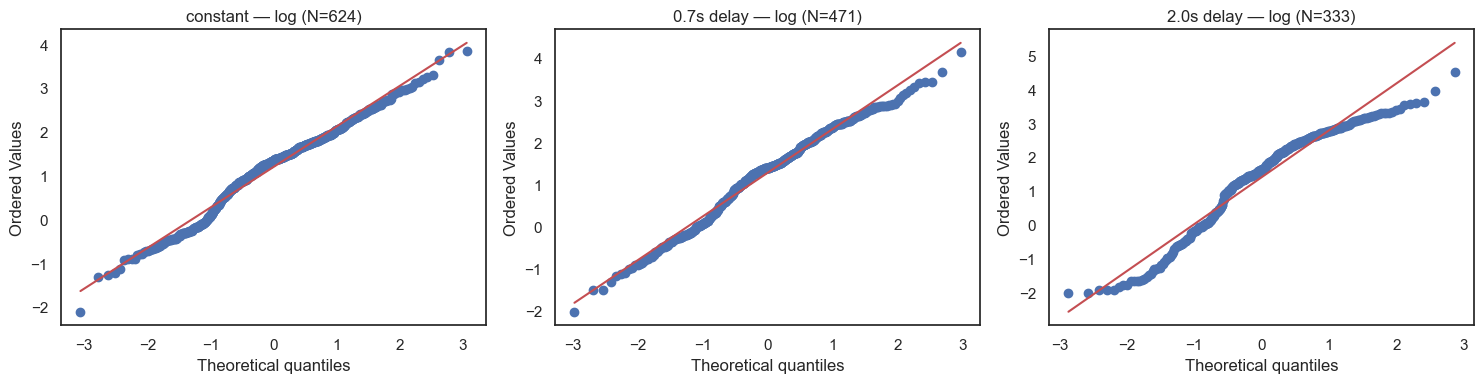

In [369]:
# =======================================================
# CELL 7: LOG-TRANSFORMATION + SHAPIRO-WILK / Q-Q PER CONDITION
# =======================================================

distribution_data["log_interval"] = np.log(
    distribution_data[INTERVAL_COL]
)

print("=" * 55)
print("SHAPIRO-WILK TEST PER CONDITION (LOG-TRANSFORMED)")
print("=" * 55)

for cond in distribution_data[CONDITION_COL].unique():
    vals = distribution_data.loc[
        distribution_data[CONDITION_COL] == cond, "log_interval"
    ]
    stat, p = shapiro(vals)
    print(
        f"{cond}: N={len(vals)}, W={stat:.4f}, "
        f"p={'<0.0001' if p < 0.0001 else f'{p:.4f}'}, "
        f"skew={skew(vals, bias=False):.3f}, "
        f"kurtosis={stats.kurtosis(vals):.3f}"
    )


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

condition_order = ["constant", "0.7s delay", "2.0s delay"]

for i, cond in enumerate(condition_order):
    vals = distribution_data.loc[
        distribution_data[CONDITION_COL] == cond, "log_interval"
    ]
    stats.probplot(vals, dist="norm", plot=axes[i])
    axes[i].set_title(f"{cond} — log (N={len(vals)})")

plt.tight_layout()
plt.show()

## LMM

In [374]:
# =======================================================
# CELL 8: LINEAR MIXED MODEL ON LOG-TRANSFORMED INTERVALS
# =======================================================

import statsmodels.formula.api as smf

# Condition-Reihenfolge festlegen (constant als Referenz)
distribution_data["condition"] = pd.Categorical(
    distribution_data["condition"],
    categories=["constant", "0.7s delay", "2.0s delay"],
    ordered=True
)

# participant_id muss auch in distribution_data vorhanden sein --
# falls nicht, aus model_intervisit_intervals dazu mergen:
# distribution_data = model_intervisit_intervals[["participant_id", "condition", "log_interval"]]... 
# (siehe Hinweis unten)

distribution_data["participant_id"] = distribution_data["participant_id"].astype(str)

lmm_intervisit = smf.mixedlm(
    "log_interval ~ condition",
    data=distribution_data,
    groups=distribution_data["participant_id"]
)

lmm_intervisit_fit = lmm_intervisit.fit(reml=True)
print(lmm_intervisit_fit.summary())



              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   log_interval
No. Observations:    1428      Method:               REML        
No. Groups:          10        Scale:                1.0808      
Min. group size:     76        Log-Likelihood:       -2099.0709  
Max. group size:     256       Converged:            Yes         
Mean group size:     142.8                                       
-----------------------------------------------------------------
                        Coef. Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               1.271    0.118 10.780 0.000  1.040  1.502
condition[T.0.7s delay] 0.058    0.064  0.905 0.366 -0.067  0.183
condition[T.2.0s delay] 0.206    0.071  2.911 0.004  0.067  0.344
Group Var               0.121    0.058                           



In [375]:
# =======================================================
# TUKEY-KORRIGIERTE POST-HOC-VERGLEICHE (Log-LMM-Contrasts)
# =======================================================

import numpy as np
import pandas as pd
from scipy.stats import studentized_range

params = lmm_intervisit_fit.fe_params
cov_full = lmm_intervisit_fit.cov_params()
cov = cov_full.loc[params.index, params.index]

print(params.index)  # zur Kontrolle der Parameter-Reihenfolge

k = 3
n = 10
df_approx = (n - 1) * (k - 1)

contrasts = {
    "0.7s delay vs constant":   pd.Series([0,  1, 0], index=params.index),
    "2.0s delay vs constant":   pd.Series([0,  0, 1], index=params.index),
    "2.0s delay vs 0.7s delay": pd.Series([0, -1, 1], index=params.index),
}

rows = []
for name, c in contrasts.items():
    est = float(c @ params)
    se = float(np.sqrt(c.values @ cov.values @ c.values))
    q = np.sqrt(2) * abs(est) / se
    p_tukey = 1 - studentized_range.cdf(q, k, df_approx)
    rows.append({
        "comparison": name,
        "estimate (log)": round(est, 3),
        "SE": round(se, 3),
        "q": round(q, 3),
        "p_tukey": round(p_tukey, 5)
    })

tukey_results_intervisit = pd.DataFrame(rows)
display(tukey_results_intervisit)

Index(['Intercept', 'condition[T.0.7s delay]', 'condition[T.2.0s delay]'], dtype='object')


,comparison,estimate (log),SE,q,p_tukey
0,0.7s delay vs constant,0.058,0.064,1.279,0.64439
1,2.0s delay vs constant,0.206,0.071,4.117,0.02408
2,2.0s delay vs 0.7s delay,0.148,0.075,2.800,0.14594


## Calculate intervisit intervals on trial level

In [239]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# =======================================================
# 1. MEAN INTERVISIT INTERVAL PER TRIAL
# =======================================================

group_columns = list(
    dict.fromkeys(
        TRIAL_KEYS + ["participant_id", "condition"]
    )
)

ivi_per_trial = (
    model_intervisit_intervals
    .groupby(group_columns, observed=True)
    ["intervisit_interval_s"]
    .mean()
    .reset_index(name="mean_ivi_s")
)

# Check invalid values before excluding anything
print("Number of trials:", len(ivi_per_trial))
print("Missing values:", ivi_per_trial["mean_ivi_s"].isna().sum())
print("Zero or negative values:", (ivi_per_trial["mean_ivi_s"] <= 0).sum())

# Logarithm requires positive values
ivi_per_trial = ivi_per_trial[
    ivi_per_trial["mean_ivi_s"] > 0
].copy()

ivi_per_trial["log_mean_ivi"] = np.log(
    ivi_per_trial["mean_ivi_s"]
)

ivi_per_trial["participant_id"] = (
    ivi_per_trial["participant_id"].astype(str)
)

ivi_per_trial["condition_cat"] = pd.Categorical(
    ivi_per_trial["condition"].astype(str),
    categories=COND_ORDER,
    ordered=False
)

# =======================================================
# 2. LOG-LMM
# =======================================================

lmm_ivi = smf.mixedlm(
    """
    log_mean_ivi
    ~ C(condition_cat, Treatment(reference='constant'))
    """,
    data=ivi_per_trial,
    groups=ivi_per_trial["participant_id"]
)

lmm_results_ivi = lmm_ivi.fit(
    method="lbfgs",
    reml=True
)

print(lmm_results_ivi.summary())

Number of trials: 171
Missing values: 0
Zero or negative values: 0
                                  Mixed Linear Model Regression Results
Model:                             MixedLM                Dependent Variable:                log_mean_ivi
No. Observations:                  171                    Method:                            REML        
No. Groups:                        10                     Scale:                             0.1944      
Min. group size:                   14                     Log-Likelihood:                    -116.8881   
Max. group size:                   18                     Converged:                         Yes         
Mean group size:                   17.1                                                                  
---------------------------------------------------------------------------------------------------------
                                                                Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------

/opt/miniconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


## Inferential statistic - intervisit intervals using LOG LMM

In [203]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Sicherstellen, dass keine Werte <= 0 enthalten sind & Log-Transformation durchführen
df_ivi = model_intervisit_intervals[
    model_intervisit_intervals["intervisit_interval_s"] > 0
].copy()

df_ivi["log_ivi"] = np.log(df_ivi["intervisit_interval_s"])

# 2. Condition-Kategorie festlegen mit Baseline 'constant'
df_ivi["condition_cat"] = pd.Categorical(
    df_ivi["condition"].astype(str), categories=COND_ORDER, ordered=False
)

# 3. Linear Mixed Model (LMM) fit
lmm_ivi = smf.mixedlm(
    formula="log_ivi ~ C(condition_cat, Treatment(reference='constant'))",
    data=df_ivi,
    groups=df_ivi["participant_id"],
)

lmm_results_ivi = lmm_ivi.fit()

# 4. Zusammenfassung ausgeben
print(
    "=============================================================================="
)
print(
    "            LMM: LOG MODEL INTER-VISIT INTERVALS ACROSS CONDITIONS           "
)
print(
    "=============================================================================="
)
print(lmm_results_ivi.summary())

            LMM: LOG MODEL INTER-VISIT INTERVALS ACROSS CONDITIONS           
                                  Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 log_ivi   
No. Observations:                  1428                    Method:                             REML      
No. Groups:                        10                      Scale:                              1.0808    
Min. group size:                   76                      Log-Likelihood:                     -2099.0709
Max. group size:                   256                     Converged:                          Yes       
Mean group size:                   142.8                                                                 
---------------------------------------------------------------------------------------------------------
                                                                Coef. Std.Err.   z    P>|z| [0.025 0.975]
--

### für alle steps alle vergleiche

In [204]:
# Post-Hoc Paarvergleiche über statsmodels
import statsmodels.stats.multitest as smm
from statsmodels.stats.contrast import ContrastResults

# Kontraste für alle 3 Bedingungen definieren:
# [Intercept (constant), 0.7s, 2.0s]
# 1) 0.7s vs. constant
# 2) 2.0s vs. constant
# 3) 2.0s vs. 0.7s (Differenz: [0, -1, 1])

contrast_matrix = np.array([[0, 1, 0], [0, 0, 1], [0, -1, 1]])

# Kontrast-Test im LMM durchführen
contrast_res = lmm_results_ivi.t_test(contrast_matrix)

# Ergebnisse in ein schönes DataFrame packen
df_contrasts = pd.DataFrame(
    {
        "Comparison": [
            "0.7s delay vs. Constant",
            "2.0s delay vs. Constant",
            "2.0s delay vs. 0.7s delay",
        ],
        "Coef (Beta)": contrast_res.effect,
        "Std.Err": contrast_res.sd,
        "z-value": contrast_res.tvalue,
        "p-value (raw)": contrast_res.pvalue,
    }
)

# Bonferroni-Korrektur für die 3 Tests berechnen
df_contrasts["p-value (Bonferroni)"] = np.minimum(
    df_contrasts["p-value (raw)"] * 3, 1.0
)

display(df_contrasts)

,Comparison,Coef (Beta),Std.Err,z-value,p-value (raw),p-value (Bonferroni)
0,0.7s delay vs. Constant,0.057749,0.063838,0.904613,0.365671,1.000000
1,2.0s delay vs. Constant,0.205812,0.070698,2.911148,0.003601,0.010803
2,2.0s delay vs. 0.7s delay,0.148063,0.074785,1.979861,0.047719,0.143157


## Final LMM approach intervisit intervals across conditions

## Transition types and how frequent they are across conditions
#### - saccade-like transitions between AOI-labelled gaze episodes

In [205]:
# =======================================================
# 1) SELECT AND CLEAN DATA FOR SACCADE-LIKE AOI TRANSITIONS
# =======================================================
# Goal:
# Build a clean chronological sequence of gaze episodes.
# Each gaze episode has an AOI label: MODEL, WORK, or RESOURCE.
#
# Important:
# We do NOT merge consecutive same-AOI episodes here,
# because we want to keep within-AOI transitions such as MM, WW, and RR,
# following the Melnik-style transition analysis.

import numpy as np
import pandas as pd

# -------------------------------------------------------
# Define analysis constants
# -------------------------------------------------------

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]
TASK_AOIS = ["MODEL", "WORK", "RESOURCE"]

# Here, one trial is defined by these columns.
# If you later have a real trial_id column, use that instead.
TRIAL_COLS = [
    "participant_id",
    "model_name",
    "condition"
]

# Columns needed for the transition analysis
TRANSITION_COLS = [
    "participant_id",
    "model_name",
    "condition",
    "start_ms",
    "AOI_CLEAN",
    "object_gaze_duration_s"
]

# -------------------------------------------------------
# Select only relevant columns
# -------------------------------------------------------

transition_sequence = object_gazes_final[TRANSITION_COLS].copy()

# -------------------------------------------------------
# Clean text columns
# -------------------------------------------------------

text_cols = [
    "participant_id",
    "model_name",
    "condition",
    "AOI_CLEAN"
]

for col in text_cols:
    transition_sequence[col] = (
        transition_sequence[col]
        .astype(str)
        .str.strip()
    )

# Standardize AOI labels
transition_sequence["AOI_CLEAN"] = (
    transition_sequence["AOI_CLEAN"]
    .str.upper()
)

# -------------------------------------------------------
# Convert timing and duration columns to numeric
# -------------------------------------------------------

transition_sequence["start_ms"] = pd.to_numeric(
    transition_sequence["start_ms"],
    errors="coerce"
)

transition_sequence["object_gaze_duration_s"] = pd.to_numeric(
    transition_sequence["object_gaze_duration_s"],
    errors="coerce"
)

# -------------------------------------------------------
# Keep only valid conditions and task AOIs
# -------------------------------------------------------

transition_sequence = transition_sequence[
    transition_sequence["condition"].isin(COND_ORDER)
    &
    transition_sequence["AOI_CLEAN"].isin(TASK_AOIS)
].copy()

# -------------------------------------------------------
# Remove rows with missing timing or duration information
# -------------------------------------------------------

transition_sequence = transition_sequence[
    transition_sequence["start_ms"].notna()
    &
    transition_sequence["object_gaze_duration_s"].notna()
].copy()

# -------------------------------------------------------
# Sort chronologically within each trial
# -------------------------------------------------------

transition_sequence = (
    transition_sequence
    .sort_values(TRIAL_COLS + ["start_ms"])
    .reset_index(drop=True)
)

# -------------------------------------------------------
# Inspect cleaned sequence
# -------------------------------------------------------

print("Cleaned saccade-like AOI transition sequence shape:")
print(transition_sequence.shape)

display(
    transition_sequence[
        TRIAL_COLS
        + [
            "start_ms",
            "AOI_CLEAN",
            "object_gaze_duration_s"
        ]
    ].head(20)
)

print("AOI counts after cleaning:")
display(
    transition_sequence["AOI_CLEAN"].value_counts()
)

print("Condition counts after cleaning:")
display(
    transition_sequence["condition"].value_counts()
)

print("Number of trials:")
print(
    transition_sequence[TRIAL_COLS]
    .drop_duplicates()
    .shape[0]
)

Cleaned saccade-like AOI transition sequence shape:
(20635, 6)


,participant_id,model_name,condition,start_ms,AOI_CLEAN,object_gaze_duration_s
0,1,C1M1F,0.7s delay,1.754660e+12,WORK,0.190
1,1,C1M1F,0.7s delay,1.754660e+12,MODEL,2.056
2,1,C1M1F,0.7s delay,1.754660e+12,WORK,0.134
3,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,0.245
4,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,0.166
5,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,0.367
6,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,0.219
7,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,0.258
8,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,0.178
9,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,0.244


AOI counts after cleaning:


AOI_CLEAN
WORK        12335
RESOURCE     6568
MODEL        1732
Name: count, dtype: int64

Condition counts after cleaning:


condition
constant      7031
2.0s delay    7005
0.7s delay    6599
Name: count, dtype: int64

Number of trials:
180


In [206]:
# =======================================================
# 2) CREATE SACCADE-LIKE AOI TRANSITION TYPES
# =======================================================
# Goal:
# Classify transitions between consecutive AOI-labelled gaze episodes.
# We do NOT merge same-AOI episodes, because we want to keep
# within-AOI transitions such as MM, WW, and RR.

# -------------------------------------------------------
# Define trial columns
# -------------------------------------------------------

TRIAL_COLS = [
    "participant_id",
    "model_name",
    "condition"
]

# -------------------------------------------------------
# Make sure sequence is sorted within each trial
# -------------------------------------------------------

transition_sequence = (
    transition_sequence
    .sort_values(TRIAL_COLS + ["start_ms"])
    .reset_index(drop=True)
)

# -------------------------------------------------------
# Previous AOI within each trial
# -------------------------------------------------------

transition_sequence["prev_AOI_CLEAN"] = (
    transition_sequence
    .groupby(TRIAL_COLS)["AOI_CLEAN"]
    .shift(1)
)

# -------------------------------------------------------
# Keep only rows with a valid previous AOI
# The first gaze episode in each trial has no transition into it.
# -------------------------------------------------------

transition_events = transition_sequence[
    transition_sequence["prev_AOI_CLEAN"].isin(TASK_AOIS)
].copy()

# -------------------------------------------------------
# Map AOI labels to short labels
# -------------------------------------------------------

AOI_SHORT = {
    "MODEL": "M",
    "WORK": "W",
    "RESOURCE": "R"
}

transition_events["from_AOI_short"] = (
    transition_events["prev_AOI_CLEAN"]
    .map(AOI_SHORT)
)

transition_events["to_AOI_short"] = (
    transition_events["AOI_CLEAN"]
    .map(AOI_SHORT)
)

# -------------------------------------------------------
# Create transition type
# Example: MODEL -> WORK = MW
# -------------------------------------------------------

transition_events["transition_type"] = (
    transition_events["from_AOI_short"]
    +
    transition_events["to_AOI_short"]
)

# -------------------------------------------------------
# Set categorical order
# -------------------------------------------------------

TRANSITION_ORDER = [
    "MM", "MW", "MR",
    "WM", "WW", "WR",
    "RM", "RW", "RR"
]

transition_events["condition"] = pd.Categorical(
    transition_events["condition"],
    categories=COND_ORDER,
    ordered=True
)

transition_events["transition_type"] = pd.Categorical(
    transition_events["transition_type"],
    categories=TRANSITION_ORDER,
    ordered=True
)

# -------------------------------------------------------
# Inspect transition events
# -------------------------------------------------------

print("transition_events shape:")
print(transition_events.shape)

display(
    transition_events[
        [
            "participant_id",
            "model_name",
            "condition",
            "start_ms",
            "prev_AOI_CLEAN",
            "AOI_CLEAN",
            "transition_type"
        ]
    ].head(30)
)

print("Transition type counts:")
display(
    transition_events["transition_type"].value_counts().reindex(TRANSITION_ORDER)
)

transition_events shape:
(20455, 10)


,participant_id,model_name,condition,start_ms,prev_AOI_CLEAN,AOI_CLEAN,transition_type
1,1,C1M1F,0.7s delay,1.754660e+12,WORK,MODEL,WM
2,1,C1M1F,0.7s delay,1.754660e+12,MODEL,WORK,MW
3,1,C1M1F,0.7s delay,1.754660e+12,WORK,RESOURCE,WR
4,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE,RR
5,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE,RR
6,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE,RR
7,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE,RR
8,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE,RR
9,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE,RR
10,1,C1M1F,0.7s delay,1.754660e+12,RESOURCE,RESOURCE,RR


Transition type counts:


transition_type
MM      186
MW     1042
MR      503
WM     1260
WW    10583
WR      313
RM      154
RW      662
RR     5752
Name: count, dtype: int64

In [207]:
# =======================================================
# 3) COUNT SACCADE-LIKE AOI TRANSITION TYPES PER TRIAL
# =======================================================
# Goal:
# Count how often each transition type occurs within each trial.
#
# We keep all 9 transition types:
# MM, MW, MR, WM, WW, WR, RM, RW, RR

# -------------------------------------------------------
# Define transition order
# -------------------------------------------------------

TRANSITION_ORDER = [
    "MM", "MW", "MR",
    "WM", "WW", "WR",
    "RM", "RW", "RR"
]

# TRIAL_COLS should already be defined as:
# ["participant_id", "model_name", "condition"]

# -------------------------------------------------------
# Make safe copies
# -------------------------------------------------------

transition_events_for_counts = transition_events.copy()
transition_sequence_for_index = transition_sequence.copy()

# -------------------------------------------------------
# Convert categorical columns to strings before grouping/merging
# -------------------------------------------------------

transition_events_for_counts["condition"] = (
    transition_events_for_counts["condition"]
    .astype(str)
)

transition_events_for_counts["transition_type"] = (
    transition_events_for_counts["transition_type"]
    .astype(str)
)

transition_sequence_for_index["condition"] = (
    transition_sequence_for_index["condition"]
    .astype(str)
)

# -------------------------------------------------------
# Count observed transition types per trial
# -------------------------------------------------------

transition_counts_observed = (
    transition_events_for_counts
    .groupby(
        TRIAL_COLS + ["transition_type"],
        as_index=False
    )
    .agg(
        n_transitions=("transition_type", "count")
    )
)

# -------------------------------------------------------
# Create complete trial × transition_type index
# -------------------------------------------------------
# This ensures that missing transition types are represented as 0.

trial_index = (
    transition_sequence_for_index[TRIAL_COLS]
    .drop_duplicates()
    .reset_index(drop=True)
)

transition_type_index = pd.DataFrame({
    "transition_type": TRANSITION_ORDER
})

trial_transition_index = trial_index.merge(
    transition_type_index,
    how="cross"
)

# -------------------------------------------------------
# Merge observed counts onto complete index
# -------------------------------------------------------

transition_counts_per_trial = trial_transition_index.merge(
    transition_counts_observed,
    on=TRIAL_COLS + ["transition_type"],
    how="left"
)

# Fill missing transition types with 0
transition_counts_per_trial["n_transitions"] = (
    transition_counts_per_trial["n_transitions"]
    .fillna(0)
    .astype(int)
)

# -------------------------------------------------------
# Restore categorical order
# -------------------------------------------------------

transition_counts_per_trial["condition"] = pd.Categorical(
    transition_counts_per_trial["condition"],
    categories=COND_ORDER,
    ordered=True
)

transition_counts_per_trial["transition_type"] = pd.Categorical(
    transition_counts_per_trial["transition_type"],
    categories=TRANSITION_ORDER,
    ordered=True
)

# -------------------------------------------------------
# Sort for readability
# -------------------------------------------------------

transition_counts_per_trial = (
    transition_counts_per_trial
    .sort_values(TRIAL_COLS + ["transition_type"])
    .reset_index(drop=True)
)

# -------------------------------------------------------
# Inspect result
# -------------------------------------------------------

print("transition_counts_per_trial shape:")
print(transition_counts_per_trial.shape)

display(
    transition_counts_per_trial.head(30)
)

print("Transition types per trial check:")
transition_rows_check = (
    transition_counts_per_trial
    .assign(condition=lambda df: df["condition"].astype(str))
    .groupby(TRIAL_COLS, as_index=False)
    .agg(
        n_transition_type_rows=("transition_type", "count"),
        total_transitions=("n_transitions", "sum")
    )
)

display(
    transition_rows_check["n_transition_type_rows"].value_counts()
)

display(
    transition_rows_check.head(20)
)

transition_counts_per_trial shape:
(1620, 5)


,participant_id,model_name,condition,transition_type,n_transitions
0,1,C1M1F,0.7s delay,MM,0
1,1,C1M1F,0.7s delay,MW,3
2,1,C1M1F,0.7s delay,MR,0
3,1,C1M1F,0.7s delay,WM,3
4,1,C1M1F,0.7s delay,WW,101
5,1,C1M1F,0.7s delay,WR,1
6,1,C1M1F,0.7s delay,RM,0
7,1,C1M1F,0.7s delay,RW,1
8,1,C1M1F,0.7s delay,RR,26
9,1,C1M2A,constant,MM,0


Transition types per trial check:


n_transition_type_rows
9    180
Name: count, dtype: int64

,participant_id,model_name,condition,n_transition_type_rows,total_transitions
0,1,C1M1F,0.7s delay,9,135
1,1,C1M2A,constant,9,84
2,1,C1M3F,constant,9,81
3,1,C1M4A,0.7s delay,9,62
4,1,C1M5F,2.0s delay,9,42
5,1,C1M6A,2.0s delay,9,45
6,1,C2M1F,2.0s delay,9,87
7,1,C2M2A,2.0s delay,9,85
8,1,C2M3F,0.7s delay,9,81
9,1,C2M4A,0.7s delay,9,85


/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/1460696009.py:44: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


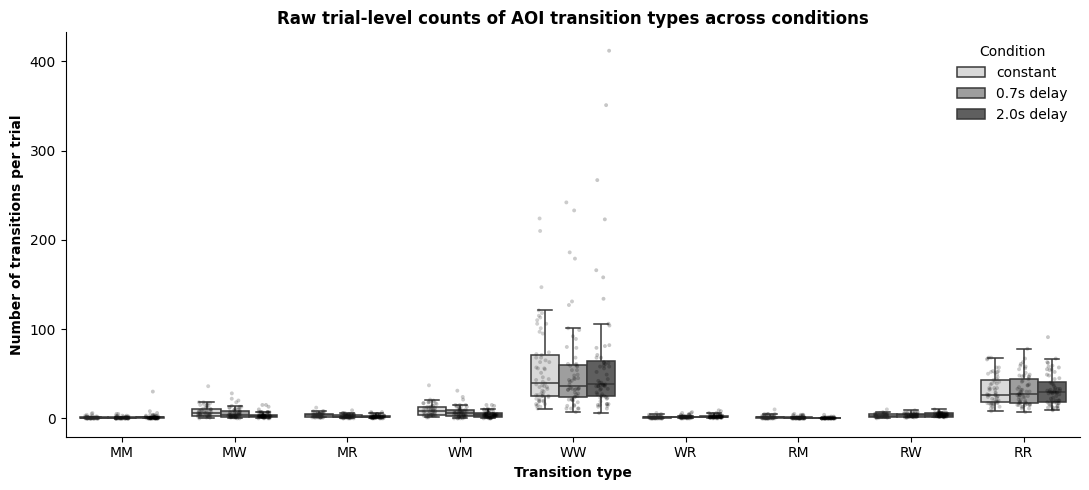

In [208]:
# =======================================================
# PLOT 1: RAW TRIAL-LEVEL TRANSITION TYPE COUNTS
# =======================================================

import seaborn as sns
import matplotlib.pyplot as plt

TRANSITION_ORDER = ["MM", "MW", "MR", "WM", "WW", "WR", "RM", "RW", "RR"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_raw_transitions = transition_counts_per_trial.copy()

plot_raw_transitions["condition"] = (
    plot_raw_transitions["condition"]
    .astype(str)
)

plot_raw_transitions["transition_type"] = (
    plot_raw_transitions["transition_type"]
    .astype(str)
)

plt.figure(figsize=(11, 5))

sns.boxplot(
    data=plot_raw_transitions,
    x="transition_type",
    y="n_transitions",
    hue="condition",
    order=TRANSITION_ORDER,
    hue_order=COND_ORDER,
    palette=COND_COLORS,
    showfliers=False,
    width=0.75,
    linewidth=1.1
)

sns.stripplot(
    data=plot_raw_transitions,
    x="transition_type",
    y="n_transitions",
    hue="condition",
    order=TRANSITION_ORDER,
    hue_order=COND_ORDER,
    dodge=True,
    color="black",
    alpha=0.22,
    size=2.8,
    jitter=0.18
)

plt.xlabel("Transition type", fontweight="bold")
plt.ylabel("Number of transitions per trial", fontweight="bold")
plt.title(
    "Raw trial-level counts of AOI transition types across conditions",
    fontweight="bold"
)

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[:len(COND_ORDER)],
    labels[:len(COND_ORDER)],
    title="Condition",
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

RAW TRANSITION-TYPE COUNTS
Number of rows: 1620
Number of negative counts: 0
Number of zero counts: 277
Percentage of zero counts: 17.1 %

Rows per Transition Type and Condition:


condition,constant,0.7s delay,2.0s delay
transition_type,,,
MM,60,60,60
MW,60,60,60
MR,60,60,60
WM,60,60,60
WW,60,60,60
WR,60,60,60
RM,60,60,60
RW,60,60,60
RR,60,60,60



SHAPIRO-WILK BY TRANSITION TYPE
Conditions pooled


,Transition type,N,Mean,Median,Variance,Variance/Mean,Zero percentage,Skewness,Shapiro W,Shapiro p
0,MM,180,1.0333,0.0,6.6134,6.4001,56.1111,8.3593,0.3684,0.0
1,MW,180,5.7889,4.0,28.8267,4.9797,3.8889,2.1076,0.8021,0.0
2,MR,180,2.7944,2.0,4.2648,1.5262,7.2222,1.0336,0.9045,0.0
3,WM,180,7.0000,5.0,34.5922,4.9417,5.5556,1.6665,0.8669,0.0
4,WW,180,58.7944,38.0,3494.9687,59.4439,0.0000,2.9269,0.6903,0.0
5,WR,180,1.7389,1.0,2.6074,1.4995,18.8889,1.6555,0.8250,0.0
6,RM,180,0.8556,0.0,2.1913,2.5613,61.6667,2.4670,0.6368,0.0
7,RW,180,3.6778,4.0,3.5604,0.9681,0.5556,0.6812,0.9178,0.0
8,RR,180,31.9556,28.5,277.7299,8.6911,0.0000,0.8106,0.9319,0.0



SHAPIRO-WILK BY TRANSITION TYPE × CONDITION


N     Mean  Median  Zero percentage  Skewness  \
Transition type Condition                                                    
MM              constant    60   0.7833     0.0          58.3333    2.2418   
                0.7s delay  60   0.7500     0.0          61.6667    1.9049   
                2.0s delay  60   1.5667     1.0          48.3333    6.0797   
MW              constant    60   7.5167     5.5           1.6667    2.0854   
                0.7s delay  60   6.1000     4.0           3.3333    1.7611   
                2.0s delay  60   3.7500     3.0           6.6667    1.8571   
MR              constant    60   3.7667     4.0           0.0000    0.8699   
                0.7s delay  60   2.5667     2.0          10.0000    0.8656   
                2.0s delay  60   2.0500     1.5          11.6667    1.1798   
WM              constant    60   9.3667     8.0           0.0000    1.4740   
                0.7s delay  60   7.0667     6.0           8.3333    1.6266   
                2.0s delay  60   4.5667     4.0           8.3333    1.1512   
WW              constant    60  56.7000    40.0           0.0000    1.7659   
                0.7s delay  60  54.5000    36.0           0.0000    2.2239   
                2.0s delay  60  65.1833    38.0           0.0000    2.9717   
WR              constant    60   1.1000     1.0          38.3333    1.6997   
                0.7s delay  60   1.8000     1.5          13.3333    1.5592   
                2.0s delay  60   2.3167     2.0           5.0000    1.6729   
RM              constant    60   1.4333     1.0          45.0000    1.9767   
                0.7s delay  60   0.8167     0.0          63.3333    1.6387   
                2.0s delay  60   0.3167     0.0          76.6667    3.1349   
RW              constant    60   3.4333     3.0           1.6667    0.7777   
                0.7s delay  60   3.5500     4.0           0.0000    0.6466   
                2.0s delay  60   4.0500     4.0           0.0000    0.6304   
RR              constant    60  32.0833    26.5           0.0000    0.6796   
                0.7s delay  60  31.8333    27.5           0.0000    0.7505   
                2.0s delay  60  31.9500    29.0           0.0000    1.0015   

                            Shapiro W  Shapiro p  
Transition type Condition                         
MM              constant       0.6628     0.0000  
                0.7s delay     0.6711     0.0000  
                2.0s delay     0.3658     0.0000  
MW              constant       0.8250     0.0000  
                0.7s delay     0.8163     0.0000  
                2.0s delay     0.7835     0.0000  
MR              constant       0.9024     0.0002  
                0.7s delay     0.9209     0.0008  
                2.0s delay     0.8648     0.0000  
WM              constant       0.8824     0.0000  
                0.7s delay     0.8682     0.0000  
                2.0s delay     0.8898     0.0001  
WW              constant       0.8156     0.0000  
                0.7s delay     0.7374     0.0000  
                2.0s delay     0.6221     0.0000  
WR              constant       0.7854     0.0000  
                0.7s delay     0.8133     0.0000  
                2.0s delay     0.8232     0.0000  
RM              constant       0.7501     0.0000  
                0.7s delay     0.6613     0.0000  
                2.0s delay     0.5068     0.0000  
RW              constant       0.9285     0.0017  
                0.7s delay     0.9021     0.0002  
                2.0s delay     0.8933     0.0001  
RR              constant       0.9256     0.0013  
                0.7s delay     0.9339     0.0029  
                2.0s delay     0.9162     0.0005

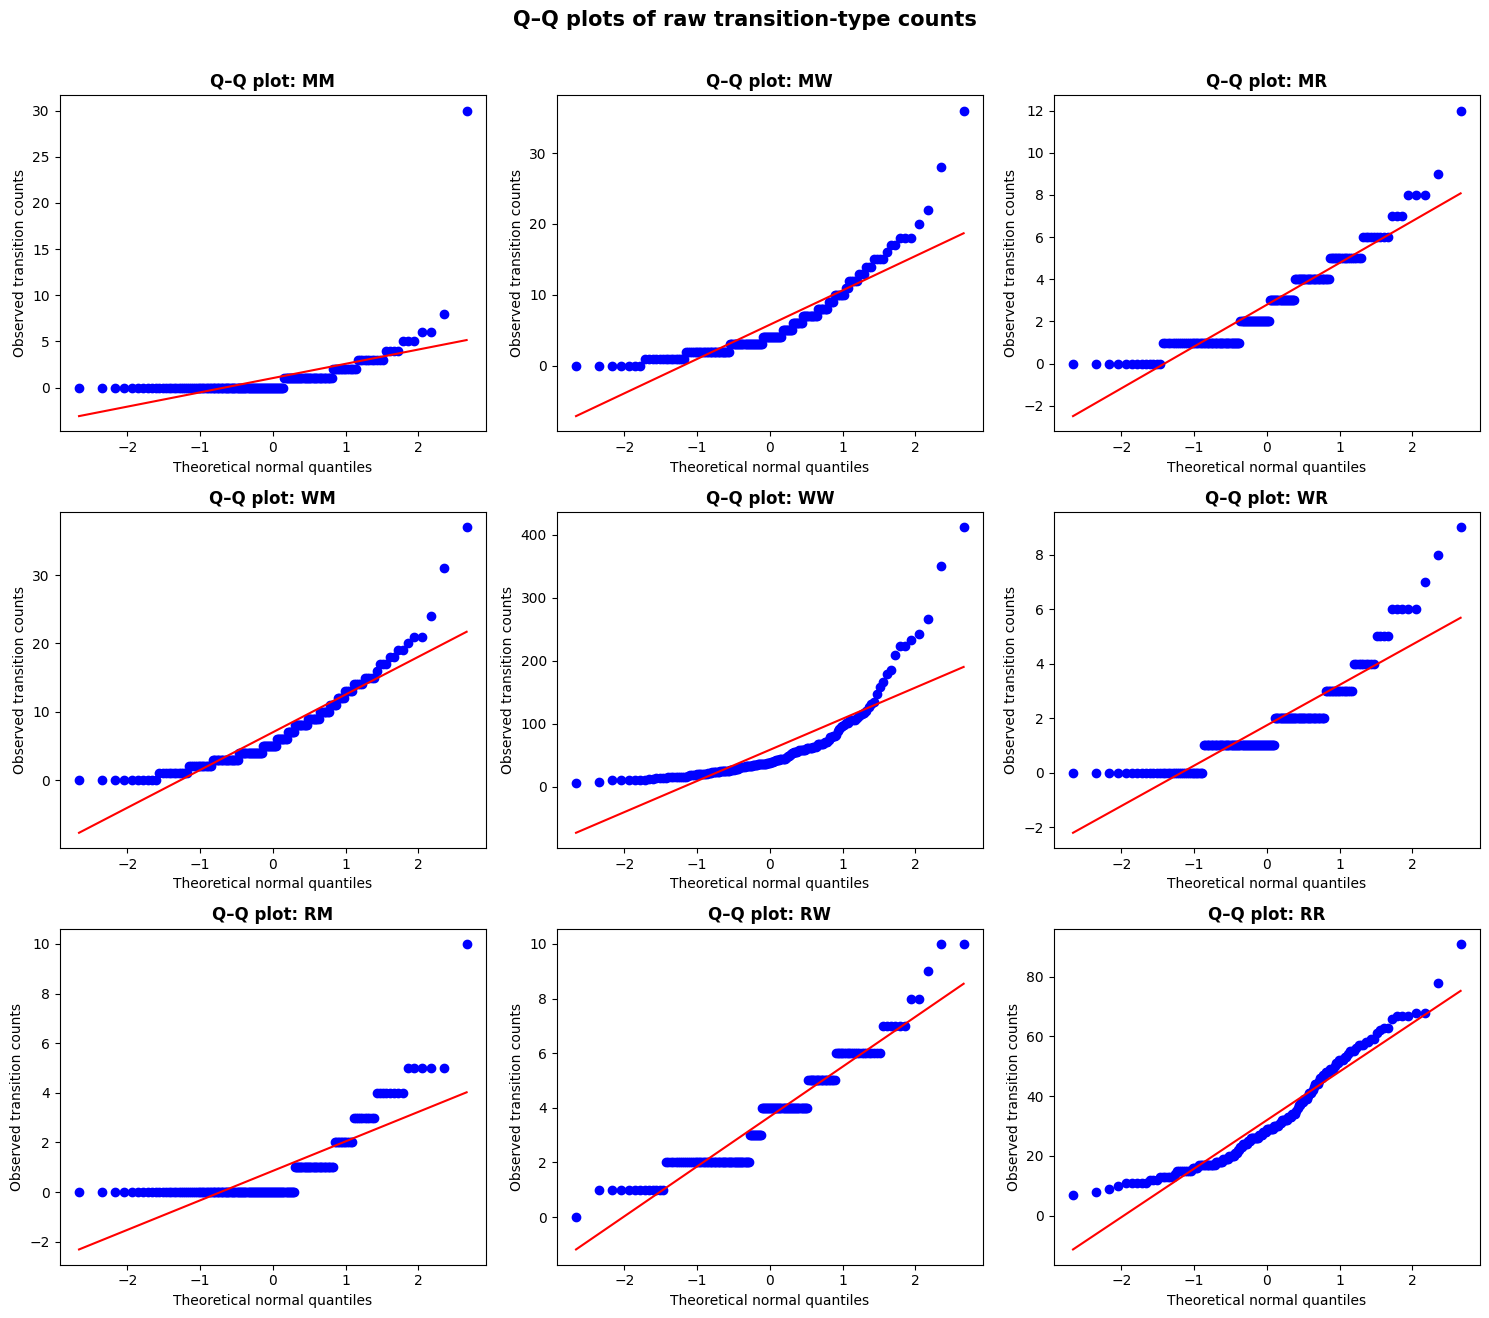

In [289]:
# =======================================================
# NORMALITY CHECK:
# RAW TRIAL-LEVEL TRANSITION-TYPE COUNTS
# =======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import shapiro, skew

TRANSITION_ORDER = [
    "MM", "MW", "MR",
    "WM", "WW", "WR",
    "RM", "RW", "RR"
]

COND_ORDER = [
    "constant",
    "0.7s delay",
    "2.0s delay"
]

# =======================================================
# 1. PREPARE DATA
# =======================================================

transition_distribution = (
    transition_counts_per_trial[
        ["condition", "transition_type", "n_transitions"]
    ]
    .dropna()
    .copy()
)

transition_distribution["condition"] = (
    transition_distribution["condition"]
    .astype(str)
)

transition_distribution["transition_type"] = (
    transition_distribution["transition_type"]
    .astype(str)
)

transition_distribution = transition_distribution[
    transition_distribution["condition"].isin(COND_ORDER)
    & transition_distribution["transition_type"].isin(TRANSITION_ORDER)
].copy()

print("=" * 70)
print("RAW TRANSITION-TYPE COUNTS")
print("=" * 70)

print("Number of rows:", len(transition_distribution))
print(
    "Number of negative counts:",
    (transition_distribution["n_transitions"] < 0).sum()
)

print(
    "Number of zero counts:",
    (transition_distribution["n_transitions"] == 0).sum()
)

print(
    "Percentage of zero counts:",
    round(
        100 * (
            transition_distribution["n_transitions"] == 0
        ).mean(),
        2
    ),
    "%"
)

print("\nRows per Transition Type and Condition:")

display(
    transition_distribution
    .groupby(
        ["transition_type", "condition"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=TRANSITION_ORDER,
        columns=COND_ORDER
    )
)

# =======================================================
# 2. SHAPIRO-WILK BY TRANSITION TYPE
# Conditions pooled
# =======================================================

type_results = []

for transition_type in TRANSITION_ORDER:

    values = transition_distribution.loc[
        transition_distribution["transition_type"]
        == transition_type,
        "n_transitions"
    ]

    # Shapiro cannot be interpreted with no variation
    if len(values) >= 3 and values.nunique() > 1:
        W, p = shapiro(values)
        skewness = skew(values, bias=False)
    else:
        W = np.nan
        p = np.nan
        skewness = np.nan

    mean_value = values.mean()
    variance_value = values.var()

    type_results.append(
        {
            "Transition type": transition_type,
            "N": len(values),
            "Mean": mean_value,
            "Median": values.median(),
            "Variance": variance_value,
            "Variance/Mean": (
                variance_value / mean_value
                if mean_value > 0
                else np.nan
            ),
            "Zero percentage": (
                100 * (values == 0).mean()
            ),
            "Skewness": skewness,
            "Shapiro W": W,
            "Shapiro p": p
        }
    )

type_normality = pd.DataFrame(type_results)

print("\n" + "=" * 70)
print("SHAPIRO-WILK BY TRANSITION TYPE")
print("Conditions pooled")
print("=" * 70)

display(type_normality.round(4))

# =======================================================
# 3. SHAPIRO-WILK BY TYPE × CONDITION
# =======================================================

cell_results = []

for transition_type in TRANSITION_ORDER:
    for condition in COND_ORDER:

        values = transition_distribution.loc[
            (
                transition_distribution["transition_type"]
                == transition_type
            )
            & (
                transition_distribution["condition"]
                == condition
            ),
            "n_transitions"
        ]

        if len(values) >= 3 and values.nunique() > 1:
            W, p = shapiro(values)
            skewness = skew(values, bias=False)
        else:
            W = np.nan
            p = np.nan
            skewness = np.nan

        cell_results.append(
            {
                "Transition type": transition_type,
                "Condition": condition,
                "N": len(values),
                "Mean": values.mean(),
                "Median": values.median(),
                "Zero percentage": (
                    100 * (values == 0).mean()
                ),
                "Skewness": skewness,
                "Shapiro W": W,
                "Shapiro p": p
            }
        )

cell_normality = pd.DataFrame(cell_results)

print("\n" + "=" * 70)
print("SHAPIRO-WILK BY TRANSITION TYPE × CONDITION")
print("=" * 70)

display(
    cell_normality
    .set_index(
        ["Transition type", "Condition"]
    )
    .round(4)
)

# =======================================================
# 4. Q-Q PLOTS BY TRANSITION TYPE
# Conditions pooled
# =======================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 13)
)

axes = axes.flatten()

for axis, transition_type in zip(
    axes,
    TRANSITION_ORDER
):

    values = transition_distribution.loc[
        transition_distribution["transition_type"]
        == transition_type,
        "n_transitions"
    ]

    stats.probplot(
        values,
        dist="norm",
        plot=axis
    )

    axis.set_title(
        f"Q–Q plot: {transition_type}",
        fontweight="bold"
    )

    axis.set_xlabel(
        "Theoretical normal quantiles"
    )

    axis.set_ylabel(
        "Observed transition counts"
    )

plt.suptitle(
    "Q–Q plots of raw transition-type counts",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

## Making a conigency table for Ch2 test

In [362]:
# Contingency table: Rows = transition_type, Columns = condition
# Values = absolute frequency (number of individual transitions)

contingency_table = pd.crosstab(
    transition_events["transition_type"],
    transition_events["condition"]
)

# make sure order is correcct
contingency_table = contingency_table.reindex(
    index=TRANSITION_ORDER,
    columns=COND_ORDER
)

print(contingency_table)

condition        constant  0.7s delay  2.0s delay
transition_type                                  
MM                     47          45          94
MW                    451         366         225
MR                    226         154         123
WM                    562         424         274
WW                   3402        3270        3911
WR                     66         108         139
RM                     86          49          19
RW                    206         213         243
RR                   1925        1910        1917


### CHi 2

In [363]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"χ² = {chi2:.2f}, df = {dof}, p = {p:.4f}")

# Erwartete Häufigkeiten checken (Faustregel: alle >= 5)
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)
print(expected_df)
print("Zellen mit erwarteter Häufigkeit < 5:", (expected_df < 5).sum().sum())

χ² = 346.80, df = 16, p = 0.0000
condition           constant   0.7s delay   2.0s delay
transition_type                                       
MM                 63.388218    59.459985    63.151797
MW                355.110340   333.103789   353.785871
MR                171.420826   160.797702   170.781472
WM                429.404058   402.793449   427.802493
WW               3606.653288  3383.145295  3593.201418
WR                106.669421   100.059008   106.271572
RM                 52.482718    49.230310    52.286971
RW                225.607529   211.626399   224.766072
RR               1960.263603  1838.784063  1952.952334
Zellen mit erwarteter Häufigkeit < 5: 0


## Residues

In [364]:
residuals = (contingency_table - expected_df) / np.sqrt(expected_df)
print(residuals.round(2))

condition        constant  0.7s delay  2.0s delay
transition_type                                  
MM                  -2.06       -1.88        3.88
MW                   5.09        1.80       -6.85
MR                   4.17       -0.54       -3.66
WM                   6.40        1.06       -7.44
WW                  -3.41       -1.95        5.30
WR                  -3.94        0.79        3.17
RM                   4.63       -0.03       -4.60
RW                  -1.31        0.09        1.22
RR                  -0.80        1.66       -0.81


## Cramers V for effect sizeee!

In [365]:
# Cramér's V (effect size for chi-square test of independence)

n = contingency_table.values.sum()          # total number of transitions
k = min(contingency_table.shape) - 1        # min(rows, cols) - 1

cramers_v = np.sqrt(chi2 / (n * k))

print(f"N = {n}")
print(f"Cramér's V = {cramers_v:.3f}")

N = 20455
Cramér's V = 0.092


### Residues

In [ ]:
# 5) Residues (Post-hoc, to see WHICH Cells fdirve the effect)
residuals = (contingency_table - expected_df) / np.sqrt(expected_df)
print(residuals.round(2))

condition        constant  0.7s delay  2.0s delay
transition_type                                  
MM                  -2.06       -1.88        3.88
MW                   5.09        1.80       -6.85
MR                   4.17       -0.54       -3.66
WM                   6.40        1.06       -7.44
WW                  -3.41       -1.95        5.30
WR                  -3.94        0.79        3.17
RM                   4.63       -0.03       -4.60
RW                  -1.31        0.09        1.22
RR                  -0.80        1.66       -0.81


In [209]:
# =======================================================
# 4) BUILD PARTICIPANT-LEVEL TRANSITION TYPE COUNTS
# =======================================================

transition_counts_participant_avg = transition_counts_per_trial.copy()

# Convert categoricals to strings before groupby
transition_counts_participant_avg["condition"] = (
    transition_counts_participant_avg["condition"]
    .astype(str)
)

transition_counts_participant_avg["transition_type"] = (
    transition_counts_participant_avg["transition_type"]
    .astype(str)
)

transition_counts_participant_avg = (
    transition_counts_participant_avg
    .groupby(
        ["participant_id", "condition", "transition_type"],
        as_index=False
    )
    .agg(
        mean_n_transitions=("n_transitions", "mean"),
        n_trials=("model_name", "nunique")
    )
)

transition_counts_participant_avg["condition"] = pd.Categorical(
    transition_counts_participant_avg["condition"],
    categories=COND_ORDER,
    ordered=True
)

transition_counts_participant_avg["transition_type"] = pd.Categorical(
    transition_counts_participant_avg["transition_type"],
    categories=TRANSITION_ORDER,
    ordered=True
)

transition_counts_participant_avg = (
    transition_counts_participant_avg
    .sort_values(["transition_type", "condition", "participant_id"])
    .reset_index(drop=True)
)

display(transition_counts_participant_avg.head(40))

print("Participants per transition type and condition:")
display(
    transition_counts_participant_avg
    .groupby(["transition_type", "condition"], observed=False)["participant_id"]
    .nunique()
)

,participant_id,condition,transition_type,mean_n_transitions,n_trials
0,1,constant,MM,0.333333,6
1,10,constant,MM,0.500000,6
2,2,constant,MM,1.833333,6
3,3,constant,MM,2.000000,6
4,4,constant,MM,0.333333,6
5,5,constant,MM,1.000000,6
6,6,constant,MM,0.333333,6
7,7,constant,MM,0.500000,6
8,8,constant,MM,1.000000,6
9,9,constant,MM,0.000000,6


Participants per transition type and condition:


transition_type  condition 
MM               constant      10
                 0.7s delay    10
                 2.0s delay    10
MW               constant      10
                 0.7s delay    10
                 2.0s delay    10
MR               constant      10
                 0.7s delay    10
                 2.0s delay    10
WM               constant      10
                 0.7s delay    10
                 2.0s delay    10
WW               constant      10
                 0.7s delay    10
                 2.0s delay    10
WR               constant      10
                 0.7s delay    10
                 2.0s delay    10
RM               constant      10
                 0.7s delay    10
                 2.0s delay    10
RW               constant      10
                 0.7s delay    10
                 2.0s delay    10
RR               constant      10
                 0.7s delay    10
                 2.0s delay    10
Name: participant_id, dtype: int64

### Group summary

In [210]:
# =======================================================
# 5) BUILD GROUP SUMMARY FOR TRANSITION TYPE COUNTS
# =======================================================

transition_type_group_summary = transition_counts_participant_avg.copy()

transition_type_group_summary["condition"] = (
    transition_type_group_summary["condition"]
    .astype(str)
)

transition_type_group_summary["transition_type"] = (
    transition_type_group_summary["transition_type"]
    .astype(str)
)

transition_type_group_summary = (
    transition_type_group_summary
    .groupby(
        ["condition", "transition_type"],
        as_index=False
    )
    .agg(
        mean_n_transitions=("mean_n_transitions", "mean"),
        sd_n_transitions=("mean_n_transitions", "std"),
        n_participants=("participant_id", "nunique")
    )
)

transition_type_group_summary["se_n_transitions"] = (
    transition_type_group_summary["sd_n_transitions"] /
    np.sqrt(transition_type_group_summary["n_participants"])
)

transition_type_group_summary["condition"] = pd.Categorical(
    transition_type_group_summary["condition"],
    categories=COND_ORDER,
    ordered=True
)

transition_type_group_summary["transition_type"] = pd.Categorical(
    transition_type_group_summary["transition_type"],
    categories=TRANSITION_ORDER,
    ordered=True
)

transition_type_group_summary = (
    transition_type_group_summary
    .sort_values(["transition_type", "condition"])
    .reset_index(drop=True)
)

display(transition_type_group_summary)

,condition,transition_type,mean_n_transitions,sd_n_transitions,n_participants,se_n_transitions
0,constant,MM,0.783333,0.671510,10,0.212350
1,0.7s delay,MM,0.750000,0.394796,10,0.124846
2,2.0s delay,MM,1.566667,1.924822,10,0.608682
3,constant,MW,7.516667,3.127388,10,0.988967
4,0.7s delay,MW,6.100000,2.325649,10,0.735435
5,2.0s delay,MW,3.750000,1.296362,10,0.409946
6,constant,MR,3.766667,0.828505,10,0.261996
7,0.7s delay,MR,2.566667,0.896495,10,0.283497
8,2.0s delay,MR,2.050000,0.773999,10,0.244760
9,constant,WM,9.366667,3.108928,10,0.983129


In [211]:
# =======================================================
# 6) CREATE MEAN ± SE TABLE FOR TRANSITION TYPES
# =======================================================

transition_type_table = transition_type_group_summary.copy()

transition_type_table["mean_se"] = (
    transition_type_table["mean_n_transitions"].round(2).astype(str) +
    " ± " +
    transition_type_table["se_n_transitions"].round(2).astype(str)
)

transition_type_table_wide = (
    transition_type_table
    .pivot(
        index="condition",
        columns="transition_type",
        values="mean_se"
    )
    .reindex(COND_ORDER)
    [TRANSITION_ORDER]
)

display(transition_type_table_wide)

transition_type,MM,MW,MR,WM,WW,WR,RM,RW,RR
condition,,,,,,,,,
constant,0.78 ± 0.21,7.52 ± 0.99,3.77 ± 0.26,9.37 ± 0.98,56.7 ± 6.13,1.1 ± 0.22,1.43 ± 0.36,3.43 ± 0.29,32.08 ± 1.87
0.7s delay,0.75 ± 0.12,6.1 ± 0.74,2.57 ± 0.28,7.07 ± 0.78,54.5 ± 7.21,1.8 ± 0.29,0.82 ± 0.25,3.55 ± 0.25,31.83 ± 2.05
2.0s delay,1.57 ± 0.61,3.75 ± 0.41,2.05 ± 0.24,4.57 ± 0.44,65.18 ± 12.84,2.32 ± 0.29,0.32 ± 0.16,4.05 ± 0.2,31.95 ± 2.12


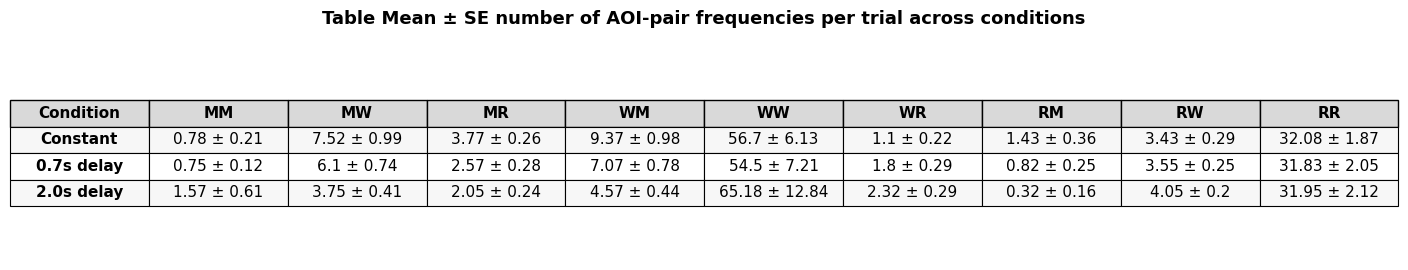

In [212]:
# =======================================================
# 7) EXPORT TRANSITION TABLE AS THESIS-READY IMAGE
# =======================================================

import matplotlib.pyplot as plt

# Make a copy
table_plot_df = transition_type_table_wide.copy()

# Optional: prettier row labels
table_plot_df = table_plot_df.rename(
    index={
        "constant": "Constant",
        "0.7s delay": "0.7s delay",
        "2.0s delay": "2.0s delay"
    }
)

# Reset index so condition becomes first column
table_plot_df = table_plot_df.reset_index()
table_plot_df = table_plot_df.rename(columns={"condition": "Condition"})

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 2.8))
ax.axis("off")

# Build table
tbl = ax.table(
    cellText=table_plot_df.values,
    colLabels=table_plot_df.columns,
    loc="center",
    cellLoc="center"
)

# -----------------------------
# Styling
# -----------------------------
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.15, 1.6)

# Header styling
for col in range(len(table_plot_df.columns)):
    cell = tbl[(0, col)]
    cell.set_facecolor("#d9d9d9")
    cell.set_text_props(weight="bold", color="black")
    cell.set_edgecolor("black")
    cell.set_linewidth(1.0)

# Body styling
n_rows = len(table_plot_df)
n_cols = len(table_plot_df.columns)

for row in range(1, n_rows + 1):
    for col in range(n_cols):
        cell = tbl[(row, col)]
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)

        # light alternating row shading
        if row % 2 == 1:
            cell.set_facecolor("#f7f7f7")
        else:
            cell.set_facecolor("white")

        # make first column slightly emphasized
        if col == 0:
            cell.set_text_props(weight="bold")

# Title
plt.title(
    "Table Mean ± SE number of AOI-pair frequencies per trial across conditions",
    fontsize=13,
    fontweight="bold",
    pad=16
)

plt.tight_layout()

# Save image
plt.savefig(
    "transition_type_table_thesis.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

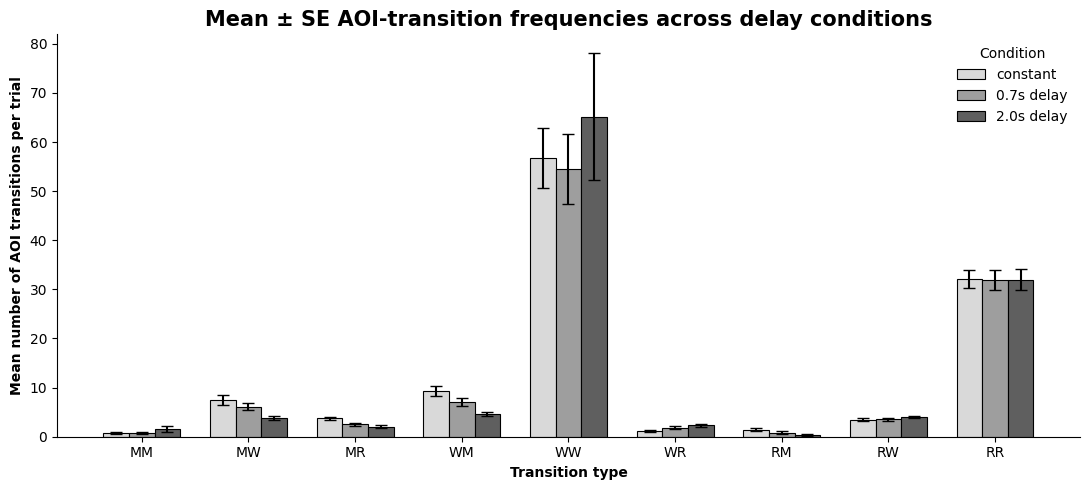

In [213]:
# =======================================================
# BARPLOT: AOI TRANSITION TYPE FREQUENCIES
# Participant-averaged means with SE error bars
# =======================================================

import numpy as np
import matplotlib.pyplot as plt

TRANSITION_ORDER = ["MM", "MW", "MR", "WM", "WW", "WR", "RM", "RW", "RR"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_data = transition_type_group_summary.copy()

plot_data["condition"] = plot_data["condition"].astype(str)
plot_data["transition_type"] = plot_data["transition_type"].astype(str)

x = np.arange(len(TRANSITION_ORDER))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(11, 5))

for i, cond in enumerate(COND_ORDER):
    sub = (
        plot_data
        .loc[plot_data["condition"] == cond]
        .set_index("transition_type")
        .reindex(TRANSITION_ORDER)
    )

    ax.bar(
        x + (i - 1) * bar_width,
        sub["mean_n_transitions"],
        width=bar_width,
        yerr=sub["se_n_transitions"],
        capsize=4,
        color=COND_COLORS[cond],
        edgecolor="black",
        linewidth=0.8,
        label=cond
    )

ax.set_xticks(x)
ax.set_xticklabels(TRANSITION_ORDER)

ax.set_xlabel("Transition type", fontweight="bold")
ax.set_ylabel("Mean number of AOI transitions per trial", fontweight="bold")

ax.set_title(
    "Mean ± SE AOI-transition frequencies across delay conditions",
    fontweight="bold",
    fontsize=15
)

ax.legend(title="Condition", frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

### Transition probability matrix

In [214]:
# =======================================================
# 8) BUILD TRANSITION PROBABILITY MATRIX DATA
# =======================================================
# Goal:
# Compute P(to AOI | from AOI) for each condition.
#
# Based on saccade-like AOI-pair transitions:
# previous AOI -> current AOI

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

# -------------------------------------------------------
# Make copy of transition events
# -------------------------------------------------------

transition_prob_data = transition_events.copy()

# Make sure relevant columns are clean strings
transition_prob_data["condition"] = (
    transition_prob_data["condition"]
    .astype(str)
    .str.strip()
)

transition_prob_data["from_AOI"] = (
    transition_prob_data["prev_AOI_CLEAN"]
    .astype(str)
    .str.strip()
    .str.upper()
)

transition_prob_data["to_AOI"] = (
    transition_prob_data["AOI_CLEAN"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Keep only task AOIs and valid conditions
transition_prob_data = transition_prob_data[
    transition_prob_data["condition"].isin(COND_ORDER)
    &
    transition_prob_data["from_AOI"].isin(AOI_ORDER)
    &
    transition_prob_data["to_AOI"].isin(AOI_ORDER)
].copy()

# -------------------------------------------------------
# Count transitions per participant × condition × from_AOI × to_AOI
# -------------------------------------------------------

transition_counts_pc = (
    transition_prob_data
    .groupby(
        ["participant_id", "condition", "from_AOI", "to_AOI"],
        as_index=False
    )
    .agg(
        n_transitions=("to_AOI", "count")
    )
)

# -------------------------------------------------------
# Complete missing from-to combinations with 0
# -------------------------------------------------------

participant_condition_index = (
    transition_prob_data[
        ["participant_id", "condition"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

from_to_index = (
    pd.MultiIndex
    .from_product(
        [AOI_ORDER, AOI_ORDER],
        names=["from_AOI", "to_AOI"]
    )
    .to_frame(index=False)
)

complete_index = participant_condition_index.merge(
    from_to_index,
    how="cross"
)

transition_counts_pc = complete_index.merge(
    transition_counts_pc,
    on=["participant_id", "condition", "from_AOI", "to_AOI"],
    how="left"
)

transition_counts_pc["n_transitions"] = (
    transition_counts_pc["n_transitions"]
    .fillna(0)
    .astype(int)
)

# -------------------------------------------------------
# Compute row totals and transition probabilities
# -------------------------------------------------------
# For each participant, condition, and from_AOI:
# probability = count from_AOI -> to_AOI / all outgoing transitions from from_AOI

transition_counts_pc["row_total"] = (
    transition_counts_pc
    .groupby(
        ["participant_id", "condition", "from_AOI"]
    )["n_transitions"]
    .transform("sum")
)

transition_counts_pc["transition_probability"] = np.where(
    transition_counts_pc["row_total"] > 0,
    transition_counts_pc["n_transitions"] / transition_counts_pc["row_total"],
    np.nan
)

# -------------------------------------------------------
# Average probabilities across participants
# -------------------------------------------------------

transition_probability_group = (
    transition_counts_pc
    .groupby(
        ["condition", "from_AOI", "to_AOI"],
        as_index=False
    )
    .agg(
        mean_transition_probability=("transition_probability", "mean"),
        sd_transition_probability=("transition_probability", "std"),
        n_participants=("transition_probability", "count")
    )
)

transition_probability_group["se_transition_probability"] = (
    transition_probability_group["sd_transition_probability"] /
    np.sqrt(transition_probability_group["n_participants"])
)

# Restore categorical ordering
transition_probability_group["condition"] = pd.Categorical(
    transition_probability_group["condition"],
    categories=COND_ORDER,
    ordered=True
)

transition_probability_group["from_AOI"] = pd.Categorical(
    transition_probability_group["from_AOI"],
    categories=AOI_ORDER,
    ordered=True
)

transition_probability_group["to_AOI"] = pd.Categorical(
    transition_probability_group["to_AOI"],
    categories=AOI_ORDER,
    ordered=True
)

transition_probability_group = (
    transition_probability_group
    .sort_values(["condition", "from_AOI", "to_AOI"])
    .reset_index(drop=True)
)

display(transition_probability_group)

,condition,from_AOI,to_AOI,mean_transition_probability,sd_transition_probability,n_participants,se_transition_probability
0,constant,MODEL,MODEL,0.059460,0.044090,10,0.013942
1,constant,MODEL,WORK,0.618560,0.060534,10,0.019142
2,constant,MODEL,RESOURCE,0.321980,0.049975,10,0.015804
3,constant,WORK,MODEL,0.143600,0.036504,10,0.011544
4,constant,WORK,WORK,0.838108,0.042402,10,0.013409
5,constant,WORK,RESOURCE,0.018292,0.016371,10,0.005177
6,constant,RESOURCE,MODEL,0.041654,0.035486,10,0.011222
7,constant,RESOURCE,WORK,0.092516,0.019778,10,0.006254
8,constant,RESOURCE,RESOURCE,0.865829,0.026015,10,0.008227
9,0.7s delay,MODEL,MODEL,0.078130,0.043357,10,0.013711


#### Matrix tabelle anzeigen

In [215]:
# =======================================================
# 9) DISPLAY TRANSITION PROBABILITY MATRICES AS TABLES
# =======================================================

for cond in COND_ORDER:
    matrix = (
        transition_probability_group[
            transition_probability_group["condition"].astype(str) == cond
        ]
        .pivot(
            index="from_AOI",
            columns="to_AOI",
            values="mean_transition_probability"
        )
        .reindex(index=AOI_ORDER, columns=AOI_ORDER)
    )

    print(f"\nTransition probability matrix: {cond}")
    display(matrix.round(2))

    print("Row sums:")
    display(matrix.sum(axis=1).round(3))


Transition probability matrix: constant


to_AOI,MODEL,WORK,RESOURCE
from_AOI,,,
MODEL,0.06,0.62,0.32
WORK,0.14,0.84,0.02
RESOURCE,0.04,0.09,0.87


Row sums:


from_AOI
MODEL       1.0
WORK        1.0
RESOURCE    1.0
dtype: float64


Transition probability matrix: 0.7s delay


...

from_AOI
MODEL       1.0
WORK        1.0
RESOURCE    1.0
dtype: float64


Transition probability matrix: 2.0s delay


to_AOI,MODEL,WORK,RESOURCE
from_AOI,,,
MODEL,0.18,0.52,0.29
WORK,0.08,0.89,0.04
RESOURCE,0.01,0.11,0.88


Row sums:


from_AOI
MODEL       1.0
WORK        1.0
RESOURCE    1.0
dtype: float64

#### Heatmap

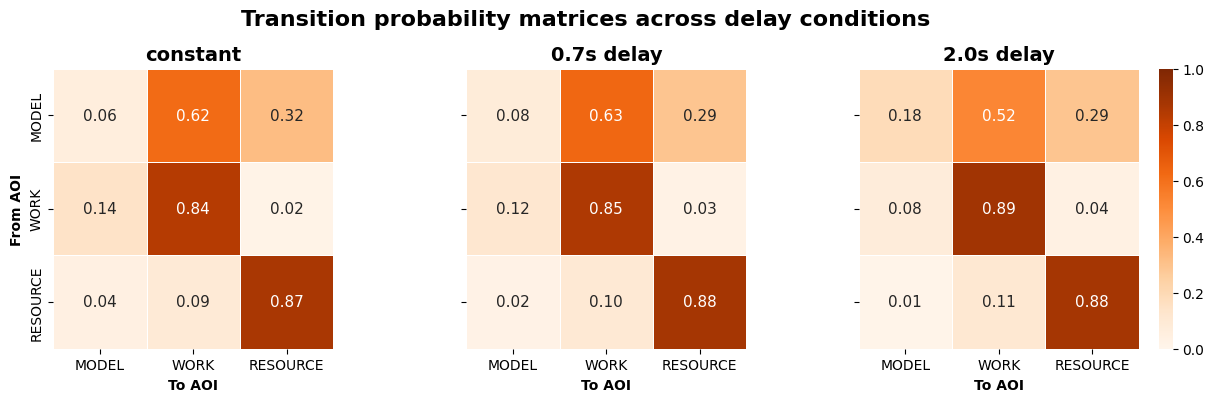

In [216]:
# =======================================================
# 10) PLOT TRANSITION PROBABILITY MATRICES
# =======================================================

import matplotlib.pyplot as plt
import seaborn as sns

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

fig, axes = plt.subplots(
    1,
    len(COND_ORDER),
    figsize=(13, 4),
    sharey=True
)

vmin = 0
vmax = 1

for ax, cond in zip(axes, COND_ORDER):

    matrix = (
        transition_probability_group[
            transition_probability_group["condition"].astype(str) == cond
        ]
        .pivot(
            index="from_AOI",
            columns="to_AOI",
            values="mean_transition_probability"
        )
        .reindex(index=AOI_ORDER, columns=AOI_ORDER)
    )

    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="Oranges",
        vmin=vmin,
        vmax=vmax,
        cbar=(ax == axes[-1]),
        square=True,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 11}
    )

    ax.set_title(cond, fontweight="bold", fontsize=14)
    ax.set_xlabel("To AOI", fontweight="bold")

    if ax == axes[0]:
        ax.set_ylabel("From AOI", fontweight="bold")
    else:
        ax.set_ylabel("")

fig.suptitle(
    "Transition probability matrices across delay conditions",
    fontweight="bold",
    fontsize=16
)

plt.tight_layout()
plt.show()
plt.close(fig)

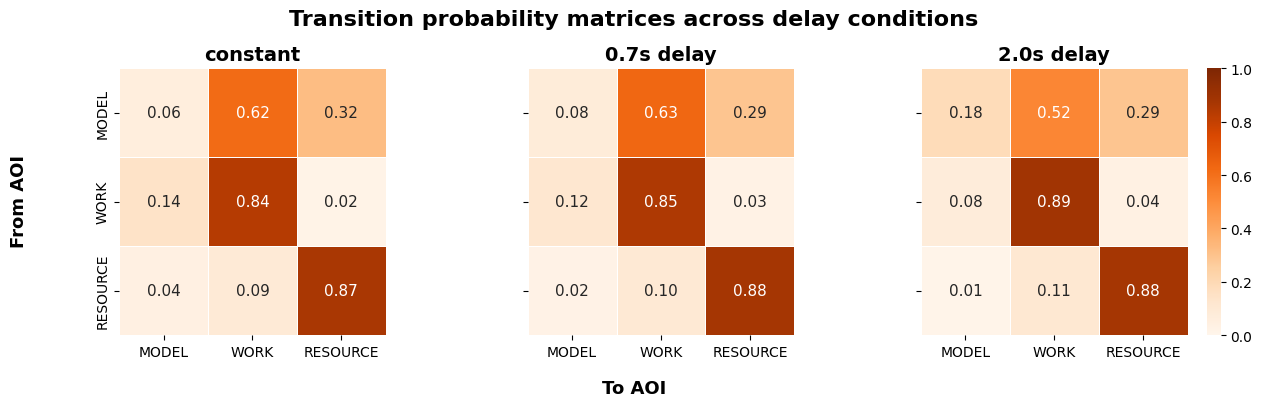

In [217]:
# =======================================================
# 10) PLOT TRANSITION PROBABILITY MATRICES
# =======================================================

import matplotlib.pyplot as plt
import seaborn as sns

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

fig, axes = plt.subplots(
    1,
    len(COND_ORDER),
    figsize=(13, 4),
    sharey=True
)

vmin = 0
vmax = 1

for ax, cond in zip(axes, COND_ORDER):

    matrix = (
        transition_probability_group[
            transition_probability_group["condition"].astype(str) == cond
        ]
        .pivot(
            index="from_AOI",
            columns="to_AOI",
            values="mean_transition_probability"
        )
        .reindex(index=AOI_ORDER, columns=AOI_ORDER)
    )

    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="Oranges",
        vmin=vmin,
        vmax=vmax,
        cbar=(ax == axes[-1]),
        square=True,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": 11}
    )

    ax.set_title(cond, fontweight="bold", fontsize=14)

    # Remove repeated axis labels
    ax.set_xlabel("")
    ax.set_ylabel("")

# One shared x- and y-axis label for the whole figure
fig.supxlabel("To AOI", fontweight="bold", fontsize=13)
fig.supylabel("From AOI", fontweight="bold", fontsize=13)

fig.suptitle(
    "Transition probability matrices across delay conditions",
    fontweight="bold",
    fontsize=16
)

plt.tight_layout()
plt.show()
plt.close(fig)

In [218]:
# =======================================================
# CHECK 1) ROW SUMS OF TRANSITION PROBABILITY MATRICES
# =======================================================

AOI_ORDER = ["MODEL", "WORK", "RESOURCE"]
COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

for cond in COND_ORDER:
    matrix = (
        transition_probability_group[
            transition_probability_group["condition"].astype(str) == cond
        ]
        .pivot(
            index="from_AOI",
            columns="to_AOI",
            values="mean_transition_probability"
        )
        .reindex(index=AOI_ORDER, columns=AOI_ORDER)
    )

    print(f"\nCondition: {cond}")
    display(matrix.round(3))

    print("Row sums:")
    display(matrix.sum(axis=1).round(3))


Condition: constant


to_AOI,MODEL,WORK,RESOURCE
from_AOI,,,
MODEL,0.059,0.619,0.322
WORK,0.144,0.838,0.018
RESOURCE,0.042,0.093,0.866


Row sums:


from_AOI
MODEL       1.0
WORK        1.0
RESOURCE    1.0
dtype: float64


Condition: 0.7s delay


...

from_AOI
MODEL       1.0
WORK        1.0
RESOURCE    1.0
dtype: float64


Condition: 2.0s delay


to_AOI,MODEL,WORK,RESOURCE
from_AOI,,,
MODEL,0.184,0.525,0.291
WORK,0.075,0.887,0.038
RESOURCE,0.010,0.113,0.877


Row sums:


from_AOI
MODEL       1.0
WORK        1.0
RESOURCE    1.0
dtype: float64

## extra checks

between_80_100 = object_gazes_final.loc[
    object_gazes_final["object_gaze_duration_ms"].between(
        80,
        100,
        inclusive="left"
    )
].copy()

display(
    between_80_100["AOI_CLEAN"]
    .value_counts(dropna=False)
    .rename("n_gazes")
)

model_added = between_80_100.loc[
    between_80_100["AOI_CLEAN"] == "MODEL"
]

print("Zusätzliche MODEL-Gazes:", len(model_added))
print(
    "Anteil MODEL unter zusätzlichen Gazes:",
    round(len(model_added) / len(between_80_100) * 100, 2),
    "%"
)

print(
    "Zusätzliche MODEL-Dwell-Time:",
    round(model_added["object_gaze_duration_ms"].sum() / 1000, 2),
    "Sekunden"
)

## Statistical inference : Transitiontypes 

In [219]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

transition_types = TRANSITION_ORDER
gee_results_list = []

for t_type in transition_types:
    # 1. Daten filtern
    df_sub = transition_counts_per_trial[
        transition_counts_per_trial["transition_type"] == t_type
    ].copy()

    df_sub = df_sub.sort_values("participant_id").reset_index(drop=True)

    df_sub["condition_cat"] = pd.Categorical(
        df_sub["condition"].astype(str), categories=COND_ORDER, ordered=False
    )

    # 2. GEE Poisson-Modell fit
    model = smf.gee(
        formula="n_transitions ~ C(condition_cat, Treatment(reference='constant'))",
        groups="participant_id",
        data=df_sub,
        family=sm.families.Poisson(),
        cov_struct=sm.cov_struct.Exchangeable(),
    )

    res = model.fit()

    # 3. Parameter extrahieren
    b_07 = res.params.get(
        "C(condition_cat, Treatment(reference='constant'))[T.0.7s delay]",
        np.nan,
    )
    p_07 = res.pvalues.get(
        "C(condition_cat, Treatment(reference='constant'))[T.0.7s delay]",
        np.nan,
    )
    irr_07 = np.exp(b_07)

    b_20 = res.params.get(
        "C(condition_cat, Treatment(reference='constant'))[T.2.0s delay]",
        np.nan,
    )
    p_20 = res.pvalues.get(
        "C(condition_cat, Treatment(reference='constant'))[T.2.0s delay]",
        np.nan,
    )
    irr_20 = np.exp(b_20)

    gee_results_list.append(
        {
            "Transition": t_type,
            "Beta (0.7s)": round(b_07, 3),
            "IRR (0.7s)": round(irr_07, 3),
            "p-val (0.7s)": round(p_07, 4),
            "Beta (2.0s)": round(b_20, 3),
            "IRR (2.0s)": round(irr_20, 3),
            "p-val (2.0s)": round(p_20, 4),
        }
    )

# 4. Ergebnistabelle erstellen & direkt ausgeben
df_gee_summary = pd.DataFrame(gee_results_list)

print(
    "========================================================================================="
)
print(
    "                    GEE RESULTS: SINGLE TRANSITION TYPES VS. CONSTANT                    "
)
print(
    "========================================================================================="
)
display(df_gee_summary)

                    GEE RESULTS: SINGLE TRANSITION TYPES VS. CONSTANT                    


,Transition,Beta (0.7s),IRR (0.7s),p-val (0.7s),Beta (2.0s),IRR (2.0s),p-val (2.0s)
0,MM,-0.043,0.957,0.8584,0.693,2.000,0.1094
1,MW,-0.209,0.812,0.0625,-0.695,0.499,0.0000
2,MR,-0.384,0.681,0.0000,-0.608,0.544,0.0000
3,WM,-0.282,0.754,0.0006,-0.718,0.488,0.0000
4,WW,-0.040,0.961,0.5588,0.139,1.150,0.3515
5,WR,0.492,1.636,0.0386,0.745,2.106,0.0002
6,RM,-0.563,0.570,0.0046,-1.510,0.221,0.0000
7,RW,0.033,1.034,0.6279,0.165,1.180,0.0495
8,RR,-0.008,0.992,0.8494,-0.004,0.996,0.9311


## Statistical inference: Global change

In [220]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Vorbereitung des DataFrames
df_interact = transition_counts_per_trial.copy()

# Referenzgruppen festlegen (Baseline Condition = constant, Referenz Transition = MM oder WW)
df_interact["condition_cat"] = pd.Categorical(
    df_interact["condition"].astype(str), categories=COND_ORDER, ordered=False
)

df_interact["transition_cat"] = pd.Categorical(
    df_interact["transition_type"].astype(str),
    categories=TRANSITION_ORDER,
    ordered=False,
)

# Sortieren nach Versuchsperson für GEE
df_interact = df_interact.sort_values("participant_id").reset_index(drop=True)

# 2. Großes Interaktions-GEE Modell anpassen
print("Passe globales Interaktionsmodell an (kann ein paar Sekunden dauern)...")
model_full = smf.gee(
    formula="n_transitions ~ C(condition_cat, Treatment(reference='constant')) * C(transition_cat, Treatment(reference='WW'))",
    groups="participant_id",
    data=df_interact,
    family=sm.families.Poisson(),
    cov_struct=sm.cov_struct.Exchangeable(),
)

res_full = model_full.fit()

# 3. Wald-Test für den Interaktionsterm berechnen
# Wir prüfen, ob ALLE Interaktions-Koeffizienten zusammen signifikant von 0 abweichen
interaction_terms = [
    param for param in res_full.params.index if ":" in param
]
wald_test = res_full.wald_test(interaction_terms)

print(
    "\n=============================================================================="
)
print(
    "            GLOBAL INTERACTION TEST: Condition x Transition Type              "
)
print(
    "=============================================================================="
)
print(f"Chi2-Statistik: {wald_test.statistic[0][0]:.3f}")
print(f"p-Wert der Interaktion: {wald_test.pvalue:.4e}")

if wald_test.pvalue < 0.05:
    print(
        "\n--> ERGEBNIS: Die Interaktion Condition x Transition Type ist HOCHSIGNIFIKANT!"
    )
    print(
        "    Das bestätigt global, dass die visuellen Kosten die Musterspezifik der Blicke verändern."
    )
else:
    print("\n--> ERGEBNIS: Keine globale Interaktion nachweisbar.")

Passe globales Interaktionsmodell an (kann ein paar Sekunden dauern)...

            GLOBAL INTERACTION TEST: Condition x Transition Type              
Chi2-Statistik: 382.223
p-Wert der Interaktion: 8.4736e-77

--> ERGEBNIS: Die Interaktion Condition x Transition Type ist HOCHSIGNIFIKANT!
    Das bestätigt global, dass die visuellen Kosten die Musterspezifik der Blicke verändern.


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 9
  warnings.warn('covariance of constraints does not have full '
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


# 3. Performance outcomes of strategy shift

# show columns

In [221]:
# =======================================================
# INSPECT COLUMN NAMES IN object_gazes_final
# =======================================================

print("Number of columns:")
print(len(object_gazes_final.columns))

print("\nAll column names:")
for i, col in enumerate(object_gazes_final.columns):
    print(f"{i:02d}: {col}")

Number of columns:
43

All column names:
00: participant_id
01: object_name
02: object_gaze_count
03: start_ms
04: end_ms
05: object_gaze_duration_ms
06: object_gaze_duration_s
07: hmd_position_x
08: hmd_position_y
09: hmd_position_z
10: hmd_rotation_x
11: hmd_rotation_y
12: hmd_rotation_z
13: hmd_rotation_w
14: gaze_forward_x
15: gaze_forward_y
16: gaze_forward_z
17: gaze_origin_x
18: gaze_origin_y
19: gaze_origin_z
20: is_valid_model
21: model_name
22: model_order
23: condition
24: gx
25: gy
26: gz
27: gaze_yaw_deg
28: gaze_pitch_deg
29: gaze_yaw_mean_deg
30: hmd_yaw_start_deg
31: hmd_yaw_mean_deg
32: hmd_yaw_start_deg_canon
33: hmd_yaw_mean_deg_canon
34: gaze_world_x
35: gaze_world_y
36: gaze_world_z
37: gaze_world_yaw_deg
38: gaze_world_pitch_deg
39: AOI
40: object_name_corr
41: OTHER_assigned_to
42: AOI_CLEAN


In [222]:
# =======================================================
# 1) SETUP FOR RAW OBSERVED TRIAL DURATION
# =======================================================
# Goal:
# Prepare the variables needed to compute one raw duration value per trial.
#
# Trial definition:
# participant_id + model_name + condition

import numpy as np
import pandas as pd

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

TRIAL_COLS = [
    "participant_id",
    "model_name",
    "condition"
]

RAW_DURATION_INPUT_COLS = TRIAL_COLS + [
    "is_valid_model",
    "start_ms",
    "end_ms"
]

print("Columns needed for raw observed trial duration:")
print(RAW_DURATION_INPUT_COLS)

missing_cols = [
    col for col in RAW_DURATION_INPUT_COLS
    if col not in object_gazes_final.columns
]

print("\nMissing columns:")
print(missing_cols)

Columns needed for raw observed trial duration:
['participant_id', 'model_name', 'condition', 'is_valid_model', 'start_ms', 'end_ms']

Missing columns:
[]


In [223]:
# =======================================================
# 2) COPY RELEVANT COLUMNS AND CLEAN TRIAL IDENTIFIERS
# =======================================================
# Goal:
# Create a working dataframe with only the columns needed for
# raw observed trial duration.
#
# We clean the trial identifiers so grouping does not fail because
# of whitespace or inconsistent string formatting.

trial_duration_sequence = object_gazes_final[RAW_DURATION_INPUT_COLS].copy()

# Clean trial identifier columns
for col in TRIAL_COLS:
    trial_duration_sequence[col] = (
        trial_duration_sequence[col]
        .astype(str)
        .str.strip()
    )

print("Working dataframe shape:")
print(trial_duration_sequence.shape)

display(trial_duration_sequence.head(10))

print("Condition counts before filtering:")
display(
    trial_duration_sequence["condition"]
    .value_counts(dropna=False)
)

Working dataframe shape:
(38406, 6)


,participant_id,model_name,condition,is_valid_model,start_ms,end_ms
0,1,nan,nan,False,1.754659e+12,1.754659e+12
1,1,nan,nan,False,1.754659e+12,1.754659e+12
2,1,nan,nan,False,1.754659e+12,1.754659e+12
3,1,nan,nan,False,1.754659e+12,1.754659e+12
4,1,nan,nan,False,1.754659e+12,1.754659e+12
5,1,nan,nan,False,1.754659e+12,1.754659e+12
6,1,nan,nan,False,1.754659e+12,1.754659e+12
7,1,nan,nan,False,1.754659e+12,1.754659e+12
8,1,nan,nan,False,1.754659e+12,1.754659e+12
9,1,nan,nan,False,1.754659e+12,1.754659e+12


Condition counts before filtering:


condition
nan           15565
2.0s delay     7777
constant       7749
0.7s delay     7315
Name: count, dtype: int64

#### sind timestamps schon numerisch?

In [224]:
print(trial_duration_sequence[["start_ms", "end_ms"]].dtypes)

start_ms    float64
end_ms      float64
dtype: object


### wie viele conditions sind in unserer condtion spalte?

In [225]:
display(
    trial_duration_sequence["condition"]
    .value_counts(dropna=False)
)

condition
nan           15565
2.0s delay     7777
constant       7749
0.7s delay     7315
Name: count, dtype: int64

#### is valid model prüfen

In [226]:
# =======================================================
# 3) FILTER VALID TIMESTAMPS AND CHECK VALID MODEL CODING
# =======================================================
# Goal:
# Keep only rows with valid start and end timestamps.
# Then inspect is_valid_model before deciding how to filter trials.

trial_duration_sequence = trial_duration_sequence[
    trial_duration_sequence["start_ms"].notna()
    &
    trial_duration_sequence["end_ms"].notna()
].copy()

print("Shape after timestamp filtering:")
print(trial_duration_sequence.shape)

print("\nMissing timestamp values after filtering:")
display(
    trial_duration_sequence[["start_ms", "end_ms"]]
    .isna()
    .sum()
)

print("\nis_valid_model values:")
display(
    trial_duration_sequence["is_valid_model"]
    .value_counts(dropna=False)
)

print("\nCondition counts:")
display(
    trial_duration_sequence["condition"]
    .value_counts()
    .reindex(COND_ORDER)
)

Shape after timestamp filtering:
(38406, 6)

Missing timestamp values after filtering:


start_ms    0
end_ms      0
dtype: int64


is_valid_model values:


is_valid_model
True     22841
False    15565
Name: count, dtype: int64


Condition counts:


condition
constant      7749
0.7s delay    7315
2.0s delay    7777
Name: count, dtype: int64

In [227]:
# =======================================================
# 4) KEEP ONLY VALID MODEL TRIALS
# =======================================================
# Goal:
# Restrict the duration analysis to valid model trials only.

trial_duration_sequence_valid = trial_duration_sequence[
    trial_duration_sequence["is_valid_model"] == True
].copy()

print("Shape after keeping valid model rows:")
print(trial_duration_sequence_valid.shape)

print("\nis_valid_model values after filtering:")
display(
    trial_duration_sequence_valid["is_valid_model"]
    .value_counts(dropna=False)
)

print("\nCondition counts after valid-model filtering:")
display(
    trial_duration_sequence_valid["condition"]
    .value_counts()
    .reindex(COND_ORDER)
)

Shape after keeping valid model rows:
(22841, 6)

is_valid_model values after filtering:


is_valid_model
True    22841
Name: count, dtype: int64


Condition counts after valid-model filtering:


condition
constant      7749
0.7s delay    7315
2.0s delay    7777
Name: count, dtype: int64

In [228]:
# =======================================================
# CHECK: NUMBER OF VALID MODEL ROWS AND VALID MODEL TRIALS
# =======================================================

print("is_valid_model row counts:")
display(
    trial_duration_sequence["is_valid_model"]
    .value_counts(dropna=False)
)

valid_model_rows = trial_duration_sequence[
    trial_duration_sequence["is_valid_model"] == True
]

print("\nNumber of rows with is_valid_model == True:")
print(len(valid_model_rows))

print("\nNumber of valid model trials:")
n_valid_model_trials = (
    valid_model_rows[TRIAL_COLS]
    .drop_duplicates()
    .shape[0]
)

print(n_valid_model_trials)

print("\nValid model trials per condition:")
display(
    valid_model_rows[TRIAL_COLS]
    .drop_duplicates()["condition"]
    .value_counts()
    .reindex(COND_ORDER)
)

is_valid_model row counts:


is_valid_model
True     22841
False    15565
Name: count, dtype: int64


Number of rows with is_valid_model == True:
22841

Number of valid model trials:
180

Valid model trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64

In [229]:
# =======================================================
# 5) COMPUTE RAW OBSERVED TRIAL DURATION PER TRIAL
# =======================================================
# Goal:
# Build one row per valid trial.
#
# Raw observed trial duration is computed from the object-gaze timeline:
# trial_end_ms - trial_start_ms
#
# Trial definition:
# participant_id + model_name + condition

raw_trial_duration = (
    trial_duration_sequence_valid
    .groupby(TRIAL_COLS, as_index=False)
    .agg(
        trial_start_ms=("start_ms", "min"),
        trial_end_ms=("end_ms", "max"),
        n_object_gaze_episodes=("start_ms", "size")
    )
)

raw_trial_duration["raw_observed_trial_duration_s"] = (
    raw_trial_duration["trial_end_ms"]
    -
    raw_trial_duration["trial_start_ms"]
) / 1000

raw_trial_duration["condition"] = pd.Categorical(
    raw_trial_duration["condition"],
    categories=COND_ORDER,
    ordered=True
)

raw_trial_duration = (
    raw_trial_duration
    .sort_values(TRIAL_COLS)
    .reset_index(drop=True)
)

print("Raw trial duration table shape:")
print(raw_trial_duration.shape)

display(raw_trial_duration.head(20))

print("\nTrials per condition:")
display(
    raw_trial_duration["condition"]
    .value_counts()
    .reindex(COND_ORDER)
)

print("\nRaw observed trial duration summary by condition:")
display(
    raw_trial_duration
    .groupby("condition", observed=False)["raw_observed_trial_duration_s"]
    .describe()
)

Raw trial duration table shape:
(180, 7)


,participant_id,model_name,condition,trial_start_ms,trial_end_ms,n_object_gaze_episodes,raw_observed_trial_duration_s
0,1,C1M1F,0.7s delay,1.754660e+12,1.754660e+12,141,71.282
1,1,C1M2A,constant,1.754660e+12,1.754660e+12,89,48.818
2,1,C1M3F,constant,1.754660e+12,1.754660e+12,86,51.190
3,1,C1M4A,0.7s delay,1.754660e+12,1.754660e+12,67,42.164
4,1,C1M5F,2.0s delay,1.754662e+12,1.754662e+12,50,34.497
5,1,C1M6A,2.0s delay,1.754661e+12,1.754662e+12,48,34.918
6,1,C2M1F,2.0s delay,1.754661e+12,1.754661e+12,100,67.007
7,1,C2M2A,2.0s delay,1.754661e+12,1.754661e+12,96,79.328
8,1,C2M3F,0.7s delay,1.754660e+12,1.754660e+12,86,63.917
9,1,C2M4A,0.7s delay,1.754660e+12,1.754660e+12,98,64.438



Trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64


Raw observed trial duration summary by condition:


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
constant,60.0,73.965083,45.424705,20.834,39.62775,57.8395,103.14425,215.924
0.7s delay,60.0,73.808117,50.867594,18.702,32.18550,64.1775,85.51150,247.028
2.0s delay,60.0,81.339633,63.250705,14.600,34.81275,66.5860,96.13025,345.067


In [230]:
# =======================================================
# 6) SANITY CHECK RAW OBSERVED TRIAL DURATIONS
# =======================================================
# Goal:
# Check whether the reconstructed trial durations look plausible.

print("Number of trials:")
print(len(raw_trial_duration))

print("\nTrials per condition:")
display(
    raw_trial_duration["condition"]
    .value_counts()
    .reindex(COND_ORDER)
)

print("\nDuration summary by condition:")
display(
    raw_trial_duration
    .groupby("condition", observed=False)["raw_observed_trial_duration_s"]
    .describe()
    .round(2)
)

print("\nTrials with duration <= 0:")
display(
    raw_trial_duration[
        raw_trial_duration["raw_observed_trial_duration_s"] <= 0
    ]
)

print("\nShortest trials:")
display(
    raw_trial_duration
    .sort_values("raw_observed_trial_duration_s")
    .head(15)
)

print("\nLongest trials:")
display(
    raw_trial_duration
    .sort_values("raw_observed_trial_duration_s", ascending=False)
    .head(15)
)

Number of trials:
180

Trials per condition:


condition
constant      60
0.7s delay    60
2.0s delay    60
Name: count, dtype: int64


Duration summary by condition:


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
constant,60.0,73.97,45.42,20.83,39.63,57.84,103.14,215.92
0.7s delay,60.0,73.81,50.87,18.70,32.19,64.18,85.51,247.03
2.0s delay,60.0,81.34,63.25,14.60,34.81,66.59,96.13,345.07



Trials with duration <= 0:


,participant_id,model_name,condition,trial_start_ms,trial_end_ms,n_object_gaze_episodes,raw_observed_trial_duration_s



Shortest trials:


,participant_id,model_name,condition,trial_start_ms,trial_end_ms,n_object_gaze_episodes,raw_observed_trial_duration_s
164,9,C1M3F,2.0s delay,1.756456e+12,1.756456e+12,23,14.600
167,9,C1M6A,0.7s delay,1.756456e+12,1.756456e+12,35,18.702
162,9,C1M1F,0.7s delay,1.756455e+12,1.756456e+12,36,19.702
163,9,C1M2A,2.0s delay,1.756456e+12,1.756456e+12,36,20.245
166,9,C1M5F,constant,1.756455e+12,1.756455e+12,41,20.834
18,10,C1M1F,2.0s delay,1.756802e+12,1.756802e+12,42,21.741
131,7,C1M6A,0.7s delay,1.756370e+12,1.756370e+12,47,22.103
127,7,C1M2A,2.0s delay,1.756371e+12,1.756371e+12,38,22.271
144,8,C1M1F,2.0s delay,1.756396e+12,1.756396e+12,34,22.930
19,10,C1M2A,0.7s delay,1.756801e+12,1.756801e+12,51,23.184



Longest trials:


,participant_id,model_name,condition,trial_start_ms,trial_end_ms,n_object_gaze_episodes,raw_observed_trial_duration_s
121,6,C3M2A,2.0s delay,1.755701e+12,1.755702e+12,544,345.067
87,4,C3M4A,2.0s delay,1.755524e+12,1.755524e+12,434,255.835
124,6,C3M5F,2.0s delay,1.755702e+12,1.755702e+12,469,253.867
49,2,C3M2A,0.7s delay,1.755093e+12,1.755093e+12,412,247.028
13,1,C3M2A,constant,1.754659e+12,1.754659e+12,331,215.924
123,6,C3M4A,constant,1.755699e+12,1.755699e+12,358,211.119
125,6,C3M6A,0.7s delay,1.755700e+12,1.755700e+12,352,202.896
122,6,C3M3F,0.7s delay,1.755701e+12,1.755701e+12,352,200.254
71,3,C3M6A,2.0s delay,1.755162e+12,1.755162e+12,225,174.647
43,2,C2M2A,2.0s delay,1.755095e+12,1.755095e+12,251,173.567


/var/folders/7k/2zmy2sns485034b8qp7j11440000gn/T/ipykernel_1417/153712024.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


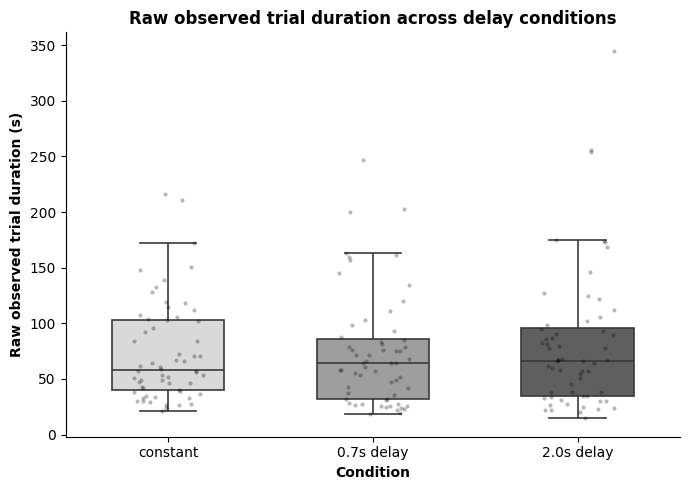

In [231]:
# =======================================================
# 7) PLOT RAW OBSERVED TRIAL DURATION BY CONDITION
# =======================================================
# Goal:
# Visualize raw observed trial duration per trial across conditions.
#
# Each dot = one valid trial.
# Boxplot = distribution of trial-level raw observed durations.

import matplotlib.pyplot as plt
import seaborn as sns

COND_ORDER = ["constant", "0.7s delay", "2.0s delay"]

COND_COLORS = {
    "constant": "#d9d9d9",
    "0.7s delay": "#9e9e9e",
    "2.0s delay": "#5f5f5f"
}

plot_raw_duration = raw_trial_duration.copy()

plot_raw_duration["condition"] = (
    plot_raw_duration["condition"]
    .astype(str)
)

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_raw_duration,
    x="condition",
    y="raw_observed_trial_duration_s",
    order=COND_ORDER,
    palette=COND_COLORS,
    showfliers=False,
    width=0.55,
    linewidth=1.2
)

sns.stripplot(
    data=plot_raw_duration,
    x="condition",
    y="raw_observed_trial_duration_s",
    order=COND_ORDER,
    color="black",
    alpha=0.28,
    size=3,
    jitter=0.18
)

plt.xlabel("Condition", fontweight="bold")
plt.ylabel("Raw observed trial duration (s)", fontweight="bold")
plt.title(
    "Raw observed trial duration across delay conditions",
    fontweight="bold"
)

sns.despine()
plt.tight_layout()
plt.show()

misst: erste aufgezeichneter object gasze innerhalb einer model bauphase bis zum letzten